In [313]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
import numpy.ma as ma
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.minor.size": 1.0,
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})

%matplotlib widget

In [314]:
# Define data folder and figure save folder
data_folder = '../data'
data_folder = os.path.abspath(data_folder)
print(f'Data folder: {data_folder}')

figure_save_folder = '../figures/CKII_pooled'
figure_save_folder = os.path.abspath(figure_save_folder)
os.makedirs(figure_save_folder, exist_ok=True)
print(f'Figures will be saved to: {figure_save_folder}')

# ============================================================================
# CS+ PLACE CELL THRESHOLD (tunable parameter)
# ============================================================================
# A place cell is classified as CS+ if:
#   1. is_place_cell = True (based on All spikes spatial information)
#   2. Number of complex bursts inside the All-spikes place field during
#      locomotion (run_in from spike_shapes) >= CB_NUM_THRESHOLD
# CS- place cells are All spike place cells that don't meet the CS criterion
CB_NUM_THRESHOLD = 10  # Minimum number of CB inside PF during locomotion
print(f"\n{'='*70}")
print(f"CS+ PLC THRESHOLD: is_place_cell=True AND n_cb_in_pf >= {CB_NUM_THRESHOLD}")
print(f"  (CB counted during locomotion only, inside All-spikes PF)")
print(f"{'='*70}")

# Load pooled stats from all CKII mice
ckii_folders = [
    'CKII_pAce21_PR_20250806',
    'CKII_pAce38_PX_20251126',
    'CKII_pAce45_PX_20260118',
    'CKII_pAce47_PX_20260128',
    'CKII_pAce46_PR_20260222',
]

# ============================================================================
# Identify truly deleted cells (bad SNR) from merged data
# These are cells where >90% of frames have SNR < 3.5 (effectively deleted)
# ============================================================================
import pickle

def get_deleted_cells(data_folder, folders, snr_threshold=3.5, bad_frac_threshold=0.9):
    """
    Identify cells that are truly deleted due to bad SNR.
    A cell is considered deleted if >90% of its frames have SNR < threshold.
    
    Returns: set of (session, cell_idx) tuples
    """
    deleted_set = set()
    for folder in folders:
        merged_path = os.path.join(data_folder, folder, 'merged_aligned_data_CS.pkl')
        if os.path.exists(merged_path):
            with open(merged_path, 'rb') as f:
                merged_data = pickle.load(f)
            
            SNR_interpolated = merged_data.get('SNR_interpolated', [])
            for cell_idx in range(len(SNR_interpolated)):
                snr_vals = np.asarray(SNR_interpolated[cell_idx])
                if snr_vals.ndim == 0:
                    deleted_set.add((folder, cell_idx))
                    continue
                
                bad_mask = snr_vals < snr_threshold
                bad_frac = np.mean(bad_mask)
                
                if bad_frac > bad_frac_threshold:
                    deleted_set.add((folder, cell_idx))
    return deleted_set

# Get truly deleted cells (>90% bad frames)
deleted_cells = get_deleted_cells(data_folder, ckii_folders)
print(f"\nFound {len(deleted_cells)} truly deleted cells (>90% bad SNR frames):")
for folder, cell_idx in sorted(deleted_cells):
    print(f"   {folder}: cell_idx={cell_idx}")

# ============================================================================
# Count complex bursts inside place field during locomotion from spike_shapes
# (spike_shapes are saved per cell in spatial_analysis_full.pkl, computed
#  using the All-spikes place field mask; we use 'run_in' = locomotion + in PF)
# ============================================================================
cb_in_pf_counts = {}
for folder in ckii_folders:
    spatial_path = os.path.join(data_folder, folder, 'spatial_analysis_full.pkl')
    if not os.path.exists(spatial_path):
        print(f"  Missing spatial data: {spatial_path}")
        continue
    with open(spatial_path, 'rb') as f:
        spatial_cells = pickle.load(f)
    for cell in spatial_cells:
        cell_idx = cell['cell_idx']
        spike_shapes = cell.get('spike_shapes')
        if spike_shapes and 'complex' in spike_shapes:
            cb = spike_shapes['complex']['shapes']
            n_in = len(cb.get('run_in', []))
        else:
            n_in = 0
        cb_in_pf_counts[(folder, cell_idx)] = n_in

print(f"\nCB-in-PF counts loaded for {len(cb_in_pf_counts)} cells")

# ============================================================================
# Load pooled stats and filter out deleted cells
# ============================================================================
all_dfs = []
for folder in ckii_folders:
    pkl_path = os.path.join(data_folder, folder, 'pooled_stats.pkl')
    if os.path.exists(pkl_path):
        df = pd.read_pickle(pkl_path)
        df['session'] = folder
        all_dfs.append(df)
        print(f"Loaded {len(df)} cells from {folder}")
    else:
        print(f"Missing: {pkl_path}")

if all_dfs:
    df_all_raw = pd.concat(all_dfs, ignore_index=True)
    total_loaded = len(df_all_raw)
    
    # Filter out truly deleted cells only
    valid_mask = ~df_all_raw.apply(
        lambda row: (row['session'], row['cell_idx']) in deleted_cells, 
        axis=1
    )
    df_all = df_all_raw[valid_mask].copy().reset_index(drop=True)
    
    n_excluded = total_loaded - len(df_all)
    if n_excluded > 0:
        print(f"\nWARNING: {n_excluded} cells excluded due to bad SNR (>90% bad frames)")
        print(f"   Valid cells for state-dependent analysis: {len(df_all)} / {total_loaded}")
    
    df_pc = df_all[df_all['is_place_cell'] == True].copy()
    print(f"\nTotal: {len(df_all)} cells, {len(df_pc)} place cells")
    
    # ========================================================================
    # CS+ PLC classification: place cells with >= CB_NUM_THRESHOLD complex
    # bursts inside the All-spikes place field during locomotion
    # ========================================================================
    n_cb_in_pf = df_pc.apply(
        lambda row: cb_in_pf_counts.get((row['session'], row['cell_idx']), 0),
        axis=1
    ).values
    
    is_cs_plc = n_cb_in_pf >= CB_NUM_THRESHOLD
    
    # Add the new classification columns
    df_pc['is_cs_plc'] = is_cs_plc
    df_pc['n_cb_in_pf'] = n_cb_in_pf
    
    # Also update df_all for the place cells
    df_all.loc[df_all['is_place_cell'] == True, 'is_cs_plc'] = False
    df_all.loc[df_all['is_place_cell'] == True, 'n_cb_in_pf'] = 0
    df_all.loc[df_pc.index, 'is_cs_plc'] = is_cs_plc
    df_all.loc[df_pc.index, 'n_cb_in_pf'] = n_cb_in_pf
    
    # Count CS+ and CS- place cells
    n_cs_plus = is_cs_plc.sum()
    n_cs_minus = (~is_cs_plc).sum()
    
    print(f"\n{'='*70}")
    print(f"CS+ / CS- PLACE CELL CLASSIFICATION")
    print(f"  Threshold: n_cb_in_pf (locomotion) >= {CB_NUM_THRESHOLD}")
    print(f"{'='*70}")
    print(f"  CS+ PLCs: {n_cs_plus} ({100*n_cs_plus/len(df_pc):.1f}%) - PLCs with >= {CB_NUM_THRESHOLD} CB in PF")
    print(f"  CS- PLCs: {n_cs_minus} ({100*n_cs_minus/len(df_pc):.1f}%) - PLCs with < {CB_NUM_THRESHOLD} CB in PF")
    print(f"  (CB in PF: mean = {np.mean(n_cb_in_pf):.1f}, median = {np.median(n_cb_in_pf):.1f}, max = {np.max(n_cb_in_pf)})")

else:
    print("No data found! Run Figures.ipynb for each mouse first.")

Data folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data
Figures will be saved to: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled

CS+ PLC THRESHOLD: is_place_cell=True AND n_cb_in_pf >= 10
  (CB counted during locomotion only, inside All-spikes PF)

Found 0 truly deleted cells (>90% bad SNR frames):

CB-in-PF counts loaded for 48 cells
Loaded 9 cells from CKII_pAce21_PR_20250806
Loaded 9 cells from CKII_pAce38_PX_20251126
Loaded 16 cells from CKII_pAce45_PX_20260118
Loaded 5 cells from CKII_pAce47_PX_20260128
Loaded 9 cells from CKII_pAce46_PR_20260222

Total: 48 cells, 18 place cells

CS+ / CS- PLACE CELL CLASSIFICATION
  Threshold: n_cb_in_pf (locomotion) >= 10
  CS+ PLCs: 10 (55.6%) - PLCs with >= 10 CB in PF
  CS- PLCs: 8 (44.4%) - PLCs with < 10 CB in PF
  (CB in PF: mean = 37.2, median = 26.0, max = 122)


In [315]:
# Load spatial analysis data from all CKII animals
import pickle
import glob

def load_pooled_spatial_data(data_folder, folders):
    """Load spatial_analysis_full.pkl from specified animal folders.
    Returns list of (folder_name, cell_data) tuples for filtering.
    """
    all_cells = []
    for folder in folders:
        spatial_path = os.path.join(data_folder, folder, 'spatial_analysis_full.pkl')
        if os.path.exists(spatial_path):
            with open(spatial_path, 'rb') as f:
                cells = pickle.load(f)
                for cell in cells:
                    cell['session'] = folder  # Add session info for filtering
                all_cells.extend(cells)
                print(f"Loaded {len(cells)} cells from {folder}")
        else:
            print(f"Missing: {spatial_path}")
    print(f"\nTotal: {len(all_cells)} cells loaded")
    return all_cells

# Load all spatial data
all_spatial_cells = load_pooled_spatial_data(data_folder, ckii_folders)

# Filter out truly deleted cells (>90% bad SNR frames) using the same set from cell 1
total_loaded = len(all_spatial_cells)
valid_spatial_cells = [
    cell for cell in all_spatial_cells 
    if (cell['session'], cell['cell_idx']) not in deleted_cells
]
n_excluded = total_loaded - len(valid_spatial_cells)

if n_excluded > 0:
    print(f"\nWARNING: {n_excluded} cells excluded due to bad SNR (>90% bad frames)")
    print(f"   Valid cells for spatial analysis: {len(valid_spatial_cells)} / {total_loaded}")

# Check whether waveform/burst-metric payloads are present in spatial_analysis_full.pkl
n_shapes = sum(1 for c in valid_spatial_cells if c.get('spike_shapes'))
n_burst_metrics = sum(1 for c in valid_spatial_cells if c.get('burst_metrics'))
print(f"\nLoaded payloads from spatial_analysis_full.pkl:")
print(f"  spike_shapes present: {n_shapes} / {len(valid_spatial_cells)}")
print(f"  burst_metrics present: {n_burst_metrics} / {len(valid_spatial_cells)}")

missing_shapes_sessions = sorted({c.get('session', 'unknown') for c in valid_spatial_cells if not c.get('spike_shapes')})
missing_burst_sessions = sorted({c.get('session', 'unknown') for c in valid_spatial_cells if not c.get('burst_metrics')})
if missing_shapes_sessions:
    print(f"  spike_shapes missing in sessions: {missing_shapes_sessions}")
if missing_burst_sessions:
    print(f"  burst_metrics missing in sessions: {missing_burst_sessions}")

# ============================================================================
# Apply CS+ PLC classification to spatial cells
# CS+ PLC = is_place_cell AND n_cb_in_pf (run_in) >= CB_NUM_THRESHOLD
# (cb_in_pf_counts computed in cell 1 from spike_shapes['complex']['shapes']['run_in'])
# ============================================================================
print(f"\n{'='*70}")
print(f"Applying CS+ PLC classification")
print(f"CS+ PLC = is_place_cell=True AND n_cb_in_pf >= {CB_NUM_THRESHOLD}")
print(f"  (CB counted during locomotion only, inside All-spikes PF)")
print(f"{'='*70}")

for cell in valid_spatial_cells:
    n_cb = cb_in_pf_counts.get((cell['session'], cell['cell_idx']), 0)
    cell['n_cb_in_pf'] = n_cb
    cell['is_cs_plc'] = cell.get('is_place_cell', False) and (n_cb >= CB_NUM_THRESHOLD)

# Classify cells into 3 categories:
# - PLCs (CS+): is_place_cell=True AND is_cs_plc=True
# - PLCs (CS-): is_place_cell=True AND is_cs_plc=False
# - Non-PLCs: is_place_cell=False

plcs_csplus = []  # PLCs (CS+)
plcs_csminus = []  # PLCs (CS-)
non_plcs = []  # Non-PLCs

for cell in valid_spatial_cells:
    if cell['is_place_cell']:
        if cell['is_cs_plc']:
            plcs_csplus.append(cell)
        else:
            plcs_csminus.append(cell)
    else:
        non_plcs.append(cell)

print(f"\nCell Classification (CB_NUM_THRESHOLD = {CB_NUM_THRESHOLD}):")
print(f"  PLCs (CS+): {len(plcs_csplus)} ({100*len(plcs_csplus)/len(valid_spatial_cells):.1f}%)")
print(f"  PLCs (CS-): {len(plcs_csminus)} ({100*len(plcs_csminus)/len(valid_spatial_cells):.1f}%)")
print(f"  Non-PLCs: {len(non_plcs)} ({100*len(non_plcs)/len(valid_spatial_cells):.1f}%)")

# Show CB-in-PF distribution for place cells
pc_cb_counts = [c['n_cb_in_pf'] for c in valid_spatial_cells if c['is_place_cell']]
if pc_cb_counts:
    print(f"\nCB in place field (locomotion) for All spike place cells:")
    print(f"  Mean: {np.mean(pc_cb_counts):.1f}, Median: {np.median(pc_cb_counts):.1f}")
    print(f"  Range: [{min(pc_cb_counts)}, {max(pc_cb_counts)}]")

Loaded 9 cells from CKII_pAce21_PR_20250806
Loaded 9 cells from CKII_pAce38_PX_20251126
Loaded 16 cells from CKII_pAce45_PX_20260118
Loaded 5 cells from CKII_pAce47_PX_20260128
Loaded 9 cells from CKII_pAce46_PR_20260222

Total: 48 cells loaded

Loaded payloads from spatial_analysis_full.pkl:
  spike_shapes present: 48 / 48
  burst_metrics present: 48 / 48

Applying CS+ PLC classification
CS+ PLC = is_place_cell=True AND n_cb_in_pf >= 10
  (CB counted during locomotion only, inside All-spikes PF)

Cell Classification (CB_NUM_THRESHOLD = 10):
  PLCs (CS+): 10 (20.8%)
  PLCs (CS-): 8 (16.7%)
  Non-PLCs: 30 (62.5%)

CB in place field (locomotion) for All spike place cells:
  Mean: 37.2, Median: 26.0
  Range: [0, 122]


# Pie chart of cell classification

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/CellType_Distribution_PieChart.svg


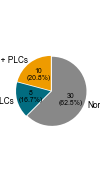

In [380]:
# Pie chart showing distribution of cell types
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(1,1.8))

# Data for pie chart
sizes = [len(plcs_csplus), len(plcs_csminus), len(non_plcs)]
labels = ['CS+ PLCs', 'CS- PLCs', 'Non-PLCs']
colors = ['#EE9B00', '#026C80', '#888888']  # CS color, SS color, gray
explode = (0.02, 0.02, 0.02)

# Create pie chart
wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    colors=colors,
    explode=explode,
    autopct=lambda pct: f'{int(round(pct/100.*sum(sizes)))}\n({pct:.1f}%)',
    startangle=90,
    textprops={'fontsize': 6, 'fontname': 'Arial'},
)

# Style the percentage text
for autotext in autotexts:
    autotext.set_fontsize(5)
    autotext.set_fontname('Arial')

#ax.set_title(f'Cell Type Distribution (n={sum(sizes)})', fontsize=8, fontname='Arial')
ax.axis('equal')

#plt.tight_layout()

# Save figure
pie_path = os.path.join(figure_save_folder, 'CellType_Distribution_PieChart.svg')
fig.savefig(pie_path, dpi=300)
print(f"Saved: {pie_path}")
plt.show()

In [381]:
# ============================================================================
# Compute global colorbar limits for theta and slow Vm maps
# These are used across all 3 figures to ensure consistent color scales
# ============================================================================

# Combine all cells from all categories
all_cells_for_vlim = plcs_csplus + plcs_csminus + non_plcs

# Compute global theta map limits
theta_mins = []
theta_maxs = []
for cell in all_cells_for_vlim:
    theta_map = cell.get('theta_map', None)
    if theta_map is not None and np.any(np.isfinite(theta_map)):
        theta_mins.append(np.nanmin(theta_map))
        theta_maxs.append(np.nanmax(theta_map))

if theta_mins and theta_maxs:
    global_theta_vlim = (min(theta_mins), max(theta_maxs))
else:
    global_theta_vlim = None

# Compute global slow Vm limits (symmetric around 0)
slow_abs_maxs = []
for cell in all_cells_for_vlim:
    slow_map = cell.get('slow_map', None)
    if slow_map is not None and np.any(np.isfinite(slow_map)):
        slow_abs_maxs.append(np.nanmax(np.abs(slow_map)))

if slow_abs_maxs:
    slow_abs_max = max(slow_abs_maxs)
    global_slow_vlim = (-slow_abs_max, slow_abs_max)
else:
    global_slow_vlim = None

print(f"Global theta vlim: {global_theta_vlim}")
print(f"Global slow vlim: {global_slow_vlim}")

# ============================================================================
# TUNABLE PARAMETERS - Adjust these to customize the colorbar ranges
# Set to None to use auto-computed global limits
# ============================================================================
theta_vlim = global_theta_vlim  # e.g., (0.5, 2.0) for custom range
slow_vlim = global_slow_vlim    # e.g., (-0.5, 0.5) for custom range

print(f"\nUsing theta_vlim: {theta_vlim}")
print(f"Using slow_vlim: {slow_vlim}")

Global theta vlim: (np.float64(0.0004948617269726908), np.float64(0.1730764842253994))
Global slow vlim: (np.float64(-0.2513713903806452), np.float64(0.2513713903806452))

Using theta_vlim: (np.float64(0.0004948617269726908), np.float64(0.1730764842253994))
Using slow_vlim: (np.float64(-0.2513713903806452), np.float64(0.2513713903806452))


# Spatial Heatmaps

In [382]:
# # ============================================================================
# # Unified Plotting Function for Selected Cells Figure
# # ============================================================================
# # Handles both: (1) multiple groups with gaps, (2) single group without gaps

# def plot_selected_cells_figure(
#     cell_groups,
#     group_names=None,
#     max_fig_width=7.24,
#     gap_ratio=0.1,
#     theta_vlim=None,
#     slow_vlim=None,
#     save_path=None,
#     show_scale_bar=True,
#     pf_only_place_cells=True,
#     plot_putative_PF=False,
#     show_place_cell_star=True,
#     show_significance_marker=True,
#     plot_spike_shapes=True,
#     min_shapes_per_condition=None,
#     min_shapes_per_condition_ss=5,
#     min_shapes_per_condition_cb=3,
#     spike_shape_state='run',
# ):
#     """
#     Plot spatial heatmaps for selected cells in a grid format.
    
#     Parameters:
#     -----------
#     cell_groups : list of lists
#         Either a list of cell groups [[group1_cells], [group2_cells], ...] for multi-group figure,
#         or a single list of cells [cell1, cell2, ...] which will be treated as one group.
#     group_names : list of str, optional
#         Names for each group (for display/saving). If None, uses generic names.
#     max_fig_width : float
#         Maximum figure width in inches (default 7.24 for journal)
#     gap_ratio : float
#         Width of gap columns relative to cell columns (only used for multi-group)
#     theta_vlim : list/tuple or None
#         [vmin, vmax] for theta map. If None, uses auto limits.
#     slow_vlim : list/tuple or None
#         [vmin, vmax] for slow Vm map. If None, uses auto limits.
#     save_path : str, optional
#         Path to save the figure. If None, doesn't save.
#     show_scale_bar : bool
#         Whether to show scale bar on first column (default True)
#     pf_only_place_cells : bool
#         If True (default), only plot PF contours for cells that are place cells (is_place_cell=True).
#         If False, plot PF contours based on individual spike type criteria.
#     plot_putative_PF : bool
#         If True, plot dashed PF contours for putative place fields (significant but not place cell).
#         If False (default), only plot solid PF contours for confirmed place cells.
#     show_place_cell_star : bool
#         If True (default), show ★ marker for confirmed place cells on rate maps.
#         If False, hide the star markers.
#     show_significance_marker : bool
#         If True (default), show significance markers (*, **, ***) based on p-value.
#         If False, hide the significance markers.
#     plot_spike_shapes : bool
#         If True (default), add 2 rows at the bottom with mean±SEM spike shapes:
#         SS (simple) and CB (complex). Overlays In-PF (magenta) and Out-PF (gray).
#     min_shapes_per_condition : int or None
#         Backward-compatible alias: if set, uses the same minimum for SS and CB.
#     min_shapes_per_condition_ss : int
#         Minimum number of SS waveforms required (default 10).
#     min_shapes_per_condition_cb : int
#         Minimum number of CB waveforms required (default 5).
#     spike_shape_state : {'run', 'rest'}
#         Which state to plot for the 2 spike-shape rows (default 'run').
    
#     Returns:
#     --------
#     fig : matplotlib Figure
#     """
#     from matplotlib.gridspec import GridSpec
#     from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    
#     # Normalize input: if cell_groups is a flat list of cells, wrap it
#     if len(cell_groups) > 0 and isinstance(cell_groups[0], dict):
#         cell_groups = [cell_groups]  # Single group
    
#     n_groups = len(cell_groups)
#     cells_per_group = [len(g) for g in cell_groups]
#     total_cells = sum(cells_per_group)
    
#     if total_cells == 0:
#         print("No cells to plot!")
#         return None
    
#     # Flatten cells list for easy indexing
#     all_cells = []
#     for g in cell_groups:
#         all_cells.extend(g)
    
#     # Determine if we need gaps (only for multiple groups)
#     use_gaps = n_groups > 1
    
#     # Backward compatibility: allow a single threshold for both SS and CB.
#     if min_shapes_per_condition is not None:
#         if (min_shapes_per_condition_ss, min_shapes_per_condition_cb) == (10, 5):
#             min_shapes_per_condition_ss = int(min_shapes_per_condition)
#             min_shapes_per_condition_cb = int(min_shapes_per_condition)
#     min_shapes_per_condition_ss = int(min_shapes_per_condition_ss)
#     min_shapes_per_condition_cb = int(min_shapes_per_condition_cb)
    
#     base_rows = 6  # trajectory, rate map, SS, CS, theta, slow
#     n_rows = base_rows + (2 if plot_spike_shapes else 0)
    
#     # Calculate width ratios
#     if use_gaps:
#         # With gaps between groups
#         width_ratios = []
#         col_to_cell = {}
#         gap_cols = []
#         cell_idx = 0
#         col_idx = 0
#         for g_idx, n_cells in enumerate(cells_per_group):
#             for c in range(n_cells):
#                 width_ratios.append(1)
#                 col_to_cell[col_idx] = cell_idx
#                 col_idx += 1
#                 cell_idx += 1
#             if g_idx < n_groups - 1:  # Add gap after each group except last
#                 width_ratios.append(gap_ratio)
#                 gap_cols.append(col_idx)
#                 col_idx += 1
#     else:
#         # No gaps - simple grid
#         width_ratios = [1] * total_cells
#         col_to_cell = {i: i for i in range(total_cells)}
#         gap_cols = []
    
#     n_cols = len(width_ratios)
    
#     # Find the last/first data column for colorbars/labels
#     last_data_col = max(col_to_cell.keys())
#     first_data_col = min(col_to_cell.keys())
    
#     # Row indices for optional spike-shape panels
#     shape_row_ss = base_rows
#     shape_row_cb = base_rows + 1
    
#     # Get arena dimensions from first cell
#     params = all_cells[0]['params']
#     width_real = params['width_real']
#     height_real = params['height_real']
#     arena_aspect = height_real / width_real
    
#     # Calculate figure dimensions dynamically
#     left_margin = 0.4
#     right_margin = 0.3
#     top_margin = 0.25
#     bottom_margin = 0.1
    
#     available_width = max_fig_width - left_margin - right_margin
#     total_width_units = sum(width_ratios)
#     cell_width = available_width / total_width_units
#     cell_height = cell_width * arena_aspect
    
#     row_gap = 0.1
#     fig_height = n_rows * cell_height + (n_rows - 1) * row_gap + top_margin + bottom_margin
    
#     # Create figure
#     fig = plt.figure(figsize=(max_fig_width, fig_height))
#     gs = GridSpec(n_rows, n_cols, figure=fig, width_ratios=width_ratios,
#                   left=left_margin/max_fig_width, right=1-right_margin/max_fig_width,
#                   top=1-top_margin/fig_height, bottom=bottom_margin/fig_height,
#                   wspace=0.05, hspace=0.15)
    
#     # Create axes for data columns only (skip gap columns)
#     axes_grid = {}
    
#     # Base rows (maps)
#     for row in range(base_rows):
#         for col in range(n_cols):
#             if col in gap_cols:
#                 continue
#             axes_grid[(row, col)] = fig.add_subplot(gs[row, col])
    
#     # Optional spike-shape rows (share x/y axes across both rows + all columns)
#     if plot_spike_shapes:
#         # Create anchor axis first
#         anchor_ax = fig.add_subplot(gs[shape_row_ss, first_data_col])
#         axes_grid[(shape_row_ss, first_data_col)] = anchor_ax
        
#         for col in range(n_cols):
#             if col in gap_cols:
#                 continue
#             if col != first_data_col:
#                 axes_grid[(shape_row_ss, col)] = fig.add_subplot(
#                     gs[shape_row_ss, col], sharex=anchor_ax, sharey=anchor_ax
#                 )
#             axes_grid[(shape_row_cb, col)] = fig.add_subplot(
#                 gs[shape_row_cb, col], sharex=anchor_ax, sharey=anchor_ax
#             )
    
#     # Define colors and styling
#     cmap = 'magma'
#     slow_cmap = 'coolwarm'
#     extent = (0, width_real, 0, height_real)
#     simple_spike_color = "#026C80"
#     complex_spike_color = "#EE9B00"
#     ss_contour_color = "#026C80"
    
#     def _style_map_axis(ax):
#         ax.set_xlim(0, width_real)
#         ax.set_ylim(0, height_real)
#         ax.set_aspect("equal")
#         ax.set_xticks([])
#         ax.set_yticks([])
#         for spine in ax.spines.values():
#             spine.set_visible(False)
    
#     def _plot_pf_contour(ax, pf_mask, color, linewidth=0.6, linestyle='solid'):
#         if pf_mask is None or not np.any(pf_mask):
#             return
#         padded_mask = np.pad(pf_mask.astype(float), pad_width=1, mode='constant', constant_values=0)
#         bin_size = width_real / pf_mask.shape[0]
#         padded_extent = (-bin_size, width_real + bin_size, -bin_size, height_real + bin_size)
#         ax.contour(padded_mask.T, levels=[0.5], colors=color, linewidths=linewidth,
#                    linestyles=linestyle, extent=padded_extent, origin="lower")
    
#     def _get_sig_marker(p_val):
#         if p_val < 0.001: return "***"
#         elif p_val < 0.01: return "**"
#         elif p_val < 0.05: return "*"
#         else: return ""
    
#     def _add_colorbar(ax, im, ticks=None, ticklabels=None):
#         cax = inset_axes(ax, width="5%", height="100%", loc="center right",
#                          bbox_to_anchor=(0.12, 0.0, 1, 1), bbox_transform=ax.transAxes, borderpad=0)
#         cbar = ax.figure.colorbar(im, cax=cax)
#         if ticks is not None and ticklabels is not None:
#             cbar.set_ticks(ticks)
#             cbar.set_ticklabels(ticklabels)
#         cbar.ax.tick_params(labelsize=5)
#         return cbar
    
#     # Prepare shared axes and global limits for spike-shape rows
#     shape_xlim = None
#     shape_ylim = None
#     if plot_spike_shapes:
#         x_min = np.inf
#         x_max = -np.inf
#         y_min = np.inf
#         y_max = -np.inf
        
#         if spike_shape_state not in ('run', 'rest'):
#             raise ValueError("spike_shape_state must be 'run' or 'rest'")
        
#         def _gather_waves(spike_shapes, spike_type, pf_key):
#             info = spike_shapes.get(spike_type) if isinstance(spike_shapes, dict) else None
#             if not info:
#                 return np.array([]), []
#             time_ms = np.asarray(info.get('time_ms', []), dtype=float)
#             shapes = info.get('shapes', {})
#             in_key = f"{spike_shape_state}_in"
#             out_key = f"{spike_shape_state}_out"
#             if pf_key == 'in':
#                 waves = list(shapes.get(in_key, []))
#             else:
#                 waves = list(shapes.get(out_key, []))
#             return time_ms, waves
        
#         def _mean_sem(waves):
#             if len(waves) == 0:
#                 return None, None
#             arr = np.vstack(waves)
#             mean = np.nanmean(arr, axis=0)
#             n_eff = np.sum(np.isfinite(arr), axis=0)
#             std = np.nanstd(arr, axis=0, ddof=0)
#             with np.errstate(divide='ignore', invalid='ignore'):
#                 sem = np.where(n_eff > 0, std / np.sqrt(n_eff), np.nan)
#             return mean, sem
        
#         def _min_req(spike_type):
#             return (
#                 min_shapes_per_condition_ss
#                 if spike_type == 'simple'
#                 else min_shapes_per_condition_cb
#             )
        
#         def _normalize_mean_shape(time_ms, mean, sem):
#             time_ms = np.asarray(time_ms, dtype=float)
#             mean = np.asarray(mean, dtype=float)
#             sem = np.asarray(sem, dtype=float) if sem is not None else None
#             pre_mask = time_ms < 0
#             if not np.any(pre_mask):
#                 return None
#             baseline = np.nanmean(mean[pre_mask])
#             if not np.isfinite(baseline):
#                 return None
#             if time_ms.size == 0:
#                 return None
#             idx0 = int(np.nanargmin(np.abs(time_ms)))
#             if not np.isfinite(mean[idx0]):
#                 return None
#             height = mean[idx0] - baseline
#             if not np.isfinite(height) or abs(height) < 1e-12:
#                 return None
#             mean_n = (mean - baseline) / height
#             sem_n = (sem / abs(height)) if sem is not None else None
#             return mean_n, sem_n
        
#         for c in all_cells:
#             spike_shapes = c.get('spike_shapes')
#             if not spike_shapes:
#                 continue
#             for spike_type in ('simple', 'complex'):
#                 for pf_key in ('in', 'out'):
#                     time_ms, waves = _gather_waves(spike_shapes, spike_type, pf_key)
#                     if time_ms.size:
#                         x_min = min(x_min, float(np.nanmin(time_ms)))
#                         x_max = max(x_max, float(np.nanmax(time_ms)))
#                     if len(waves) < _min_req(spike_type):
#                         continue
#                     mean, sem = _mean_sem(waves)
#                     if mean is None:
#                         continue
#                     norm = _normalize_mean_shape(time_ms, mean, sem)
#                     if norm is None:
#                         continue
#                     mean, sem = norm
#                     low = mean - sem if sem is not None else mean
#                     high = mean + sem if sem is not None else mean
#                     if np.any(np.isfinite(low)):
#                         y_min = min(y_min, float(np.nanmin(low)))
#                     if np.any(np.isfinite(high)):
#                         y_max = max(y_max, float(np.nanmax(high)))
        
#         if np.isfinite(x_min) and np.isfinite(x_max):
#             shape_xlim = (x_min, x_max)
#         else:
#             shape_xlim = (-20.0, 150.0)
#         if np.isfinite(y_min) and np.isfinite(y_max):
#             if y_max == y_min:
#                 eps = 1e-3
#                 shape_ylim = (y_min - eps, y_max + eps)
#             else:
#                 # Use global min/max (no extra padding) to keep the rows compact.
#                 shape_ylim = (y_min, y_max)
#         else:
#             shape_ylim = (-0.2, 1.2)
        
#         # Shared axes are established via `sharex/sharey` when creating subplots.
#         axes_grid[(shape_row_ss, first_data_col)].set_xlim(*shape_xlim)
#         axes_grid[(shape_row_ss, first_data_col)].set_ylim(*shape_ylim)
    
#     # Plot each cell
#     for display_col, cell_idx in col_to_cell.items():
#         cell = all_cells[cell_idx]
#         is_last_column = (display_col == last_data_col)
#         is_first_column = (display_col == first_data_col)
        
#         # Parse animal name
#         animal_id = cell['animal_id']
#         animal_short = animal_id.split('_')[1] if '_' in animal_id else animal_id
#         cell_num = cell['cell_idx'] + 1
#         is_place_cell = cell.get('is_place_cell', False)
#         is_place_cell_ss = cell.get('is_place_cell_ss', False)
#         is_place_cell_cs = cell.get('is_place_cell_cs', False)
        
#         # Row 0: Trajectory
#         ax_traj = axes_grid[(0, display_col)]
#         x_traj, y_traj = cell['x_traj'], cell['y_traj']
#         ax_traj.plot(x_traj, y_traj, color="gray", linewidth=0.3, alpha=0.5)
#         ss_x = cell.get('ss_spikes_x', cell['spikes_x'])
#         ss_y = cell.get('ss_spikes_y', cell['spikes_y'])
#         if len(ss_x) > 0:
#             ax_traj.scatter(ss_x, ss_y, s=2, color=simple_spike_color, alpha=0.6, linewidths=0, zorder=2, rasterized=True)
#         cs_x = cell.get('cs_spikes_x', np.array([]))
#         cs_y = cell.get('cs_spikes_y', np.array([]))
#         if len(cs_x) > 0:
#             ax_traj.scatter(cs_x, cs_y, s=2, color=complex_spike_color, alpha=0.6, linewidths=0, zorder=3, rasterized=True)
#         _style_map_axis(ax_traj)
#         ax_traj.set_title(f"{animal_short}\nCell {cell_num}", fontsize=5, fontname="Arial", pad=2)
        
#         # Add 10 cm scale bar on first column only
#         if is_first_column and show_scale_bar:
#             scale_bar_length = 10  # cm
#             x_start = 1
#             y_pos = -1
#             ax_traj.plot([x_start, x_start + scale_bar_length], [y_pos, y_pos], 
#                         color='black', linewidth=1.5, solid_capstyle='butt', clip_on=False)
#             ax_traj.text(x_start + scale_bar_length/2, y_pos - 1.5, '10 cm', 
#                         ha='center', va='top', fontsize=5, fontname='Arial', clip_on=False)
        
#         # Row 1: Rate map (all spikes)
#         ax_rate = axes_grid[(1, display_col)]
#         rate_map = cell['rate_map']
#         peak_rate = cell['peak_rate']
#         p_val = cell.get('p_value', 1.0)
#         sig_mark = _get_sig_marker(p_val)
#         im_rate = None
#         if rate_map is not None:
#             masked_map = ma.masked_where(np.isnan(rate_map), rate_map)
#             im_rate = ax_rate.imshow(masked_map.T, origin="lower", extent=extent, cmap=cmap,
#                           interpolation="nearest", vmin=0,
#                           vmax=peak_rate if np.isfinite(peak_rate) and peak_rate > 0 else None)
#             # Plot PF contour: solid if place cell (★), dashed if significant but not place cell (*)
#             pf_mask = cell['place_field_mask']
#             if pf_mask is None or not np.any(pf_mask):
#                 print(f"{animal_short} Cell {cell_num}: All spikes PF mask is empty")
#             elif is_place_cell:
#                 _plot_pf_contour(ax_rate, pf_mask, "magenta", linestyle='solid')
#             elif p_val < 0.05 and not pf_only_place_cells and plot_putative_PF:
#                 _plot_pf_contour(ax_rate, pf_mask, "magenta", linestyle='dashed')
#         _style_map_axis(ax_rate)
#         rate_str = f"{peak_rate:.1f}" if np.isfinite(peak_rate) else "N/A"
#         display_sig_mark = sig_mark if show_significance_marker else ""
#         label_str = f"{display_sig_mark} {rate_str} Hz".strip()
#         ax_rate.text(1.0, -0.02, label_str, transform=ax_rate.transAxes,
#                      ha="right", va="top", fontsize=4, fontname="Arial")
#         # Add star marker for place cells (renders as vector path in Illustrator)
#         if is_place_cell and show_place_cell_star:
#             ax_rate.plot(0.03, -0.06, marker='*', markersize=4, color='black',
#                         transform=ax_rate.transAxes, clip_on=False)
#         if is_last_column and im_rate is not None:
#             _add_colorbar(ax_rate, im_rate, ticks=[0, im_rate.get_clim()[1]], ticklabels=["0", "max"])
        
#         # Row 2: SS normalized map
#         ax_ss = axes_grid[(2, display_col)]
#         ss_norm_map = cell['ss_norm_map']
#         ss_p_val = cell.get('ss_p_value', 1.0)
#         ss_sig_mark = _get_sig_marker(ss_p_val)
#         ss_mask = cell.get('ss_place_field_mask', None)
#         im_ss = None
#         if ss_norm_map is not None:
#             ss_masked = ma.masked_where(np.isnan(ss_norm_map), ss_norm_map)
#             im_ss = ax_ss.imshow(ss_masked.T, origin="lower", extent=extent, cmap=cmap,
#                         interpolation="nearest", vmin=0, vmax=1)
#             # Plot SS contour: solid if SS place cell, dashed if PF exists but not place cell
#             if ss_mask is None or not np.any(ss_mask):
#                 print(f"{animal_short} Cell {cell_num}: SS PF mask is empty")
#             elif pf_only_place_cells and not is_place_cell:
#                 pass  # Skip SS PF if cell is not an all-spike place cell
#             elif is_place_cell_ss:
#                 _plot_pf_contour(ax_ss, ss_mask, ss_contour_color, linestyle='solid')
#             elif plot_putative_PF:
#                 _plot_pf_contour(ax_ss, ss_mask, ss_contour_color, linestyle='dashed')
#         _style_map_axis(ax_ss)
#         ss_peak = cell['ss_peak_rate']
#         ss_str = f"{ss_peak:.1f}" if np.isfinite(ss_peak) else "N/A"
#         # Add star and significance for SS (star only if is_place_cell_ss)
#         ss_display_sig = ss_sig_mark if show_significance_marker else ""
#         ss_label_str = f"{ss_display_sig} {ss_str} Hz".strip()
#         ax_ss.text(1.0, -0.02, ss_label_str, transform=ax_ss.transAxes,
#                    ha="right", va="top", fontsize=4, fontname="Arial")
#         # Add star marker for SS place cells
#         if is_place_cell_ss and show_place_cell_star:
#             ax_ss.plot(0.03, -0.06, marker='*', markersize=4, color='black',
#                       transform=ax_ss.transAxes, clip_on=False)
#         if is_last_column and im_ss is not None:
#             _add_colorbar(ax_ss, im_ss)
        
#         # Row 3: CS normalized map
#         ax_cs = axes_grid[(3, display_col)]
#         cs_norm_map = cell['cs_norm_map']
#         cs_p_val = cell.get('cs_p_value', 1.0)
#         cs_sig_mark = _get_sig_marker(cs_p_val)
#         cs_mask = cell.get('cs_place_field_mask', None)
#         im_cs = None
#         if cs_norm_map is not None:
#             cs_masked = ma.masked_where(np.isnan(cs_norm_map), cs_norm_map)
#             im_cs = ax_cs.imshow(cs_masked.T, origin="lower", extent=extent, cmap=cmap,
#                         interpolation="nearest", vmin=0, vmax=1)
#             # Plot CS contour: solid if CS place cell, dashed if PF exists but not place cell
#             if cs_mask is None or not np.any(cs_mask):
#                 print(f"{animal_short} Cell {cell_num}: CS PF mask is empty")
#             elif pf_only_place_cells and not is_place_cell:
#                 pass  # Skip CS PF if cell is not an all-spike place cell
#             elif is_place_cell_cs:
#                 _plot_pf_contour(ax_cs, cs_mask, complex_spike_color, linestyle='solid')
#             elif plot_putative_PF:
#                 _plot_pf_contour(ax_cs, cs_mask, complex_spike_color, linestyle='dashed')
#         _style_map_axis(ax_cs)
#         cs_peak = cell['cs_peak_rate']
#         cs_str = f"{cs_peak:.1f}" if np.isfinite(cs_peak) else "N/A"
#         # Add star and significance for CS (star only if is_place_cell_cs)
#         cs_display_sig = cs_sig_mark if show_significance_marker else ""
#         cs_label_str = f"{cs_display_sig} {cs_str} Hz".strip()
#         ax_cs.text(1.0, -0.02, cs_label_str, transform=ax_cs.transAxes,
#                    ha="right", va="top", fontsize=4, fontname="Arial")
#         # Add star marker for CS place cells
#         if is_place_cell_cs and show_place_cell_star:
#             ax_cs.plot(0.03, -0.06, marker='*', markersize=4, color='black',
#                       transform=ax_cs.transAxes, clip_on=False)
#         if is_last_column and im_cs is not None:
#             _add_colorbar(ax_cs, im_cs)
        
#         # Row 4: Theta amplitude map
#         ax_theta = axes_grid[(4, display_col)]
#         theta_map = cell.get('theta_map', None)
#         im_theta = None
#         if theta_map is not None and np.any(np.isfinite(theta_map)):
#             theta_masked = ma.masked_where(np.isnan(theta_map), theta_map)
#             theta_vmin, theta_vmax = theta_vlim if theta_vlim else (np.nanmin(theta_map), np.nanmax(theta_map))
#             im_theta = ax_theta.imshow(theta_masked.T, origin="lower", extent=extent, cmap=cmap,
#                            interpolation="nearest", vmin=theta_vmin, vmax=theta_vmax)
#         _style_map_axis(ax_theta)
#         theta_corr_all = cell.get('theta_corr_all', np.nan)
#         theta_corr_ss = cell.get('theta_corr_ss', np.nan)
#         theta_corr_cs = cell.get('theta_corr_cs', np.nan)
#         corr_strs = []
#         if np.isfinite(theta_corr_all): corr_strs.append((f"{theta_corr_all:.2f}", "black"))
#         if np.isfinite(theta_corr_ss): corr_strs.append((f"{theta_corr_ss:.2f}", simple_spike_color))
#         if np.isfinite(theta_corr_cs): corr_strs.append((f"{theta_corr_cs:.2f}", complex_spike_color))
#         x_positions = [0.25, 0.5, 0.75] if len(corr_strs) == 3 else ([0.33, 0.67] if len(corr_strs) == 2 else [0.5])
#         for i, (corr_str, color) in enumerate(corr_strs):
#             ax_theta.text(x_positions[i], -0.02, corr_str, transform=ax_theta.transAxes,
#                          ha="center", va="top", fontsize=4, fontname="Arial", color=color)
#         if is_last_column and im_theta is not None:
#             _add_colorbar(ax_theta, im_theta)
        
#         # Row 5: Slow Vm map
#         ax_slow = axes_grid[(5, display_col)]
#         slow_map = cell.get('slow_map', None)
#         im_slow = None
#         if slow_map is not None and np.any(np.isfinite(slow_map)):
#             slow_masked = ma.masked_where(np.isnan(slow_map), slow_map)
#             slow_vmin, slow_vmax = slow_vlim if slow_vlim else (-np.nanmax(np.abs(slow_map)), np.nanmax(np.abs(slow_map)))
#             im_slow = ax_slow.imshow(slow_masked.T, origin="lower", extent=extent, cmap=slow_cmap,
#                           interpolation="nearest", vmin=slow_vmin, vmax=slow_vmax)
#         _style_map_axis(ax_slow)
#         slow_corr_all = cell.get('slow_corr_all', np.nan)
#         slow_corr_ss = cell.get('slow_corr_ss', np.nan)
#         slow_corr_cs = cell.get('slow_corr_cs', np.nan)
#         slow_corr_strs = []
#         if np.isfinite(slow_corr_all): slow_corr_strs.append((f"{slow_corr_all:.2f}", "black"))
#         if np.isfinite(slow_corr_ss): slow_corr_strs.append((f"{slow_corr_ss:.2f}", simple_spike_color))
#         if np.isfinite(slow_corr_cs): slow_corr_strs.append((f"{slow_corr_cs:.2f}", complex_spike_color))
#         slow_x_positions = [0.25, 0.5, 0.75] if len(slow_corr_strs) == 3 else ([0.33, 0.67] if len(slow_corr_strs) == 2 else [0.5])
#         for i, (corr_str, color) in enumerate(slow_corr_strs):
#             ax_slow.text(slow_x_positions[i], -0.02, corr_str, transform=ax_slow.transAxes,
#                         ha="center", va="top", fontsize=4, fontname="Arial", color=color)
#         if is_last_column and im_slow is not None:
#             _add_colorbar(ax_slow, im_slow)
        
#         # Row 6-7 (optional): Spike shapes (SS and CB), overlay In vs Out PF
#         if plot_spike_shapes:
#             spike_shapes = cell.get('spike_shapes')
            
#             def _plot_shape_row(ax, spike_type):
#                 if not spike_shapes:
#                     ax.axis('off')
#                     return
#                 info = spike_shapes.get(spike_type)
#                 if not info:
#                     ax.axis('off')
#                     return
#                 time_ms = np.asarray(info.get('time_ms', []), dtype=float)
#                 shapes = info.get('shapes', {})
#                 in_key = f"{spike_shape_state}_in"
#                 out_key = f"{spike_shape_state}_out"
#                 in_waves = list(shapes.get(in_key, []))
#                 out_waves = list(shapes.get(out_key, []))
                
#                 plotted_any = False
#                 for waves, color in ((in_waves, 'magenta'), (out_waves, 'gray')):
#                     if len(waves) < _min_req(spike_type):
#                         continue
#                     arr = np.vstack(waves)
#                     mean = np.nanmean(arr, axis=0)
#                     n_eff = np.sum(np.isfinite(arr), axis=0)
#                     std = np.nanstd(arr, axis=0, ddof=0)
#                     with np.errstate(divide='ignore', invalid='ignore'):
#                         sem = np.where(n_eff > 0, std / np.sqrt(n_eff), np.nan)
#                     norm = _normalize_mean_shape(time_ms, mean, sem)
#                     if norm is None:
#                         continue
#                     mean, sem = norm
#                     ax.plot(time_ms, mean, color=color, linewidth=0.8)
#                     ax.fill_between(time_ms, mean - sem, mean + sem, color=color, alpha=0.2, linewidth=0)
#                     plotted_any = True
                
#                 if not plotted_any:
#                     ax.axis('off')
#                     return
#                 ax.set_xlim(*shape_xlim)
#                 ax.set_ylim(*shape_ylim)
#                 # Compact dashed reference line at t=0 (baseline=0, peak=1 after normalization)
#                 y_line_low = max(shape_ylim[0], min(0.0, shape_ylim[1]))
#                 y_line_high = max(shape_ylim[0], min(1.0, shape_ylim[1]))
#                 y_line_low, y_line_high = sorted((y_line_low, y_line_high))
#                 if np.isfinite(y_line_low) and np.isfinite(y_line_high) and y_line_high > y_line_low:
#                     ax.plot([0, 0], [y_line_low, y_line_high], color='black', linestyle='--', linewidth=0.5, alpha=0.5)
#                 ax.set_xticks([])
#                 ax.set_yticks([])
#                 for spine in ax.spines.values():
#                     spine.set_visible(False)
            
#             ax_ss_shape = axes_grid[(shape_row_ss, display_col)]
#             _plot_shape_row(ax_ss_shape, 'simple')
#             ax_cb_shape = axes_grid[(shape_row_cb, display_col)]
#             _plot_shape_row(ax_cb_shape, 'complex')
            
#             # Horizontal scale bar (last row only): 10 ms
#             if is_first_column and ax_cb_shape.axison:
#                 bar_ms = 10.0
#                 x_span = float(shape_xlim[1] - shape_xlim[0])
#                 y_span = float(shape_ylim[1] - shape_ylim[0]) if shape_ylim[1] != shape_ylim[0] else 1.0
#                 x0 = float(shape_xlim[0] + 0.08 * x_span)
#                 x1 = x0 + bar_ms
#                 if x1 > float(shape_xlim[1] - 0.05 * x_span):
#                     x1 = float(shape_xlim[1] - 0.08 * x_span)
#                     x0 = x1 - bar_ms
#                 y0 = float(shape_ylim[0] + 0.08 * y_span)
#                 ax_cb_shape.plot([x0, x1], [y0, y0], color='black', linewidth=0.8, solid_capstyle='butt')
#                 ax_cb_shape.text((x0 + x1) / 2, y0 - 0.06 * y_span, '10 ms', ha='center', va='top', fontsize=4, fontname='Arial')
    
#     # Add row labels on first column
#     row_labels = ['Trajectory', 'All spikes', 'SS', 'CS', 'Theta', 'Slow Vm']
#     if plot_spike_shapes:
#         row_labels.extend(['SS shape', 'CB shape'])
#     for row_idx, label in enumerate(row_labels):
#         axes_grid[(row_idx, first_data_col)].text(-0.15, 0.5, label, 
#             transform=axes_grid[(row_idx, first_data_col)].transAxes,
#             ha="right", va="center", fontsize=5, fontname="Arial", rotation=90)
    
#     # Save figure
#     if save_path:
#         plt.rcParams["svg.fonttype"] = "none"
#         fig.savefig(save_path, dpi=300)
#         print(f"Saved: {save_path}")
    
#     plt.show()
#     return fig

# print("Defined plot_selected_cells_figure() function")

In [383]:
# ============================================================================
# Unified Plotting Function for Selected Cells Figure
# ============================================================================
# Handles both: (1) multiple groups with gaps, (2) single group without gaps

def plot_selected_cells_figure(
    cell_groups,
    group_names=None,
    subplot_width=0.25,
    gap_ratio=0.1,
    theta_vlim=None,
    slow_vlim=None,
    save_path=None,
    show_scale_bar=True,
    pf_only_place_cells=True,
    plot_putative_PF=False,
    show_place_cell_star=True,
    show_significance_marker=True,
    plot_spike_shapes=True,
    plot_spike_shapes_overall=True,
    min_shapes_per_condition=None,
    min_shapes_per_condition_ss=5,
    min_shapes_per_condition_cb=3,
    spike_shape_state='run',
    show_shape_counts=False,
    shape_ylim=None,
):
    """
    Plot spatial heatmaps for selected cells in a grid format.
    
    Parameters:
    -----------
    cell_groups : list of lists
        Either a list of cell groups [[group1_cells], [group2_cells], ...] for multi-group figure,
        or a single list of cells [cell1, cell2, ...] which will be treated as one group.
    group_names : list of str, optional
        Names for each group (for display/saving). If None, uses generic names.
    subplot_width : float
        Width of each map subplot in inches (default 0.25)
    gap_ratio : float
        Width of gap columns relative to cell columns (only used for multi-group)
    theta_vlim : list/tuple or None
        [vmin, vmax] for theta map. If None, uses auto limits.
    slow_vlim : list/tuple or None
        [vmin, vmax] for slow Vm map. If None, uses auto limits.
    save_path : str, optional
        Path to save the figure. If None, doesn't save.
    show_scale_bar : bool
        Whether to show scale bar on first column (default True)
    pf_only_place_cells : bool
        If True (default), only plot PF contours for cells that are place cells (is_place_cell=True).
        If False, plot PF contours based on individual spike type criteria.
    plot_putative_PF : bool
        If True, plot dashed PF contours for putative place fields (significant but not place cell).
        If False (default), only plot solid PF contours for confirmed place cells.
    show_place_cell_star : bool
        If True (default), show ★ marker for confirmed place cells on rate maps.
        If False, hide the star markers.
    show_significance_marker : bool
        If True (default), show significance markers (*, **, ***) based on p-value.
        If False, hide the significance markers.
    plot_spike_shapes : bool
        If True (default), add 2 rows at the bottom with normalized spike/burst shapes.
    plot_spike_shapes_overall : bool
        If True (default), rows are Overall SS and Overall CB (combined in/out PF).
        If False, rows are In-PF and Out-PF (legacy behavior).
    min_shapes_per_condition : int or None
        Backward-compatible alias: if set, uses the same minimum for SS and CB.
    min_shapes_per_condition_ss : int
        Minimum number of SS waveforms required (default 10).
    min_shapes_per_condition_cb : int
        Minimum number of CB waveforms required (default 5).
    spike_shape_state : {'run', 'rest'}
        Which state to plot for the 2 spike-shape rows (default 'run').
    show_shape_counts : bool
        If True, display n=X counts for SS and CB waveforms on each shape row.
    shape_ylim : tuple or None
        (ymin, ymax) for spike shape rows. If None, auto-computed from data.
    
    Returns:
    --------
    fig : matplotlib Figure
    """
    from matplotlib.gridspec import GridSpec
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    
    # Normalize input: if cell_groups is a flat list of cells, wrap it
    if len(cell_groups) > 0 and isinstance(cell_groups[0], dict):
        cell_groups = [cell_groups]  # Single group
    
    n_groups = len(cell_groups)
    cells_per_group = [len(g) for g in cell_groups]
    total_cells = sum(cells_per_group)
    
    if total_cells == 0:
        print("No cells to plot!")
        return None
    
    # Flatten cells list for easy indexing
    all_cells = []
    for g in cell_groups:
        all_cells.extend(g)
    
    # Determine if we need gaps (only for multiple groups)
    use_gaps = n_groups > 1
    
    # Backward compatibility: allow a single threshold for both SS and CB.
    if min_shapes_per_condition is not None:
        if (min_shapes_per_condition_ss, min_shapes_per_condition_cb) == (10, 5):
            min_shapes_per_condition_ss = int(min_shapes_per_condition)
            min_shapes_per_condition_cb = int(min_shapes_per_condition)
    min_shapes_per_condition_ss = int(min_shapes_per_condition_ss)
    min_shapes_per_condition_cb = int(min_shapes_per_condition_cb)

    plot_spike_shapes_overall = bool(plot_spike_shapes_overall)
    if not bool(plot_spike_shapes):
        plot_spike_shapes_overall = False
    
    base_rows = 6  # trajectory, rate map, SS, CS, theta, slow
    n_rows = base_rows + (2 if plot_spike_shapes else 0)
    
    # Calculate width ratios
    if use_gaps:
        # With gaps between groups
        width_ratios = []
        col_to_cell = {}
        gap_cols = []
        cell_idx = 0
        col_idx = 0
        for g_idx, n_cells in enumerate(cells_per_group):
            for c in range(n_cells):
                width_ratios.append(1)
                col_to_cell[col_idx] = cell_idx
                col_idx += 1
                cell_idx += 1
            if g_idx < n_groups - 1:  # Add gap after each group except last
                width_ratios.append(gap_ratio)
                gap_cols.append(col_idx)
                col_idx += 1
    else:
        # No gaps - simple grid
        width_ratios = [1] * total_cells
        col_to_cell = {i: i for i in range(total_cells)}
        gap_cols = []
    
    n_cols = len(width_ratios)
    
    # Find the last/first data column for colorbars/labels
    last_data_col = max(col_to_cell.keys())
    first_data_col = min(col_to_cell.keys())
    
    # Row indices for optional spike-shape panels
    shape_row_top = base_rows
    shape_row_bottom = base_rows + 1
    
    # Get arena dimensions from first cell
    params = all_cells[0]['params']
    width_real = params['width_real']
    height_real = params['height_real']
    arena_aspect = height_real / width_real
    
    # Calculate figure dimensions dynamically
    left_margin = 0.4
    right_margin = 0.3
    top_margin = 0.25
    bottom_margin = 0.1
    
    total_width_units = float(sum(width_ratios))
    cell_width = float(subplot_width)
    cell_height = cell_width * arena_aspect
    
    row_gap = 0.1
    fig_width = left_margin + right_margin + total_width_units * cell_width
    fig_height = n_rows * cell_height + (n_rows - 1) * row_gap + top_margin + bottom_margin
    
    # Create figure
    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = GridSpec(n_rows, n_cols, figure=fig, width_ratios=width_ratios,
                  left=left_margin/fig_width, right=1-right_margin/fig_width,
                  top=1-top_margin/fig_height, bottom=bottom_margin/fig_height,
                  wspace=0.05, hspace=0.15)
    
    # Create axes for data columns only (skip gap columns)
    axes_grid = {}
    
    # Base rows (maps)
    for row in range(base_rows):
        for col in range(n_cols):
            if col in gap_cols:
                continue
            axes_grid[(row, col)] = fig.add_subplot(gs[row, col])
    
    # Optional spike-shape rows (row-specific shared axes across columns)
    if plot_spike_shapes:
        anchor_ss = fig.add_subplot(gs[shape_row_top, first_data_col])
        anchor_cb = fig.add_subplot(gs[shape_row_bottom, first_data_col])
        axes_grid[(shape_row_top, first_data_col)] = anchor_ss
        axes_grid[(shape_row_bottom, first_data_col)] = anchor_cb

        for col in range(n_cols):
            if col in gap_cols or col == first_data_col:
                continue
            axes_grid[(shape_row_top, col)] = fig.add_subplot(
                gs[shape_row_top, col], sharex=anchor_ss, sharey=anchor_ss
            )
            axes_grid[(shape_row_bottom, col)] = fig.add_subplot(
                gs[shape_row_bottom, col], sharex=anchor_cb, sharey=anchor_cb
            )
    
    # Define colors and styling
    cmap = 'magma'
    slow_cmap = 'coolwarm'
    extent = (0, width_real, 0, height_real)
    simple_spike_color = "#026C80"
    complex_spike_color = "#EE9B00"
    ss_contour_color = "#026C80"
    
    def _style_map_axis(ax):
        ax.set_xlim(0, width_real)
        ax.set_ylim(0, height_real)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    
    def _plot_pf_contour(ax, pf_mask, color, linewidth=0.6, linestyle='solid'):
        if pf_mask is None or not np.any(pf_mask):
            return
        padded_mask = np.pad(pf_mask.astype(float), pad_width=1, mode='constant', constant_values=0)
        bin_size = width_real / pf_mask.shape[0]
        padded_extent = (-bin_size, width_real + bin_size, -bin_size, height_real + bin_size)
        ax.contour(padded_mask.T, levels=[0.5], colors=color, linewidths=linewidth,
                   linestyles=linestyle, extent=padded_extent, origin="lower")
    
    def _get_sig_marker(p_val):
        if p_val < 0.001: return "***"
        elif p_val < 0.01: return "**"
        elif p_val < 0.05: return "*"
        else: return ""
    
    def _add_colorbar(ax, im, ticks=None, ticklabels=None):
        cax = inset_axes(ax, width="5%", height="100%", loc="center right",
                         bbox_to_anchor=(0.12, 0.0, 1, 1), bbox_transform=ax.transAxes, borderpad=0)
        cbar = ax.figure.colorbar(im, cax=cax)
        if ticks is not None and ticklabels is not None:
            cbar.set_ticks(ticks)
            cbar.set_ticklabels(ticklabels)
        cbar.ax.tick_params(labelsize=5)
        return cbar
    
    # Prepare shared axes and global limits for spike-shape rows
    shape_xlim = None
    _shape_ylim_user = shape_ylim  # preserve user override
    shape_ylim = None
    shape_gap_ms = None
    shape_ss_x_scale = None
    shape_cb_x_scale = None
    shape_ss_x_start = None
    shape_ss_x_end = None
    shape_cb_x_start = None
    shape_xlim_ss_full = None
    shape_xlim_cb_full = None
    if plot_spike_shapes:
        ss_x_min = np.inf
        ss_x_max = -np.inf
        cb_x_min = np.inf
        cb_x_max = -np.inf
        y_min = np.inf
        y_max = -np.inf
        
        if spike_shape_state not in ('run', 'rest'):
            raise ValueError("spike_shape_state must be 'run' or 'rest'")
        
        def _gather_waves(spike_shapes, spike_type, pf_key):
            info = spike_shapes.get(spike_type) if isinstance(spike_shapes, dict) else None
            if not info:
                return np.array([]), []
            time_ms = np.asarray(info.get('time_ms', []), dtype=float)
            shapes = info.get('shapes', {})
            in_key = f"{spike_shape_state}_in"
            out_key = f"{spike_shape_state}_out"
            if pf_key == 'in':
                waves = list(shapes.get(in_key, []))
            else:
                waves = list(shapes.get(out_key, []))
            return time_ms, waves
        
        def _mean_sem(waves):
            if len(waves) == 0:
                return None, None
            arr = np.vstack(waves)
            mean = np.nanmean(arr, axis=0)
            n_eff = np.sum(np.isfinite(arr), axis=0)
            std = np.nanstd(arr, axis=0, ddof=0)
            with np.errstate(divide='ignore', invalid='ignore'):
                sem = np.where(n_eff > 0, std / np.sqrt(n_eff), np.nan)
            return mean, sem
        
        def _min_req(spike_type):
            return (
                min_shapes_per_condition_ss
                if spike_type == 'simple'
                else min_shapes_per_condition_cb
            )
        
        def _normalize_wave(time_ms, wave):
            time_ms = np.asarray(time_ms, dtype=float)
            wave = np.asarray(wave, dtype=float)
            if time_ms.size == 0 or wave.size != time_ms.size:
                return None
            pre_mask = time_ms < 0
            if not np.any(pre_mask):
                return None
            baseline = np.nanmean(wave[pre_mask])
            if not np.isfinite(baseline):
                return None
            idx0 = int(np.nanargmin(np.abs(time_ms)))
            if not np.isfinite(wave[idx0]):
                return None
            height = wave[idx0] - baseline
            if not np.isfinite(height) or abs(height) < 1e-12:
                return None
            return (wave - baseline) / height
        
        def _normalize_waves(time_ms, waves):
            out = []
            for w in waves:
                w_n = _normalize_wave(time_ms, w)
                if w_n is None:
                    continue
                out.append(w_n)
            return out
        
        for c in all_cells:
            spike_shapes = c.get('spike_shapes')
            if not spike_shapes:
                continue
            for spike_type in ('simple', 'complex'):
                info = spike_shapes.get(spike_type) if isinstance(spike_shapes, dict) else None
                if info:
                    time_ms = np.asarray(info.get('time_ms', []), dtype=float)
                    if time_ms.size:
                        if spike_type == 'simple':
                            ss_x_min = min(ss_x_min, float(np.nanmin(time_ms)))
                            ss_x_max = max(ss_x_max, float(np.nanmax(time_ms)))
                        else:
                            cb_x_min = min(cb_x_min, float(np.nanmin(time_ms)))
                            cb_x_max = max(cb_x_max, float(np.nanmax(time_ms)))
                for pf_key in ('in', 'out'):
                    time_ms, waves = _gather_waves(spike_shapes, spike_type, pf_key)
                    norm_waves = _normalize_waves(time_ms, waves)
                    if len(norm_waves) == 0:
                        continue
                    mean, sem = _mean_sem(norm_waves)
                    if mean is None:
                        continue
                    low = mean
                    high = mean
                    if np.any(np.isfinite(low)):
                        y_min = min(y_min, float(np.nanmin(low)))
                    if np.any(np.isfinite(high)):
                        y_max = max(y_max, float(np.nanmax(high)))
        
        if np.isfinite(ss_x_min) and np.isfinite(ss_x_max):
            shape_time_xlim_ss = (ss_x_min, ss_x_max)
        else:
            shape_time_xlim_ss = (-20.0, 20.0)
        if np.isfinite(cb_x_min) and np.isfinite(cb_x_max):
            shape_time_xlim_cb = (cb_x_min, cb_x_max)
        else:
            shape_time_xlim_cb = (-20.0, 80.0)
        shape_xlim_ss_full = (float(shape_time_xlim_ss[0]), float(shape_time_xlim_ss[1]))
        shape_xlim_cb_full = (float(shape_time_xlim_cb[0]), float(shape_time_xlim_cb[1]))
        shape_gap_ms = 5.0
        # Scale SS in time (x-axis) by 5; CB keeps its native x-scale.
        shape_ss_x_scale = 5.0
        shape_cb_x_scale = 1.0
        # Concatenate SS then CB with a 5 ms gap (in CB-scale units).
        shape_ss_x_start = 0.0
        shape_ss_x_end = float((shape_time_xlim_ss[1] - shape_time_xlim_ss[0]) * shape_ss_x_scale)
        shape_cb_x_start = float(shape_ss_x_end + shape_gap_ms * shape_cb_x_scale)
        shape_xlim = (
            float(shape_ss_x_start),
            float(shape_cb_x_start + (shape_time_xlim_cb[1] - shape_time_xlim_cb[0]) * shape_cb_x_scale),
        )
        if np.isfinite(y_min) and np.isfinite(y_max):
            if y_max == y_min:
                eps = 1e-3
                _shape_ylim_auto = (y_min - eps, y_max + eps)
            else:
                # Use global min/max (no extra padding) to keep the rows compact.
                _shape_ylim_auto = (y_min, y_max)
        else:
            _shape_ylim_auto = (-0.2, 1.2)
        # Clamp the lower bound to keep the rows visually compact while preserving baseline ~0.
        _shape_ylim_auto = (max(_shape_ylim_auto[0], -0.2), _shape_ylim_auto[1])
        # Use user-supplied limits if provided, otherwise use auto
        if _shape_ylim_user is not None:
            shape_ylim = _shape_ylim_user
        else:
            shape_ylim = _shape_ylim_auto
        
        # Shared axes are established via `sharex/sharey` when creating subplots.
        if plot_spike_shapes_overall:
            axes_grid[(shape_row_top, first_data_col)].set_xlim(*shape_xlim_ss_full)
            axes_grid[(shape_row_top, first_data_col)].set_ylim(*shape_ylim)
            axes_grid[(shape_row_bottom, first_data_col)].set_xlim(*shape_xlim_cb_full)
            axes_grid[(shape_row_bottom, first_data_col)].set_ylim(*shape_ylim)
        else:
            axes_grid[(shape_row_top, first_data_col)].set_xlim(*shape_xlim)
            axes_grid[(shape_row_top, first_data_col)].set_ylim(*shape_ylim)
            axes_grid[(shape_row_bottom, first_data_col)].set_xlim(*shape_xlim)
            axes_grid[(shape_row_bottom, first_data_col)].set_ylim(*shape_ylim)
    
    # Plot each cell
    for display_col, cell_idx in col_to_cell.items():
        cell = all_cells[cell_idx]
        is_last_column = (display_col == last_data_col)
        is_first_column = (display_col == first_data_col)
        
        # Parse animal name
        animal_id = cell['animal_id']
        animal_short = animal_id.split('_')[1] if '_' in animal_id else animal_id
        cell_num = cell['cell_idx'] + 1
        is_place_cell = cell.get('is_place_cell', False)
        is_place_cell_ss = cell.get('is_place_cell_ss', False)
        is_place_cell_cs = cell.get('is_place_cell_cs', False)
        
        # Row 0: Trajectory
        ax_traj = axes_grid[(0, display_col)]
        x_traj, y_traj = cell['x_traj'], cell['y_traj']
        ax_traj.plot(x_traj, y_traj, color="gray", linewidth=0.3, alpha=0.5)
        ss_x = cell.get('ss_spikes_x', cell['spikes_x'])
        ss_y = cell.get('ss_spikes_y', cell['spikes_y'])
        if len(ss_x) > 0:
            ax_traj.scatter(ss_x, ss_y, s=0.5, color=simple_spike_color, alpha=0.3, linewidths=0, zorder=2, rasterized=True)
        cs_x = cell.get('cs_spikes_x', np.array([]))
        cs_y = cell.get('cs_spikes_y', np.array([]))
        if len(cs_x) > 0:
            ax_traj.scatter(cs_x, cs_y, s=0.5, color=complex_spike_color, alpha=0.3, linewidths=0, zorder=3, rasterized=True)
        _style_map_axis(ax_traj)
        ax_traj.set_title(f"{animal_short}\nCell {cell_num}", fontsize=5, fontname="Arial", pad=2)
        
        # Legend (trajectory row, rightmost column)
        if is_last_column:
            leg_ax = inset_axes(
                ax_traj,
                width="20%",
                height="55%",
                loc="center right",
                bbox_to_anchor=(0.27, 0.0, 1, 1),
                bbox_transform=ax_traj.transAxes,
                borderpad=0,
            )
            leg_ax.set_axis_off()
            leg_ax.set_xlim(0, 1)
            leg_ax.set_ylim(0, 1)
            leg_ax.scatter([0.25], [0.7], s=12, color=simple_spike_color, clip_on=False)
            leg_ax.text(0.75, 0.7, "SS", va="center", ha="left", fontsize=4, fontname="Arial")
            leg_ax.scatter([0.25], [0.3], s=12, color=complex_spike_color, clip_on=False)
            leg_ax.text(0.75, 0.3, "CB", va="center", ha="left", fontsize=4, fontname="Arial")
        
        # Add 10 cm scale bar on first column only
        if is_first_column and show_scale_bar:
            scale_bar_length = 10  # cm
            x_start = 1
            y_pos = -1
            ax_traj.plot([x_start, x_start + scale_bar_length], [y_pos, y_pos], 
                        color='black', linewidth=1.5, solid_capstyle='butt', clip_on=False)
            ax_traj.text(x_start + scale_bar_length/2, y_pos - 1.5, '10 cm', 
                        ha='center', va='top', fontsize=5, fontname='Arial', clip_on=False)
        
        # Row 1: Rate map (all spikes)
        ax_rate = axes_grid[(1, display_col)]
        rate_map = cell['rate_map']
        peak_rate = cell['peak_rate']
        p_val = cell.get('p_value', 1.0)
        sig_mark = _get_sig_marker(p_val)
        im_rate = None
        if rate_map is not None:
            masked_map = ma.masked_where(np.isnan(rate_map), rate_map)
            im_rate = ax_rate.imshow(masked_map.T, origin="lower", extent=extent, cmap=cmap,
                          interpolation="nearest", vmin=0,
                          vmax=peak_rate if np.isfinite(peak_rate) and peak_rate > 0 else None)
            # Plot PF contour: solid if place cell (★), dashed if significant but not place cell (*)
            pf_mask = cell['place_field_mask']
            if pf_mask is None or not np.any(pf_mask):
                print(f"{animal_short} Cell {cell_num}: All spikes PF mask is empty")
            elif is_place_cell:
                _plot_pf_contour(ax_rate, pf_mask, "magenta", linestyle='solid')
            elif p_val < 0.05 and not pf_only_place_cells and plot_putative_PF:
                _plot_pf_contour(ax_rate, pf_mask, "magenta", linestyle='dashed')
        _style_map_axis(ax_rate)
        rate_str = f"{peak_rate:.1f}" if np.isfinite(peak_rate) else "N/A"
        display_sig_mark = sig_mark if show_significance_marker else ""
        label_str = f"{display_sig_mark} {rate_str} Hz".strip()
        ax_rate.text(1.0, -0.02, label_str, transform=ax_rate.transAxes,
                     ha="right", va="top", fontsize=4, fontname="Arial")
        # Add star marker for place cells (renders as vector path in Illustrator)
        if is_place_cell and show_place_cell_star:
            ax_rate.plot(0.03, -0.06, marker='*', markersize=4, color='black',
                        transform=ax_rate.transAxes, clip_on=False)
        if is_last_column and im_rate is not None:
            _add_colorbar(ax_rate, im_rate, ticks=[0, im_rate.get_clim()[1]], ticklabels=["0", "max"])
        
        # Row 2: SS normalized map
        ax_ss = axes_grid[(2, display_col)]
        ss_norm_map = cell['ss_norm_map']
        ss_p_val = cell.get('ss_p_value', 1.0)
        ss_sig_mark = _get_sig_marker(ss_p_val)
        ss_mask = cell.get('ss_place_field_mask', None)
        im_ss = None
        if ss_norm_map is not None:
            ss_masked = ma.masked_where(np.isnan(ss_norm_map), ss_norm_map)
            im_ss = ax_ss.imshow(ss_masked.T, origin="lower", extent=extent, cmap=cmap,
                        interpolation="nearest", vmin=0, vmax=1)
            # Plot SS contour: solid if SS place cell, dashed if PF exists but not place cell
            if ss_mask is None or not np.any(ss_mask):
                print(f"{animal_short} Cell {cell_num}: SS PF mask is empty")
            elif pf_only_place_cells and not is_place_cell:
                pass  # Skip SS PF if cell is not an all-spike place cell
            elif is_place_cell_ss:
                _plot_pf_contour(ax_ss, ss_mask, ss_contour_color, linestyle='solid')
            elif plot_putative_PF:
                _plot_pf_contour(ax_ss, ss_mask, ss_contour_color, linestyle='dashed')
        _style_map_axis(ax_ss)
        ss_peak = cell['ss_peak_rate']
        ss_str = f"{ss_peak:.1f}" if np.isfinite(ss_peak) else "N/A"
        # Add star and significance for SS (star only if is_place_cell_ss)
        ss_display_sig = ss_sig_mark if show_significance_marker else ""
        ss_label_str = f"{ss_display_sig} {ss_str} Hz".strip()
        ax_ss.text(1.0, -0.02, ss_label_str, transform=ax_ss.transAxes,
                   ha="right", va="top", fontsize=4, fontname="Arial")
        # Add star marker for SS place cells
        if is_place_cell_ss and show_place_cell_star:
            ax_ss.plot(0.03, -0.06, marker='*', markersize=4, color='black',
                      transform=ax_ss.transAxes, clip_on=False)
        if is_last_column and im_ss is not None:
            _add_colorbar(ax_ss, im_ss)
        
        # Row 3: CS normalized map
        ax_cs = axes_grid[(3, display_col)]
        cs_norm_map = cell['cs_norm_map']
        cs_p_val = cell.get('cs_p_value', 1.0)
        cs_sig_mark = _get_sig_marker(cs_p_val)
        cs_mask = cell.get('cs_place_field_mask', None)
        im_cs = None
        if cs_norm_map is not None:
            cs_masked = ma.masked_where(np.isnan(cs_norm_map), cs_norm_map)
            im_cs = ax_cs.imshow(cs_masked.T, origin="lower", extent=extent, cmap=cmap,
                        interpolation="nearest", vmin=0, vmax=1)
            # Plot CS contour: solid if CS place cell, dashed if PF exists but not place cell
            if cs_mask is None or not np.any(cs_mask):
                print(f"{animal_short} Cell {cell_num}: CS PF mask is empty")
            elif pf_only_place_cells and not is_place_cell:
                pass  # Skip CS PF if cell is not an all-spike place cell
            elif is_place_cell_cs:
                _plot_pf_contour(ax_cs, cs_mask, complex_spike_color, linestyle='solid')
            elif plot_putative_PF:
                _plot_pf_contour(ax_cs, cs_mask, complex_spike_color, linestyle='dashed')
        _style_map_axis(ax_cs)
        cs_peak = cell['cs_peak_rate']
        cs_str = f"{cs_peak:.1f}" if np.isfinite(cs_peak) else "N/A"
        # Add star and significance for CS (star only if is_place_cell_cs)
        cs_display_sig = cs_sig_mark if show_significance_marker else ""
        cs_label_str = f"{cs_display_sig} {cs_str} Hz".strip()
        ax_cs.text(1.0, -0.02, cs_label_str, transform=ax_cs.transAxes,
                   ha="right", va="top", fontsize=4, fontname="Arial")
        # Add star marker for CS place cells
        if is_place_cell_cs and show_place_cell_star:
            ax_cs.plot(0.03, -0.06, marker='*', markersize=4, color='black',
                      transform=ax_cs.transAxes, clip_on=False)
        if is_last_column and im_cs is not None:
            _add_colorbar(ax_cs, im_cs)
        
        # Row 4: Theta amplitude map
        ax_theta = axes_grid[(4, display_col)]
        theta_map = cell.get('theta_map', None)
        im_theta = None
        if theta_map is not None and np.any(np.isfinite(theta_map)):
            theta_masked = ma.masked_where(np.isnan(theta_map), theta_map)
            theta_vmin, theta_vmax = theta_vlim if theta_vlim else (np.nanmin(theta_map), np.nanmax(theta_map))
            im_theta = ax_theta.imshow(theta_masked.T, origin="lower", extent=extent, cmap=cmap,
                           interpolation="nearest", vmin=theta_vmin, vmax=theta_vmax)
        _style_map_axis(ax_theta)
        theta_corr_all = cell.get('theta_corr_all', np.nan)
        theta_corr_ss = cell.get('theta_corr_ss', np.nan)
        theta_corr_cs = cell.get('theta_corr_cs', np.nan)
        corr_strs = []
        if np.isfinite(theta_corr_all): corr_strs.append((f"{theta_corr_all:.2f}", "black"))
        if np.isfinite(theta_corr_ss): corr_strs.append((f"{theta_corr_ss:.2f}", simple_spike_color))
        if np.isfinite(theta_corr_cs): corr_strs.append((f"{theta_corr_cs:.2f}", complex_spike_color))
        x_positions = [0.25, 0.5, 0.75] if len(corr_strs) == 3 else ([0.33, 0.67] if len(corr_strs) == 2 else [0.5])
        for i, (corr_str, color) in enumerate(corr_strs):
            ax_theta.text(x_positions[i], -0.02, corr_str, transform=ax_theta.transAxes,
                         ha="center", va="top", fontsize=4, fontname="Arial", color=color)
        if is_last_column and im_theta is not None:
            _add_colorbar(ax_theta, im_theta)
        
        # Row 5: Slow Vm map
        ax_slow = axes_grid[(5, display_col)]
        slow_map = cell.get('slow_map', None)
        im_slow = None
        if slow_map is not None and np.any(np.isfinite(slow_map)):
            slow_masked = ma.masked_where(np.isnan(slow_map), slow_map)
            slow_vmin, slow_vmax = slow_vlim if slow_vlim else (-np.nanmax(np.abs(slow_map)), np.nanmax(np.abs(slow_map)))
            im_slow = ax_slow.imshow(slow_masked.T, origin="lower", extent=extent, cmap=slow_cmap,
                          interpolation="nearest", vmin=slow_vmin, vmax=slow_vmax)
        _style_map_axis(ax_slow)
        slow_corr_all = cell.get('slow_corr_all', np.nan)
        slow_corr_ss = cell.get('slow_corr_ss', np.nan)
        slow_corr_cs = cell.get('slow_corr_cs', np.nan)
        slow_corr_strs = []
        if np.isfinite(slow_corr_all): slow_corr_strs.append((f"{slow_corr_all:.2f}", "black"))
        if np.isfinite(slow_corr_ss): slow_corr_strs.append((f"{slow_corr_ss:.2f}", simple_spike_color))
        if np.isfinite(slow_corr_cs): slow_corr_strs.append((f"{slow_corr_cs:.2f}", complex_spike_color))
        slow_x_positions = [0.25, 0.5, 0.75] if len(slow_corr_strs) == 3 else ([0.33, 0.67] if len(slow_corr_strs) == 2 else [0.5])
        for i, (corr_str, color) in enumerate(slow_corr_strs):
            ax_slow.text(slow_x_positions[i], -0.02, corr_str, transform=ax_slow.transAxes,
                        ha="center", va="top", fontsize=4, fontname="Arial", color=color)
        if is_last_column and im_slow is not None:
            _add_colorbar(ax_slow, im_slow)
        
        # Row 6-7 (optional): Spike shapes
        if plot_spike_shapes:
            spike_shapes = cell.get('spike_shapes')

            if plot_spike_shapes_overall:
                def _plot_shapes_axis_overall(ax, spike_type):
                    ax.set_facecolor('white')
                    axis_xlim = shape_xlim_ss_full if spike_type == 'simple' else shape_xlim_cb_full
                    tmin, tmax = shape_time_xlim_ss if spike_type == 'simple' else shape_time_xlim_cb
                    color = simple_spike_color if spike_type == 'simple' else complex_spike_color
                    ax.set_xlim(*axis_xlim)
                    ax.set_ylim(*shape_ylim)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    for spine in ax.spines.values():
                        spine.set_visible(False)

                    if not spike_shapes:
                        return

                    info = spike_shapes.get(spike_type) if isinstance(spike_shapes, dict) else None
                    if not info:
                        return
                    time_ms_full = np.asarray(info.get('time_ms', []), dtype=float)
                    shapes = info.get('shapes', {})
                    keys = [f"{spike_shape_state}_in", f"{spike_shape_state}_out"]
                    waves = []
                    for k in keys:
                        waves.extend(list(shapes.get(k, [])))
                    if time_ms_full.size == 0 or len(waves) == 0:
                        return

                    tmask = (time_ms_full >= tmin) & (time_ms_full <= tmax)
                    if not np.any(tmask):
                        return
                    time_ms = time_ms_full[tmask]
                    x = time_ms
                    norm_waves = []
                    for w in waves:
                        w_arr = np.asarray(w, dtype=float)
                        if w_arr.size != time_ms_full.size:
                            continue
                        w_n = _normalize_wave(time_ms_full, w_arr)
                        if w_n is None:
                            continue
                        norm_waves.append(w_n)
                        ax.plot(x, w_n[tmask], color=color, alpha=0.1, linewidth=0.1, rasterized=True)

                    if len(norm_waves) >= _min_req(spike_type):
                        mean, _ = _mean_sem(norm_waves)
                        if mean is not None:
                            ax.plot(x, mean[tmask], color=color, alpha=1.0, linewidth=1.0)

                    if show_shape_counts:
                        x_mid = (x[0] + x[-1]) / 2
                        y_top = shape_ylim[1] - 0.08 * (shape_ylim[1] - shape_ylim[0])
                        ax.text(x_mid, y_top, f'n={len(norm_waves)}',
                                ha='center', va='top', fontsize=3.5, fontname='Arial',
                                color=color, alpha=0.8)

                    y_line_low = max(shape_ylim[0], min(0.0, shape_ylim[1]))
                    y_line_high = max(shape_ylim[0], min(1.0, shape_ylim[1]))
                    y_line_low, y_line_high = sorted((y_line_low, y_line_high))
                    if np.isfinite(y_line_low) and np.isfinite(y_line_high) and y_line_high > y_line_low:
                        ax.plot([0.0, 0.0], [y_line_low, y_line_high], color='black', linestyle='--', linewidth=0.5, alpha=0.35)

                ax_ss_shape = axes_grid[(shape_row_top, display_col)]
                ax_cb_shape = axes_grid[(shape_row_bottom, display_col)]
                _plot_shapes_axis_overall(ax_ss_shape, 'simple')
                _plot_shapes_axis_overall(ax_cb_shape, 'complex')

                if is_last_column:
                    leg_ax = inset_axes(
                        ax_ss_shape,
                        width="16%",
                        height="55%",
                        loc="center right",
                        bbox_to_anchor=(0.12, 0.0, 1, 1),
                        bbox_transform=ax_ss_shape.transAxes,
                        borderpad=0,
                    )
                    leg_ax.set_axis_off()
                    leg_ax.set_xlim(0, 1)
                    leg_ax.set_ylim(0, 1)
                    leg_ax.plot([0.0, 0.6], [0.7, 0.7], color=simple_spike_color, linewidth=1.2)
                    leg_ax.text(0.7, 0.7, "SS", va="center", ha="left", fontsize=4, fontname="Arial")
                    leg_ax.plot([0.0, 0.6], [0.3, 0.3], color=complex_spike_color, linewidth=1.2)
                    leg_ax.text(0.7, 0.3, "CB", va="center", ha="left", fontsize=4, fontname="Arial")

                if is_first_column:
                    def _place_bar(target_ax, bar_len_x, label):
                        xlims = target_ax.get_xlim()
                        ylims = target_ax.get_ylim()
                        seg_x0, seg_x1 = float(xlims[0]), float(xlims[1])
                        y_span = float(ylims[1] - ylims[0]) if ylims[1] != ylims[0] else 1.0
                        y0 = float(ylims[0] + 0.08 * y_span)
                        seg_span = float(seg_x1 - seg_x0) if seg_x1 != seg_x0 else 1.0
                        if not np.isfinite(seg_span) or seg_span <= 0:
                            return
                        bar_len_x = float(min(bar_len_x, 0.8 * seg_span))
                        x_left = float(seg_x0 + 0.08 * seg_span)
                        x_right = float(seg_x1 - 0.08 * seg_span)
                        if x_right <= x_left:
                            x_left, x_right = seg_x0, seg_x1
                        x0 = x_left
                        x1 = x0 + bar_len_x
                        if x1 > x_right:
                            x1 = x_right
                            x0 = x1 - bar_len_x
                        target_ax.plot([x0, x1], [y0, y0], color='black', linewidth=0.8, solid_capstyle='butt')
                        target_ax.text((x0 + x1) / 2, y0 - 0.06 * y_span, label, ha='center', va='top', fontsize=4, fontname='Arial')

                    _place_bar(ax_ss_shape, 10.0, '10 ms')
                    _place_bar(ax_cb_shape, 50.0, '50 ms')

            else:
                def _plot_shapes_axis_split(ax, pf_key, no_pf=False):
                    bg_color = "#FFE6F2" if pf_key == 'in' else "#F0F0F0"
                    ax.set_facecolor(bg_color)
                    ax.set_xlim(*shape_xlim)
                    ax.set_ylim(*shape_ylim)
                    ax.set_xticks([])
                    ax.set_yticks([])
                    for spine in ax.spines.values():
                        spine.set_visible(False)
                    if no_pf and pf_key == 'in':
                        ax.set_facecolor('white')
                        return
                    if not spike_shapes:
                        return

                    def _plot_block(spike_type, color):
                        info = spike_shapes.get(spike_type) if isinstance(spike_shapes, dict) else None
                        if not info:
                            return
                        time_ms_full = np.asarray(info.get('time_ms', []), dtype=float)
                        shapes = info.get('shapes', {})
                        if no_pf and pf_key == 'out':
                            keys = [f"{spike_shape_state}_in", f"{spike_shape_state}_out"]
                        else:
                            keys = [f"{spike_shape_state}_in" if pf_key == 'in' else f"{spike_shape_state}_out"]
                        waves = []
                        for k in keys:
                            waves.extend(list(shapes.get(k, [])))
                        if time_ms_full.size == 0 or len(waves) == 0:
                            return
                        if spike_type == 'simple':
                            tmin, tmax = shape_time_xlim_ss
                            x_start = shape_ss_x_start
                            x_scale = shape_ss_x_scale
                        else:
                            tmin, tmax = shape_time_xlim_cb
                            x_start = shape_cb_x_start
                            x_scale = shape_cb_x_scale
                        tmask = (time_ms_full >= tmin) & (time_ms_full <= tmax)
                        if not np.any(tmask):
                            return
                        time_ms = time_ms_full[tmask]
                        x = (time_ms - tmin) * x_scale + x_start
                        norm_waves = []
                        for w in waves:
                            w_arr = np.asarray(w, dtype=float)
                            if w_arr.size != time_ms_full.size:
                                continue
                            w_n = _normalize_wave(time_ms_full, w_arr)
                            if w_n is None:
                                continue
                            norm_waves.append(w_n)
                            ax.plot(x, w_n[tmask], color=color, alpha=0.1, linewidth=0.1, rasterized=True)

                        if len(norm_waves) >= _min_req(spike_type):
                            mean, _ = _mean_sem(norm_waves)
                            if mean is not None:
                                ax.plot(x, mean[tmask], color=color, alpha=1.0, linewidth=1.0)

                        if show_shape_counts:
                            x_mid = (x[0] + x[-1]) / 2
                            y_top = shape_ylim[1] - 0.08 * (shape_ylim[1] - shape_ylim[0])
                            ax.text(x_mid, y_top, f'n={len(norm_waves)}',
                                    ha='center', va='top', fontsize=3.5, fontname='Arial',
                                    color=color, alpha=0.8)

                    _plot_block('simple', simple_spike_color)
                    _plot_block('complex', complex_spike_color)

                    y_line_low = max(shape_ylim[0], min(0.0, shape_ylim[1]))
                    y_line_high = max(shape_ylim[0], min(1.0, shape_ylim[1]))
                    y_line_low, y_line_high = sorted((y_line_low, y_line_high))
                    if np.isfinite(y_line_low) and np.isfinite(y_line_high) and y_line_high > y_line_low:
                        x0_ss = (0.0 - shape_time_xlim_ss[0]) * shape_ss_x_scale + shape_ss_x_start
                        x0_cb = (0.0 - shape_time_xlim_cb[0]) * shape_cb_x_scale + shape_cb_x_start
                        ax.plot([x0_ss, x0_ss], [y_line_low, y_line_high], color='black', linestyle='--', linewidth=0.5, alpha=0.35)
                        ax.plot([x0_cb, x0_cb], [y_line_low, y_line_high], color='black', linestyle='--', linewidth=0.5, alpha=0.35)

                pf_mask_all = cell.get('place_field_mask', None)
                no_pf = (not bool(is_place_cell)) or (pf_mask_all is None) or (not np.any(np.asarray(pf_mask_all)))
                ax_in_shape = axes_grid[(shape_row_top, display_col)]
                ax_out_shape = axes_grid[(shape_row_bottom, display_col)]
                _plot_shapes_axis_split(ax_in_shape, 'in', no_pf=no_pf)
                _plot_shapes_axis_split(ax_out_shape, 'out', no_pf=no_pf)

                if is_last_column:
                    target_ax = ax_out_shape if no_pf else ax_in_shape
                    leg_ax = inset_axes(
                        target_ax,
                        width="16%",
                        height="55%",
                        loc="center right",
                        bbox_to_anchor=(0.12, 0.0, 1, 1),
                        bbox_transform=target_ax.transAxes,
                        borderpad=0,
                    )
                    leg_ax.set_axis_off()
                    leg_ax.set_xlim(0, 1)
                    leg_ax.set_ylim(0, 1)
                    leg_ax.plot([0.0, 0.6], [0.7, 0.7], color=simple_spike_color, linewidth=1.2)
                    leg_ax.text(0.7, 0.7, "SS", va="center", ha="left", fontsize=4, fontname="Arial")
                    leg_ax.plot([0.0, 0.6], [0.3, 0.3], color=complex_spike_color, linewidth=1.2)
                    leg_ax.text(0.7, 0.3, "CB", va="center", ha="left", fontsize=4, fontname="Arial")

                if is_first_column:
                    y_span = float(shape_ylim[1] - shape_ylim[0]) if shape_ylim[1] != shape_ylim[0] else 1.0
                    y0 = float(shape_ylim[0] + 0.08 * y_span)

                    def _place_bar(seg_x0, seg_x1, bar_len_x, label):
                        seg_x0 = float(seg_x0)
                        seg_x1 = float(seg_x1)
                        seg_span = float(seg_x1 - seg_x0) if seg_x1 != seg_x0 else 1.0
                        if not np.isfinite(seg_span) or seg_span <= 0:
                            return
                        bar_len_x = float(min(bar_len_x, 0.8 * seg_span))
                        x_left = float(seg_x0 + 0.08 * seg_span)
                        x_right = float(seg_x1 - 0.08 * seg_span)
                        if x_right <= x_left:
                            x_left, x_right = seg_x0, seg_x1
                        x0 = x_left
                        x1 = x0 + bar_len_x
                        if x1 > x_right:
                            x1 = x_right
                            x0 = x1 - bar_len_x
                        ax_out_shape.plot([x0, x1], [y0, y0], color='black', linewidth=0.8, solid_capstyle='butt')
                        ax_out_shape.text((x0 + x1) / 2, y0 - 0.06 * y_span, label, ha='center', va='top', fontsize=4, fontname='Arial')

                    _place_bar(shape_ss_x_start, shape_ss_x_end, 10.0 * shape_ss_x_scale, '10 ms')
                    _place_bar(shape_cb_x_start, shape_xlim[1], 50.0 * shape_cb_x_scale, '50 ms')
    # Add row labels on first column
    row_labels = ['Trajectory', 'All spikes', 'SS', 'CS', 'Theta', 'Slow Vm']
    if plot_spike_shapes:
        if plot_spike_shapes_overall:
            row_labels.extend(['SS shape', 'CB shape'])
        else:
            row_labels.extend(['In-PF shapes', 'Out-PF shapes'])
    for row_idx, label in enumerate(row_labels):
        axes_grid[(row_idx, first_data_col)].text(-0.15, 0.5, label, 
            transform=axes_grid[(row_idx, first_data_col)].transAxes,
            ha="right", va="center", fontsize=5, fontname="Arial", rotation=90)
    
    # Save figure
    if save_path:
        plt.rcParams["svg.fonttype"] = "none"
        fig.savefig(save_path, dpi=300)
        print(f"Saved: {save_path}")
    
    plt.show()
    return fig

print("Defined plot_selected_cells_figure() function")

Defined plot_selected_cells_figure() function


Selected CS+ PLCs:
  1. CKII_pAce21_PR_20250806 cell 3
  2. CKII_pAce47_PX_20260128 cell 4
  3. CKII_pAce45_PX_20260118 cell 5
Selected CS- PLCs:
  1. CKII_pAce21_PR_20250806 cell 1
  2. CKII_pAce38_PX_20251126 cell 5
  3. CKII_pAce45_PX_20260118 cell 3
Selected Non-PLCs:
  1. CKII_pAce47_PX_20260128 cell 5
  2. CKII_pAce45_PX_20260118 cell 7
  3. CKII_pAce45_PX_20260118 cell 15

Total: CS+=3, CS-=3, Non=3
pAce21 Cell 1: CS PF mask is empty
pAce38 Cell 5: CS PF mask is empty
pAce45 Cell 3: CS PF mask is empty
pAce45 Cell 7: CS PF mask is empty
pAce45 Cell 15: All spikes PF mask is empty
pAce45 Cell 15: SS PF mask is empty
pAce45 Cell 15: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/SpatialHeatmaps_Selected_Combined.svg


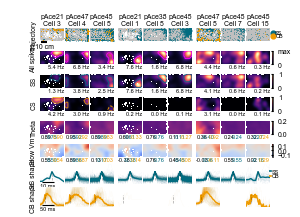

In [384]:
# ============================================================================
# Selected Example Cells - Combined Figure (3 groups with gaps)
# ============================================================================
# Note: Cell numbers are 1-indexed (user-facing), cell_idx in data is 0-indexed

# TUNABLE COLORBAR PARAMETERS
selected_theta_vlim = [0, 0.2]
selected_slow_vlim = [-0.15, 0.15]
plot_putative_PF= True  # Whether to plot dashed PF contours for putative place fields
show_place_cell_star = False  # Whether to show ★ marker for place cells
show_significance_marker = False  # Whether to show significance markers (*, **, ***)

# Helper function to find a cell by animal and cell_idx
def find_cell(cells_list, animal_pattern, cell_num):
    """Find a cell from cells_list matching animal pattern and cell number (1-indexed)."""
    cell_idx = cell_num - 1
    for cell in cells_list:
        session = cell.get('session', cell.get('animal_id', ''))
        if animal_pattern in session and cell.get('cell_idx') == cell_idx:
            return cell
    return None

# Define selections (user-specified cell numbers are 1-indexed)
# CS+ PLC: pAce21 cell 4, pAce38 cell 4, pAce45 cell 13
selected_csplus = [
    find_cell(plcs_csplus, 'pAce21', 3),
    find_cell(plcs_csplus, 'pAce47', 4),
    find_cell(plcs_csplus, 'pAce45', 5),
]

# CS- PLC: pAce21 cell 1, pAce38 cell 2, pAce45 cell 11
selected_csminus = [
    find_cell(plcs_csminus, 'pAce21', 1),
    find_cell(plcs_csminus, 'pAce38', 5),
    find_cell(plcs_csminus, 'pAce45', 3),
]

# Non-PLC: pAce21 cell 2, pAce38 cell 8, pAce45 cell 4
selected_nonplc = [
    find_cell(non_plcs, 'pAce47', 5),
    find_cell(non_plcs, 'pAce45', 7),
    find_cell(non_plcs, 'pAce45', 15),
]

# Verify and filter selections
def verify_and_filter(cells, group_name):
    print(f"Selected {group_name}:")
    for i, cell in enumerate(cells):
        if cell:
            print(f"  {i+1}. {cell['session']} cell {cell['cell_idx']+1}")
        else:
            print(f"  {i+1}. NOT FOUND")
    return [c for c in cells if c is not None]

selected_csplus = verify_and_filter(selected_csplus, "CS+ PLCs")
selected_csminus = verify_and_filter(selected_csminus, "CS- PLCs")
selected_nonplc = verify_and_filter(selected_nonplc, "Non-PLCs")

print(f"\nTotal: CS+={len(selected_csplus)}, CS-={len(selected_csminus)}, Non={len(selected_nonplc)}")

# Build groups, only include non-empty ones
cell_groups = []
group_names = []
for grp, name in [(selected_csplus, 'CS+ PLC'), (selected_csminus, 'CS- PLC'), (selected_nonplc, 'Non-PLC')]:
    if grp:
        cell_groups.append(grp)
        group_names.append(name)

# Plot combined figure with gaps between groups
if cell_groups:
    plot_selected_cells_figure(
        cell_groups=cell_groups,
        group_names=group_names,
        theta_vlim=selected_theta_vlim,
        slow_vlim=selected_slow_vlim,
        save_path=os.path.join(figure_save_folder, "SpatialHeatmaps_Selected_Combined.svg"),
        plot_putative_PF=plot_putative_PF,
        show_place_cell_star=show_place_cell_star,
        show_significance_marker=show_significance_marker,
        shape_ylim=(-0.5, 2.0),
    )
else:
    print("No cells selected in any group!")

## All CS+ PLCs

Plotting all 10 CS+ PLCs (max 10 per figure)
Rendering SpatialHeatmaps_All_CSplus_PLCs.svg: cells=10
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/SpatialHeatmaps_All_CSplus_PLCs.svg


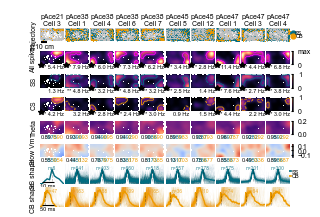

['/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/SpatialHeatmaps_All_CSplus_PLCs.svg']

In [385]:
import os

SPATIAL_SUBPLOT_WIDTH = 0.25
SPATIAL_MAX_CELLS_PER_FIGURE = 10


def _render_spatial_heatmap_chunks(cells, base_filename, **plot_kwargs):
    cells = list(cells)
    n_cells = len(cells)
    if n_cells == 0:
        print(f"No cells to plot for {base_filename}")
        return []

    max_per_fig = int(globals().get('SPATIAL_MAX_CELLS_PER_FIGURE', 10))
    max_per_fig = max(1, max_per_fig)
    n_chunks = (n_cells + max_per_fig - 1) // max_per_fig

    out_paths = []
    root, ext = os.path.splitext(base_filename)
    for i in range(n_chunks):
        chunk = cells[i * max_per_fig:(i + 1) * max_per_fig]
        if n_chunks == 1:
            filename = base_filename
        else:
            filename = f"{root}_part{i+1:02d}{ext}"
        out_path = os.path.join(figure_save_folder, filename)
        print(f"Rendering {filename}: cells={len(chunk)}")
        plot_selected_cells_figure(
            cell_groups=chunk,
            subplot_width=float(globals().get('SPATIAL_SUBPLOT_WIDTH', 0.25)),
            save_path=out_path,
            **plot_kwargs,
        )
        out_paths.append(out_path)
    return out_paths


plot_putative_PF= True  # Whether to plot dashed PF contours for putative place fields
show_place_cell_star = True  # Whether to show ★ marker for place cells
show_significance_marker = True  # Whether to show significance markers (*, **, ***)
# ============================================================================
# All CS+ PLCs Figure (single group, no gaps)
# ============================================================================
print(f"Plotting all {len(plcs_csplus)} CS+ PLCs (max {SPATIAL_MAX_CELLS_PER_FIGURE} per figure)")

_render_spatial_heatmap_chunks(
    plcs_csplus,
    "SpatialHeatmaps_All_CSplus_PLCs.svg",
    theta_vlim=selected_theta_vlim,
    slow_vlim=selected_slow_vlim,
    plot_putative_PF=plot_putative_PF,
    show_place_cell_star=show_place_cell_star,
    show_significance_marker=show_significance_marker,
    show_shape_counts=True,
)


## All CS- PLCs 

Plotting all 8 CS- PLCs (max 10 per figure)
Rendering SpatialHeatmaps_All_CSminus_PLCs.svg: cells=8
pAce21 Cell 1: CS PF mask is empty
pAce38 Cell 5: CS PF mask is empty
pAce45 Cell 3: CS PF mask is empty
pAce45 Cell 9: CS PF mask is empty
pAce47 Cell 2: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/SpatialHeatmaps_All_CSminus_PLCs.svg


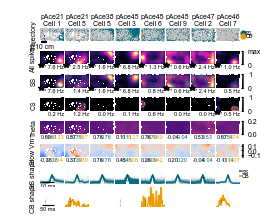

['/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/SpatialHeatmaps_All_CSminus_PLCs.svg']

In [386]:
# ============================================================================
# All CS- PLCs Figure (single group, no gaps)
# ============================================================================
print(f"Plotting all {len(plcs_csminus)} CS- PLCs (max {SPATIAL_MAX_CELLS_PER_FIGURE} per figure)")

_render_spatial_heatmap_chunks(
    plcs_csminus,
    "SpatialHeatmaps_All_CSminus_PLCs.svg",
    theta_vlim=selected_theta_vlim,
    slow_vlim=selected_slow_vlim,
    plot_putative_PF=plot_putative_PF,
    show_place_cell_star=show_place_cell_star,
    show_significance_marker=show_significance_marker,
)


## All Non-PLCs 

Plotting all 30 Non-PLCs (max 10 per figure)
Rendering SpatialHeatmaps_All_NonPLCs_part01.svg: cells=10
pAce21 Cell 4: CS PF mask is empty
pAce21 Cell 7: SS PF mask is empty
pAce21 Cell 8: All spikes PF mask is empty
pAce21 Cell 8: SS PF mask is empty
pAce21 Cell 8: CS PF mask is empty
pAce38 Cell 2: CS PF mask is empty
pAce38 Cell 3: CS PF mask is empty
pAce38 Cell 8: All spikes PF mask is empty
pAce38 Cell 9: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part01.svg


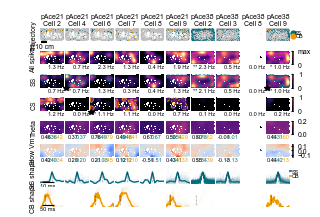

Rendering SpatialHeatmaps_All_NonPLCs_part02.svg: cells=10
pAce45 Cell 1: CS PF mask is empty
pAce45 Cell 2: CS PF mask is empty
pAce45 Cell 4: CS PF mask is empty
pAce45 Cell 7: CS PF mask is empty
pAce45 Cell 8: All spikes PF mask is empty
pAce45 Cell 8: SS PF mask is empty
pAce45 Cell 8: CS PF mask is empty
pAce45 Cell 10: CS PF mask is empty
pAce45 Cell 11: All spikes PF mask is empty
pAce45 Cell 11: SS PF mask is empty
pAce45 Cell 11: CS PF mask is empty
pAce45 Cell 13: CS PF mask is empty
pAce45 Cell 14: All spikes PF mask is empty
pAce45 Cell 14: SS PF mask is empty
pAce45 Cell 14: CS PF mask is empty
pAce45 Cell 15: All spikes PF mask is empty
pAce45 Cell 15: SS PF mask is empty
pAce45 Cell 15: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part02.svg


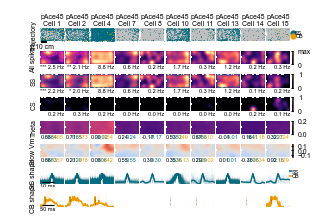

Rendering SpatialHeatmaps_All_NonPLCs_part03.svg: cells=10
pAce45 Cell 16: CS PF mask is empty
pAce46 Cell 1: CS PF mask is empty
pAce46 Cell 2: All spikes PF mask is empty
pAce46 Cell 2: SS PF mask is empty
pAce46 Cell 2: CS PF mask is empty
pAce46 Cell 3: CS PF mask is empty
pAce46 Cell 4: CS PF mask is empty
pAce46 Cell 6: SS PF mask is empty
pAce46 Cell 6: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part03.svg


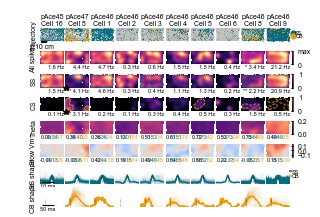

['/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part01.svg',
 '/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part02.svg',
 '/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part03.svg']

In [387]:
pf_only_place_cells=False
# ============================================================================
# All Non-PLCs Figure (single group, no gaps)
# ============================================================================
print(f"Plotting all {len(non_plcs)} Non-PLCs (max {SPATIAL_MAX_CELLS_PER_FIGURE} per figure)")

_render_spatial_heatmap_chunks(
    non_plcs,
    "SpatialHeatmaps_All_NonPLCs.svg",
    theta_vlim=selected_theta_vlim,
    slow_vlim=selected_slow_vlim,
    plot_putative_PF=plot_putative_PF,
    show_place_cell_star=show_place_cell_star,
    show_significance_marker=show_significance_marker,
    pf_only_place_cells=pf_only_place_cells,
)


In [324]:
# DIAGNOSTIC: Check SS/CS place field mask status for cells marked as is_place_cell_ss=True
# This verifies whether the bug fix in GRC_helpers.py has been applied

print("="*70)
print("DIAGNOSTIC: Checking SS/CS place field mask status")
print("="*70)

# Check for SS-only place cells (should have non-empty ss_place_field_mask)
ss_only_cells = []
ss_mask_status = {'has_mask': 0, 'empty_mask': 0, 'no_mask': 0}

for cell in valid_spatial_cells:
    is_ss = cell.get('is_place_cell_ss', False)
    is_all = cell.get('is_place_cell', False)
    
    if is_ss:
        mask = cell.get('ss_place_field_mask', None)
        if mask is None:
            ss_mask_status['no_mask'] += 1
        elif np.any(mask):
            ss_mask_status['has_mask'] += 1
        else:
            ss_mask_status['empty_mask'] += 1
        
        # Track SS-only cells specifically  
        if is_ss and not is_all:
            ss_only_cells.append({
                'session': cell['session'],
                'cell_idx': cell['cell_idx'],
                'mask_present': mask is not None,
                'mask_nonzero': np.any(mask) if mask is not None else False,
                'mask_sum': np.sum(mask) if mask is not None else 0
            })

print(f"\nCells with is_place_cell_ss=True (n={sum(ss_mask_status.values())}):")
print(f"  Has non-empty mask: {ss_mask_status['has_mask']}")
print(f"  Has empty mask (all zeros): {ss_mask_status['empty_mask']}")
print(f"  No mask attribute: {ss_mask_status['no_mask']}")

print(f"\nSS-only place cells (is_place_cell_ss=True, is_place_cell=False):")
if ss_only_cells:
    for c in ss_only_cells:
        status = "✓ HAS CONTOUR" if c['mask_nonzero'] else "✗ NO CONTOUR (mask empty)"
        print(f"  {c['session']} cell {c['cell_idx']}: {status}")
else:
    print("  None found")

# Check if bug is still present
if ss_mask_status['empty_mask'] > 0:
    print("\n" + "="*70)
    print("⚠️  BUG DETECTED: Some cells have is_place_cell_ss=True but empty masks!")
    print("   You need to re-run Figures.ipynb for each animal to regenerate data.")
    print("="*70)
else:
    print("\n✓ All SS place cells have valid masks - data is up to date.")

DIAGNOSTIC: Checking SS/CS place field mask status

Cells with is_place_cell_ss=True (n=15):
  Has non-empty mask: 15
  Has empty mask (all zeros): 0
  No mask attribute: 0

SS-only place cells (is_place_cell_ss=True, is_place_cell=False):
  CKII_pAce21_PR_20250806 cell 3: ✓ HAS CONTOUR
  CKII_pAce38_PX_20251126 cell 8: ✓ HAS CONTOUR
  CKII_pAce47_PX_20260128 cell 4: ✓ HAS CONTOUR

✓ All SS place cells have valid masks - data is up to date.


# 0. State-Dep Firing Rates (All Cells)

In [325]:
# Helper functions (consistent with other PooledFigure notebooks)

def _paired_test(vals_in, vals_out):
    """Paired statistical test with normality check."""
    vals_in = np.asarray(vals_in, dtype=float)
    vals_out = np.asarray(vals_out, dtype=float)
    n_pairs = min(len(vals_in), len(vals_out))
    if n_pairs == 0:
        return np.nan, np.nan, 'n/a', 0, np.nan
    paired_in = vals_in[:n_pairs]
    paired_out = vals_out[:n_pairs]
    valid = np.isfinite(paired_in) & np.isfinite(paired_out)
    n_valid = int(np.sum(valid))
    if n_valid < 3:
        return np.nan, np.nan, 'n/a', n_valid, np.nan
    diffs = paired_in[valid] - paired_out[valid]
    try:
        shapiro_p = scipy_stats.shapiro(diffs).pvalue
    except ValueError:
        shapiro_p = np.nan
    # With very small n, prefer nonparametric tests regardless of normality.
    if n_valid < 5:
        try:
            result = scipy_stats.wilcoxon(paired_in[valid], paired_out[valid])
            return result.pvalue, result.statistic, 'wilcoxon', n_valid, shapiro_p
        except ValueError:
            return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p
    if np.isfinite(shapiro_p) and shapiro_p >= 0.05:
        result = scipy_stats.ttest_rel(paired_in[valid], paired_out[valid], nan_policy='omit')
        return result.pvalue, result.statistic, 'paired t-test', n_valid, shapiro_p
    try:
        result = scipy_stats.wilcoxon(paired_in[valid], paired_out[valid])
        return result.pvalue, result.statistic, 'wilcoxon', n_valid, shapiro_p
    except ValueError:
        return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p

def _sig_label(p_val):
    """Convert p-value to significance label."""
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001:
        return '***'
    if p_val < 0.01:
        return '**'
    if p_val < 0.05:
        return '*'
    return 'n.s.'

def unpaired_test_auto(data1, data2):
    """Perform unpaired comparison with automatic normality check."""
    data1 = np.asarray(data1, dtype=float)
    data2 = np.asarray(data2, dtype=float)
    data1 = data1[np.isfinite(data1)]
    data2 = data2[np.isfinite(data2)]
    
    if len(data1) < 3 or len(data2) < 3:
        return np.nan, 'n/a', np.nan, np.nan
    
    try:
        shapiro_p1 = scipy_stats.shapiro(data1).pvalue
    except ValueError:
        shapiro_p1 = 0.0
    try:
        shapiro_p2 = scipy_stats.shapiro(data2).pvalue
    except ValueError:
        shapiro_p2 = 0.0
    
    # With very small n, prefer nonparametric tests regardless of normality.
    if min(len(data1), len(data2)) < 5:
        stat, p_val = scipy_stats.mannwhitneyu(data1, data2, alternative='two-sided')
        test_name = "Mann-Whitney"
    elif shapiro_p1 >= 0.05 and shapiro_p2 >= 0.05:
        stat, p_val = scipy_stats.ttest_ind(data1, data2)
        test_name = "t-test"
    else:
        stat, p_val = scipy_stats.mannwhitneyu(data1, data2, alternative='two-sided')
        test_name = "Mann-Whitney"
    
    return p_val, test_name, shapiro_p1, shapiro_p2

def one_sample_test_auto(data, popmean=0.0, alpha=0.05):
    """Perform one-sample comparison vs `popmean` with automatic normality check."""
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    n = int(data.size)
    if n < 3:
        return np.nan, np.nan, 'n/a', n, np.nan
    try:
        shapiro_p = scipy_stats.shapiro(data).pvalue
    except ValueError:
        shapiro_p = np.nan
    # With very small n, prefer nonparametric tests regardless of normality.
    if n < 5:
        try:
            res = scipy_stats.wilcoxon(data - popmean)
            return res.pvalue, res.statistic, 'Wilcoxon signed-rank', n, shapiro_p
        except ValueError:
            return np.nan, np.nan, 'Wilcoxon signed-rank', n, shapiro_p
    if np.isfinite(shapiro_p) and shapiro_p >= alpha:
        res = scipy_stats.ttest_1samp(data, popmean, nan_policy='omit')
        return res.pvalue, res.statistic, 'one-sample t-test', n, shapiro_p
    try:
        res = scipy_stats.wilcoxon(data - popmean)
        return res.pvalue, res.statistic, 'Wilcoxon signed-rank', n, shapiro_p
    except ValueError:
        return np.nan, np.nan, 'Wilcoxon signed-rank', n, shapiro_p

def _global_ylim(arrays, pad_frac=0.05, pct_low=1, pct_high=100):
    """Compute global y-limits using percentiles."""
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        if arr.size == 0:
            continue
        finite = arr[np.isfinite(arr)]
        if finite.size > 0:
            vals.append(finite)
    if not vals:
        return None
    merged = np.concatenate(vals)
    y_min = np.percentile(merged, pct_low)
    y_max = np.percentile(merged, pct_high)
    y_span = y_max - y_min if y_max != y_min else 1.0
    pad = pad_frac * y_span
    return y_min - pad, y_max + pad

# Fixed median color for all violin plots
VIOLIN_MEDIAN_COLOR = '#1F77B4'
VIOLIN_MEDIAN_LINEWIDTH = 1.0

def _style_violin_medians(parts, color='#1F77B4', linewidth=None):
    """Apply consistent styling to violin plot medians.
    
    Args:
        parts: dict returned by ax.violinplot()
        color: median line color (default: VIOLIN_MEDIAN_COLOR)
        linewidth: median line width (default: VIOLIN_MEDIAN_LINEWIDTH)
    """
    if color is None:
        color = VIOLIN_MEDIAN_COLOR
    if linewidth is None:
        linewidth = VIOLIN_MEDIAN_LINEWIDTH
    if 'cmedians' in parts:
        parts['cmedians'].set_color(color)
        parts['cmedians'].set_linewidth(linewidth)

def plot_violin_panel(ax, vals_in, vals_out, ylabel, ylim=None, show_ylabel=True, sig_y=None):
    """Plot a single violin panel with paired data."""
    xlim = (0.5, 2.5)
    vals_in = np.asarray(vals_in, dtype=float)
    vals_out = np.asarray(vals_out, dtype=float)
    
    plot_data = []
    for vals in [vals_in, vals_out]:
        finite = vals[np.isfinite(vals)]
        if finite.size == 0:
            finite = np.array([np.nan])
        plot_data.append(finite)

    if all(len(arr) < 2 or np.all(np.isnan(arr)) for arr in plot_data):
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_xlim(*xlim)
        if show_ylabel:
            ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        return

    parts = ax.violinplot(plot_data, positions=[1, 2], showmedians=True, showextrema=False)
    for body in parts['bodies']:
        body.set_alpha(0.3)
    if len(parts['bodies']) >= 2:
        parts['bodies'][0].set_facecolor('magenta')
        parts['bodies'][1].set_facecolor('gray')
        parts['bodies'][0].set_edgecolor('none')
        parts['bodies'][1].set_edgecolor('none')

    # Paired lines
    n_pairs = min(len(vals_in), len(vals_out))
    for i in range(n_pairs):
        if np.isfinite(vals_in[i]) and np.isfinite(vals_out[i]):
            ax.plot([1, 2], [vals_in[i], vals_out[i]], color='black', alpha=0.3, linewidth=0.6)

    # Scatter points
    rng = np.random.default_rng(0)
    for idx, vals in enumerate([vals_in, vals_out], start=1):
        finite_mask = np.isfinite(vals)
        if not np.any(finite_mask):
            continue
        jitter = (rng.random(np.sum(finite_mask)) - 0.5) * 0.12
        xs = idx + jitter
        ax.scatter(xs, vals[finite_mask], s=8, color='black', alpha=0.6, linewidths=0)

    # Statistics
    p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test(vals_in, vals_out)
    sig_label = _sig_label(p_val)
    if sig_label:
        if sig_y is not None:
            y_star = sig_y
        elif ylim is not None:
            y0, y1 = ylim
            y_star = y1 - 0.05 * (y1 - y0)
        else:
            y_vals = np.concatenate([vals_in[np.isfinite(vals_in)], vals_out[np.isfinite(vals_out)]])
            if y_vals.size > 0:
                y_max = np.nanmax(y_vals)
                y_star = y_max + 0.08 * (y_max - np.nanmin(y_vals))
            else:
                y_star = 1.0
        ax.text(1.5, y_star, sig_label, ha='center', va='bottom', fontsize=6, fontname='Arial')

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['In PF', 'Out PF'], fontsize=5, fontname='Arial')
    if show_ylabel:
        ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
    ax.tick_params(labelsize=5)
    ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    return p_val, test_stat, test_name, n_valid, shapiro_p

print('Helper functions defined')

Helper functions defined


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/firing_rates_all_cells.svg


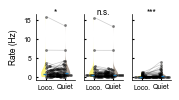


FIRING RATES: Locomotion vs Quiet (All Cells)

ALL spikes (n=48 cells):
  Loco:  1.46 ± 2.45 Hz
  Quiet: 1.72 ± 2.24 Hz
  Test:  wilcoxon, p = 1.88e-02

SS spikes (n=48 cells):
  Loco:  1.21 ± 2.40 Hz
  Quiet: 1.14 ± 2.11 Hz
  Test:  wilcoxon, p = 4.85e-01

CS spikes (n=48 cells):
  Loco:  0.25 ± 0.37 Hz
  Quiet: 0.58 ± 0.88 Hz
  Test:  wilcoxon, p = 1.84e-05


In [326]:
# Firing Rates - Locomotion vs Quiet (All Cells)
# Half-violin style: violin on outer side, dots + paired lines on inner side

from matplotlib.collections import PolyCollection

panel_w, panel_h = 0.6, 1.
fig, axes = plt.subplots(1, 3, figsize=(panel_w * 3, panel_h), sharex=True, sharey=True)

run_color = "#f9e800ff"
rest_color = "#563c25"

# Compute global ylim across all spike types for consistent significance label placement
all_data = []
for spike_type in ['all', 'ss', 'cs']:
    all_data.append(df_all[f'{spike_type}_rate_loco'].dropna().values)
    all_data.append(df_all[f'{spike_type}_rate_quiet'].dropna().values)
global_ylim = _global_ylim(all_data)

# Collect stats for printing
stats_results = []

for ax, spike_type in zip(axes, ['all', 'ss', 'cs']):
    data_loco = df_all[f'{spike_type}_rate_loco'].dropna().values
    data_quiet = df_all[f'{spike_type}_rate_quiet'].dropna().values

    # Draw half violins
    parts = ax.violinplot([data_loco, data_quiet], positions=[1, 2],
                          showmedians=True, showextrema=False)
    _style_violin_medians(parts)

    for i, body in enumerate(parts['bodies']):
        # Get the path vertices
        paths = body.get_paths()[0]
        verts = paths.vertices
        if i == 0:
            # Loco (pos=1): keep left half only (x <= position)
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, 1)
            body.set_facecolor(run_color)
        else:
            # Quiet (pos=2): keep right half only (x >= position)
            verts[:, 0] = np.clip(verts[:, 0], 2, np.inf)
            body.set_facecolor(rest_color)
        body.set_edgecolor('none')
        body.set_alpha(0.5)

    # Clip median lines too
    for pc in [parts['cmedians']]:
        segs = pc.get_segments()
        new_segs = []
        for j, seg in enumerate(segs):
            if j == 0:  # Loco: median on left half
                seg[:, 0] = np.clip(seg[:, 0], -np.inf, 1)
            else:  # Quiet: median on right half
                seg[:, 0] = np.clip(seg[:, 0], 2, np.inf)
            new_segs.append(seg)
        pc.set_segments(new_segs)

    # Paired lines on inner side (between positions 1 and 2)
    n_pairs = min(len(data_loco), len(data_quiet))
    for i in range(n_pairs):
        if np.isfinite(data_loco[i]) and np.isfinite(data_quiet[i]):
            ax.plot([1.08, 1.92], [data_loco[i], data_quiet[i]],
                    color='black', alpha=0.2, linewidth=0.5)

    # Beeswarm dots on inner side
    def _beeswarm_xs(vals, base_x, direction=1):
        vals = np.asarray(vals, dtype=float)
        y_range = np.ptp(vals) if len(vals) > 1 else 1.0
        y_spacing = y_range * 0.04
        x_step = 0.06
        sorted_idx = np.argsort(vals)
        xs = np.zeros(len(vals))
        for si, oi in enumerate(sorted_idx):
            layer = 0
            while True:
                candidate = x_step * layer
                conflict = False
                for sj in range(si):
                    oj = sorted_idx[sj]
                    if abs(vals[oi] - vals[oj]) < y_spacing:
                        if abs(candidate - xs[oj]) < x_step * 0.9:
                            conflict = True
                            break
                if not conflict:
                    xs[oi] = candidate
                    break
                layer += 1
        return base_x + direction * (0.02 + xs)
    # Loco dots on right side of pos 1
    xs_loco = _beeswarm_xs(data_loco, 1.0, direction=1)
    ax.scatter(xs_loco, data_loco, s=4, color='black', alpha=0.5, linewidths=0)
    # Quiet dots on left side of pos 2
    xs_quiet = _beeswarm_xs(data_quiet, 2.0, direction=-1)
    ax.scatter(xs_quiet, data_quiet, s=4, color='black', alpha=0.5, linewidths=0)

    # Stats (paired test)
    p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test(data_loco, data_quiet)
    sig = _sig_label(p_val)
    stats_results.append({
        'spike_type': spike_type.upper(),
        'n_cells': n_valid,
        'test': test_name,
        'p_value': p_val,
        'loco_mean': np.nanmean(data_loco),
        'loco_std': np.nanstd(data_loco),
        'quiet_mean': np.nanmean(data_quiet),
        'quiet_std': np.nanstd(data_quiet)
    })

    if global_ylim:
        ax.text(1.5, global_ylim[1] - 0.05 * (global_ylim[1] - global_ylim[0]),
                sig, ha='center', va='bottom', fontsize=6)
        ax.set_ylim(*global_ylim)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Loco.', 'Quiet'], fontsize=5)
    ax.set_ylabel('Rate (Hz)' if ax == axes[0] else '', fontsize=6)
    ax.set_xlim(0.5, 2.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
save_path = os.path.join(figure_save_folder, 'firing_rates_all_cells.svg')
plt.savefig(save_path, dpi=300)
print(f'Saved: {save_path}')
plt.show()

# Print stats summary
print("\n" + "="*70)
print("FIRING RATES: Locomotion vs Quiet (All Cells)")
print("="*70)
for res in stats_results:
    print(f"\n{res['spike_type']} spikes (n={res['n_cells']} cells):")
    print(f"  Loco:  {res['loco_mean']:.2f} ± {res['loco_std']:.2f} Hz")
    print(f"  Quiet: {res['quiet_mean']:.2f} ± {res['quiet_std']:.2f} Hz")
    print(f"  Test:  {res['test']}, p = {res['p_value']:.2e}")

/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67869/2046511741.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/rate_scatter_all_types.svg


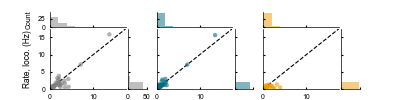

In [327]:
# Firing Rates - Scatter: Quiet (x) vs Locomotion (y)
# With marginal histograms, 3 panels side by side, shared axes

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

ss_color = '#026C80'
cs_color = '#EE9B00'

spike_configs = [
    ('all', 'All spikes', 'gray'),
    ('ss', 'SS', ss_color),
    ('cs', 'CS', cs_color),
]

# Compute global axis limit across all spike types
global_max = 0
for spike_type, _, _ in spike_configs:
    vals = df_all[[f'{spike_type}_rate_quiet', f'{spike_type}_rate_loco']].dropna().values
    if vals.size > 0:
        global_max = max(global_max, np.nanmax(vals))
lim_max = global_max * 1.1

fig = plt.figure(figsize=(4,1))
outer_gs = GridSpec(1, 3, figure=fig, wspace=0.1)

shared_main = None
shared_histx = None
shared_histy = None

for col, (spike_type, label, color) in enumerate(spike_configs):
    col_quiet = f'{spike_type}_rate_quiet'
    col_loco = f'{spike_type}_rate_loco'

    paired = df_all[[col_quiet, col_loco]].dropna()
    x = paired[col_quiet].values
    y = paired[col_loco].values

    inner_gs = GridSpecFromSubplotSpec(
        2, 2, subplot_spec=outer_gs[col],
        width_ratios=[4, 1], height_ratios=[1, 4],
        wspace=0.05, hspace=0.05,
    )

    share_kw_main = dict(sharex=shared_main, sharey=shared_main) if shared_main else {}
    ax_main = fig.add_subplot(inner_gs[1, 0], **share_kw_main)
    if shared_main is None:
        shared_main = ax_main

    share_kw_histx = dict(sharey=shared_histx) if shared_histx else {}
    ax_histx = fig.add_subplot(inner_gs[0, 0], sharex=ax_main, **share_kw_histx)
    if shared_histx is None:
        shared_histx = ax_histx

    share_kw_histy = dict(sharex=shared_histy) if shared_histy else {}
    ax_histy = fig.add_subplot(inner_gs[1, 1], sharey=ax_main, **share_kw_histy)
    if shared_histy is None:
        shared_histy = ax_histy

    ax_empty = fig.add_subplot(inner_gs[0, 1])
    ax_empty.axis('off')

    # Scatter
    ax_main.scatter(x, y, s=10, color=color, alpha=0.6, edgecolors='none')

    # Unity line
    ax_main.plot([0, lim_max], [0, lim_max], 'k--', linewidth=0.8, zorder=0)
    ax_main.set_xlim(0, lim_max)
    ax_main.set_ylim(0, lim_max)
    ax_main.set_xlabel('Rate, quiet (Hz)', fontsize=6)
    ax_main.set_title(label, fontsize=7)
    ax_main.spines['top'].set_visible(False)
    ax_main.spines['right'].set_visible(False)

    # Only first column gets y-axis labels
    if col == 0:
        ax_main.set_ylabel('Rate, loco. (Hz)', fontsize=6)
    else:
        ax_main.tick_params(labelleft=False)

    # Marginal histograms
    bins = np.linspace(0, lim_max, 10)

    ax_histx.hist(x, bins=bins, color=color, alpha=0.5, edgecolor='none')
    ax_histx.tick_params(labelbottom=False, labelsize=5)
    ax_histx.spines['top'].set_visible(False)
    ax_histx.spines['right'].set_visible(False)
    if col == 0:
        ax_histx.set_ylabel('Count', fontsize=5)
    else:
        ax_histx.tick_params(labelleft=False)

    ax_histy.hist(y, bins=bins, orientation='horizontal', color=color, alpha=0.5, edgecolor='none')
    ax_histy.tick_params(labelleft=False, labelsize=5)
    ax_histy.spines['top'].set_visible(False)
    ax_histy.spines['right'].set_visible(False)
    if col == 0:
        ax_histy.set_xlabel('Count', fontsize=5)
    else:
        ax_histy.tick_params(labelbottom=False)

plt.tight_layout()
save_path = os.path.join(figure_save_folder, 'rate_scatter_all_types.svg')
fig.savefig(save_path, dpi=300)
print(f'Saved: {save_path}')
plt.show()

# 1. Peak Rates (Place Cells)

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/peak_rates_all_ss_cs.svg


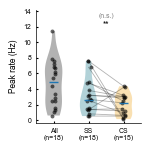


PEAK RATES: All, SS, CS (Place Cells)
All: n=18 cells, 4.74 ± 2.90 Hz
SS:  n=18 cells, 3.16 ± 2.25 Hz
CS:  n=15 cells, 2.01 ± 1.37 Hz
SS vs CS (paired, n=15): wilcoxon, p = 6.71e-03 **
SS vs CS (unpaired): Mann-Whitney, p = 1.64e-01 n.s.


In [328]:
# Peak Rates - Violin plot (All, SS, CS)
# Display all cells for each group; paired test for matched cells, unpaired if sample sizes differ
panel_w, panel_h = 1.5, 1.5
fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))

all_color = 'black'
ss_color = '#026C80'
cs_color = '#EE9B00'

# Get all data
all_data_raw = df_pc['peak_rate_all'].values
ss_data = df_pc['peak_rate_ss'].values
cs_data = df_pc['peak_rate_cs'].values

# All cells with finite values for each group (for display)
all_valid = all_data_raw[np.isfinite(all_data_raw)]
ss_all = ss_data[np.isfinite(ss_data)]  # All SS cells
cs_all = cs_data[np.isfinite(cs_data) & (cs_data > 0)]  # All CS cells with CS > 0

# Paired data: cells with both SS and CS valid (and CS > 0)
paired_mask = np.isfinite(ss_data) & np.isfinite(cs_data) & (cs_data > 0)
ss_paired = ss_data[paired_mask]
cs_paired = cs_data[paired_mask]

ylim = _global_ylim([all_valid, ss_all, cs_all])

# Violin plot - All at position 1, SS at position 2, CS at position 3
if len(all_valid) >= 3:
    parts_all = ax.violinplot([all_valid], positions=[1], showmedians=True, showextrema=False)
    _style_violin_medians(parts_all)
    for body in parts_all['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(all_color)
        body.set_edgecolor('none')

if len(ss_all) >= 3:
    parts_ss = ax.violinplot([ss_all], positions=[2], showmedians=True, showextrema=False)
    _style_violin_medians(parts_ss)
    for body in parts_ss['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(ss_color)
        body.set_edgecolor('none')

if len(cs_all) >= 3:
    parts_cs = ax.violinplot([cs_all], positions=[3], showmedians=True, showextrema=False)
    _style_violin_medians(parts_cs)
    for body in parts_cs['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(cs_color)
        body.set_edgecolor('none')

# Paired lines (SS to CS for paired cells only)
for i in range(len(ss_paired)):
    ax.plot([2, 3], [ss_paired[i], cs_paired[i]], color='black', alpha=0.3, linewidth=0.6)

# Scatter points - ALL cells for each group
rng = np.random.default_rng(0)
if len(all_valid) > 0:
    jitter_all = (rng.random(len(all_valid)) - 0.5) * 0.12
    ax.scatter(1 + jitter_all, all_valid, s=8, color='black', alpha=0.6, linewidths=0)
if len(ss_all) > 0:
    jitter_ss = (rng.random(len(ss_all)) - 0.5) * 0.12
    ax.scatter(2 + jitter_ss, ss_all, s=8, color='black', alpha=0.6, linewidths=0)
if len(cs_all) > 0:
    jitter_cs = (rng.random(len(cs_all)) - 0.5) * 0.12
    ax.scatter(3 + jitter_cs, cs_all, s=8, color='black', alpha=0.6, linewidths=0)

# Stats: paired test (for matched cells)
p_paired, _, test_name_paired, _, _ = _paired_test(ss_paired, cs_paired) if len(ss_paired) >= 3 else (np.nan, None, 'N/A', 0, None)
sig_paired = _sig_label(p_paired)

# Unpaired test (if sample sizes differ)
do_unpaired = len(ss_all) != len(cs_all)
if do_unpaired and len(ss_all) >= 3 and len(cs_all) >= 3:
    p_unpaired, test_name_unpaired, _, _ = unpaired_test_auto(ss_all, cs_all)
    sig_unpaired = _sig_label(p_unpaired)
else:
    p_unpaired, test_name_unpaired, sig_unpaired = np.nan, 'N/A', None

# Display significance
if ylim:
    y_range = ylim[1] - ylim[0]
    ax.text(2.5, ylim[1] - 0.02 * y_range, sig_paired, ha='center', va='bottom', fontsize=6)
    if do_unpaired and sig_unpaired:
        ax.text(2.5, ylim[1] + 0.08 * y_range, f'({sig_unpaired})', ha='center', va='bottom', fontsize=5, color='gray')
    ax.set_ylim(ylim[0], ylim[1] + 0.18 * y_range)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels([f'All\n(n={len(all_valid)})', f'SS\n(n={len(ss_all)})', f'CS\n(n={len(cs_all)})'], fontsize=5)
ax.set_ylabel('Peak rate (Hz)', fontsize=6)
ax.set_xlim(0.5, 3.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
save_path = os.path.join(figure_save_folder, 'peak_rates_all_ss_cs.svg')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

# Print stats
print("\n" + "="*70)
print("PEAK RATES: All, SS, CS (Place Cells)")
print("="*70)
print(f"All: n={len(all_valid)} cells, {np.mean(all_valid):.2f} ± {np.std(all_valid):.2f} Hz")
print(f"SS:  n={len(ss_all)} cells, {np.mean(ss_all):.2f} ± {np.std(ss_all):.2f} Hz")
print(f"CS:  n={len(cs_all)} cells, {np.mean(cs_all):.2f} ± {np.std(cs_all):.2f} Hz")
if len(ss_paired) >= 3:
    print(f"SS vs CS (paired, n={len(ss_paired)}): {test_name_paired}, p = {p_paired:.2e} {sig_paired}")
if do_unpaired and len(ss_all) >= 3 and len(cs_all) >= 3:
    print(f"SS vs CS (unpaired): {test_name_unpaired}, p = {p_unpaired:.2e} {sig_unpaired}")

CS+ PLCs: n = 10
CS- PLCs: n = 8
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/peak_rates_cs_plus_minus_plc.svg


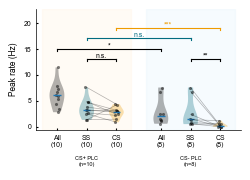


PEAK RATES: CS+ PLC vs CS- PLC

CS+ PLC (n=10):
  All: 6.16 ± 2.34 Hz
  SS:  3.53 ± 1.77 Hz
  CS:  2.75 ± 1.03 Hz

CS- PLC (n=8):
  All: 2.96 ± 2.52 Hz
  SS:  2.70 ± 2.66 Hz
  CS:  0.32 ± 0.38 Hz

Statistics:
  CS+ PLC: SS vs CS (paired t-test) p = 1.74e-01
  CS- PLC: SS vs CS (wilcoxon) p = 7.81e-03
  All: CS+ vs CS- (Mann-Whitney) p = 2.66e-02
  SS: CS+ vs CS- (Mann-Whitney) p = 1.73e-01
  CS: CS+ vs CS- (t-test) p = 1.98e-05


In [329]:
# Peak Rates - CS+ PLC vs CS- PLC (6-group figure)
# Groups: CS+ PC (All, SS, CS) | CS- PC (All, SS, CS)
# Paired tests within groups, unpaired tests between groups

from scipy import stats as scipy_stats

# Split place cells by is_cs_plc classification
df_cs_plc = df_pc[df_pc['is_cs_plc'] == True].copy()
df_non_cs_plc = df_pc[df_pc['is_cs_plc'] == False].copy()

print(f"CS+ PLCs: n = {len(df_cs_plc)}")
print(f"CS- PLCs: n = {len(df_non_cs_plc)}")

all_color = 'black'
ss_color = '#026C80'
cs_color = '#EE9B00'
cs_plc_bg = '#FFF3E0'  # Light orange background for CS+ place cells
non_cs_plc_bg = '#E3F2FD'  # Light blue background for CS- place cells

def add_bracket(ax, pos1, pos2, y, h, sig_text, color='black'):
    """Add a significance bracket between two positions."""
    drop = h
    ax.plot([pos1, pos1], [y, y + drop], color=color, linewidth=0.8)
    ax.plot([pos2, pos2], [y, y + drop], color=color, linewidth=0.8)
    ax.plot([pos1, pos2], [y + drop, y + drop], color=color, linewidth=0.8)
    ax.text((pos1 + pos2) / 2, y + drop + 0.02, sig_text, ha='center', va='bottom', fontsize=5, fontname='Arial', color=color)

def unpaired_test_auto(data1, data2):
    """Perform unpaired comparison with automatic normality check."""
    data1 = np.asarray(data1, dtype=float)
    data2 = np.asarray(data2, dtype=float)
    data1 = data1[np.isfinite(data1)]
    data2 = data2[np.isfinite(data2)]
    
    if len(data1) < 3 or len(data2) < 3:
        return np.nan, 'n/a', np.nan, np.nan
    
    try:
        shapiro_p1 = scipy_stats.shapiro(data1).pvalue
    except ValueError:
        shapiro_p1 = 0.0
    try:
        shapiro_p2 = scipy_stats.shapiro(data2).pvalue
    except ValueError:
        shapiro_p2 = 0.0
    
    # With very small n, prefer nonparametric tests regardless of normality.
    if min(len(data1), len(data2)) < 5:
        stat, p_val = scipy_stats.mannwhitneyu(data1, data2, alternative='two-sided')
        test_name = "Mann-Whitney"
    elif shapiro_p1 >= 0.05 and shapiro_p2 >= 0.05:
        stat, p_val = scipy_stats.ttest_ind(data1, data2)
        test_name = "t-test"
    else:
        stat, p_val = scipy_stats.mannwhitneyu(data1, data2, alternative='two-sided')
        test_name = "Mann-Whitney"
    
    return p_val, test_name, shapiro_p1, shapiro_p2

def get_peak_rate_data(df_subset, peak_cs_vals):
    """Get All, SS, CS peak rate data with proper filtering."""
    all_data = df_subset['peak_rate_all'].values
    ss_data = df_subset['peak_rate_ss'].values
    cs_data = df_subset['peak_rate_cs'].values
    
    all_valid = all_data[np.isfinite(all_data)]
    ss_valid = ss_data[np.isfinite(ss_data)]
    # Include all cells with finite CS data (including 0)
    cs_valid = cs_data[np.isfinite(cs_data)]
    
    # For paired test: need both SS and CS valid (finite)
    paired_mask = np.isfinite(ss_data) & np.isfinite(cs_data)
    ss_paired = ss_data[paired_mask]
    cs_paired = cs_data[paired_mask]
    
    return all_valid, ss_valid, cs_valid, ss_paired, cs_paired

# Get peak_cs for filtering
peak_cs_csplc = df_cs_plc['peak_rate_cs'].values
peak_cs_noncsplc = df_non_cs_plc['peak_rate_cs'].values

# Get data
cs_all, cs_ss, cs_cs, cs_ss_paired, cs_cs_paired = get_peak_rate_data(df_cs_plc, peak_cs_csplc)
non_all, non_ss, non_cs, non_ss_paired, non_cs_paired = get_peak_rate_data(df_non_cs_plc, peak_cs_noncsplc)

# Create figure
panel_w, panel_h = 2.5, 1.8
fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))

positions = [1, 2, 3, 4.5, 5.5, 6.5]

# Add background shading
ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg, zorder=0)
ax.axvspan(4.0, 7.0, alpha=0.3, color=non_cs_plc_bg, zorder=0)

# Add group labels at bottom
ax.text(2, -0.22, f'CS+ PLC\n(n={len(df_cs_plc)})', ha='center', va='top', 
        fontsize=4, fontname='Arial', transform=ax.get_xaxis_transform())
ax.text(5.5, -0.22, f'CS- PLC\n(n={len(df_non_cs_plc)})', ha='center', va='top', 
        fontsize=4, fontname='Arial', transform=ax.get_xaxis_transform())

data_list = [cs_all, cs_ss, cs_cs, non_all, non_ss, non_cs]
colors_list = [all_color, ss_color, cs_color, all_color, ss_color, cs_color]

# Get global ylim
all_data_flat = np.concatenate([d for d in data_list if len(d) > 0])
ylim = _global_ylim(data_list) if len(all_data_flat) > 0 else None

# Plot violins
for pos, data, c in zip(positions, data_list, colors_list):
    if len(data) >= 3:
        parts = ax.violinplot([data], positions=[pos], showmedians=True, showextrema=False)
        _style_violin_medians(parts)
        for body in parts['bodies']:
            body.set_alpha(0.3)
            body.set_facecolor(c)
            body.set_edgecolor('none')

# Paired lines within each group
for i in range(len(cs_ss_paired)):
    ax.plot([2, 3], [cs_ss_paired[i], cs_cs_paired[i]], color='black', alpha=0.3, linewidth=0.5)
for i in range(len(non_ss_paired)):
    ax.plot([5.5, 6.5], [non_ss_paired[i], non_cs_paired[i]], color='black', alpha=0.3, linewidth=0.5)

# Scatter points
rng = np.random.default_rng(42)
for pos, data in zip(positions, data_list):
    if len(data) >= 1:
        jitter = (rng.random(len(data)) - 0.5) * 0.12
        ax.scatter(pos + jitter, data, s=5, color='black', alpha=0.5, linewidths=0)

# Formatting
ax.set_ylabel('Peak rate (Hz)', fontsize=6, fontname='Arial')
ax.set_xticks(positions)
ax.set_xticklabels([f'All\n({len(cs_all)})', f'SS\n({len(cs_ss)})', f'CS\n({len(cs_cs)})',
                   f'All\n({len(non_all)})', f'SS\n({len(non_ss)})', f'CS\n({len(non_cs)})'], fontsize=4, fontname='Arial')
ax.set_xlim(0.3, 7.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=5)

# Significance tests and brackets
if ylim:
    y_range = ylim[1] - ylim[0]
    ax.set_ylim(ylim[0], ylim[1] + y_range * 0.85)
    
    h = y_range * 0.03
    text_h = y_range * 0.08
    gap = y_range * 0.05
    y1 = ylim[1] + y_range * 0.05
    
    # Level 1: Paired tests (SS vs CS within each group)
    if len(cs_ss_paired) >= 3:
        p_cs_paired, _, test_cs_paired, _, _ = _paired_test(cs_ss_paired, cs_cs_paired)
        sig_cs_paired = _sig_label(p_cs_paired)
        add_bracket(ax, 2, 3, y1, h, sig_cs_paired)
    else:
        p_cs_paired = np.nan
        test_cs_paired = 'N/A'
    
    if len(non_ss_paired) >= 3:
        p_non_paired, _, test_non_paired, _, _ = _paired_test(non_ss_paired, non_cs_paired)
        sig_non_paired = _sig_label(p_non_paired)
        add_bracket(ax, 5.5, 6.5, y1, h, sig_non_paired)
    else:
        p_non_paired = np.nan
        test_non_paired = 'N/A'
    
    # Level 2: All comparison (unpaired)
    y2 = y1 + h + text_h + gap
    if len(cs_all) >= 3 and len(non_all) >= 3:
        p_all_unpaired, test_all, _, _ = unpaired_test_auto(cs_all, non_all)
        sig_all_unpaired = _sig_label(p_all_unpaired)
        add_bracket(ax, 1, 4.5, y2, h, sig_all_unpaired, color=all_color)
    else:
        p_all_unpaired = np.nan
        test_all = 'N/A'
    
    # Level 3: SS comparison (unpaired)
    y3 = y2 + h + text_h + gap
    if len(cs_ss) >= 3 and len(non_ss) >= 3:
        p_ss_unpaired, test_ss, _, _ = unpaired_test_auto(cs_ss, non_ss)
        sig_ss_unpaired = _sig_label(p_ss_unpaired)
        add_bracket(ax, 2, 5.5, y3, h, sig_ss_unpaired, color=ss_color)
    else:
        p_ss_unpaired = np.nan
        test_ss = 'N/A'
    
    # Level 4: CS comparison (unpaired)
    y4 = y3 + h + text_h + gap
    if len(cs_cs) >= 3 and len(non_cs) >= 3:
        p_cs_unpaired, test_cs, _, _ = unpaired_test_auto(cs_cs, non_cs)
        sig_cs_unpaired = _sig_label(p_cs_unpaired)
        add_bracket(ax, 3, 6.5, y4, h, sig_cs_unpaired, color=cs_color)
    else:
        p_cs_unpaired = np.nan
        test_cs = 'N/A'

plt.tight_layout()
save_path = os.path.join(figure_save_folder, 'peak_rates_cs_plus_minus_plc.svg')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

# Print summary stats
print("\n" + "="*70)
print("PEAK RATES: CS+ PLC vs CS- PLC")
print("="*70)
print(f"\nCS+ PLC (n={len(df_cs_plc)}):")
print(f"  All: {np.mean(cs_all):.2f} ± {np.std(cs_all):.2f} Hz")
print(f"  SS:  {np.mean(cs_ss):.2f} ± {np.std(cs_ss):.2f} Hz")
print(f"  CS:  {np.mean(cs_cs):.2f} ± {np.std(cs_cs):.2f} Hz")
print(f"\nCS- PLC (n={len(df_non_cs_plc)}):")
print(f"  All: {np.mean(non_all):.2f} ± {np.std(non_all):.2f} Hz")
print(f"  SS:  {np.mean(non_ss):.2f} ± {np.std(non_ss):.2f} Hz")
print(f"  CS:  {np.mean(non_cs):.2f} ± {np.std(non_cs):.2f} Hz")
if ylim:
    print(f"\nStatistics:")
    print(f"  CS+ PLC: SS vs CS ({test_cs_paired}) p = {p_cs_paired:.2e}")
    print(f"  CS- PLC: SS vs CS ({test_non_paired}) p = {p_non_paired:.2e}")
    print(f"  All: CS+ vs CS- ({test_all}) p = {p_all_unpaired:.2e}")
    print(f"  SS: CS+ vs CS- ({test_ss}) p = {p_ss_unpaired:.2e}")
    print(f"  CS: CS+ vs CS- ({test_cs}) p = {p_cs_unpaired:.2e}")

# 2. Spatial Information (Place Cells)

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/spatial_info_all_ss_cs.svg


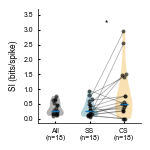


SPATIAL INFORMATION: All, SS, CS (Place Cells)
All: n=18 cells, 0.353 ± 0.210 bits/spike
SS:  n=18 cells, 0.341 ± 0.260 bits/spike
CS:  n=18 cells, 0.816 ± 0.826 bits/spike
SS vs CS (paired, n=18): wilcoxon, p = 1.39e-02 *


In [330]:
# Spatial Information - Violin plot (All, SS, CS)
# Display all cells for each group; paired test for matched cells, unpaired if sample sizes differ
panel_w, panel_h = 1.5, 1.5
fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))

all_color = 'black'
ss_color = '#026C80'
cs_color = '#EE9B00'

# Get all data
all_data_raw = df_pc['si_bits_per_spike'].values
peak_cs = df_pc['peak_rate_cs'].values
ss_data = df_pc['si_bits_per_spike_ss'].values
cs_data = df_pc['si_bits_per_spike_cs'].values

# All cells with finite values for each group (for display)
all_valid = all_data_raw[np.isfinite(all_data_raw)]
ss_all = ss_data[np.isfinite(ss_data)]  # All SS cells
cs_all = cs_data[np.isfinite(cs_data)]  # All CS cells with peak_rate_cs > 0

# Paired data: cells with both SS and CS valid (and peak_rate_cs > 0)
paired_mask = np.isfinite(ss_data) & np.isfinite(cs_data)
ss_paired = ss_data[paired_mask]
cs_paired = cs_data[paired_mask]

ylim = _global_ylim([all_valid, ss_all, cs_all])

# Violin plot - All at position 1, SS at position 2, CS at position 3
if len(all_valid) >= 3:
    parts_all = ax.violinplot([all_valid], positions=[1], showmedians=True, showextrema=False)
    _style_violin_medians(parts_all)
    for body in parts_all['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(all_color)
        body.set_edgecolor('none')

if len(ss_all) >= 3:
    parts_ss = ax.violinplot([ss_all], positions=[2], showmedians=True, showextrema=False)
    _style_violin_medians(parts_ss)
    for body in parts_ss['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(ss_color)
        body.set_edgecolor('none')

if len(cs_all) >= 3:
    parts_cs = ax.violinplot([cs_all], positions=[3], showmedians=True, showextrema=False)
    _style_violin_medians(parts_cs)
    for body in parts_cs['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(cs_color)
        body.set_edgecolor('none')

# Paired lines (SS to CS for paired cells only)
for i in range(len(ss_paired)):
    ax.plot([2, 3], [ss_paired[i], cs_paired[i]], color='black', alpha=0.3, linewidth=0.6)

# Scatter points - ALL cells for each group
rng = np.random.default_rng(0)
if len(all_valid) > 0:
    jitter_all = (rng.random(len(all_valid)) - 0.5) * 0.12
    ax.scatter(1 + jitter_all, all_valid, s=8, color='black', alpha=0.6, linewidths=0)
if len(ss_all) > 0:
    jitter_ss = (rng.random(len(ss_all)) - 0.5) * 0.12
    ax.scatter(2 + jitter_ss, ss_all, s=8, color='black', alpha=0.6, linewidths=0)
if len(cs_all) > 0:
    jitter_cs = (rng.random(len(cs_all)) - 0.5) * 0.12
    ax.scatter(3 + jitter_cs, cs_all, s=8, color='black', alpha=0.6, linewidths=0)

# Stats: paired test (for matched cells)
p_paired, _, test_name_paired, _, _ = _paired_test(ss_paired, cs_paired) if len(ss_paired) >= 3 else (np.nan, None, 'N/A', 0, None)
sig_paired = _sig_label(p_paired)

# Unpaired test (if sample sizes differ)
do_unpaired = len(ss_all) != len(cs_all)
if do_unpaired and len(ss_all) >= 3 and len(cs_all) >= 3:
    p_unpaired, test_name_unpaired, _, _ = unpaired_test_auto(ss_all, cs_all)
    sig_unpaired = _sig_label(p_unpaired)
else:
    p_unpaired, test_name_unpaired, sig_unpaired = np.nan, 'N/A', None

# Display significance
if ylim:
    y_range = ylim[1] - ylim[0]
    ax.text(2.5, ylim[1] - 0.02 * y_range, sig_paired, ha='center', va='bottom', fontsize=6)
    if do_unpaired and sig_unpaired:
        ax.text(2.5, ylim[1] + 0.08 * y_range, f'({sig_unpaired})', ha='center', va='bottom', fontsize=5, color='gray')
    ax.set_ylim(ylim[0], ylim[1] + 0.18 * y_range)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels([f'All\n(n={len(all_valid)})', f'SS\n(n={len(ss_all)})', f'CS\n(n={len(cs_all)})'], fontsize=5)
ax.set_ylabel('SI (bits/spike)', fontsize=6)
ax.set_xlim(0.5, 3.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
save_path = os.path.join(figure_save_folder, 'spatial_info_all_ss_cs.svg')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

# Print stats
print("\n" + "="*70)
print("SPATIAL INFORMATION: All, SS, CS (Place Cells)")
print("="*70)
print(f"All: n={len(all_valid)} cells, {np.mean(all_valid):.3f} ± {np.std(all_valid):.3f} bits/spike")
print(f"SS:  n={len(ss_all)} cells, {np.mean(ss_all):.3f} ± {np.std(ss_all):.3f} bits/spike")
print(f"CS:  n={len(cs_all)} cells, {np.mean(cs_all):.3f} ± {np.std(cs_all):.3f} bits/spike")
if len(ss_paired) >= 3:
    print(f"SS vs CS (paired, n={len(ss_paired)}): {test_name_paired}, p = {p_paired:.2e} {sig_paired}")
if do_unpaired and len(ss_all) >= 3 and len(cs_all) >= 3:
    print(f"SS vs CS (unpaired): {test_name_unpaired}, p = {p_unpaired:.2e} {sig_unpaired}")

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/spatial_info_cs_plus_minus_plc.svg


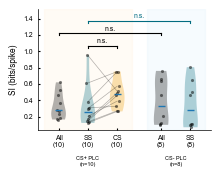


SPATIAL INFORMATION: CS+ PLC vs CS- PLC

CS+ PLC (n=10):
  All: 0.329 ± 0.154 bits/spike
  SS:  0.333 ± 0.250 bits/spike
  CS:  0.479 ± 0.167 bits/spike

CS- PLC (n=8):
  All: 0.384 ± 0.260 bits/spike
  SS:  0.350 ± 0.271 bits/spike
  (CS omitted - unreliable due to few CS spikes)

Statistics:
  CS+ PLC: SS vs CS (wilcoxon) p = 8.40e-02
  All: CS+ vs CS- (t-test) p = 6.08e-01
  SS: CS+ vs CS- (Mann-Whitney) p = 6.33e-01


In [331]:
# Spatial Information - CS+ PLC vs CS- PLC (5-group figure)
# Groups: CS+ PC (All, SS, CS) | CS- PC (All, SS) - no CS for CS- PLC (unreliable due to few CS)
# Paired tests within CS+ group, unpaired tests between groups

def get_si_data(df_subset, peak_cs_vals):
    """Get All, SS, CS spatial information data with proper filtering."""
    all_data = df_subset['si_bits_per_spike'].values
    ss_data = df_subset['si_bits_per_spike_ss'].values
    cs_data = df_subset['si_bits_per_spike_cs'].values
    
    all_valid = all_data[np.isfinite(all_data)]
    ss_valid = ss_data[np.isfinite(ss_data)]
    cs_mask = np.isfinite(cs_data)
    cs_valid = cs_data[cs_mask]
    
    # For paired test: need both SS and CS valid
    paired_mask = np.isfinite(ss_data) & np.isfinite(cs_data)
    ss_paired = ss_data[paired_mask]
    cs_paired = cs_data[paired_mask]
    
    return all_valid, ss_valid, cs_valid, ss_paired, cs_paired

# Get data for SI
si_cs_all, si_cs_ss, si_cs_cs, si_cs_ss_paired, si_cs_cs_paired = get_si_data(df_cs_plc, peak_cs_csplc)
si_non_all, si_non_ss, si_non_cs, si_non_ss_paired, si_non_cs_paired = get_si_data(df_non_cs_plc, peak_cs_noncsplc)

# Create figure - 5 groups (no CS for CS- PLC)
panel_w, panel_h = 2.2, 1.8
fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))

positions = [1, 2, 3, 4.5, 5.5]  # 5 positions: CS+ (All, SS, CS), CS- (All, SS)

# Add background shading
ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg, zorder=0)
ax.axvspan(4.0, 6.0, alpha=0.3, color=non_cs_plc_bg, zorder=0)

# Add group labels at bottom
ax.text(2, -0.22, f'CS+ PLC\n(n={len(df_cs_plc)})', ha='center', va='top', 
        fontsize=4, fontname='Arial', transform=ax.get_xaxis_transform())
ax.text(5, -0.22, f'CS- PLC\n(n={len(df_non_cs_plc)})', ha='center', va='top', 
        fontsize=4, fontname='Arial', transform=ax.get_xaxis_transform())

data_list = [si_cs_all, si_cs_ss, si_cs_cs, si_non_all, si_non_ss]
colors_list = [all_color, ss_color, cs_color, all_color, ss_color]

# Get global ylim
all_data_flat = np.concatenate([d for d in data_list if len(d) > 0])
ylim = _global_ylim(data_list) if len(all_data_flat) > 0 else None

# Plot violins
for pos, data, c in zip(positions, data_list, colors_list):
    if len(data) >= 3:
        parts = ax.violinplot([data], positions=[pos], showmedians=True, showextrema=False)
        _style_violin_medians(parts)
        for body in parts['bodies']:
            body.set_alpha(0.3)
            body.set_facecolor(c)
            body.set_edgecolor('none')

# Paired lines within CS+ group only
for i in range(len(si_cs_ss_paired)):
    ax.plot([2, 3], [si_cs_ss_paired[i], si_cs_cs_paired[i]], color='black', alpha=0.3, linewidth=0.5)

# Scatter points
rng = np.random.default_rng(42)
for pos, data in zip(positions, data_list):
    if len(data) >= 1:
        jitter = (rng.random(len(data)) - 0.5) * 0.12
        ax.scatter(pos + jitter, data, s=5, color='black', alpha=0.5, linewidths=0)

# Formatting
ax.set_ylabel('SI (bits/spike)', fontsize=6, fontname='Arial')
ax.set_xticks(positions)
ax.set_xticklabels([f'All\n({len(si_cs_all)})', f'SS\n({len(si_cs_ss)})', f'CS\n({len(si_cs_cs)})',
                   f'All\n({len(si_non_all)})', f'SS\n({len(si_non_ss)})'], fontsize=4, fontname='Arial')
ax.set_xlim(0.3, 6.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=5)

# Significance tests and brackets
if ylim:
    y_range = ylim[1] - ylim[0]
    ax.set_ylim(ylim[0], ylim[1] + y_range * 0.55)
    
    h = y_range * 0.03
    text_h = y_range * 0.08
    gap = y_range * 0.05
    y1 = ylim[1] + y_range * 0.05
    
    # Level 1: Paired test (SS vs CS within CS+ group only)
    if len(si_cs_ss_paired) >= 3:
        p_cs_paired, _, test_cs_paired, _, _ = _paired_test(si_cs_ss_paired, si_cs_cs_paired)
        sig_cs_paired = _sig_label(p_cs_paired)
        add_bracket(ax, 2, 3, y1, h, sig_cs_paired)
    else:
        p_cs_paired = np.nan
        test_cs_paired = 'N/A'
    
    # Level 2: All comparison (unpaired)
    y2 = y1 + h + text_h + gap
    if len(si_cs_all) >= 3 and len(si_non_all) >= 3:
        p_all_unpaired, test_all, _, _ = unpaired_test_auto(si_cs_all, si_non_all)
        sig_all_unpaired = _sig_label(p_all_unpaired)
        add_bracket(ax, 1, 4.5, y2, h, sig_all_unpaired, color=all_color)
    else:
        p_all_unpaired = np.nan
        test_all = 'N/A'
    
    # Level 3: SS comparison (unpaired)
    y3 = y2 + h + text_h + gap
    if len(si_cs_ss) >= 3 and len(si_non_ss) >= 3:
        p_ss_unpaired, test_ss, _, _ = unpaired_test_auto(si_cs_ss, si_non_ss)
        sig_ss_unpaired = _sig_label(p_ss_unpaired)
        add_bracket(ax, 2, 5.5, y3, h, sig_ss_unpaired, color=ss_color)
    else:
        p_ss_unpaired = np.nan
        test_ss = 'N/A'

plt.tight_layout()
save_path = os.path.join(figure_save_folder, 'spatial_info_cs_plus_minus_plc.svg')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

# Print summary stats
print("\n" + "="*70)
print("SPATIAL INFORMATION: CS+ PLC vs CS- PLC")
print("="*70)
print(f"\nCS+ PLC (n={len(df_cs_plc)}):")
print(f"  All: {np.mean(si_cs_all):.3f} ± {np.std(si_cs_all):.3f} bits/spike")
print(f"  SS:  {np.mean(si_cs_ss):.3f} ± {np.std(si_cs_ss):.3f} bits/spike")
print(f"  CS:  {np.mean(si_cs_cs):.3f} ± {np.std(si_cs_cs):.3f} bits/spike")
print(f"\nCS- PLC (n={len(df_non_cs_plc)}):")
print(f"  All: {np.mean(si_non_all):.3f} ± {np.std(si_non_all):.3f} bits/spike")
print(f"  SS:  {np.mean(si_non_ss):.3f} ± {np.std(si_non_ss):.3f} bits/spike")
print(f"  (CS omitted - unreliable due to few CS spikes)")
if ylim:
    print(f"\nStatistics:")
    print(f"  CS+ PLC: SS vs CS ({test_cs_paired}) p = {p_cs_paired:.2e}")
    print(f"  All: CS+ vs CS- ({test_all}) p = {p_all_unpaired:.2e}")
    print(f"  SS: CS+ vs CS- ({test_ss}) p = {p_ss_unpaired:.2e}")

# 3. Spatial Selectivity (Place Cells) - All vs SS vs CS

!!!! The spatial selectivity for SS and CS is computed relative to the same place field mask (defined by all spikes combined), not their respective place fields.

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/spatial_selectivity_all_ss_cs.svg


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67869/2921385460.py:34: RuntimeWarning: invalid value encountered in divide
  (cs_in - cs_out) / cs_sum, np.nan)


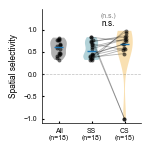


SPATIAL SELECTIVITY: All, SS, CS (Place Cells, Locomotion)
Spatial selectivity = (in - out) / (in + out)
Ranges: -1 (only out PF) to +1 (only in PF), 0 = no selectivity
All: n=18 cells, 0.589 ± 0.153
SS:  n=18 cells, 0.548 ± 0.178
CS:  n=15 cells, 0.495 ± 0.603
SS vs CS (paired, n=15): wilcoxon, p = 1.69e-01 n.s.
SS vs CS (unpaired): Mann-Whitney, p = 1.16e-01 n.s.


In [332]:
# Spatial Selectivity - Violin plot (All, SS, CS)
# Spatial selectivity = (in - out) / (in + out)
# Ranges from -1 (only out PF) to +1 (only in PF), 0 = no selectivity
# Display all cells for each group; paired test for matched cells, unpaired if sample sizes differ
panel_w, panel_h = 1.5, 1.5
fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))

all_color = 'black'
ss_color = '#026C80'
cs_color = '#EE9B00'

# Get in/out rates and compute spatial selectivity for each spike type
peak_cs = df_pc['peak_rate_cs'].values

# All spikes selectivity
all_in = df_pc['all_inout_loco_in'].values
all_out = df_pc['all_inout_loco_out'].values
all_sum = all_in + all_out
all_selectivity = np.where((all_sum > 0) & np.isfinite(all_in) & np.isfinite(all_out), 
                            (all_in - all_out) / all_sum, np.nan)

# SS selectivity
ss_in = df_pc['ss_inout_loco_in'].values
ss_out = df_pc['ss_inout_loco_out'].values
ss_sum = ss_in + ss_out
ss_selectivity = np.where((ss_sum > 0) & np.isfinite(ss_in) & np.isfinite(ss_out),
                           (ss_in - ss_out) / ss_sum, np.nan)

# CS selectivity
cs_in = df_pc['cs_inout_loco_in'].values
cs_out = df_pc['cs_inout_loco_out'].values
cs_sum = cs_in + cs_out
cs_selectivity = np.where((cs_sum > 0) & np.isfinite(cs_in) & np.isfinite(cs_out),
                           (cs_in - cs_out) / cs_sum, np.nan)

# All cells with finite values for each group (for display)
all_valid = all_selectivity[np.isfinite(all_selectivity)]
ss_all = ss_selectivity[np.isfinite(ss_selectivity)]  # All SS cells
cs_all = cs_selectivity[np.isfinite(cs_selectivity)]  # All CS cells with peak_rate_cs > 0

# Paired data: cells with both SS and CS valid (and peak_rate_cs > 0)
paired_mask = np.isfinite(ss_selectivity) & np.isfinite(cs_selectivity)
ss_paired = ss_selectivity[paired_mask]
cs_paired = cs_selectivity[paired_mask]

ylim = _global_ylim([all_valid, ss_all, cs_all])

# Violin plot - All at position 1, SS at position 2, CS at position 3
if len(all_valid) >= 3:
    parts_all = ax.violinplot([all_valid], positions=[1], showmedians=True, showextrema=False)
    _style_violin_medians(parts_all)
    for body in parts_all['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(all_color)
        body.set_edgecolor('none')

if len(ss_all) >= 3:
    parts_ss = ax.violinplot([ss_all], positions=[2], showmedians=True, showextrema=False)
    _style_violin_medians(parts_ss)
    for body in parts_ss['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(ss_color)
        body.set_edgecolor('none')

if len(cs_all) >= 3:
    parts_cs = ax.violinplot([cs_all], positions=[3], showmedians=True, showextrema=False)
    _style_violin_medians(parts_cs)
    for body in parts_cs['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(cs_color)
        body.set_edgecolor('none')

# Paired lines (SS to CS for paired cells only)
for i in range(len(ss_paired)):
    ax.plot([2, 3], [ss_paired[i], cs_paired[i]], color='black', alpha=0.3, linewidth=0.6)

# Scatter points - ALL cells for each group
rng = np.random.default_rng(0)
if len(all_valid) > 0:
    jitter_all = (rng.random(len(all_valid)) - 0.5) * 0.12
    ax.scatter(1 + jitter_all, all_valid, s=8, color='black', alpha=0.6, linewidths=0)
if len(ss_all) > 0:
    jitter_ss = (rng.random(len(ss_all)) - 0.5) * 0.12
    ax.scatter(2 + jitter_ss, ss_all, s=8, color='black', alpha=0.6, linewidths=0)
if len(cs_all) > 0:
    jitter_cs = (rng.random(len(cs_all)) - 0.5) * 0.12
    ax.scatter(3 + jitter_cs, cs_all, s=8, color='black', alpha=0.6, linewidths=0)

# Reference line at selectivity = 0 (no selectivity)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Stats: paired test (for matched cells)
p_paired, _, test_name_paired, _, _ = _paired_test(ss_paired, cs_paired) if len(ss_paired) >= 3 else (np.nan, None, 'N/A', 0, None)
sig_paired = _sig_label(p_paired)

# Unpaired test (if sample sizes differ)
do_unpaired = len(ss_all) != len(cs_all)
if do_unpaired and len(ss_all) >= 3 and len(cs_all) >= 3:
    p_unpaired, test_name_unpaired, _, _ = unpaired_test_auto(ss_all, cs_all)
    sig_unpaired = _sig_label(p_unpaired)
else:
    p_unpaired, test_name_unpaired, sig_unpaired = np.nan, 'N/A', None

# Display significance
if ylim:
    y_range = ylim[1] - ylim[0]
    ax.text(2.5, ylim[1] - 0.02 * y_range, sig_paired, ha='center', va='bottom', fontsize=6)
    if do_unpaired and sig_unpaired:
        ax.text(2.5, ylim[1] + 0.08 * y_range, f'({sig_unpaired})', ha='center', va='bottom', fontsize=5, color='gray')
    ax.set_ylim(ylim[0], ylim[1] + 0.18 * y_range)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels([f'All\n(n={len(all_valid)})', f'SS\n(n={len(ss_all)})', f'CS\n(n={len(cs_all)})'], fontsize=5)
ax.set_ylabel('Spatial selectivity', fontsize=6)
ax.set_xlim(0.5, 3.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
save_path = os.path.join(figure_save_folder, 'spatial_selectivity_all_ss_cs.svg')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

# Print stats
print("\n" + "="*70)
print("SPATIAL SELECTIVITY: All, SS, CS (Place Cells, Locomotion)")
print("Spatial selectivity = (in - out) / (in + out)")
print("Ranges: -1 (only out PF) to +1 (only in PF), 0 = no selectivity")
print("="*70)
print(f"All: n={len(all_valid)} cells, {np.mean(all_valid):.3f} ± {np.std(all_valid):.3f}")
print(f"SS:  n={len(ss_all)} cells, {np.mean(ss_all):.3f} ± {np.std(ss_all):.3f}")
print(f"CS:  n={len(cs_all)} cells, {np.mean(cs_all):.3f} ± {np.std(cs_all):.3f}")
if len(ss_paired) >= 3:
    print(f"SS vs CS (paired, n={len(ss_paired)}): {test_name_paired}, p = {p_paired:.2e} {sig_paired}")
if do_unpaired and len(ss_all) >= 3 and len(cs_all) >= 3:
    print(f"SS vs CS (unpaired): {test_name_unpaired}, p = {p_unpaired:.2e} {sig_unpaired}")

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/spatial_selectivity_cs_plus_minus_plc.svg


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67869/999221814.py:25: RuntimeWarning: invalid value encountered in divide
  (cs_in - cs_out) / cs_sum, np.nan)


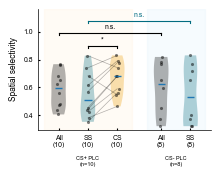


SPATIAL SELECTIVITY: CS+ PLC vs CS- PLC

CS+ PLC (n=10):
  All: 0.585 ± 0.125
  SS:  0.548 ± 0.156
  CS:  0.666 ± 0.116

CS- PLC (n=8):
  All: 0.595 ± 0.182
  SS:  0.548 ± 0.202
  (CS omitted - unreliable due to few CS spikes)

Statistics:
  CS+ PLC: SS vs CS (wilcoxon) p = 2.73e-02
  All: CS+ vs CS- (t-test) p = 8.92e-01
  SS: CS+ vs CS- (t-test) p = 9.99e-01


In [333]:
# Spatial Selectivity - CS+ PLC vs CS- PLC (5-group figure)
# Groups: CS+ PC (All, SS, CS) | CS- PC (All, SS) - no CS for CS- PLC (unreliable due to few CS)
# Spatial selectivity = (in - out) / (in + out)
# Paired tests within CS+ group, unpaired tests between groups

def get_selectivity_data(df_subset, peak_cs_vals):
    """Get All, SS, CS spatial selectivity data with proper filtering."""
    # Compute selectivity for each spike type
    all_in = df_subset['all_inout_loco_in'].values
    all_out = df_subset['all_inout_loco_out'].values
    all_sum = all_in + all_out
    all_selectivity = np.where((all_sum > 0) & np.isfinite(all_in) & np.isfinite(all_out),
                               (all_in - all_out) / all_sum, np.nan)
    
    ss_in = df_subset['ss_inout_loco_in'].values
    ss_out = df_subset['ss_inout_loco_out'].values
    ss_sum = ss_in + ss_out
    ss_selectivity = np.where((ss_sum > 0) & np.isfinite(ss_in) & np.isfinite(ss_out),
                              (ss_in - ss_out) / ss_sum, np.nan)
    
    cs_in = df_subset['cs_inout_loco_in'].values
    cs_out = df_subset['cs_inout_loco_out'].values
    cs_sum = cs_in + cs_out
    cs_selectivity = np.where((cs_sum > 0) & np.isfinite(cs_in) & np.isfinite(cs_out),
                              (cs_in - cs_out) / cs_sum, np.nan)
    
    all_valid = all_selectivity[np.isfinite(all_selectivity)]
    ss_valid = ss_selectivity[np.isfinite(ss_selectivity)]
    cs_mask = np.isfinite(cs_selectivity)
    cs_valid = cs_selectivity[cs_mask]
    
    # For paired test: need both SS and CS valid
    paired_mask = np.isfinite(ss_selectivity) & np.isfinite(cs_selectivity)
    ss_paired = ss_selectivity[paired_mask]
    cs_paired = cs_selectivity[paired_mask]
    
    return all_valid, ss_valid, cs_valid, ss_paired, cs_paired

# Get data for selectivity
sel_cs_all, sel_cs_ss, sel_cs_cs, sel_cs_ss_paired, sel_cs_cs_paired = get_selectivity_data(df_cs_plc, peak_cs_csplc)
sel_non_all, sel_non_ss, sel_non_cs, sel_non_ss_paired, sel_non_cs_paired = get_selectivity_data(df_non_cs_plc, peak_cs_noncsplc)

# Create figure - 5 groups (no CS for CS- PLC)
panel_w, panel_h = 2.2, 1.8
fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))

positions = [1, 2, 3, 4.5, 5.5]  # 5 positions: CS+ (All, SS, CS), CS- (All, SS)

# Add background shading
ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg, zorder=0)
ax.axvspan(4.0, 6.0, alpha=0.3, color=non_cs_plc_bg, zorder=0)

# Add group labels at bottom
ax.text(2, -0.22, f'CS+ PLC\n(n={len(df_cs_plc)})', ha='center', va='top', 
        fontsize=4, fontname='Arial', transform=ax.get_xaxis_transform())
ax.text(5, -0.22, f'CS- PLC\n(n={len(df_non_cs_plc)})', ha='center', va='top', 
        fontsize=4, fontname='Arial', transform=ax.get_xaxis_transform())

data_list = [sel_cs_all, sel_cs_ss, sel_cs_cs, sel_non_all, sel_non_ss]
colors_list = [all_color, ss_color, cs_color, all_color, ss_color]

# Get global ylim
all_data_flat = np.concatenate([d for d in data_list if len(d) > 0])
ylim = _global_ylim(data_list) if len(all_data_flat) > 0 else None

# Plot violins
for pos, data, c in zip(positions, data_list, colors_list):
    if len(data) >= 3:
        parts = ax.violinplot([data], positions=[pos], showmedians=True, showextrema=False)
        _style_violin_medians(parts)
        for body in parts['bodies']:
            body.set_alpha(0.3)
            body.set_facecolor(c)
            body.set_edgecolor('none')

# Paired lines within CS+ group only
for i in range(len(sel_cs_ss_paired)):
    ax.plot([2, 3], [sel_cs_ss_paired[i], sel_cs_cs_paired[i]], color='black', alpha=0.3, linewidth=0.5)

# Scatter points
rng = np.random.default_rng(42)
for pos, data in zip(positions, data_list):
    if len(data) >= 1:
        jitter = (rng.random(len(data)) - 0.5) * 0.12
        ax.scatter(pos + jitter, data, s=5, color='black', alpha=0.5, linewidths=0)

# Reference line at 0
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

# Formatting
ax.set_ylabel('Spatial selectivity', fontsize=6, fontname='Arial')
ax.set_xticks(positions)
ax.set_xticklabels([f'All\n({len(sel_cs_all)})', f'SS\n({len(sel_cs_ss)})', f'CS\n({len(sel_cs_cs)})',
                   f'All\n({len(sel_non_all)})', f'SS\n({len(sel_non_ss)})'], fontsize=4, fontname='Arial')
ax.set_xlim(0.3, 6.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=5)

# Significance tests and brackets
if ylim:
    y_range = ylim[1] - ylim[0]
    ax.set_ylim(ylim[0], ylim[1] + y_range * 0.55)
    
    h = y_range * 0.03
    text_h = y_range * 0.08
    gap = y_range * 0.05
    y1 = ylim[1] + y_range * 0.05
    
    # Level 1: Paired test (SS vs CS within CS+ group only)
    if len(sel_cs_ss_paired) >= 3:
        p_cs_paired, _, test_cs_paired, _, _ = _paired_test(sel_cs_ss_paired, sel_cs_cs_paired)
        sig_cs_paired = _sig_label(p_cs_paired)
        add_bracket(ax, 2, 3, y1, h, sig_cs_paired)
    else:
        p_cs_paired = np.nan
        test_cs_paired = 'N/A'
    
    # Level 2: All comparison (unpaired)
    y2 = y1 + h + text_h + gap
    if len(sel_cs_all) >= 3 and len(sel_non_all) >= 3:
        p_all_unpaired, test_all, _, _ = unpaired_test_auto(sel_cs_all, sel_non_all)
        sig_all_unpaired = _sig_label(p_all_unpaired)
        add_bracket(ax, 1, 4.5, y2, h, sig_all_unpaired, color=all_color)
    else:
        p_all_unpaired = np.nan
        test_all = 'N/A'
    
    # Level 3: SS comparison (unpaired)
    y3 = y2 + h + text_h + gap
    if len(sel_cs_ss) >= 3 and len(sel_non_ss) >= 3:
        p_ss_unpaired, test_ss, _, _ = unpaired_test_auto(sel_cs_ss, sel_non_ss)
        sig_ss_unpaired = _sig_label(p_ss_unpaired)
        add_bracket(ax, 2, 5.5, y3, h, sig_ss_unpaired, color=ss_color)
    else:
        p_ss_unpaired = np.nan
        test_ss = 'N/A'

plt.tight_layout()
save_path = os.path.join(figure_save_folder, 'spatial_selectivity_cs_plus_minus_plc.svg')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

# Print summary stats
print("\n" + "="*70)
print("SPATIAL SELECTIVITY: CS+ PLC vs CS- PLC")
print("="*70)
print(f"\nCS+ PLC (n={len(df_cs_plc)}):")
print(f"  All: {np.mean(sel_cs_all):.3f} ± {np.std(sel_cs_all):.3f}")
print(f"  SS:  {np.mean(sel_cs_ss):.3f} ± {np.std(sel_cs_ss):.3f}")
print(f"  CS:  {np.mean(sel_cs_cs):.3f} ± {np.std(sel_cs_cs):.3f}")
print(f"\nCS- PLC (n={len(df_non_cs_plc)}):")
print(f"  All: {np.mean(sel_non_all):.3f} ± {np.std(sel_non_all):.3f}")
print(f"  SS:  {np.mean(sel_non_ss):.3f} ± {np.std(sel_non_ss):.3f}")
print(f"  (CS omitted - unreliable due to few CS spikes)")
if ylim:
    print(f"\nStatistics:")
    print(f"  CS+ PLC: SS vs CS ({test_cs_paired}) p = {p_cs_paired:.2e}")
    print(f"  All: CS+ vs CS- ({test_all}) p = {p_all_unpaired:.2e}")
    print(f"  SS: CS+ vs CS- ({test_ss}) p = {p_ss_unpaired:.2e}")

# Number of Place Fields

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/n_place_fields_paired.svg


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67869/2631579078.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


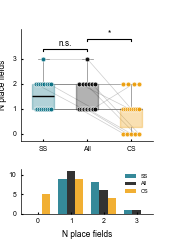


NUMBER OF PLACE FIELDS (n=18 place cells)
SS:  mean=1.56 ± 0.60, range=[1, 3]
All: mean=1.44 ± 0.60, range=[1, 3]
CS:  mean=0.94 ± 0.70, range=[0, 2]

SS vs All: wilcoxon, p = 1.57e-01 n.s.
All vs CS: wilcoxon, p = 3.04e-02 *


In [334]:
# ============================================================================
# Number of Place Fields: Box plot with paired lines and significance brackets
# All 14 place cells (defined by All spikes), showing N_PFs for SS, All, CS
# Layout: SS (left) - All (middle) - CS (right)
# Paired lines: SS-All and All-CS
# Points dodged to avoid overlap at same y-value
# + Histograms below for each group
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

# Extract number of place fields for all place cells (df_pc)
# These are the same 14 cells, just different spike types
n_pf_all = df_pc['n_place_fields'].values
n_pf_ss = df_pc['n_place_fields_ss'].values
n_pf_cs = df_pc['n_place_fields_cs'].values

# Replace NaN with 0 (no place field for that spike type)
n_pf_all = np.nan_to_num(n_pf_all, nan=0).astype(int)
n_pf_ss = np.nan_to_num(n_pf_ss, nan=0).astype(int)
n_pf_cs = np.nan_to_num(n_pf_cs, nan=0).astype(int)

n_cells = len(df_pc)

# Colors
all_color = 'black'
ss_color = '#026C80'
cs_color = '#EE9B00'

# Function to compute dodged x-positions for points at same y-value
def dodge_x_positions(x_center, y_values, dodge_width=0.35):
    """
    Spread points horizontally when they share the same y-value.
    Returns array of x positions.
    """
    x_out = np.zeros(len(y_values))
    unique_y = np.unique(y_values)
    
    for y in unique_y:
        mask = (y_values == y)
        n_at_y = np.sum(mask)
        if n_at_y == 1:
            x_out[mask] = x_center
        else:
            # Spread points evenly within dodge_width
            offsets = np.linspace(-dodge_width/2, dodge_width/2, n_at_y)
            x_out[mask] = x_center + offsets
    
    return x_out

# Create figure with subplots: main box plot on top, 3 histograms below
fig, axes = plt.subplots(2, 1, figsize=(1.7, 2.4), height_ratios=[2.5, 1], 
                          gridspec_kw={'hspace': 0.35})
ax = axes[0]
ax_hist = axes[1]

# Y-axis limits (leave room for brackets)
all_vals = np.concatenate([n_pf_ss, n_pf_all, n_pf_cs])
data_max = max(all_vals)
ylim = (-0.3, data_max + 1.2)

# Box plots
box_width = 0.5
bp = ax.boxplot([n_pf_ss, n_pf_all, n_pf_cs], positions=[1, 2, 3], widths=box_width,
                patch_artist=True, showfliers=False, zorder=2)

# Color the boxes
colors = [ss_color, all_color, cs_color]
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.3)
    patch.set_edgecolor(color)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(1)
for whisker in bp['whiskers']:
    whisker.set_color('gray')
    whisker.set_linewidth(0.5)
for cap in bp['caps']:
    cap.set_color('gray')
    cap.set_linewidth(0.5)

# Compute dodged x-positions for each column
x_ss = dodge_x_positions(1, n_pf_ss, dodge_width=0.35)
x_all = dodge_x_positions(2, n_pf_all, dodge_width=0.35)
x_cs = dodge_x_positions(3, n_pf_cs, dodge_width=0.35)

# Paired lines: SS-All (left pair) and All-CS (right pair)
for i in range(n_cells):
    ax.plot([x_ss[i], x_all[i]], [n_pf_ss[i], n_pf_all[i]], color='gray', alpha=0.4, linewidth=0.5, zorder=1)
    ax.plot([x_all[i], x_cs[i]], [n_pf_all[i], n_pf_cs[i]], color='gray', alpha=0.4, linewidth=0.5, zorder=1)

# Scatter points
scatter_size = 12
ax.scatter(x_ss, n_pf_ss, s=scatter_size, color=ss_color, alpha=0.9, linewidths=0.5, edgecolors='white', zorder=5)
ax.scatter(x_all, n_pf_all, s=scatter_size, color=all_color, alpha=0.9, linewidths=0.5, edgecolors='white', zorder=5)
ax.scatter(x_cs, n_pf_cs, s=scatter_size, color=cs_color, alpha=0.9, linewidths=0.5, edgecolors='white', zorder=5)

# Statistical tests: SS vs All, All vs CS (paired)
p_ss_all, stat_ss_all, test_ss_all, n_ss_all, _ = _paired_test(n_pf_ss, n_pf_all)
p_all_cs, stat_all_cs, test_all_cs, n_all_cs, _ = _paired_test(n_pf_all, n_pf_cs)

sig_ss_all = _sig_label(p_ss_all)
sig_all_cs = _sig_label(p_all_cs)

# Helper function to draw significance bracket
def add_sig_bracket(ax, x1, x2, y, sig_text, h=0.1, lw=0.8):
    """Draw a significance bracket between x1 and x2 at height y."""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], color='black', linewidth=lw, clip_on=False)
    ax.text((x1+x2)/2, y+h+0.02, sig_text, ha='center', va='bottom', fontsize=6)

# Add significance brackets
bracket_y1 = data_max + 0.3
bracket_y2 = data_max + 0.7
add_sig_bracket(ax, 1, 2, bracket_y1, sig_ss_all)
add_sig_bracket(ax, 2, 3, bracket_y2, sig_all_cs)

# Formatting for main plot
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['SS', 'All', 'CS'], fontsize=5)
ax.set_ylabel('N place fields', fontsize=6)
ax.set_xlim(0.5, 3.5)
ax.set_ylim(*ylim)
ax.set_yticks(range(0, int(data_max) + 1))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ============================================================================
# Histograms for each group (side by side)
# ============================================================================
bins = np.arange(-0.5, data_max + 1.5, 1)  # Bins centered on integers
bar_width = 0.25
x_bins = np.arange(0, int(data_max) + 1)

# Count occurrences for each group
counts_ss = [np.sum(n_pf_ss == v) for v in x_bins]
counts_all = [np.sum(n_pf_all == v) for v in x_bins]
counts_cs = [np.sum(n_pf_cs == v) for v in x_bins]

# Plot side-by-side bars
ax_hist.bar(x_bins - bar_width, counts_ss, width=bar_width, color=ss_color, alpha=0.8, label='SS')
ax_hist.bar(x_bins, counts_all, width=bar_width, color=all_color, alpha=0.8, label='All')
ax_hist.bar(x_bins + bar_width, counts_cs, width=bar_width, color=cs_color, alpha=0.8, label='CS')

# Formatting for histogram
ax_hist.set_xlabel('N place fields', fontsize=6)
ax_hist.set_ylabel('Count', fontsize=6)
ax_hist.set_xticks(x_bins)
ax_hist.set_xlim(-0.5, data_max + 0.5)
ax_hist.spines['top'].set_visible(False)
ax_hist.spines['right'].set_visible(False)
ax_hist.tick_params(axis='both', labelsize=5)
ax_hist.legend(fontsize=4, loc='upper right', frameon=False)

plt.tight_layout()
save_path = os.path.join(figure_save_folder, 'n_place_fields_paired.svg')
fig.savefig(save_path, dpi=300)
print(f"Saved: {save_path}")
plt.show()

# Print summary
print("\n" + "="*60)
print(f"NUMBER OF PLACE FIELDS (n={n_cells} place cells)")
print("="*60)
print(f"SS:  mean={n_pf_ss.mean():.2f} ± {n_pf_ss.std():.2f}, range=[{n_pf_ss.min()}, {n_pf_ss.max()}]")
print(f"All: mean={n_pf_all.mean():.2f} ± {n_pf_all.std():.2f}, range=[{n_pf_all.min()}, {n_pf_all.max()}]")
print(f"CS:  mean={n_pf_cs.mean():.2f} ± {n_pf_cs.std():.2f}, range=[{n_pf_cs.min()}, {n_pf_cs.max()}]")
print(f"\nSS vs All: {test_ss_all}, p = {p_ss_all:.2e} {sig_ss_all}")
print(f"All vs CS: {test_all_cs}, p = {p_all_cs:.2e} {sig_all_cs}")

# 4. Place Field Size (Place Cells)

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_size_mean_primary_secondary.svg


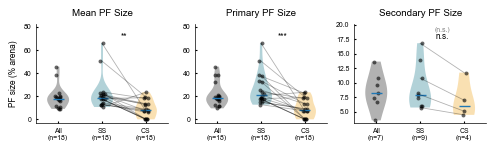


PLACE FIELD SIZE (% Arena): Mean, Primary, Secondary

Mean PF Size:
  All: n=18 cells, 18.9 ± 9.2%
  SS:  n=18 cells, 22.3 ± 13.5%
  CS:  n=18 cells, 9.1 ± 7.3%
  SS vs CS (paired, n=18): wilcoxon, p = 1.17e-03 **

Primary PF Size:
  All: n=18 cells, 21.5 ± 9.9%
  SS:  n=18 cells, 26.7 ± 13.7%
  CS:  n=18 cells, 9.8 ± 7.9%
  SS vs CS (paired, n=18): wilcoxon, p = 3.26e-04 ***

Secondary PF Size:
  All: n=7 cells, 8.5 ± 3.0%
  SS:  n=9 cells, 9.2 ± 3.7%
  CS:  n=4 cells, 7.1 ± 2.9%
  SS vs CS (paired, n=4): wilcoxon, p = 1.25e-01 n.s.
  SS vs CS (unpaired): Mann-Whitney, p = 2.47e-01 n.s.


In [335]:
# Place Field Size (% Arena) - Violin plot (All, SS, CS)
# Three metrics: Mean PF size, Primary (largest) PF size, Secondary (2nd largest) PF size
# Display all cells for each group; paired test for matched cells, unpaired if sample sizes differ

all_color = 'black'
ss_color = '#026C80'
cs_color = '#EE9B00'

# Arena size (2D arena: 20cm x 35.5cm)
arena_width_cm = 20
arena_length_cm = 35.5
arena_area_cm2 = arena_width_cm * arena_length_cm  # 710 cm²

def get_pf_metrics(sizes_list, arena_area):
    """Extract mean, primary, secondary PF sizes from a list of PF sizes."""
    if isinstance(sizes_list, (list, np.ndarray)) and len(sizes_list) > 0:
        sizes_sorted = sorted(sizes_list, reverse=True)  # Largest first
        mean_size = np.mean(sizes_list) / arena_area * 100
        primary_size = sizes_sorted[0] / arena_area * 100
        secondary_size = sizes_sorted[1] / arena_area * 100 if len(sizes_sorted) > 1 else np.nan
        return mean_size, primary_size, secondary_size
    return np.nan, np.nan, np.nan

# Get per-cell PF size metrics for each type
peak_cs_all = df_pc['peak_rate_cs'].values

# Lists for each metric and spike type
all_mean, all_primary, all_secondary = [], [], []
ss_mean, ss_primary, ss_secondary = [], [], []
cs_mean, cs_primary, cs_secondary = [], [], []
peak_cs_list = []

for i, idx in enumerate(df_pc.index):
    # All spikes PF sizes
    all_sizes = df_pc.loc[idx, 'place_field_sizes_cm2']
    m, p, s = get_pf_metrics(all_sizes, arena_area_cm2)
    all_mean.append(m)
    all_primary.append(p)
    all_secondary.append(s)
    
    # SS PF sizes
    ss_sizes = df_pc.loc[idx, 'place_field_sizes_cm2_ss']
    m, p, s = get_pf_metrics(ss_sizes, arena_area_cm2)
    ss_mean.append(m)
    ss_primary.append(p)
    ss_secondary.append(s)
    
    # CS PF sizes
    cs_sizes = df_pc.loc[idx, 'place_field_sizes_cm2_cs']
    m, p, s = get_pf_metrics(cs_sizes, arena_area_cm2)
    cs_mean.append(m)
    cs_primary.append(p)
    cs_secondary.append(s)
    
    peak_cs_list.append(peak_cs_all[i])

# Convert to arrays
all_mean, all_primary, all_secondary = np.array(all_mean), np.array(all_primary), np.array(all_secondary)
ss_mean, ss_primary, ss_secondary = np.array(ss_mean), np.array(ss_primary), np.array(ss_secondary)
cs_mean, cs_primary, cs_secondary = np.array(cs_mean), np.array(cs_primary), np.array(cs_secondary)
peak_cs = np.array(peak_cs_list)

# Create 3-panel figure
panel_w, panel_h = 1.5, 1.5
fig, axes = plt.subplots(1, 3, figsize=(panel_w * 3.3, panel_h))
metric_names = ['Mean PF Size', 'Primary PF Size', 'Secondary PF Size']
metric_data = [
    (all_mean, ss_mean, cs_mean),
    (all_primary, ss_primary, cs_primary),
    (all_secondary, ss_secondary, cs_secondary)
]
file_suffixes = ['mean', 'primary', 'secondary']

for ax_idx, (ax, (all_data, ss_data, cs_data), metric_name) in enumerate(zip(axes, metric_data, metric_names)):
    # All cells with finite values for each group (for scatter display)
    all_valid = all_data[np.isfinite(all_data)]
    ss_all = ss_data[np.isfinite(ss_data)]  # All SS cells
    cs_all = cs_data[np.isfinite(cs_data)]  # All CS cells
    
    # Paired data: cells with both SS and CS valid
    paired_mask = np.isfinite(ss_data) & np.isfinite(cs_data)
    ss_paired = ss_data[paired_mask]
    cs_paired = cs_data[paired_mask]
    
    # Skip if no valid data
    if len(all_valid) == 0 and len(ss_all) == 0 and len(cs_all) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(metric_name, fontsize=7, fontname='Arial')
        continue
    
    # Get ylim from ALL available data
    data_for_ylim = [d for d in [all_valid, ss_all, cs_all] if len(d) > 0]
    ylim = _global_ylim(data_for_ylim) if data_for_ylim else None
    
    # Violin plot - All at position 1, SS at position 2, CS at position 3
    # Use ALL cells for each group
    if len(all_valid) >= 3:
        parts_all = ax.violinplot([all_valid], positions=[1], showmedians=True, showextrema=False)
        _style_violin_medians(parts_all)
        for body in parts_all['bodies']:
            body.set_alpha(0.3)
            body.set_facecolor(all_color)
            body.set_edgecolor('none')
    
    if len(ss_all) >= 3:
        parts_ss = ax.violinplot([ss_all], positions=[2], showmedians=True, showextrema=False)
        _style_violin_medians(parts_ss)
        for body in parts_ss['bodies']:
            body.set_alpha(0.3)
            body.set_facecolor(ss_color)
            body.set_edgecolor('none')
    
    if len(cs_all) >= 3:
        parts_cs = ax.violinplot([cs_all], positions=[3], showmedians=True, showextrema=False)
        _style_violin_medians(parts_cs)
        for body in parts_cs['bodies']:
            body.set_alpha(0.3)
            body.set_facecolor(cs_color)
            body.set_edgecolor('none')
    
    # Paired lines (SS to CS for paired cells only)
    for i in range(len(ss_paired)):
        ax.plot([2, 3], [ss_paired[i], cs_paired[i]], color='black', alpha=0.3, linewidth=0.6)
    
    # Scatter points - ALL cells for each group
    rng = np.random.default_rng(0)
    if len(all_valid) > 0:
        jitter_all = (rng.random(len(all_valid)) - 0.5) * 0.12
        ax.scatter(1 + jitter_all, all_valid, s=8, color='black', alpha=0.6, linewidths=0)
    
    if len(ss_all) > 0:
        jitter_ss = (rng.random(len(ss_all)) - 0.5) * 0.12
        ax.scatter(2 + jitter_ss, ss_all, s=8, color='black', alpha=0.6, linewidths=0)
    
    if len(cs_all) > 0:
        jitter_cs = (rng.random(len(cs_all)) - 0.5) * 0.12
        ax.scatter(3 + jitter_cs, cs_all, s=8, color='black', alpha=0.6, linewidths=0)
    
    # Stats (SS vs CS)
    # Paired test (for matched cells)
    p_paired, test_name_paired = np.nan, 'N/A'
    if len(ss_paired) >= 3:
        p_paired, _, test_name_paired, _, _ = _paired_test(ss_paired, cs_paired)
        sig_paired = _sig_label(p_paired)
    else:
        sig_paired = 'n.s.'
    
    # Unpaired test (if sample sizes differ)
    do_unpaired = len(ss_all) != len(cs_all)
    if do_unpaired and len(ss_all) >= 3 and len(cs_all) >= 3:
        p_unpaired, test_name_unpaired, _, _ = unpaired_test_auto(ss_all, cs_all)
        sig_unpaired = _sig_label(p_unpaired)
    else:
        p_unpaired, test_name_unpaired, sig_unpaired = np.nan, 'N/A', None
    
    # Display significance
    if ylim:
        y_range = ylim[1] - ylim[0]
        # Paired significance
        ax.text(2.5, ylim[1] - 0.02 * y_range, sig_paired, ha='center', va='bottom', fontsize=6)
        # Unpaired significance in brackets (above paired)
        if do_unpaired and sig_unpaired:
            ax.text(2.5, ylim[1] + 0.08 * y_range, f'({sig_unpaired})', ha='center', va='bottom', fontsize=5, color='gray')
    
    if ylim:
        # Extend ylim slightly to accommodate unpaired label
        ax.set_ylim(ylim[0], ylim[1] + 0.18 * (ylim[1] - ylim[0]))
    
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([f'All\n(n={len(all_valid)})', f'SS\n(n={len(ss_all)})', f'CS\n(n={len(cs_all)})'], fontsize=5)
    if ax_idx == 0:
        ax.set_ylabel('PF size (% arena)', fontsize=6)
    ax.set_xlim(0.5, 3.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(metric_name, fontsize=7, fontname='Arial')
    ax.tick_params(axis='both', labelsize=5)

plt.tight_layout()
save_path = os.path.join(figure_save_folder, 'pf_size_mean_primary_secondary.svg')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

# Print stats for all three metrics
print("\n" + "="*70)
print("PLACE FIELD SIZE (% Arena): Mean, Primary, Secondary")
print("="*70)

for metric_name, (all_data, ss_data, cs_data) in zip(metric_names, metric_data):
    all_valid = all_data[np.isfinite(all_data)]
    ss_all = ss_data[np.isfinite(ss_data)]
    cs_all = cs_data[np.isfinite(cs_data)]
    paired_mask = np.isfinite(ss_data) & np.isfinite(cs_data)
    ss_paired = ss_data[paired_mask]
    cs_paired = cs_data[paired_mask]
    
    print(f"\n{metric_name}:")
    print(f"  All: n={len(all_valid)} cells, {np.mean(all_valid):.1f} ± {np.std(all_valid):.1f}%" if len(all_valid) > 0 else "  All: n=0 cells")
    print(f"  SS:  n={len(ss_all)} cells, {np.mean(ss_all):.1f} ± {np.std(ss_all):.1f}%" if len(ss_all) > 0 else "  SS: n=0 cells")
    print(f"  CS:  n={len(cs_all)} cells, {np.mean(cs_all):.1f} ± {np.std(cs_all):.1f}%" if len(cs_all) > 0 else "  CS: n=0 cells")
    
    # Paired test
    if len(ss_paired) >= 3:
        p_val, _, test_name, _, _ = _paired_test(ss_paired, cs_paired)
        sig = _sig_label(p_val)
        print(f"  SS vs CS (paired, n={len(ss_paired)}): {test_name}, p = {p_val:.2e} {sig}")
    
    # Unpaired test (if sample sizes differ)
    if len(ss_all) != len(cs_all) and len(ss_all) >= 3 and len(cs_all) >= 3:
        p_val, test_name, _, _ = unpaired_test_auto(ss_all, cs_all)
        sig = _sig_label(p_val)
        print(f"  SS vs CS (unpaired): {test_name}, p = {p_val:.2e} {sig}")

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_size_all_metrics_cs_plus_minus_plc.svg


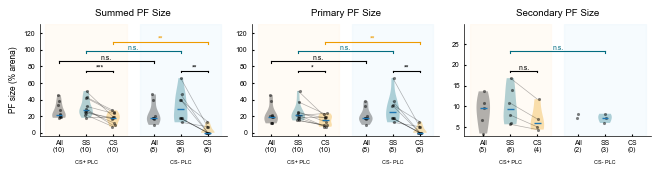


PLACE FIELD SIZE: CS+ PLC vs CS- PLC (All Metrics)

--- Summed PF Size ---
CS+ PLC:
  All: 26.56 ± 9.04 % (n=10)
  SS:  31.18 ± 10.06 % (n=10)
  CS:  17.62 ± 6.27 % (n=10)
CS- PLC:
  All: 23.01 ± 12.03 % (n=8)
  SS:  32.09 ± 17.57 % (n=8)
  CS:  3.45 ± 4.79 % (n=8)
Statistics:
  CS+ PLC SS vs CS: paired t-test, p = 7.76e-04
  CS- PLC SS vs CS: paired t-test, p = 2.82e-03
  All CS+ vs CS-: Mann-Whitney, p = 1.20e-01
  SS CS+ vs CS-: t-test, p = 8.99e-01
  CS CS+ vs CS-: Mann-Whitney, p = 1.22e-03

--- Primary PF Size ---
CS+ PLC:
  All: 21.80 ± 10.77 % (n=10)
  SS:  24.53 ± 10.61 % (n=10)
  CS:  14.80 ± 6.02 % (n=10)
CS- PLC:
  All: 21.07 ± 8.80 % (n=8)
  SS:  29.39 ± 16.34 % (n=8)
  CS:  3.45 ± 4.79 % (n=8)
Statistics:
  CS+ PLC SS vs CS: paired t-test, p = 1.05e-02
  CS- PLC SS vs CS: paired t-test, p = 3.17e-03
  All CS+ vs CS-: Mann-Whitney, p = 5.93e-01
  SS CS+ vs CS-: Mann-Whitney, p = 9.65e-01
  CS CS+ vs CS-: Mann-Whitney, p = 2.21e-03

--- Secondary PF Size ---
CS+ PLC:
  All

/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in scalar

In [336]:
# Place Field Size - CS+ PLC vs CS- PLC (6-group figure)
# Groups: CS+ PC (All, SS, CS) | CS- PC (All, SS, CS)
# 3 panels: Summed, Primary (largest), Secondary (2nd largest) PF sizes
# Paired tests within groups, unpaired tests between groups

# Arena size (2D arena: 20cm x 35.5cm)
arena_width_cm = 20
arena_length_cm = 35.5
arena_area_cm2 = arena_width_cm * arena_length_cm

def get_pf_size_data_all_metrics(df_subset, peak_cs_vals, metric='sum'):
    """Get All, SS, CS place field size data with proper filtering.
    
    Args:
        metric: 'sum' (total of all PFs), 'primary' (largest PF), 'secondary' (2nd largest PF)
    Returns PF size as % arena for each cell.
    """
    all_sizes = []
    ss_sizes = []
    cs_sizes = []
    
    for idx in df_subset.index:
        # All
        sizes = df_subset.loc[idx, 'place_field_sizes_cm2']
        if isinstance(sizes, (list, np.ndarray)) and len(sizes) > 0:
            sizes_sorted = sorted(sizes, reverse=True)
            if metric == 'sum':
                all_sizes.append(np.sum(sizes) / arena_area_cm2 * 100)
            elif metric == 'primary':
                all_sizes.append(sizes_sorted[0] / arena_area_cm2 * 100)
            elif metric == 'secondary':
                if len(sizes_sorted) >= 2:
                    all_sizes.append(sizes_sorted[1] / arena_area_cm2 * 100)
                else:
                    all_sizes.append(np.nan)
        else:
            all_sizes.append(np.nan)
        
        # SS
        sizes = df_subset.loc[idx, 'place_field_sizes_cm2_ss']
        if isinstance(sizes, (list, np.ndarray)) and len(sizes) > 0:
            sizes_sorted = sorted(sizes, reverse=True)
            if metric == 'sum':
                ss_sizes.append(np.sum(sizes) / arena_area_cm2 * 100)
            elif metric == 'primary':
                ss_sizes.append(sizes_sorted[0] / arena_area_cm2 * 100)
            elif metric == 'secondary':
                if len(sizes_sorted) >= 2:
                    ss_sizes.append(sizes_sorted[1] / arena_area_cm2 * 100)
                else:
                    ss_sizes.append(np.nan)
        else:
            ss_sizes.append(np.nan)
        
        # CS
        sizes = df_subset.loc[idx, 'place_field_sizes_cm2_cs']
        if isinstance(sizes, (list, np.ndarray)) and len(sizes) > 0:
            sizes_sorted = sorted(sizes, reverse=True)
            if metric == 'sum':
                cs_sizes.append(np.sum(sizes) / arena_area_cm2 * 100)
            elif metric == 'primary':
                cs_sizes.append(sizes_sorted[0] / arena_area_cm2 * 100)
            elif metric == 'secondary':
                if len(sizes_sorted) >= 2:
                    cs_sizes.append(sizes_sorted[1] / arena_area_cm2 * 100)
                else:
                    cs_sizes.append(np.nan)
        else:
            cs_sizes.append(np.nan)
    
    all_sizes = np.array(all_sizes)
    ss_sizes = np.array(ss_sizes)
    cs_sizes = np.array(cs_sizes)
    peak_cs_vals = np.asarray(peak_cs_vals)
    
    all_valid = all_sizes[np.isfinite(all_sizes)]
    ss_valid = ss_sizes[np.isfinite(ss_sizes)]
    cs_mask = np.isfinite(cs_sizes)
    cs_valid = cs_sizes[cs_mask]
    
    # For paired test: need both SS and CS valid
    paired_mask = np.isfinite(ss_sizes) & np.isfinite(cs_sizes)
    ss_paired = ss_sizes[paired_mask]
    cs_paired = cs_sizes[paired_mask]
    
    return all_valid, ss_valid, cs_valid, ss_paired, cs_paired

# Create 3-panel figure (Summed, Primary, Secondary) - 6 groups each
panel_w, panel_h = 2.2, 1.8
fig, axes = plt.subplots(1, 3, figsize=(panel_w * 3, panel_h))

metrics = ['sum', 'primary', 'secondary']
metric_titles = ['Summed PF Size', 'Primary PF Size', 'Secondary PF Size']

positions = [1, 2, 3, 4.5, 5.5, 6.5]  # 6 positions: CS+ (All, SS, CS), CS- (All, SS, CS)

# Store stats for printing
all_stats = []

for ax_idx, (ax, metric, title) in enumerate(zip(axes, metrics, metric_titles)):
    # Get data for this metric
    pf_cs_all, pf_cs_ss, pf_cs_cs, pf_cs_ss_paired, pf_cs_cs_paired = get_pf_size_data_all_metrics(df_cs_plc, peak_cs_csplc, metric)
    pf_non_all, pf_non_ss, pf_non_cs, pf_non_ss_paired, pf_non_cs_paired = get_pf_size_data_all_metrics(df_non_cs_plc, peak_cs_noncsplc, metric)
    
    # Add background shading
    ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg, zorder=0)
    ax.axvspan(4.0, 7.0, alpha=0.3, color=non_cs_plc_bg, zorder=0)
    
    # Add group labels at bottom
    ax.text(2, -0.22, f'CS+ PLC', ha='center', va='top', 
            fontsize=4, fontname='Arial', transform=ax.get_xaxis_transform())
    ax.text(5.5, -0.22, f'CS- PLC', ha='center', va='top', 
            fontsize=4, fontname='Arial', transform=ax.get_xaxis_transform())
    
    data_list = [pf_cs_all, pf_cs_ss, pf_cs_cs, pf_non_all, pf_non_ss, pf_non_cs]
    colors_list = [all_color, ss_color, cs_color, all_color, ss_color, cs_color]
    
    # Get global ylim
    all_data_flat = np.concatenate([d for d in data_list if len(d) > 0]) if any(len(d) > 0 for d in data_list) else np.array([])
    ylim = _global_ylim(data_list) if len(all_data_flat) > 0 else None
    
    # Plot violins
    for pos, data, c in zip(positions, data_list, colors_list):
        if len(data) >= 3:
            parts = ax.violinplot([data], positions=[pos], showmedians=True, showextrema=False)
            _style_violin_medians(parts)
            for body in parts['bodies']:
                body.set_alpha(0.3)
                body.set_facecolor(c)
                body.set_edgecolor('none')
    
    # Paired lines within each group
    for i in range(len(pf_cs_ss_paired)):
        ax.plot([2, 3], [pf_cs_ss_paired[i], pf_cs_cs_paired[i]], color='black', alpha=0.3, linewidth=0.5)
    for i in range(len(pf_non_ss_paired)):
        ax.plot([5.5, 6.5], [pf_non_ss_paired[i], pf_non_cs_paired[i]], color='black', alpha=0.3, linewidth=0.5)
    
    # Scatter points
    rng = np.random.default_rng(42)
    for pos, data in zip(positions, data_list):
        if len(data) >= 1:
            jitter = (rng.random(len(data)) - 0.5) * 0.12
            ax.scatter(pos + jitter, data, s=5, color='black', alpha=0.5, linewidths=0)
    
    # Formatting
    ax.set_title(title, fontsize=7, fontname='Arial')
    ax.set_ylabel('PF size (% arena)' if ax_idx == 0 else '', fontsize=6, fontname='Arial')
    ax.set_xticks(positions)
    ax.set_xticklabels([f'All\n({len(pf_cs_all)})', f'SS\n({len(pf_cs_ss)})', f'CS\n({len(pf_cs_cs)})',
                       f'All\n({len(pf_non_all)})', f'SS\n({len(pf_non_ss)})', f'CS\n({len(pf_non_cs)})'], fontsize=4, fontname='Arial')
    ax.set_xlim(0.3, 7.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=5)
    
    # Initialize test results
    p_cs_paired, test_cs_paired = np.nan, 'N/A'
    p_non_paired, test_non_paired = np.nan, 'N/A'
    p_all_unpaired, test_all = np.nan, 'N/A'
    p_ss_unpaired, test_ss = np.nan, 'N/A'
    p_cs_unpaired, test_cs = np.nan, 'N/A'
    
    # Significance tests and brackets
    if ylim:
        y_range = ylim[1] - ylim[0]
        ax.set_ylim(ylim[0], ylim[1] + y_range * 0.85)
        
        h = y_range * 0.03
        text_h = y_range * 0.08
        gap = y_range * 0.05
        y1 = ylim[1] + y_range * 0.05
        
        # Level 1: Paired tests (SS vs CS within each group)
        if len(pf_cs_ss_paired) >= 3:
            p_cs_paired, _, test_cs_paired, _, _ = _paired_test(pf_cs_ss_paired, pf_cs_cs_paired)
            sig_cs_paired = _sig_label(p_cs_paired)
            add_bracket(ax, 2, 3, y1, h, sig_cs_paired)
        
        if len(pf_non_ss_paired) >= 3:
            p_non_paired, _, test_non_paired, _, _ = _paired_test(pf_non_ss_paired, pf_non_cs_paired)
            sig_non_paired = _sig_label(p_non_paired)
            add_bracket(ax, 5.5, 6.5, y1, h, sig_non_paired)
        
        # Level 2: All comparison (unpaired)
        y2 = y1 + h + text_h + gap
        if len(pf_cs_all) >= 3 and len(pf_non_all) >= 3:
            p_all_unpaired, test_all, _, _ = unpaired_test_auto(pf_cs_all, pf_non_all)
            sig_all_unpaired = _sig_label(p_all_unpaired)
            add_bracket(ax, 1, 4.5, y2, h, sig_all_unpaired, color=all_color)
        
        # Level 3: SS comparison (unpaired)
        y3 = y2 + h + text_h + gap
        if len(pf_cs_ss) >= 3 and len(pf_non_ss) >= 3:
            p_ss_unpaired, test_ss, _, _ = unpaired_test_auto(pf_cs_ss, pf_non_ss)
            sig_ss_unpaired = _sig_label(p_ss_unpaired)
            add_bracket(ax, 2, 5.5, y3, h, sig_ss_unpaired, color=ss_color)
        
        # Level 4: CS comparison (unpaired)
        y4 = y3 + h + text_h + gap
        if len(pf_cs_cs) >= 3 and len(pf_non_cs) >= 3:
            p_cs_unpaired, test_cs, _, _ = unpaired_test_auto(pf_cs_cs, pf_non_cs)
            sig_cs_unpaired = _sig_label(p_cs_unpaired)
            add_bracket(ax, 3, 6.5, y4, h, sig_cs_unpaired, color=cs_color)
    
    # Store stats
    all_stats.append({
        'metric': metric,
        'title': title,
        'cs_plc': {'all': pf_cs_all, 'ss': pf_cs_ss, 'cs': pf_cs_cs},
        'non_cs_plc': {'all': pf_non_all, 'ss': pf_non_ss, 'cs': pf_non_cs},
        'p_cs_paired': p_cs_paired, 'test_cs_paired': test_cs_paired,
        'p_non_paired': p_non_paired, 'test_non_paired': test_non_paired,
        'p_all_unpaired': p_all_unpaired, 'test_all': test_all,
        'p_ss_unpaired': p_ss_unpaired, 'test_ss': test_ss,
        'p_cs_unpaired': p_cs_unpaired, 'test_cs': test_cs
    })

plt.tight_layout()
save_path = os.path.join(figure_save_folder, 'pf_size_all_metrics_cs_plus_minus_plc.svg')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

# Print summary stats for all metrics
print("\n" + "="*70)
print("PLACE FIELD SIZE: CS+ PLC vs CS- PLC (All Metrics)")
print("="*70)
for stats in all_stats:
    print(f"\n--- {stats['title']} ---")
    print(f"CS+ PLC:")
    print(f"  All: {np.mean(stats['cs_plc']['all']):.2f} ± {np.std(stats['cs_plc']['all']):.2f} % (n={len(stats['cs_plc']['all'])})")
    print(f"  SS:  {np.mean(stats['cs_plc']['ss']):.2f} ± {np.std(stats['cs_plc']['ss']):.2f} % (n={len(stats['cs_plc']['ss'])})")
    print(f"  CS:  {np.mean(stats['cs_plc']['cs']):.2f} ± {np.std(stats['cs_plc']['cs']):.2f} % (n={len(stats['cs_plc']['cs'])})")
    print(f"CS- PLC:")
    print(f"  All: {np.mean(stats['non_cs_plc']['all']):.2f} ± {np.std(stats['non_cs_plc']['all']):.2f} % (n={len(stats['non_cs_plc']['all'])})")
    print(f"  SS:  {np.mean(stats['non_cs_plc']['ss']):.2f} ± {np.std(stats['non_cs_plc']['ss']):.2f} % (n={len(stats['non_cs_plc']['ss'])})")
    print(f"  CS:  {np.mean(stats['non_cs_plc']['cs']):.2f} ± {np.std(stats['non_cs_plc']['cs']):.2f} % (n={len(stats['non_cs_plc']['cs'])})")
    print(f"Statistics:")
    print(f"  CS+ PLC SS vs CS: {stats['test_cs_paired']}, p = {stats['p_cs_paired']:.2e}")
    print(f"  CS- PLC SS vs CS: {stats['test_non_paired']}, p = {stats['p_non_paired']:.2e}")
    print(f"  All CS+ vs CS-: {stats['test_all']}, p = {stats['p_all_unpaired']:.2e}")
    print(f"  SS CS+ vs CS-: {stats['test_ss']}, p = {stats['p_ss_unpaired']:.2e}")
    print(f"  CS CS+ vs CS-: {stats['test_cs']}, p = {stats['p_cs_unpaired']:.2e}")

# Combine 1-4

/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67869/1336001585.py:182: RuntimeWarning: invalid value encountered in divide
  (cs_in - cs_out) / cs_sum, np.nan)


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/combined_violin_all_ss_cs_pooled.svg


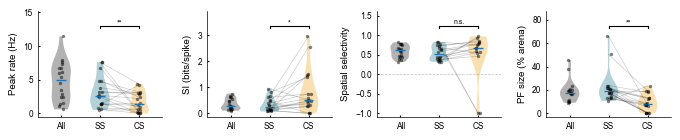


COMBINED VIOLIN PLOTS: All, SS, CS (All Place Cells Pooled)


In [337]:
# Combined 4-Panel Violin Plot: All, SS, CS (All Place Cells Pooled)
# Metrics: Peak Rate, Spatial Information, Spatial Selectivity, Mean PF Size
# Only paired statistics shown (SS vs CS)

panel_w, panel_h = 1.7, 1.4
fig, axes = plt.subplots(1, 4, figsize=(panel_w * 4., panel_h))

all_color = 'black'
ss_color = '#026C80'
cs_color = '#EE9B00'

# ==============================================================================
# 1. Peak Rate
# ==============================================================================
ax = axes[0]
all_data = df_pc['peak_rate_all'].values
ss_data = df_pc['peak_rate_ss'].values
cs_data = df_pc['peak_rate_cs'].values
peak_cs_vals = df_pc['peak_rate_cs'].values

# All valid data for each group
all_valid = all_data[np.isfinite(all_data)]
ss_all = ss_data[np.isfinite(ss_data)]
cs_all = cs_data[np.isfinite(cs_data)]

# Paired: need both SS and CS valid with peak_rate_cs > 0
paired_mask = np.isfinite(ss_data) & np.isfinite(cs_data)
ss_paired = ss_data[paired_mask]
cs_paired = cs_data[paired_mask]

data_list = [all_valid, ss_all, cs_all]
ylim = _global_ylim(data_list) if any(len(d) > 0 for d in data_list) else None

# Violins
if len(all_valid) >= 3:
    parts = ax.violinplot([all_valid], positions=[1], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(all_color)
        body.set_edgecolor('none')

if len(ss_all) >= 3:
    parts = ax.violinplot([ss_all], positions=[2], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(ss_color)
        body.set_edgecolor('none')

if len(cs_all) >= 3:
    parts = ax.violinplot([cs_all], positions=[3], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(cs_color)
        body.set_edgecolor('none')

# Paired lines (SS to CS)
for i in range(len(ss_paired)):
    ax.plot([2, 3], [ss_paired[i], cs_paired[i]], color='black', alpha=0.2, linewidth=0.5)

# Scatter
rng = np.random.default_rng(42)
jitter = (rng.random(len(all_valid)) - 0.5) * 0.12
ax.scatter(1 + jitter, all_valid, s=6, color='black', alpha=0.5, linewidths=0)
jitter = (rng.random(len(ss_all)) - 0.5) * 0.12
ax.scatter(2 + jitter, ss_all, s=6, color='black', alpha=0.5, linewidths=0)
jitter = (rng.random(len(cs_all)) - 0.5) * 0.12
ax.scatter(3 + jitter, cs_all, s=6, color='black', alpha=0.5, linewidths=0)

# Stats (paired SS vs CS)
if len(ss_paired) >= 3:
    p_val, _, test_name, _, _ = _paired_test(ss_paired, cs_paired)
    sig = _sig_label(p_val)
    if ylim:
        y_range = ylim[1] - ylim[0]
        h = y_range * 0.03
        add_bracket(ax, 2, 3, ylim[1] + y_range * 0.05, h, sig)
        ax.set_ylim(ylim[0], ylim[1] + y_range * 0.25)

ax.set_ylabel('Peak rate (Hz)', fontsize=7, fontname='Arial')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['All', 'SS', 'CS'], fontsize=6)
ax.set_xlim(0.4, 3.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=6)
#ax.set_title('Peak Rate', fontsize=8, fontname='Arial')

# ==============================================================================
# 2. Spatial Information
# ==============================================================================
ax = axes[1]
all_data = df_pc['si_bits_per_spike'].values
ss_data = df_pc['si_bits_per_spike_ss'].values
cs_data = df_pc['si_bits_per_spike_cs'].values

all_valid = all_data[np.isfinite(all_data)]
ss_all = ss_data[np.isfinite(ss_data)]
cs_all = cs_data[np.isfinite(cs_data)]

paired_mask = np.isfinite(ss_data) & np.isfinite(cs_data)
ss_paired = ss_data[paired_mask]
cs_paired = cs_data[paired_mask]

data_list = [all_valid, ss_all, cs_all]
ylim = _global_ylim(data_list) if any(len(d) > 0 for d in data_list) else None

if len(all_valid) >= 3:
    parts = ax.violinplot([all_valid], positions=[1], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(all_color)
        body.set_edgecolor('none')

if len(ss_all) >= 3:
    parts = ax.violinplot([ss_all], positions=[2], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(ss_color)
        body.set_edgecolor('none')

if len(cs_all) >= 3:
    parts = ax.violinplot([cs_all], positions=[3], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(cs_color)
        body.set_edgecolor('none')

for i in range(len(ss_paired)):
    ax.plot([2, 3], [ss_paired[i], cs_paired[i]], color='black', alpha=0.2, linewidth=0.5)

jitter = (rng.random(len(all_valid)) - 0.5) * 0.12
ax.scatter(1 + jitter, all_valid, s=6, color='black', alpha=0.5, linewidths=0)
jitter = (rng.random(len(ss_all)) - 0.5) * 0.12
ax.scatter(2 + jitter, ss_all, s=6, color='black', alpha=0.5, linewidths=0)
jitter = (rng.random(len(cs_all)) - 0.5) * 0.12
ax.scatter(3 + jitter, cs_all, s=6, color='black', alpha=0.5, linewidths=0)

if len(ss_paired) >= 3:
    p_val, _, test_name, _, _ = _paired_test(ss_paired, cs_paired)
    sig = _sig_label(p_val)
    if ylim:
        y_range = ylim[1] - ylim[0]
        h = y_range * 0.03
        add_bracket(ax, 2, 3, ylim[1] + y_range * 0.05, h, sig)
        ax.set_ylim(ylim[0], ylim[1] + y_range * 0.25)

ax.set_ylabel('SI (bits/spike)', fontsize=7, fontname='Arial')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['All', 'SS', 'CS'], fontsize=6)
ax.set_xlim(0.4, 3.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=6)
#ax.set_title('Spatial Information', fontsize=8, fontname='Arial')

# ==============================================================================
# 3. Spatial Selectivity
# ==============================================================================
ax = axes[2]
all_in = df_pc['all_inout_loco_in'].values
all_out = df_pc['all_inout_loco_out'].values
all_sum = all_in + all_out
all_selectivity = np.where((all_sum > 0) & np.isfinite(all_in) & np.isfinite(all_out),
                           (all_in - all_out) / all_sum, np.nan)

ss_in = df_pc['ss_inout_loco_in'].values
ss_out = df_pc['ss_inout_loco_out'].values
ss_sum = ss_in + ss_out
ss_selectivity = np.where((ss_sum > 0) & np.isfinite(ss_in) & np.isfinite(ss_out),
                           (ss_in - ss_out) / ss_sum, np.nan)

cs_in = df_pc['cs_inout_loco_in'].values
cs_out = df_pc['cs_inout_loco_out'].values
cs_sum = cs_in + cs_out
cs_selectivity = np.where((cs_sum > 0) & np.isfinite(cs_in) & np.isfinite(cs_out),
                           (cs_in - cs_out) / cs_sum, np.nan)

all_valid = all_selectivity[np.isfinite(all_selectivity)]
ss_all = ss_selectivity[np.isfinite(ss_selectivity)]
cs_all = cs_selectivity[np.isfinite(cs_selectivity)]

paired_mask = np.isfinite(ss_selectivity) & np.isfinite(cs_selectivity)
ss_paired = ss_selectivity[paired_mask]
cs_paired = cs_selectivity[paired_mask]

data_list = [all_valid, ss_all, cs_all]
ylim = _global_ylim(data_list) if any(len(d) > 0 for d in data_list) else None

if len(all_valid) >= 3:
    parts = ax.violinplot([all_valid], positions=[1], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(all_color)
        body.set_edgecolor('none')

if len(ss_all) >= 3:
    parts = ax.violinplot([ss_all], positions=[2], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(ss_color)
        body.set_edgecolor('none')

if len(cs_all) >= 3:
    parts = ax.violinplot([cs_all], positions=[3], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(cs_color)
        body.set_edgecolor('none')

for i in range(len(ss_paired)):
    ax.plot([2, 3], [ss_paired[i], cs_paired[i]], color='black', alpha=0.2, linewidth=0.5)

jitter = (rng.random(len(all_valid)) - 0.5) * 0.12
ax.scatter(1 + jitter, all_valid, s=6, color='black', alpha=0.5, linewidths=0)
jitter = (rng.random(len(ss_all)) - 0.5) * 0.12
ax.scatter(2 + jitter, ss_all, s=6, color='black', alpha=0.5, linewidths=0)
jitter = (rng.random(len(cs_all)) - 0.5) * 0.12
ax.scatter(3 + jitter, cs_all, s=6, color='black', alpha=0.5, linewidths=0)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

if len(ss_paired) >= 3:
    p_val, _, test_name, _, _ = _paired_test(ss_paired, cs_paired)
    sig = _sig_label(p_val)
    if ylim:
        y_range = ylim[1] - ylim[0]
        h = y_range * 0.03
        add_bracket(ax, 2, 3, ylim[1] + y_range * 0.05, h, sig)
        ax.set_ylim(ylim[0], ylim[1] + y_range * 0.25)

ax.set_ylabel('Spatial selectivity', fontsize=7, fontname='Arial')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['All', 'SS', 'CS'], fontsize=6)
ax.set_xlim(0.4, 3.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=6)
#ax.set_title('Spatial Selectivity', fontsize=8, fontname='Arial')

# ==============================================================================
# 4. Mean PF Size
# ==============================================================================
ax = axes[3]
arena_width_cm = 20
arena_length_cm = 35.5
arena_area_cm2 = arena_width_cm * arena_length_cm

all_pf_sizes = []
ss_pf_sizes = []
cs_pf_sizes = []

for idx in df_pc.index:
    # All
    sizes = df_pc.loc[idx, 'place_field_sizes_cm2']
    if isinstance(sizes, (list, np.ndarray)) and len(sizes) > 0:
        all_pf_sizes.append(np.mean(sizes) / arena_area_cm2 * 100)
    else:
        all_pf_sizes.append(np.nan)
    
    # SS
    sizes = df_pc.loc[idx, 'place_field_sizes_cm2_ss']
    if isinstance(sizes, (list, np.ndarray)) and len(sizes) > 0:
        ss_pf_sizes.append(np.mean(sizes) / arena_area_cm2 * 100)
    else:
        ss_pf_sizes.append(np.nan)
    
    # CS
    sizes = df_pc.loc[idx, 'place_field_sizes_cm2_cs']
    if isinstance(sizes, (list, np.ndarray)) and len(sizes) > 0:
        cs_pf_sizes.append(np.mean(sizes) / arena_area_cm2 * 100)
    else:
        cs_pf_sizes.append(np.nan)

all_pf_sizes = np.array(all_pf_sizes)
ss_pf_sizes = np.array(ss_pf_sizes)
cs_pf_sizes = np.array(cs_pf_sizes)

all_valid = all_pf_sizes[np.isfinite(all_pf_sizes)]
ss_all = ss_pf_sizes[np.isfinite(ss_pf_sizes)]
cs_all = cs_pf_sizes[np.isfinite(cs_pf_sizes)]

paired_mask = np.isfinite(ss_pf_sizes) & np.isfinite(cs_pf_sizes)
ss_paired = ss_pf_sizes[paired_mask]
cs_paired = cs_pf_sizes[paired_mask]

data_list = [all_valid, ss_all, cs_all]
ylim = _global_ylim(data_list) if any(len(d) > 0 for d in data_list) else None

if len(all_valid) >= 3:
    parts = ax.violinplot([all_valid], positions=[1], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(all_color)
        body.set_edgecolor('none')

if len(ss_all) >= 3:
    parts = ax.violinplot([ss_all], positions=[2], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(ss_color)
        body.set_edgecolor('none')

if len(cs_all) >= 3:
    parts = ax.violinplot([cs_all], positions=[3], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(cs_color)
        body.set_edgecolor('none')

for i in range(len(ss_paired)):
    ax.plot([2, 3], [ss_paired[i], cs_paired[i]], color='black', alpha=0.2, linewidth=0.5)

jitter = (rng.random(len(all_valid)) - 0.5) * 0.12
ax.scatter(1 + jitter, all_valid, s=6, color='black', alpha=0.5, linewidths=0)
jitter = (rng.random(len(ss_all)) - 0.5) * 0.12
ax.scatter(2 + jitter, ss_all, s=6, color='black', alpha=0.5, linewidths=0)
jitter = (rng.random(len(cs_all)) - 0.5) * 0.12
ax.scatter(3 + jitter, cs_all, s=6, color='black', alpha=0.5, linewidths=0)

if len(ss_paired) >= 3:
    p_val, _, test_name, _, _ = _paired_test(ss_paired, cs_paired)
    sig = _sig_label(p_val)
    if ylim:
        y_range = ylim[1] - ylim[0]
        h = y_range * 0.03
        add_bracket(ax, 2, 3, ylim[1] + y_range * 0.05, h, sig)
        ax.set_ylim(ylim[0], ylim[1] + y_range * 0.25)

ax.set_ylabel('PF size (% arena)', fontsize=7, fontname='Arial')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['All', 'SS', 'CS'], fontsize=6)
ax.set_xlim(0.4, 3.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=6)
#ax.set_title('Mean PF Size', fontsize=8, fontname='Arial')

plt.tight_layout()
save_path = os.path.join(figure_save_folder, 'combined_violin_all_ss_cs_pooled.svg')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

# ==============================================================================
# Print summary statistics
# ==============================================================================
print("\n" + "="*70)
print("COMBINED VIOLIN PLOTS: All, SS, CS (All Place Cells Pooled)")
print("="*70)

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/combined_violin_all_ss_cs_csplus_plc.svg


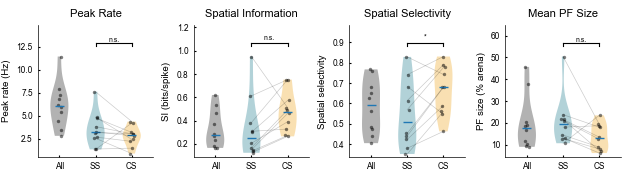


COMBINED VIOLIN PLOTS: All, SS, CS (CS+ PLC Only)
Total CS+ PLCs: n = 10


In [338]:
# Combined 4-Panel Violin Plot: All, SS, CS (CS+ PLC Only)
# Metrics: Peak Rate, Spatial Information, Spatial Selectivity, Mean PF Size
# Only paired statistics shown (SS vs CS)

panel_w, panel_h = 1.5, 1.8
fig, axes = plt.subplots(1, 4, figsize=(panel_w * 4.2, panel_h))

all_color = 'black'
ss_color = '#026C80'
cs_color = '#EE9B00'

# Use only CS+ PLC (place cells with CS place field)
df_subset = df_cs_plc
peak_cs_vals = df_subset['peak_rate_cs'].values

# ==============================================================================
# 1. Peak Rate
# ==============================================================================
ax = axes[0]
all_data = df_subset['peak_rate_all'].values
ss_data = df_subset['peak_rate_ss'].values
cs_data = df_subset['peak_rate_cs'].values

all_valid = all_data[np.isfinite(all_data)]
ss_all = ss_data[np.isfinite(ss_data)]
cs_all = cs_data[np.isfinite(cs_data)]

paired_mask = np.isfinite(ss_data) & np.isfinite(cs_data)
ss_paired = ss_data[paired_mask]
cs_paired = cs_data[paired_mask]

data_list = [all_valid, ss_all, cs_all]
ylim = _global_ylim(data_list) if any(len(d) > 0 for d in data_list) else None

if len(all_valid) >= 3:
    parts = ax.violinplot([all_valid], positions=[1], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(all_color)
        body.set_edgecolor('none')

if len(ss_all) >= 3:
    parts = ax.violinplot([ss_all], positions=[2], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(ss_color)
        body.set_edgecolor('none')

if len(cs_all) >= 3:
    parts = ax.violinplot([cs_all], positions=[3], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(cs_color)
        body.set_edgecolor('none')

for i in range(len(ss_paired)):
    ax.plot([2, 3], [ss_paired[i], cs_paired[i]], color='black', alpha=0.2, linewidth=0.5)

rng = np.random.default_rng(42)
jitter = (rng.random(len(all_valid)) - 0.5) * 0.12
ax.scatter(1 + jitter, all_valid, s=6, color='black', alpha=0.5, linewidths=0)
jitter = (rng.random(len(ss_all)) - 0.5) * 0.12
ax.scatter(2 + jitter, ss_all, s=6, color='black', alpha=0.5, linewidths=0)
jitter = (rng.random(len(cs_all)) - 0.5) * 0.12
ax.scatter(3 + jitter, cs_all, s=6, color='black', alpha=0.5, linewidths=0)

if len(ss_paired) >= 3:
    p_val, _, test_name, _, _ = _paired_test(ss_paired, cs_paired)
    sig = _sig_label(p_val)
    if ylim:
        y_range = ylim[1] - ylim[0]
        h = y_range * 0.03
        add_bracket(ax, 2, 3, ylim[1] + y_range * 0.05, h, sig)
        ax.set_ylim(ylim[0], ylim[1] + y_range * 0.25)

ax.set_ylabel('Peak rate (Hz)', fontsize=7, fontname='Arial')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['All', 'SS', 'CS'], fontsize=6)
ax.set_xlim(0.4, 3.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=6)
ax.set_title('Peak Rate', fontsize=8, fontname='Arial')

# ==============================================================================
# 2. Spatial Information
# ==============================================================================
ax = axes[1]
all_data = df_subset['si_bits_per_spike'].values
ss_data = df_subset['si_bits_per_spike_ss'].values
cs_data = df_subset['si_bits_per_spike_cs'].values

all_valid = all_data[np.isfinite(all_data)]
ss_all = ss_data[np.isfinite(ss_data)]
cs_all = cs_data[np.isfinite(cs_data)]

paired_mask = np.isfinite(ss_data) & np.isfinite(cs_data)
ss_paired = ss_data[paired_mask]
cs_paired = cs_data[paired_mask]

data_list = [all_valid, ss_all, cs_all]
ylim = _global_ylim(data_list) if any(len(d) > 0 for d in data_list) else None

if len(all_valid) >= 3:
    parts = ax.violinplot([all_valid], positions=[1], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(all_color)
        body.set_edgecolor('none')

if len(ss_all) >= 3:
    parts = ax.violinplot([ss_all], positions=[2], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(ss_color)
        body.set_edgecolor('none')

if len(cs_all) >= 3:
    parts = ax.violinplot([cs_all], positions=[3], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(cs_color)
        body.set_edgecolor('none')

for i in range(len(ss_paired)):
    ax.plot([2, 3], [ss_paired[i], cs_paired[i]], color='black', alpha=0.2, linewidth=0.5)

jitter = (rng.random(len(all_valid)) - 0.5) * 0.12
ax.scatter(1 + jitter, all_valid, s=6, color='black', alpha=0.5, linewidths=0)
jitter = (rng.random(len(ss_all)) - 0.5) * 0.12
ax.scatter(2 + jitter, ss_all, s=6, color='black', alpha=0.5, linewidths=0)
jitter = (rng.random(len(cs_all)) - 0.5) * 0.12
ax.scatter(3 + jitter, cs_all, s=6, color='black', alpha=0.5, linewidths=0)

if len(ss_paired) >= 3:
    p_val, _, test_name, _, _ = _paired_test(ss_paired, cs_paired)
    sig = _sig_label(p_val)
    if ylim:
        y_range = ylim[1] - ylim[0]
        h = y_range * 0.03
        add_bracket(ax, 2, 3, ylim[1] + y_range * 0.05, h, sig)
        ax.set_ylim(ylim[0], ylim[1] + y_range * 0.25)

ax.set_ylabel('SI (bits/spike)', fontsize=7, fontname='Arial')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['All', 'SS', 'CS'], fontsize=6)
ax.set_xlim(0.4, 3.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=6)
ax.set_title('Spatial Information', fontsize=8, fontname='Arial')

# ==============================================================================
# 3. Spatial Selectivity
# ==============================================================================
ax = axes[2]
all_in = df_subset['all_inout_loco_in'].values
all_out = df_subset['all_inout_loco_out'].values
all_sum = all_in + all_out
all_selectivity = np.where((all_sum > 0) & np.isfinite(all_in) & np.isfinite(all_out),
                           (all_in - all_out) / all_sum, np.nan)

ss_in = df_subset['ss_inout_loco_in'].values
ss_out = df_subset['ss_inout_loco_out'].values
ss_sum = ss_in + ss_out
ss_selectivity = np.where((ss_sum > 0) & np.isfinite(ss_in) & np.isfinite(ss_out),
                           (ss_in - ss_out) / ss_sum, np.nan)

cs_in = df_subset['cs_inout_loco_in'].values
cs_out = df_subset['cs_inout_loco_out'].values
cs_sum = cs_in + cs_out
cs_selectivity = np.where((cs_sum > 0) & np.isfinite(cs_in) & np.isfinite(cs_out),
                           (cs_in - cs_out) / cs_sum, np.nan)

all_valid = all_selectivity[np.isfinite(all_selectivity)]
ss_all = ss_selectivity[np.isfinite(ss_selectivity)]
cs_all = cs_selectivity[np.isfinite(cs_selectivity)]

paired_mask = np.isfinite(ss_selectivity) & np.isfinite(cs_selectivity)
ss_paired = ss_selectivity[paired_mask]
cs_paired = cs_selectivity[paired_mask]

data_list = [all_valid, ss_all, cs_all]
ylim = _global_ylim(data_list) if any(len(d) > 0 for d in data_list) else None

if len(all_valid) >= 3:
    parts = ax.violinplot([all_valid], positions=[1], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(all_color)
        body.set_edgecolor('none')

if len(ss_all) >= 3:
    parts = ax.violinplot([ss_all], positions=[2], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(ss_color)
        body.set_edgecolor('none')

if len(cs_all) >= 3:
    parts = ax.violinplot([cs_all], positions=[3], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(cs_color)
        body.set_edgecolor('none')

for i in range(len(ss_paired)):
    ax.plot([2, 3], [ss_paired[i], cs_paired[i]], color='black', alpha=0.2, linewidth=0.5)

jitter = (rng.random(len(all_valid)) - 0.5) * 0.12
ax.scatter(1 + jitter, all_valid, s=6, color='black', alpha=0.5, linewidths=0)
jitter = (rng.random(len(ss_all)) - 0.5) * 0.12
ax.scatter(2 + jitter, ss_all, s=6, color='black', alpha=0.5, linewidths=0)
jitter = (rng.random(len(cs_all)) - 0.5) * 0.12
ax.scatter(3 + jitter, cs_all, s=6, color='black', alpha=0.5, linewidths=0)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

if len(ss_paired) >= 3:
    p_val, _, test_name, _, _ = _paired_test(ss_paired, cs_paired)
    sig = _sig_label(p_val)
    if ylim:
        y_range = ylim[1] - ylim[0]
        h = y_range * 0.03
        add_bracket(ax, 2, 3, ylim[1] + y_range * 0.05, h, sig)
        ax.set_ylim(ylim[0], ylim[1] + y_range * 0.25)

ax.set_ylabel('Spatial selectivity', fontsize=7, fontname='Arial')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['All', 'SS', 'CS'], fontsize=6)
ax.set_xlim(0.4, 3.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=6)
ax.set_title('Spatial Selectivity', fontsize=8, fontname='Arial')

# ==============================================================================
# 4. Mean PF Size
# ==============================================================================
ax = axes[3]
arena_width_cm = 20
arena_length_cm = 35.5
arena_area_cm2 = arena_width_cm * arena_length_cm

all_pf_sizes = []
ss_pf_sizes = []
cs_pf_sizes = []

for idx in df_subset.index:
    # All
    sizes = df_subset.loc[idx, 'place_field_sizes_cm2']
    if isinstance(sizes, (list, np.ndarray)) and len(sizes) > 0:
        all_pf_sizes.append(np.mean(sizes) / arena_area_cm2 * 100)
    else:
        all_pf_sizes.append(np.nan)
    
    # SS
    sizes = df_subset.loc[idx, 'place_field_sizes_cm2_ss']
    if isinstance(sizes, (list, np.ndarray)) and len(sizes) > 0:
        ss_pf_sizes.append(np.mean(sizes) / arena_area_cm2 * 100)
    else:
        ss_pf_sizes.append(np.nan)
    
    # CS
    sizes = df_subset.loc[idx, 'place_field_sizes_cm2_cs']
    if isinstance(sizes, (list, np.ndarray)) and len(sizes) > 0:
        cs_pf_sizes.append(np.mean(sizes) / arena_area_cm2 * 100)
    else:
        cs_pf_sizes.append(np.nan)

all_pf_sizes = np.array(all_pf_sizes)
ss_pf_sizes = np.array(ss_pf_sizes)
cs_pf_sizes = np.array(cs_pf_sizes)

all_valid = all_pf_sizes[np.isfinite(all_pf_sizes)]
ss_all = ss_pf_sizes[np.isfinite(ss_pf_sizes)]
cs_all = cs_pf_sizes[np.isfinite(cs_pf_sizes)]

paired_mask = np.isfinite(ss_pf_sizes) & np.isfinite(cs_pf_sizes)
ss_paired = ss_pf_sizes[paired_mask]
cs_paired = cs_pf_sizes[paired_mask]

data_list = [all_valid, ss_all, cs_all]
ylim = _global_ylim(data_list) if any(len(d) > 0 for d in data_list) else None

if len(all_valid) >= 3:
    parts = ax.violinplot([all_valid], positions=[1], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(all_color)
        body.set_edgecolor('none')

if len(ss_all) >= 3:
    parts = ax.violinplot([ss_all], positions=[2], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(ss_color)
        body.set_edgecolor('none')

if len(cs_all) >= 3:
    parts = ax.violinplot([cs_all], positions=[3], showmedians=True, showextrema=False)
    _style_violin_medians(parts)
    for body in parts['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(cs_color)
        body.set_edgecolor('none')

for i in range(len(ss_paired)):
    ax.plot([2, 3], [ss_paired[i], cs_paired[i]], color='black', alpha=0.2, linewidth=0.5)

jitter = (rng.random(len(all_valid)) - 0.5) * 0.12
ax.scatter(1 + jitter, all_valid, s=6, color='black', alpha=0.5, linewidths=0)
jitter = (rng.random(len(ss_all)) - 0.5) * 0.12
ax.scatter(2 + jitter, ss_all, s=6, color='black', alpha=0.5, linewidths=0)
jitter = (rng.random(len(cs_all)) - 0.5) * 0.12
ax.scatter(3 + jitter, cs_all, s=6, color='black', alpha=0.5, linewidths=0)

if len(ss_paired) >= 3:
    p_val, _, test_name, _, _ = _paired_test(ss_paired, cs_paired)
    sig = _sig_label(p_val)
    if ylim:
        y_range = ylim[1] - ylim[0]
        h = y_range * 0.03
        add_bracket(ax, 2, 3, ylim[1] + y_range * 0.05, h, sig)
        ax.set_ylim(ylim[0], ylim[1] + y_range * 0.25)

ax.set_ylabel('PF size (% arena)', fontsize=7, fontname='Arial')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['All', 'SS', 'CS'], fontsize=6)
ax.set_xlim(0.4, 3.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=6)
ax.set_title('Mean PF Size', fontsize=8, fontname='Arial')

plt.tight_layout()
save_path = os.path.join(figure_save_folder, 'combined_violin_all_ss_cs_csplus_plc.svg')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

# ==============================================================================
# Print summary statistics
# ==============================================================================
print("\n" + "="*70)
print("COMBINED VIOLIN PLOTS: All, SS, CS (CS+ PLC Only)")
print(f"Total CS+ PLCs: n = {len(df_subset)}")
print("="*70)

# Combine 1-4: Separating CS- and CS+ Place Cells

/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67869/1367106516.py:385: RuntimeWarning: invalid value encountered in divide
  (cs_in - cs_out) / cs_sum, np.nan)


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/combined_cs_plus_minus_4panels.svg


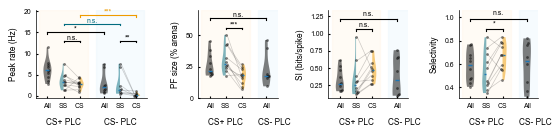


CS+ PLCs: n = 10, CS- PLCs: n = 8


In [339]:
def _half_violin_panel(ax, positions, data_list, colors_list, paired_specs, rng_seed=42):
    """
    Plot half-violins for paired groups, full violins for unpaired.
    
    paired_specs: list of (left_idx, right_idx) into positions/data_list
        e.g. [(1,2)] means positions[1] and positions[2] are paired (SS-CS).
        Left gets left-half violin + right-side dots; right gets right-half + left-side dots.
    """
    paired_left = {spec[0] for spec in paired_specs}
    paired_right = {spec[1] for spec in paired_specs}
    
    # Plot violins
    for i, (pos, data, c) in enumerate(zip(positions, data_list, colors_list)):
        if len(data) < 3:
            continue
        parts = ax.violinplot([data], positions=[pos], showmedians=True, showextrema=False)
        _style_violin_medians(parts)
        body = parts['bodies'][0]
        body.set_facecolor(c)
        body.set_edgecolor('none')
        body.set_alpha(0.5)
        
        # Clip to half if paired
        verts = body.get_paths()[0].vertices
        segs = parts['cmedians'].get_segments()
        if i in paired_left:
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
            segs[0][:, 0] = np.clip(segs[0][:, 0], -np.inf, pos)
        elif i in paired_right:
            verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
            segs[0][:, 0] = np.clip(segs[0][:, 0], pos, np.inf)
        parts['cmedians'].set_segments(segs)
    
    # Paired lines + dots on inner side
    for left_idx, right_idx in paired_specs:
        left_pos = positions[left_idx]
        right_pos = positions[right_idx]
        left_data = data_list[left_idx]
        right_data = data_list[right_idx]
        n_pairs = min(len(left_data), len(right_data))
        for j in range(n_pairs):
            if np.isfinite(left_data[j]) and np.isfinite(right_data[j]):
                ax.plot([left_pos + 0.08, right_pos - 0.08],
                        [left_data[j], right_data[j]],
                        color='black', alpha=0.2, linewidth=0.5)
    
    # Beeswarm dots
    def _beeswarm(vals, base_x, direction):
        vals = np.asarray(vals, dtype=float)
        if len(vals) == 0:
            return np.array([])
        y_range = np.ptp(vals) if len(vals) > 1 else 1.0
        y_spacing = y_range * 0.04
        x_step = 0.06
        sorted_idx = np.argsort(vals)
        xs = np.zeros(len(vals))
        for si, oi in enumerate(sorted_idx):
            layer = 0
            while True:
                candidate = x_step * layer
                conflict = False
                for sj in range(si):
                    oj = sorted_idx[sj]
                    if abs(vals[oi] - vals[oj]) < y_spacing:
                        if abs(candidate - xs[oj]) < x_step * 0.9:
                            conflict = True
                            break
                if not conflict:
                    xs[oi] = candidate
                    break
                layer += 1
        return base_x + direction * (0.02 + xs)
    for i, (pos, data) in enumerate(zip(positions, data_list)):
        if len(data) < 1:
            continue
        if i in paired_left:
            xs = _beeswarm(data, pos, direction=1)
        elif i in paired_right:
            xs = _beeswarm(data, pos, direction=-1)
        else:
            xs = _beeswarm(data, pos, direction=1)
        ax.scatter(xs, data, s=4, color='black', alpha=0.5, linewidths=0)

# Combined 4-Panel Figure: CS+ PLC vs CS- PLC
# Order: Peak Rates, Summed PF Size, Spatial Information, Spatial Selectivity
# Peak Rates: 6 groups (CS+ All/SS/CS, CS- All/SS/CS)
# PF Size, SI & Selectivity: 5 groups (CS+ All/SS/CS, CS- All/SS) - no CS for CS- PLC
panel_w, panel_h = 1.5, 1.4
first_panel_ratio = 1.4  # Tune this: width of panel 1 relative to panels 2-4
fig, axes = plt.subplots(1, 4, figsize=(5.6, panel_h),
                         gridspec_kw={'width_ratios': [first_panel_ratio, 1, 1, 1]})

positions_6 = [1, 2, 3, 4.5, 5.5, 6.5]  # 6 positions
positions_5 = [1, 2, 3, 4.5, 5.5]  # 5 positions (no CS for CS- PLC)

# Arena size for PF size calculation
arena_width_cm = 20
arena_length_cm = 35.5
arena_area_cm2 = arena_width_cm * arena_length_cm

plot_cs_minus_ss = False  # Set to False to hide CS- PLC SS violin in panels 2-4

# ============================================================================
# Panel 1: Peak Rates (6 groups)
# ============================================================================
ax = axes[0]

# Get data
cs_all, cs_ss, cs_cs, cs_ss_paired, cs_cs_paired = get_peak_rate_data(df_cs_plc, peak_cs_csplc)
non_all, non_ss, non_cs, non_ss_paired, non_cs_paired = get_peak_rate_data(df_non_cs_plc, peak_cs_noncsplc)

# Add background shading
ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg, zorder=0)
ax.axvspan(4.0, 7.0, alpha=0.3, color=non_cs_plc_bg, zorder=0)

# Group labels
ax.text(2, -0.22, f'CS+ PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())
ax.text(5.5, -0.22, f'CS- PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())

data_list = [cs_all, cs_ss, cs_cs, non_all, non_ss, non_cs]
colors_list = [all_color, ss_color, cs_color, all_color, ss_color, cs_color]

ylim = _global_ylim(data_list)

_half_violin_panel(ax, positions_6, data_list, colors_list, paired_specs=[(1,2), (4,5)])

# Formatting
ax.set_ylabel('Peak rate (Hz)', fontsize=6, fontname='Arial')
ax.set_xticks(positions_6)
ax.set_xticklabels(['All', 'SS', 'CS', 'All', 'SS', 'CS'], fontsize=4, fontname='Arial')
ax.set_xlim(0.3, 7.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=5)

# Brackets
if ylim:
    y_range = ylim[1] - ylim[0]
    ax.set_ylim(ylim[0], ylim[1] + y_range * 0.65)
    h = y_range * 0.03
    text_h = y_range * 0.08
    gap = y_range * 0.05
    y1 = ylim[1] + y_range * 0.05
    
    # Level 1: Paired
    if len(cs_ss_paired) >= 3:
        p, _, _, _, _ = _paired_test(cs_ss_paired, cs_cs_paired)
        add_bracket(ax, 2, 3, y1, h, _sig_label(p))
    if len(non_ss_paired) >= 3:
        p, _, _, _, _ = _paired_test(non_ss_paired, non_cs_paired)
        add_bracket(ax, 5.5, 6.5, y1, h, _sig_label(p))
    
    # Level 2-4: Unpaired
    y2 = y1 + h + text_h + gap
    if len(cs_all) >= 3 and len(non_all) >= 3:
        p, _, _, _ = unpaired_test_auto(cs_all, non_all)
        add_bracket(ax, 1, 4.5, y2, h, _sig_label(p), color=all_color)
    y3 = y2 + h + text_h + gap
    if len(cs_ss) >= 3 and len(non_ss) >= 3:
        p, _, _, _ = unpaired_test_auto(cs_ss, non_ss)
        add_bracket(ax, 2, 5.5, y3, h, _sig_label(p), color=ss_color)
    y4 = y3 + h + text_h + gap
    if len(cs_cs) >= 3 and len(non_cs) >= 3:
        p, _, _, _ = unpaired_test_auto(cs_cs, non_cs)
        add_bracket(ax, 3, 6.5, y4, h, _sig_label(p), color=cs_color)

# ============================================================================
# Panel 2: Summed Place Field Size (5 groups - no CS for CS- PLC)
# ============================================================================
ax = axes[1]

def get_pf_size_sum(df_subset, peak_cs_vals):
    """Get summed PF size as % arena."""
    all_sizes = []
    ss_sizes = []
    cs_sizes = []
    
    for idx in df_subset.index:
        sizes = df_subset.loc[idx, 'place_field_sizes_cm2']
        if isinstance(sizes, (list, np.ndarray)) and len(sizes) > 0:
            all_sizes.append(np.sum(sizes) / arena_area_cm2 * 100)
        else:
            all_sizes.append(np.nan)
        
        sizes = df_subset.loc[idx, 'place_field_sizes_cm2_ss']
        if isinstance(sizes, (list, np.ndarray)) and len(sizes) > 0:
            ss_sizes.append(np.sum(sizes) / arena_area_cm2 * 100)
        else:
            ss_sizes.append(np.nan)
        
        sizes = df_subset.loc[idx, 'place_field_sizes_cm2_cs']
        if isinstance(sizes, (list, np.ndarray)) and len(sizes) > 0:
            cs_sizes.append(np.sum(sizes) / arena_area_cm2 * 100)
        else:
            cs_sizes.append(np.nan)
    
    all_sizes = np.array(all_sizes)
    ss_sizes = np.array(ss_sizes)
    cs_sizes = np.array(cs_sizes)
    peak_cs_vals = np.asarray(peak_cs_vals)
    
    all_valid = all_sizes[np.isfinite(all_sizes)]
    ss_valid = ss_sizes[np.isfinite(ss_sizes)]
    cs_mask = np.isfinite(cs_sizes)
    cs_valid = cs_sizes[cs_mask]
    
    paired_mask = np.isfinite(ss_sizes) & np.isfinite(cs_sizes)
    ss_paired = ss_sizes[paired_mask]
    cs_paired = cs_sizes[paired_mask]
    
    return all_valid, ss_valid, cs_valid, ss_paired, cs_paired

pf_cs_all, pf_cs_ss, pf_cs_cs, pf_cs_ss_paired, pf_cs_cs_paired = get_pf_size_sum(df_cs_plc, peak_cs_csplc)
pf_non_all, pf_non_ss, _, _, _ = get_pf_size_sum(df_non_cs_plc, peak_cs_noncsplc)

# Background shading
ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg, zorder=0)
ax.axvspan(4.0, 6.0, alpha=0.3, color=non_cs_plc_bg, zorder=0)

# Group labels
ax.text(2, -0.22, f'CS+ PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())
ax.text(5, -0.22, f'CS- PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())

if plot_cs_minus_ss:
    pf_data_list = [pf_cs_all, pf_cs_ss, pf_cs_cs, pf_non_all, pf_non_ss]
    pf_colors_list = [all_color, ss_color, cs_color, all_color, ss_color]
    pf_positions = positions_5
else:
    pf_data_list = [pf_cs_all, pf_cs_ss, pf_cs_cs, pf_non_all]
    pf_colors_list = [all_color, ss_color, cs_color, all_color]
    pf_positions = [1, 2, 3, 4.5]
data_list = pf_data_list
colors_list = pf_colors_list

ylim = _global_ylim(data_list)

_half_violin_panel(ax, pf_positions, data_list, colors_list, paired_specs=[(1,2)])

ax.set_ylabel('PF size (% arena)', fontsize=6, fontname='Arial')
ax.set_xticks(pf_positions)
ax.set_xticklabels(['All', 'SS', 'CS', 'All', 'SS'][:len(pf_positions)], fontsize=4, fontname='Arial')
ax.set_xlim(0.3, 6.2 if plot_cs_minus_ss else 5.2)
ax.set_ylim(0, 100)
ax.set_yticks([0, 25, 50, 75, 100])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=5)

# Brackets
if ylim:
    y_range = ylim[1] - ylim[0]
    h = y_range * 0.03
    text_h = y_range * 0.08
    gap = y_range * 0.05
    y_top = y1 = ylim[1] + y_range * 0.05
    
    # Level 1: Paired SS vs CS within CS+ group only
    if len(pf_cs_ss_paired) >= 3:
        p, _, _, _, _ = _paired_test(pf_cs_ss_paired, pf_cs_cs_paired)
        add_bracket(ax, 2, 3, y1, h, _sig_label(p))
        y_top = y1 + h + text_h
    
    # Level 2: All comparison
    y2 = y1 + h + text_h + gap
    if len(pf_cs_all) >= 3 and len(pf_non_all) >= 3:
        p, _, _, _ = unpaired_test_auto(pf_cs_all, pf_non_all)
        add_bracket(ax, 1, 4.5, y2, h, _sig_label(p), color=all_color)
        y_top = y2 + h + text_h
    
    # Level 3: SS comparison
    y3 = y2 + h + text_h + gap
    if plot_cs_minus_ss and len(pf_cs_ss) >= 3 and len(pf_non_ss) >= 3:
        p, _, _, _ = unpaired_test_auto(pf_cs_ss, pf_non_ss)
        add_bracket(ax, 2, 5.5, y3, h, _sig_label(p), color=ss_color)
        y_top = y3 + h + text_h
    
    ax.set_ylim(0, y_top + y_range * 0.05)

# ============================================================================
# Panel 3: Spatial Information (5 groups - no CS for CS- PLC)
# ============================================================================
ax = axes[2]

def get_si_data(df_subset, peak_cs_vals):
    """Get spatial information data."""
    all_si = df_subset['si_bits_per_spike'].values
    ss_si = df_subset['si_bits_per_spike_ss'].values
    cs_si = df_subset['si_bits_per_spike_cs'].values
    
    all_valid = all_si[np.isfinite(all_si)]
    ss_valid = ss_si[np.isfinite(ss_si)]
    cs_valid = cs_si[np.isfinite(cs_si)]
    
    paired_mask = np.isfinite(ss_si) & np.isfinite(cs_si)
    ss_paired = ss_si[paired_mask]
    cs_paired = cs_si[paired_mask]
    
    return all_valid, ss_valid, cs_valid, ss_paired, cs_paired

si_cs_all, si_cs_ss, si_cs_cs, si_cs_ss_paired, si_cs_cs_paired = get_si_data(df_cs_plc, peak_cs_csplc)
si_non_all, si_non_ss, _, _, _ = get_si_data(df_non_cs_plc, peak_cs_noncsplc)

ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg, zorder=0)
ax.axvspan(4.0, 6.0, alpha=0.3, color=non_cs_plc_bg, zorder=0)

ax.text(2, -0.22, f'CS+ PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())
ax.text(5, -0.22, f'CS- PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())

if plot_cs_minus_ss:
    si_data_list = [si_cs_all, si_cs_ss, si_cs_cs, si_non_all, si_non_ss]
    si_colors_list = [all_color, ss_color, cs_color, all_color, ss_color]
    si_positions = positions_5
else:
    si_data_list = [si_cs_all, si_cs_ss, si_cs_cs, si_non_all]
    si_colors_list = [all_color, ss_color, cs_color, all_color]
    si_positions = [1, 2, 3, 4.5]
data_list = si_data_list
colors_list = si_colors_list

ylim = _global_ylim(data_list)

_half_violin_panel(ax, si_positions, data_list, colors_list, paired_specs=[(1,2)])

ax.set_ylabel('SI (bits/spike)', fontsize=6, fontname='Arial')
ax.set_xticks(si_positions)
ax.set_xticklabels(['All', 'SS', 'CS', 'All', 'SS'][:len(si_positions)], fontsize=4, fontname='Arial')
ax.set_xlim(0.3, 6.2 if plot_cs_minus_ss else 5.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=5)

if ylim:
    y_range = ylim[1] - ylim[0]
    h = y_range * 0.03
    text_h = y_range * 0.08
    gap = y_range * 0.05
    y_top = y1 = ylim[1] + y_range * 0.05
    
    # Level 1: Paired SS vs CS within CS+ group only
    if len(si_cs_ss_paired) >= 3:
        p, _, _, _, _ = _paired_test(si_cs_ss_paired, si_cs_cs_paired)
        add_bracket(ax, 2, 3, y1, h, _sig_label(p))
        y_top = y1 + h + text_h
    
    # Level 2: All comparison
    y2 = y1 + h + text_h + gap
    if len(si_cs_all) >= 3 and len(si_non_all) >= 3:
        p, _, _, _ = unpaired_test_auto(si_cs_all, si_non_all)
        add_bracket(ax, 1, 4.5, y2, h, _sig_label(p), color=all_color)
        y_top = y2 + h + text_h
    
    # Level 3: SS comparison
    y3 = y2 + h + text_h + gap
    if plot_cs_minus_ss and len(si_cs_ss) >= 3 and len(si_non_ss) >= 3:
        p, _, _, _ = unpaired_test_auto(si_cs_ss, si_non_ss)
        add_bracket(ax, 2, 5.5, y3, h, _sig_label(p), color=ss_color)
        y_top = y3 + h + text_h
    
    ax.set_ylim(ylim[0], y_top + y_range * 0.05)

# ============================================================================
# Panel 4: Spatial Selectivity (5 groups - no CS for CS- PLC)
# ============================================================================
ax = axes[3]

def get_selectivity_data_combined(df_subset, peak_cs_vals):
    """Get spatial selectivity data computed from in/out rates."""
    # Compute selectivity for each spike type
    all_in = df_subset['all_inout_loco_in'].values
    all_out = df_subset['all_inout_loco_out'].values
    all_sum = all_in + all_out
    all_selectivity = np.where((all_sum > 0) & np.isfinite(all_in) & np.isfinite(all_out),
                               (all_in - all_out) / all_sum, np.nan)
    
    ss_in = df_subset['ss_inout_loco_in'].values
    ss_out = df_subset['ss_inout_loco_out'].values
    ss_sum = ss_in + ss_out
    ss_selectivity = np.where((ss_sum > 0) & np.isfinite(ss_in) & np.isfinite(ss_out),
                              (ss_in - ss_out) / ss_sum, np.nan)
    
    cs_in = df_subset['cs_inout_loco_in'].values
    cs_out = df_subset['cs_inout_loco_out'].values
    cs_sum = cs_in + cs_out
    cs_selectivity = np.where((cs_sum > 0) & np.isfinite(cs_in) & np.isfinite(cs_out),
                              (cs_in - cs_out) / cs_sum, np.nan)
    
    peak_cs_vals = np.asarray(peak_cs_vals)
    
    all_valid = all_selectivity[np.isfinite(all_selectivity)]
    ss_valid = ss_selectivity[np.isfinite(ss_selectivity)]
    cs_valid = cs_selectivity[np.isfinite(cs_selectivity)]
    
    # For paired test: need both SS and CS valid
    paired_mask = np.isfinite(ss_selectivity) & np.isfinite(cs_selectivity)
    ss_paired = ss_selectivity[paired_mask]
    cs_paired = cs_selectivity[paired_mask]
    
    return all_valid, ss_valid, cs_valid, ss_paired, cs_paired

sel_cs_all, sel_cs_ss, sel_cs_cs, sel_cs_ss_paired, sel_cs_cs_paired = get_selectivity_data_combined(df_cs_plc, peak_cs_csplc)
sel_non_all, sel_non_ss, _, _, _ = get_selectivity_data_combined(df_non_cs_plc, peak_cs_noncsplc)

ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg, zorder=0)
ax.axvspan(4.0, 6.0, alpha=0.3, color=non_cs_plc_bg, zorder=0)

ax.text(2, -0.22, f'CS+ PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())
ax.text(5, -0.22, f'CS- PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())

if plot_cs_minus_ss:
    sel_data_list = [sel_cs_all, sel_cs_ss, sel_cs_cs, sel_non_all, sel_non_ss]
    sel_colors_list = [all_color, ss_color, cs_color, all_color, ss_color]
    sel_positions = positions_5
else:
    sel_data_list = [sel_cs_all, sel_cs_ss, sel_cs_cs, sel_non_all]
    sel_colors_list = [all_color, ss_color, cs_color, all_color]
    sel_positions = [1, 2, 3, 4.5]
data_list = sel_data_list
colors_list = sel_colors_list

ylim = _global_ylim(data_list)

_half_violin_panel(ax, sel_positions, data_list, colors_list, paired_specs=[(1,2)])

ax.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

ax.set_ylabel('Selectivity', fontsize=6, fontname='Arial')
ax.set_xticks(sel_positions)
ax.set_xticklabels(['All', 'SS', 'CS', 'All', 'SS'][:len(sel_positions)], fontsize=4, fontname='Arial')
ax.set_xlim(0.3, 6.2 if plot_cs_minus_ss else 5.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=5)

if ylim:
    y_range = ylim[1] - ylim[0]
    h = y_range * 0.03
    text_h = y_range * 0.08
    gap = y_range * 0.05
    y_top = y1 = ylim[1] + y_range * 0.05
    
    # Level 1: Paired SS vs CS within CS+ group only
    if len(sel_cs_ss_paired) >= 3:
        p, _, _, _, _ = _paired_test(sel_cs_ss_paired, sel_cs_cs_paired)
        add_bracket(ax, 2, 3, y1, h, _sig_label(p))
        y_top = y1 + h + text_h
    
    # Level 2: All comparison
    y2 = y1 + h + text_h + gap
    if len(sel_cs_all) >= 3 and len(sel_non_all) >= 3:
        p, _, _, _ = unpaired_test_auto(sel_cs_all, sel_non_all)
        add_bracket(ax, 1, 4.5, y2, h, _sig_label(p), color=all_color)
        y_top = y2 + h + text_h
    
    # Level 3: SS comparison
    y3 = y2 + h + text_h + gap
    if plot_cs_minus_ss and len(sel_cs_ss) >= 3 and len(sel_non_ss) >= 3:
        p, _, _, _ = unpaired_test_auto(sel_cs_ss, sel_non_ss)
        add_bracket(ax, 2, 5.5, y3, h, _sig_label(p), color=ss_color)
        y_top = y3 + h + text_h
    
    ax.set_ylim(ylim[0], y_top + y_range * 0.05)

plt.tight_layout()
save_path = os.path.join(figure_save_folder, 'combined_cs_plus_minus_4panels.svg')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

print(f"\nCS+ PLCs: n = {len(df_cs_plc)}, CS- PLCs: n = {len(df_non_cs_plc)}")

Peak rate vs PF size [CS]: n=10, r=0.183, p=0.614
Peak rate vs PF size [SS]: n=10, r=0.235, p=0.513
SI vs Peak rate [CS]: n=10, r=0.318, p=0.371
SI vs Peak rate [SS]: n=10, r=0.007, p=0.984
Peak rate vs Selectivity [CS]: n=10, r=0.290, p=0.417
Peak rate vs Selectivity [SS]: n=10, r=0.028, p=0.938
SI vs PF size [CS]: n=10, r=-0.602, p=0.0656
SI vs PF size [SS]: n=10, r=-0.529, p=0.116
Selectivity vs PF size [CS]: n=10, r=-0.636, p=0.0482
Selectivity vs PF size [SS]: n=10, r=-0.463, p=0.177
SI vs Selectivity [CS]: n=10, r=0.938, p=5.84e-05
SI vs Selectivity [SS]: n=10, r=0.906, p=0.000304
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/cs_plus_plc_correlations_overlay_cs_ss.svg


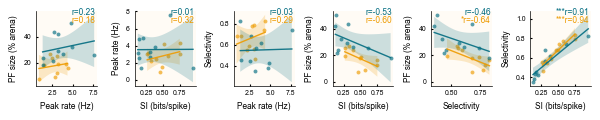

In [340]:
# Correlations (CS+ PLCs only): CS peak rate vs other CS metrics

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
import os

cs_color_local = globals().get('cs_color', '#EE9B00')
ss_color_local = globals().get('ss_color', '#026C80')
cs_plc_bg_local = globals().get('cs_plc_bg', globals().get('cs_plc_bg_color', '#f3c6df'))
overlay_ss_metrics = True  # set True to overlay SS + CS in same axes

# Arena area (re-use if already defined above)
arena_area_cm2_local = globals().get('arena_area_cm2', None)
if arena_area_cm2_local is None:
    arena_width_cm = float(globals().get('arena_width_cm', 20))
    arena_length_cm = float(globals().get('arena_length_cm', 35.5))
    arena_area_cm2_local = arena_width_cm * arena_length_cm

def _sig_stars(p):
    if not np.isfinite(p):
        return ''
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''

def _style_corr_axis(ax, bg_color=None, bg_alpha=0.3):
    if bg_color is not None:
        ax.set_facecolor(bg_color)
        ax.patch.set_alpha(float(bg_alpha))
    ax.tick_params(labelsize=5)
    for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
        label.set_fontname('Arial')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def _confidence_interval_corr(x, y, x_pred, confidence=0.95):
    """Calculate 95% confidence interval for regression line."""
    n = len(x)
    if n < 3:
        return np.full_like(x_pred, np.nan), np.full_like(x_pred, np.nan)
    
    # Regression
    slope, intercept, r, p, se = scipy_stats.linregress(x, y)
    y_pred = slope * x_pred + intercept
    
    # Residuals and standard error
    y_fit = slope * x + intercept
    residuals = y - y_fit
    s_err = np.sqrt(np.sum(residuals**2) / (n - 2))  # Standard error of estimate
    
    # Mean of x and sum of squared deviations
    x_mean = np.mean(x)
    ss_x = np.sum((x - x_mean)**2)
    
    # t-value for confidence interval
    t_val = scipy_stats.t.ppf((1 + confidence) / 2, n - 2)
    
    # Confidence interval for each predicted point
    ci = t_val * s_err * np.sqrt(1/n + (x_pred - x_mean)**2 / ss_x)
    
    return y_pred - ci, y_pred + ci

def _plot_corr_series(ax, x, y, series_label, color, xlabel, ylabel, panel_name, text_y=0.02, linestyle='-'):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size < 3:
        print(f"{panel_name} [{series_label}]: n={x.size} (skip, n<3)")
        return False

    ax.scatter(x, y, s=8, color=color, alpha=0.65, linewidths=0)
    lr = scipy_stats.linregress(x, y)
    x_line = np.linspace(float(np.nanmin(x)), float(np.nanmax(x)), 100)
    y_line = lr.intercept + lr.slope * x_line
    ax.plot(x_line, y_line, color=color, linewidth=1.0, alpha=0.9, linestyle=linestyle)
    
    # Add 95% confidence interval
    ci_low, ci_high = _confidence_interval_corr(x, y, x_line)
    ax.fill_between(x_line, ci_low, ci_high, color=color, alpha=0.2, edgecolor='none')

    r, p = scipy_stats.pearsonr(x, y)
    stars = _sig_stars(p)
    print(f"{panel_name} [{series_label}]: n={x.size}, r={r:.3f}, p={p:.3g}")
    ax.text(
        0.98,
        float(text_y),
        f"{stars}r={r:.2f}",
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=6,
        fontname='Arial',
        color=color,
    )

    ax.set_xlabel(xlabel, fontsize=6, fontname='Arial')
    ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
    return True

# X: CS peak rate (Hz)
if 'peak_rate_cs' not in df_cs_plc.columns:
    raise KeyError("df_cs_plc missing column 'peak_rate_cs'")
x_peak_cs = np.asarray(df_cs_plc['peak_rate_cs'].values, dtype=float)

# Y1: summed CS PF size (% arena)
if 'place_field_sizes_cm2_cs' not in df_cs_plc.columns:
    raise KeyError("df_cs_plc missing column 'place_field_sizes_cm2_cs'")
pf_sizes_cs_pct = []
for sizes in df_cs_plc['place_field_sizes_cm2_cs'].values:
    if isinstance(sizes, (list, tuple, np.ndarray)) and len(sizes) > 0:
        s = np.asarray(sizes, dtype=float)
        s = s[np.isfinite(s)]
        pf_sizes_cs_pct.append(float(np.nansum(s) / float(arena_area_cm2_local) * 100.0) if s.size else np.nan)
    else:
        pf_sizes_cs_pct.append(np.nan)
pf_sizes_cs_pct = np.asarray(pf_sizes_cs_pct, dtype=float)

# Y2: CS spatial information (bits/spike)
if 'si_bits_per_spike_cs' not in df_cs_plc.columns:
    raise KeyError("df_cs_plc missing column 'si_bits_per_spike_cs'")
si_cs = np.asarray(df_cs_plc['si_bits_per_spike_cs'].values, dtype=float)

# Y3: CS spatial selectivity (from in/out rates)
if 'cs_inout_loco_in' not in df_cs_plc.columns or 'cs_inout_loco_out' not in df_cs_plc.columns:
    raise KeyError("df_cs_plc missing 'cs_inout_loco_in' and/or 'cs_inout_loco_out'")
cs_in = np.asarray(df_cs_plc['cs_inout_loco_in'].values, dtype=float)
cs_out = np.asarray(df_cs_plc['cs_inout_loco_out'].values, dtype=float)
cs_sum = cs_in + cs_out
cs_selectivity = np.where(
    (cs_sum > 0) & np.isfinite(cs_in) & np.isfinite(cs_out),
    (cs_in - cs_out) / cs_sum,
    np.nan,
)

def _pf_sizes_pct_from_col(df, col_name):
    if col_name not in df.columns:
        raise KeyError(f"df_cs_plc missing column '{col_name}'")
    out = []
    for sizes in df[col_name].values:
        if isinstance(sizes, (list, tuple, np.ndarray)) and len(sizes) > 0:
            s = np.asarray(sizes, dtype=float)
            s = s[np.isfinite(s)]
            out.append(float(np.nansum(s) / float(arena_area_cm2_local) * 100.0) if s.size else np.nan)
        else:
            out.append(np.nan)
    return np.asarray(out, dtype=float)

def _selectivity_from_cols(df, in_col, out_col):
    if in_col not in df.columns or out_col not in df.columns:
        raise KeyError(f"df_cs_plc missing '{in_col}' and/or '{out_col}'")
    v_in = np.asarray(df[in_col].values, dtype=float)
    v_out = np.asarray(df[out_col].values, dtype=float)
    v_sum = v_in + v_out
    return np.where(
        (v_sum > 0) & np.isfinite(v_in) & np.isfinite(v_out),
        (v_in - v_out) / v_sum,
        np.nan,
    )

fig, axes = plt.subplots(1, 6, figsize=(1.0 * 6, 1.2))

# Make axes[3] and axes[4] share y-axis (both show PF size)
axes[4].sharey(axes[3])

# Optional SS series (overlay)
x_peak_ss = None
pf_sizes_ss_pct = None
si_ss = None
ss_selectivity = None
if overlay_ss_metrics:
    if 'peak_rate_ss' not in df_cs_plc.columns:
        raise KeyError("df_cs_plc missing column 'peak_rate_ss'")
    if 'si_bits_per_spike_ss' not in df_cs_plc.columns:
        raise KeyError("df_cs_plc missing column 'si_bits_per_spike_ss'")
    x_peak_ss = np.asarray(df_cs_plc['peak_rate_ss'].values, dtype=float)
    pf_sizes_ss_pct = _pf_sizes_pct_from_col(df_cs_plc, 'place_field_sizes_cm2_ss')
    si_ss = np.asarray(df_cs_plc['si_bits_per_spike_ss'].values, dtype=float)
    ss_selectivity = _selectivity_from_cols(df_cs_plc, 'ss_inout_loco_in', 'ss_inout_loco_out')

panels = [
    # (ax, x_cs, y_cs, x_ss, y_ss, xlabel, ylabel, panel_name)
    (axes[0], x_peak_cs, pf_sizes_cs_pct, x_peak_ss, pf_sizes_ss_pct, 'Peak rate (Hz)', 'PF size (% arena)', 'Peak rate vs PF size'),
    (axes[1], si_cs, x_peak_cs, si_ss, x_peak_ss, 'SI (bits/spike)', 'Peak rate (Hz)', 'SI vs Peak rate'),
    (axes[2], x_peak_cs, cs_selectivity, x_peak_ss, ss_selectivity, 'Peak rate (Hz)', 'Selectivity', 'Peak rate vs Selectivity'),
    (axes[3], si_cs, pf_sizes_cs_pct, si_ss, pf_sizes_ss_pct, 'SI (bits/spike)', 'PF size (% arena)', 'SI vs PF size'),
    (axes[4], cs_selectivity, pf_sizes_cs_pct, ss_selectivity, pf_sizes_ss_pct, 'Selectivity', 'PF size (% arena)', 'Selectivity vs PF size'),
    (axes[5], si_cs, cs_selectivity, si_ss, ss_selectivity, 'SI (bits/spike)', 'Selectivity', 'SI vs Selectivity'),
]

for ax, x_cs, y_cs, x_ss, y_ss, xlabel, ylabel, panel_name in panels:
    _style_corr_axis(ax, bg_color=cs_plc_bg_local)
    any_plotted = False
    any_plotted |= _plot_corr_series(
        ax,
        x_cs,
        y_cs,
        series_label='CS',
        color=cs_color_local,
        xlabel=xlabel,
        ylabel=ylabel,
        panel_name=panel_name,
        text_y=0.82,
        linestyle='-',
    )
    if overlay_ss_metrics:
        any_plotted |= _plot_corr_series(
            ax,
            x_ss,
            y_ss,
            series_label='SS',
            color=ss_color_local,
            xlabel=xlabel,
            ylabel=ylabel,
            panel_name=panel_name,
            text_y=0.92,
            linestyle='-',
        )
    if not any_plotted:
        ax.axis('off')

plt.tight_layout()
save_name = 'cs_plus_plc_correlations_overlay_cs_ss.svg' if overlay_ss_metrics else 'cs_plus_plc_correlations.svg'
save_path = os.path.join(figure_save_folder, save_name)
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()


Peak rate vs PF size [SS]: n=8, r=-0.442, p=0.272
SI vs Peak rate [SS]: n=8, r=0.771, p=0.0252
Peak rate vs Selectivity [SS]: n=8, r=0.663, p=0.0729
SI vs PF size [SS]: n=8, r=-0.840, p=0.00902
SI vs Selectivity [SS]: n=8, r=0.982, p=1.37e-05
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/cs_minus_plc_correlations_ss.svg


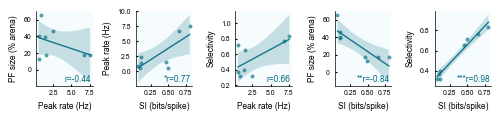

In [341]:
# Correlations (CS- PLCs): SS metrics (CS optional)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
import os

cs_color_local = globals().get('cs_color', '#EE9B00')
ss_color_local = globals().get('ss_color', '#026C80')
non_cs_plc_bg_local = globals().get('non_cs_plc_bg', globals().get('non_cs_plc_bg_color', '#E3F2FD'))
overlay_cs_metrics = False  # set True to overlay CS + SS in same axes

# Arena area (re-use if already defined above)
arena_area_cm2_local = globals().get('arena_area_cm2', None)
if arena_area_cm2_local is None:
    arena_width_cm = float(globals().get('arena_width_cm', 20))
    arena_length_cm = float(globals().get('arena_length_cm', 35.5))
    arena_area_cm2_local = arena_width_cm * arena_length_cm

# Reuse helpers from the CS+ cell if present; otherwise define minimal versions.
if '_sig_stars' not in globals():
    def _sig_stars(p):
        if not np.isfinite(p):
            return ''
        if p < 0.001:
            return '***'
        if p < 0.01:
            return '**'
        if p < 0.05:
            return '*'
        return ''

if '_style_corr_axis' not in globals():
    def _style_corr_axis(ax, bg_color=None, bg_alpha=0.3):
        if bg_color is not None:
            ax.set_facecolor(bg_color)
            ax.patch.set_alpha(float(bg_alpha))
        ax.tick_params(labelsize=5)
        for label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
            label.set_fontname('Arial')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

if '_plot_corr_series' not in globals():
    def _plot_corr_series(ax, x, y, series_label, color, xlabel, ylabel, panel_name, text_y=0.02, linestyle='-'):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]
        if x.size < 3:
            print(f"{panel_name} [{series_label}]: n={x.size} (skip, n<3)")
            return False
        ax.scatter(x, y, s=12, color=color, alpha=0.65, linewidths=0)
        lr = scipy_stats.linregress(x, y)
        x_line = np.linspace(float(np.nanmin(x)), float(np.nanmax(x)), 100)
        y_line = lr.intercept + lr.slope * x_line
        ax.plot(x_line, y_line, color=color, linewidth=1.0, alpha=0.9, linestyle=linestyle)
        r, p = scipy_stats.pearsonr(x, y)
        stars = _sig_stars(p)
        print(f"{panel_name} [{series_label}]: n={x.size}, r={r:.3f}, p={p:.3g}")
        ax.text(
            0.98,
            float(text_y),
            f"{stars}r={r:.2f}",
            transform=ax.transAxes,
            ha='right',
            va='bottom',
            fontsize=6,
            fontname='Arial',
            color=color,
        )
        ax.set_xlabel(xlabel, fontsize=6, fontname='Arial')
        ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
        return True

def _pf_sizes_pct_from_col_local(df, col_name):
    if col_name not in df.columns:
        raise KeyError(f"df_non_cs_plc missing column '{col_name}'")
    out = []
    for sizes in df[col_name].values:
        if isinstance(sizes, (list, tuple, np.ndarray)) and len(sizes) > 0:
            s = np.asarray(sizes, dtype=float)
            s = s[np.isfinite(s)]
            out.append(float(np.nansum(s) / float(arena_area_cm2_local) * 100.0) if s.size else np.nan)
        else:
            out.append(np.nan)
    return np.asarray(out, dtype=float)

def _selectivity_from_cols_local(df, in_col, out_col):
    if in_col not in df.columns or out_col not in df.columns:
        raise KeyError(f"df_non_cs_plc missing '{in_col}' and/or '{out_col}'")
    v_in = np.asarray(df[in_col].values, dtype=float)
    v_out = np.asarray(df[out_col].values, dtype=float)
    v_sum = v_in + v_out
    return np.where(
        (v_sum > 0) & np.isfinite(v_in) & np.isfinite(v_out),
        (v_in - v_out) / v_sum,
        np.nan,
    )

# SS metrics (required)
if 'peak_rate_ss' not in df_non_cs_plc.columns:
    raise KeyError("df_non_cs_plc missing column 'peak_rate_ss'")
if 'si_bits_per_spike_ss' not in df_non_cs_plc.columns:
    raise KeyError("df_non_cs_plc missing column 'si_bits_per_spike_ss'")
x_peak_ss = np.asarray(df_non_cs_plc['peak_rate_ss'].values, dtype=float)
pf_sizes_ss_pct = _pf_sizes_pct_from_col_local(df_non_cs_plc, 'place_field_sizes_cm2_ss')
si_ss = np.asarray(df_non_cs_plc['si_bits_per_spike_ss'].values, dtype=float)
ss_selectivity = _selectivity_from_cols_local(df_non_cs_plc, 'ss_inout_loco_in', 'ss_inout_loco_out')

# CS metrics (optional)
x_peak_cs = None
pf_sizes_cs_pct = None
si_cs = None
cs_selectivity = None
if overlay_cs_metrics:
    required_cols = [
        'peak_rate_cs',
        'si_bits_per_spike_cs',
        'place_field_sizes_cm2_cs',
        'cs_inout_loco_in',
        'cs_inout_loco_out',
    ]
    missing = [c for c in required_cols if c not in df_non_cs_plc.columns]
    if missing:
        print(f"CS overlay disabled (missing columns): {missing}")
        overlay_cs_metrics = False
    else:
        x_peak_cs = np.asarray(df_non_cs_plc['peak_rate_cs'].values, dtype=float)
        pf_sizes_cs_pct = _pf_sizes_pct_from_col_local(df_non_cs_plc, 'place_field_sizes_cm2_cs')
        si_cs = np.asarray(df_non_cs_plc['si_bits_per_spike_cs'].values, dtype=float)
        cs_selectivity = _selectivity_from_cols_local(df_non_cs_plc, 'cs_inout_loco_in', 'cs_inout_loco_out')

fig, axes = plt.subplots(1, 5, figsize=(1.0 * 5, 1.2))

panels = [
    # (ax, x_ss, y_ss, x_cs, y_cs, xlabel, ylabel, panel_name)
    (axes[0], x_peak_ss, pf_sizes_ss_pct, x_peak_cs, pf_sizes_cs_pct, 'Peak rate (Hz)', 'PF size (% arena)', 'Peak rate vs PF size'),
    (axes[1], si_ss, x_peak_ss, si_cs, x_peak_cs, 'SI (bits/spike)', 'Peak rate (Hz)', 'SI vs Peak rate'),
    (axes[2], x_peak_ss, ss_selectivity, x_peak_cs, cs_selectivity, 'Peak rate (Hz)', 'Selectivity', 'Peak rate vs Selectivity'),
    (axes[3], si_ss, pf_sizes_ss_pct, si_cs, pf_sizes_cs_pct, 'SI (bits/spike)', 'PF size (% arena)', 'SI vs PF size'),
    (axes[4], si_ss, ss_selectivity, si_cs, cs_selectivity, 'SI (bits/spike)', 'Selectivity', 'SI vs Selectivity'),
]

for ax, x_ss, y_ss, x_cs, y_cs, xlabel, ylabel, panel_name in panels:
    _style_corr_axis(ax, bg_color=non_cs_plc_bg_local)
    any_plotted = False
    any_plotted |= _plot_corr_series(
        ax,
        x_ss,
        y_ss,
        series_label='SS',
        color=ss_color_local,
        xlabel=xlabel,
        ylabel=ylabel,
        panel_name=panel_name,
        text_y=0.02,
        linestyle='-',
    )
    if overlay_cs_metrics:
        any_plotted |= _plot_corr_series(
            ax,
            x_cs,
            y_cs,
            series_label='CS',
            color=cs_color_local,
            xlabel=xlabel,
            ylabel=ylabel,
            panel_name=panel_name,
            text_y=0.10,
            linestyle='-',
        )
    if not any_plotted:
        ax.axis('off')

plt.tight_layout()
save_name = 'cs_minus_plc_correlations_overlay_ss_cs.svg' if overlay_cs_metrics else 'cs_minus_plc_correlations_ss.svg'
save_path = os.path.join(figure_save_folder, save_name)
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()


# 5. In-Out Ratios (Place Cells)

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/inout_rates_pc_loco.svg


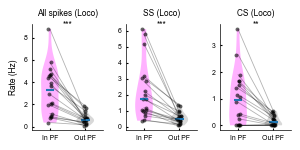


IN-OUT RATIOS: In PF vs Out PF (Place Cells, Locomotion)

All spikes (n=18 cells):
  In PF:  3.27 ± 2.14 Hz
  Out PF: 0.75 ± 0.48 Hz
  Test:   paired t-test, p = 3.96e-05

SS (n=18 cells):
  In PF:  2.24 ± 1.75 Hz
  Out PF: 0.57 ± 0.36 Hz
  Test:   wilcoxon, p = 7.63e-06

CS (n=18 cells):
  In PF:  1.03 ± 1.00 Hz
  Out PF: 0.18 ± 0.19 Hz
  Test:   wilcoxon, p = 1.21e-03


In [342]:
# In-Out Ratios - Violin plots (Place Cells, Locomotion only)
# Using consistent plot_violin_panel style

panel_w, panel_h = 1.0, 1.5
fig, axes = plt.subplots(1, 3, figsize=(panel_w * 3, panel_h))

spike_types = ['all', 'ss', 'cs']
labels = ['All spikes', 'SS', 'CS']

stats_results = []
for ax, spike_type, label in zip(axes, spike_types, labels):
    vals_in = df_pc[f'{spike_type}_inout_loco_in'].dropna().values
    vals_out = df_pc[f'{spike_type}_inout_loco_out'].dropna().values
    
    ylim = _global_ylim([vals_in, vals_out])
    result = plot_violin_panel(ax, vals_in, vals_out, 'Rate (Hz)' if ax == axes[0] else '', ylim=ylim, show_ylabel=(ax == axes[0]))
    ax.set_title(f'{label} (Loco)', fontsize=6)
    
    if result is not None:
        p_val, test_stat, test_name, n_valid, shapiro_p = result
        stats_results.append({
            'label': label,
            'n_cells': n_valid,
            'test': test_name,
            'p_value': p_val,
            'in_mean': np.nanmean(vals_in),
            'in_std': np.nanstd(vals_in),
            'out_mean': np.nanmean(vals_out),
            'out_std': np.nanstd(vals_out)
        })

plt.tight_layout()
save_path = os.path.join(figure_save_folder, 'inout_rates_pc_loco.svg')
plt.savefig(save_path, dpi=300)
print(f'Saved: {save_path}')
plt.show()

# Print stats summary
print("\n" + "="*70)
print("IN-OUT RATIOS: In PF vs Out PF (Place Cells, Locomotion)")
print("="*70)
for res in stats_results:
    print(f"\n{res['label']} (n={res['n_cells']} cells):")
    print(f"  In PF:  {res['in_mean']:.2f} ± {res['in_std']:.2f} Hz")
    print(f"  Out PF: {res['out_mean']:.2f} ± {res['out_std']:.2f} Hz")
    print(f"  Test:   {res['test']}, p = {res['p_value']:.2e}")

# 6. Theta Amplitude In vs Out (Place Cells)

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/theta_inout_pc.svg


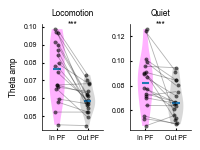


THETA AMPLITUDE: In PF vs Out PF (Place Cells)

Locomotion (n=18 cells):
  In PF:  0.075 ± 0.016
  Out PF: 0.059 ± 0.007
  Test:   paired t-test, p = 8.04e-05

Quiet (n=18 cells):
  In PF:  0.083 ± 0.021
  Out PF: 0.068 ± 0.014
  Test:   wilcoxon, p = 5.34e-04


In [343]:
# Theta Amplitude In vs Out (Place Cells)
# Matching style from PooledFigure_Combined_Violins.ipynb

panel_w, panel_h = 1.0, 1.5
fig, axes = plt.subplots(1, 2, figsize=(panel_w * 2, panel_h))

state_specs = [('loco', 'Locomotion'), ('quiet', 'Quiet')]

stats_results = []
for ax, (state, state_label) in zip(axes, state_specs):
    vals_in = df_pc[f'theta_{state}_in'].dropna().values
    vals_out = df_pc[f'theta_{state}_out'].dropna().values
    
    ylim = _global_ylim([vals_in, vals_out])
    result = plot_violin_panel(ax, vals_in, vals_out, 'Theta amp' if ax == axes[0] else '', ylim=ylim, show_ylabel=(ax == axes[0]))
    ax.set_title(state_label, fontsize=6)
    
    if result is not None:
        p_val, test_stat, test_name, n_valid, shapiro_p = result
        stats_results.append({
            'state': state_label,
            'n_cells': n_valid,
            'test': test_name,
            'p_value': p_val,
            'in_mean': np.nanmean(vals_in),
            'in_std': np.nanstd(vals_in),
            'out_mean': np.nanmean(vals_out),
            'out_std': np.nanstd(vals_out)
        })

plt.tight_layout()
save_path = os.path.join(figure_save_folder, 'theta_inout_pc.svg')
plt.savefig(save_path, dpi=300)
print(f'Saved: {save_path}')
plt.show()

# Print stats summary
print("\n" + "="*70)
print("THETA AMPLITUDE: In PF vs Out PF (Place Cells)")
print("="*70)
for res in stats_results:
    print(f"\n{res['state']} (n={res['n_cells']} cells):")
    print(f"  In PF:  {res['in_mean']:.3f} ± {res['in_std']:.3f}")
    print(f"  Out PF: {res['out_mean']:.3f} ± {res['out_std']:.3f}")
    print(f"  Test:   {res['test']}, p = {res['p_value']:.2e}")

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/theta_inout_loco_csplus_vs_csminus.svg


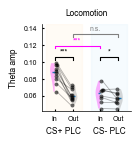


THETA AMPLITUDE LOCOMOTION: In PF vs Out PF (CS+ vs CS- PLCs)

CS+ PLCs: n=10 cells (paired)
  In PF:  0.086 ± 0.010
  Out PF: 0.061 ± 0.007

CS- PLCs: n=8 cells (paired)
  In PF:  0.062 ± 0.010
  Out PF: 0.057 ± 0.007

Statistical Tests:
  CS+ In vs Out (paired): Paired t-test, n=10, p=9.03e-06
  CS- In vs Out (paired): Wilcoxon, n=8, p=3.91e-02
  CS+ In vs CS- In (unpaired): Unpaired t-test, n_CS+=10, n_CS-=8, p=1.51e-04
  CS+ Out vs CS- Out (unpaired): Unpaired t-test, n_CS+=10, n_CS-=8, p=3.02e-01
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/theta_inout_quiet_csplus_vs_csminus.svg


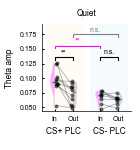


THETA AMPLITUDE QUIET: In PF vs Out PF (CS+ vs CS- PLCs)

CS+ PLCs: n=10 cells (paired)
  In PF:  0.096 ± 0.019
  Out PF: 0.073 ± 0.016

CS- PLCs: n=8 cells (paired)
  In PF:  0.067 ± 0.010
  Out PF: 0.063 ± 0.007

Statistical Tests:
  CS+ In vs Out (paired): Paired t-test, n=10, p=7.28e-03
  CS- In vs Out (paired): Paired t-test, n=8, p=1.82e-01
  CS+ In vs CS- In (unpaired): Unpaired t-test, n_CS+=10, n_CS-=8, p=2.62e-03
  CS+ Out vs CS- Out (unpaired): Unpaired t-test, n_CS+=10, n_CS-=8, p=1.52e-01


In [344]:
# Theta Amplitude In vs Out - CS+ PLC vs CS- PLC (Separate Figures)
# 4 violins per figure: CS+ In, CS+ Out, CS- In, CS- Out
# Background colors to distinguish groups
# Within-group (paired) and across-group (unpaired) statistical tests

from scipy import stats as scipy_stats

# Colors (matching other figures)
cs_plc_bg = '#FFF3E0'      # Light orange background for CS+ PLCs
non_cs_plc_bg = '#E3F2FD'  # Light blue background for CS- PLCs
in_color = 'magenta'
out_color = 'gray'

def _paired_test(data1, data2):
    """Perform paired test with normality check."""
    d1 = np.asarray(data1, dtype=float)
    d2 = np.asarray(data2, dtype=float)
    mask = np.isfinite(d1) & np.isfinite(d2)
    d1, d2 = d1[mask], d2[mask]
    n = len(d1)
    if n < 3:
        return np.nan, np.nan, 'N/A', n, np.nan
    diff = d1 - d2
    try:
        shapiro_p = scipy_stats.shapiro(diff).pvalue
    except ValueError:
        shapiro_p = np.nan
    # With very small n, prefer nonparametric tests regardless of normality.
    if n < 5:
        stat, p = scipy_stats.wilcoxon(d1, d2)
        test_name = 'Wilcoxon'
    elif np.isfinite(shapiro_p) and shapiro_p > 0.05:
        stat, p = scipy_stats.ttest_rel(d1, d2)
        test_name = 'Paired t-test'
    else:
        stat, p = scipy_stats.wilcoxon(d1, d2)
        test_name = 'Wilcoxon'
    return p, stat, test_name, n, shapiro_p

def _unpaired_test(data1, data2):
    """Perform unpaired test with normality check."""
    d1 = np.asarray(data1, dtype=float)
    d2 = np.asarray(data2, dtype=float)
    d1 = d1[np.isfinite(d1)]
    d2 = d2[np.isfinite(d2)]
    if len(d1) < 3 or len(d2) < 3:
        return np.nan, 'N/A', np.nan, np.nan
    try:
        shapiro_p1 = scipy_stats.shapiro(d1).pvalue
    except ValueError:
        shapiro_p1 = np.nan
    try:
        shapiro_p2 = scipy_stats.shapiro(d2).pvalue
    except ValueError:
        shapiro_p2 = np.nan
    # With very small n, prefer nonparametric tests regardless of normality.
    if min(len(d1), len(d2)) < 5:
        _, p = scipy_stats.mannwhitneyu(d1, d2, alternative='two-sided')
        test_name = 'Mann-Whitney U'
    elif (np.isfinite(shapiro_p1) and shapiro_p1 > 0.05) and (np.isfinite(shapiro_p2) and shapiro_p2 > 0.05):
        _, p = scipy_stats.ttest_ind(d1, d2)
        test_name = 'Unpaired t-test'
    else:
        _, p = scipy_stats.mannwhitneyu(d1, d2, alternative='two-sided')
        test_name = 'Mann-Whitney U'
    return p, test_name, shapiro_p1, shapiro_p2

def _sig_label(p):
    if np.isnan(p): return 'n.s.'
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'n.s.'

def add_bracket(ax, x1, x2, y, h, text, color='black'):
    """Add statistical bracket with text closer to line."""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.8, c=color, clip_on=False)
    # Text positioned just above the bracket line
    ax.text((x1+x2)/2, y+h+0.003, text, ha='center', va='bottom', fontsize=5, color=color)

state_specs = [('loco', 'Locomotion'), ('quiet', 'Quiet')]

for state, state_label in state_specs:
    # Get paired data for CS+ PLCs (need both In and Out for same cell)
    df_csplus_paired = df_cs_plc[[f'theta_{state}_in', f'theta_{state}_out']].dropna()
    csplus_in_paired = df_csplus_paired[f'theta_{state}_in'].values
    csplus_out_paired = df_csplus_paired[f'theta_{state}_out'].values
    
    # Get paired data for CS- PLCs
    df_csminus_paired = df_non_cs_plc[[f'theta_{state}_in', f'theta_{state}_out']].dropna()
    csminus_in_paired = df_csminus_paired[f'theta_{state}_in'].values
    csminus_out_paired = df_csminus_paired[f'theta_{state}_out'].values
    
    # Create figure
    panel_w, panel_h = 1.4, 1.5
    fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))
    
    # Add background shading for groups (with a small white gap between groups)
    ax.axvspan(0.5, 2.5, alpha=0.3, color=cs_plc_bg, zorder=0)
    ax.axvspan(3.0, 5.0, alpha=0.3, color=non_cs_plc_bg, zorder=0)
    
    # Plot half-violins with dots+lines on the inner side
    positions = [1, 2, 3.5, 4.5]
    data = [csplus_in_paired, csplus_out_paired, csminus_in_paired, csminus_out_paired]
    violin_colors = [in_color, out_color, in_color, out_color]
    # 'left' = clip right side (show left half), 'right' = clip left side (show right half)
    half_sides = ['left', 'right', 'left', 'right']
    
    rng = np.random.default_rng(0)
    for idx, (pos, d, vc, side) in enumerate(zip(positions, data, violin_colors, half_sides)):
        if len(d) == 0:
            continue
        vp = ax.violinplot([d], positions=[pos], showmedians=True, showextrema=False)
        # Clip violin body to half
        body = vp['bodies'][0]
        verts = body.get_paths()[0].vertices
        if side == 'left':
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
        else:
            verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
        body.set_facecolor(vc)
        body.set_edgecolor('none')
        body.set_alpha(0.3)
        # Clip median line to half
        if 'cmedians' in vp:
            segs = vp['cmedians'].get_segments()
            if len(segs) > 0:
                seg = segs[0].copy()
                if side == 'left':
                    seg[:, 0] = np.clip(seg[:, 0], -np.inf, pos)
                else:
                    seg[:, 0] = np.clip(seg[:, 0], pos, np.inf)
                vp['cmedians'].set_segments([seg])
            vp['cmedians'].set_color('#1F77B4')
            vp['cmedians'].set_linewidth(1.0)
        # Dots on inner side
        finite_mask = np.isfinite(d)
        if np.any(finite_mask):
            d_finite = d[finite_mask]
            # Beeswarm layout
            y_range = np.ptp(d_finite) if len(d_finite) > 1 else 1.0
            y_spacing = y_range * 0.04
            x_step = 0.06
            sorted_idx = np.argsort(d_finite)
            xs_bee = np.zeros(len(d_finite))
            for si, oi in enumerate(sorted_idx):
                layer = 0
                while True:
                    candidate = x_step * layer
                    conflict = False
                    for sj in range(si):
                        oj = sorted_idx[sj]
                        if abs(d_finite[oi] - d_finite[oj]) < y_spacing:
                            if abs(candidate - xs_bee[oj]) < x_step * 0.9:
                                conflict = True
                                break
                    if not conflict:
                        xs_bee[oi] = candidate
                        break
                    layer += 1
            if side == 'left':
                xs = pos + 0.05 + xs_bee
            else:
                xs = pos - 0.05 - xs_bee
            ax.scatter(xs, d_finite, s=8, color='black', alpha=0.6, linewidths=0, zorder=3)
    
    # Draw paired lines on inner side
    # CS+ group: pos 1 (left violin) -> dots right, pos 2 (right violin) -> dots left
    for i in range(len(csplus_in_paired)):
        if np.isfinite(csplus_in_paired[i]) and np.isfinite(csplus_out_paired[i]):
            ax.plot([1.12, 1.88], [csplus_in_paired[i], csplus_out_paired[i]],
                   color='black', alpha=0.3, linewidth=0.6, zorder=2)
    # CS- group: pos 3.5 (left violin) -> dots right, pos 4.5 (right violin) -> dots left
    for i in range(len(csminus_in_paired)):
        if np.isfinite(csminus_in_paired[i]) and np.isfinite(csminus_out_paired[i]):
            ax.plot([3.62, 4.38], [csminus_in_paired[i], csminus_out_paired[i]],
                   color='black', alpha=0.3, linewidth=0.6, zorder=2)
    
    # Calculate ylim with more space for brackets
    all_vals = np.concatenate([v for v in data if len(v) > 0])
    if len(all_vals) > 0:
        ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)
        yrange = ymax - ymin
        # More space at top for 3 levels of brackets
        ylim = (ymin - 0.05 * yrange, ymax + 0.85 * yrange)
    else:
        ylim = (0, 1)
    
    ax.set_ylim(ylim)
    ax.set_xlim(0.3, 5.2)
    
    # X-axis labels
    ax.set_xticks([1, 2, 3.5, 4.5])
    ax.set_xticklabels(['In', 'Out', 'In', 'Out'], fontsize=5, fontname='Arial')
    
    # Group labels
    ax.text(1.5, -0.18, 'CS+ PLC', ha='center', va='top', fontsize=6, 
            fontname='Arial', transform=ax.get_xaxis_transform())
    ax.text(4.0, -0.18, 'CS- PLC', ha='center', va='top', fontsize=6, 
            fontname='Arial', transform=ax.get_xaxis_transform())
    
    # Y-axis label
    ax.set_ylabel('Theta amp', fontsize=6, fontname='Arial')
    ax.tick_params(axis='y', labelsize=5)
    
    # Title
    ax.set_title(state_label, fontsize=6, fontname='Arial')
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Statistical tests - optimized positioning
    # Calculate bracket parameters based on data range
    data_ymax = ymax
    bracket_h = 0.05 * yrange    # Height of bracket arms
    level_gap = 0.25 * yrange    # Gap between bracket levels (bracket + text + spacing)
    
    # Level 1: Within-group paired tests (just above data)
    y1 = data_ymax + 0.08 * yrange
    
    stats_results = []
    
    # CS+ In vs Out (positions 1-2)
    if len(csplus_in_paired) >= 3:
        p_csplus, stat, test, n, shapiro_p = _paired_test(csplus_in_paired, csplus_out_paired)
        add_bracket(ax, 1, 2, y1, bracket_h, _sig_label(p_csplus))
        stats_results.append({
            'comparison': 'CS+ In vs Out (paired)',
            'n': n, 'test': test, 'p': p_csplus
        })
    
    # CS- In vs Out (positions 3.5-4.5) - same level
    if len(csminus_in_paired) >= 3:
        p_csminus, stat, test, n, shapiro_p = _paired_test(csminus_in_paired, csminus_out_paired)
        add_bracket(ax, 3.5, 4.5, y1, bracket_h, _sig_label(p_csminus))
        stats_results.append({
            'comparison': 'CS- In vs Out (paired)',
            'n': n, 'test': test, 'p': p_csminus
        })
    
    # Level 2: Across-group In comparison (CS+ In vs CS- In)
    y2 = y1 + level_gap
    if len(csplus_in_paired) >= 3 and len(csminus_in_paired) >= 3:
        p_in, test, _, _ = _unpaired_test(csplus_in_paired, csminus_in_paired)
        add_bracket(ax, 1, 3.5, y2, bracket_h, _sig_label(p_in), color=in_color)
        stats_results.append({
            'comparison': 'CS+ In vs CS- In (unpaired)',
            'n_csplus': len(csplus_in_paired), 'n_csminus': len(csminus_in_paired),
            'test': test, 'p': p_in
        })
    
    # Level 3: Across-group Out comparison (CS+ Out vs CS- Out)
    y3 = y2 + level_gap
    if len(csplus_out_paired) >= 3 and len(csminus_out_paired) >= 3:
        p_out, test, _, _ = _unpaired_test(csplus_out_paired, csminus_out_paired)
        add_bracket(ax, 2, 4.5, y3, bracket_h, _sig_label(p_out), color=out_color)
        stats_results.append({
            'comparison': 'CS+ Out vs CS- Out (unpaired)',
            'n_csplus': len(csplus_out_paired), 'n_csminus': len(csminus_out_paired),
            'test': test, 'p': p_out
        })
    
    plt.tight_layout()
    save_path = os.path.join(figure_save_folder, f'theta_inout_{state}_csplus_vs_csminus.svg')
    plt.savefig(save_path, dpi=300)
    print(f'Saved: {save_path}')
    plt.show()
    
    # Print stats summary
    print(f"\n{'='*70}")
    print(f"THETA AMPLITUDE {state_label.upper()}: In PF vs Out PF (CS+ vs CS- PLCs)")
    print("="*70)
    print(f"\nCS+ PLCs: n={len(csplus_in_paired)} cells (paired)")
    print(f"  In PF:  {np.nanmean(csplus_in_paired):.3f} ± {np.nanstd(csplus_in_paired):.3f}")
    print(f"  Out PF: {np.nanmean(csplus_out_paired):.3f} ± {np.nanstd(csplus_out_paired):.3f}")
    print(f"\nCS- PLCs: n={len(csminus_in_paired)} cells (paired)")
    print(f"  In PF:  {np.nanmean(csminus_in_paired):.3f} ± {np.nanstd(csminus_in_paired):.3f}")
    print(f"  Out PF: {np.nanmean(csminus_out_paired):.3f} ± {np.nanstd(csminus_out_paired):.3f}")
    print("\nStatistical Tests:")
    for res in stats_results:
        if 'n' in res:
            print(f"  {res['comparison']}: {res['test']}, n={res['n']}, p={res['p']:.2e}")
        else:
            print(f"  {res['comparison']}: {res['test']}, n_CS+={res['n_csplus']}, n_CS-={res['n_csminus']}, p={res['p']:.2e}")


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/theta_selectivity_loco_csplus_vs_csminus.svg


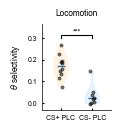


THETA SELECTIVITY LOCOMOTION: CS+ vs CS- PLCs

CS+ PLCs: n=10
  mean=0.170 ± 0.053
CS- PLCs: n=8
  mean=0.035 ± 0.046

CS+ vs CS-: Mann-Whitney U, p = 3.20e-04 ***
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/theta_selectivity_quiet_csplus_vs_csminus.svg


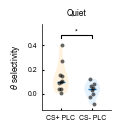


THETA SELECTIVITY QUIET: CS+ vs CS- PLCs

CS+ PLCs: n=10
  mean=0.135 ± 0.115
CS- PLCs: n=8
  mean=0.030 ± 0.060

CS+ vs CS-: Unpaired t-test, p = 4.15e-02 *


In [345]:
# Theta selectivity - CS+ PLC vs CS- PLC (Separate Figures)
# Theta selectivity = (In - Out) / (In + Out)
# Use same style/colors as the theta in/out panel above (no background shading here).

VIOLIN_MEDIAN_COLOR = '#1F77B4'
state_specs = [('loco', 'Locomotion'), ('quiet', 'Quiet')]

for state, state_label in state_specs:
    # CS+ PLCs
    df_csplus_paired = df_cs_plc[[f'theta_{state}_in', f'theta_{state}_out']].dropna()
    csplus_in = df_csplus_paired[f'theta_{state}_in'].values
    csplus_out = df_csplus_paired[f'theta_{state}_out'].values
    with np.errstate(divide='ignore', invalid='ignore'):
        csplus_sel = (csplus_in - csplus_out) / (csplus_in + csplus_out)
    csplus_sel = csplus_sel[np.isfinite(csplus_sel)]

    # CS- PLCs
    df_csminus_paired = df_non_cs_plc[[f'theta_{state}_in', f'theta_{state}_out']].dropna()
    csminus_in = df_csminus_paired[f'theta_{state}_in'].values
    csminus_out = df_csminus_paired[f'theta_{state}_out'].values
    with np.errstate(divide='ignore', invalid='ignore'):
        csminus_sel = (csminus_in - csminus_out) / (csminus_in + csminus_out)
    csminus_sel = csminus_sel[np.isfinite(csminus_sel)]

    # Plot
    panel_w, panel_h = 1.2, 1.3
    fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))
    positions = [1, 2]
    data = [csplus_sel, csminus_sel]

    parts = ax.violinplot(data, positions=positions, showmedians=True, showextrema=False)
    for body, c in zip(parts['bodies'], [cs_plc_bg, non_cs_plc_bg]):
        body.set_facecolor(c)
        body.set_edgecolor('none')
        body.set_alpha(1)

    if 'cmedians' in parts:
        parts['cmedians'].set_color(VIOLIN_MEDIAN_COLOR)
        parts['cmedians'].set_linewidth(1.0)

    rng = np.random.default_rng(0)
    for pos, d in zip(positions, data):
        if len(d) == 0:
            continue
        jitter = (rng.random(len(d)) - 0.5) * 0.12
        ax.scatter(pos + jitter, d, s=8, color='black', alpha=0.6, linewidths=0, zorder=3)

    all_vals = np.concatenate([v for v in data if len(v) > 0]) if (len(csplus_sel) + len(csminus_sel)) else np.array([])
    if len(all_vals) > 0:
        ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)
        yrange = ymax - ymin
        if not np.isfinite(yrange) or yrange == 0:
            yrange = 1.0
        ax.set_ylim(ymin - 0.1 * yrange, ymax + 0.35 * yrange)
    
    ax.set_xlim(0.4, 2.6)
    ax.set_xticks(positions)
    ax.set_xticklabels(['CS+ PLC', 'CS- PLC'], fontsize=5, fontname='Arial')
    ax.set_ylabel(r'$\theta$ selectivity', fontsize=6, fontname='Arial')
    ax.set_title(state_label, fontsize=6, fontname='Arial')
    ax.tick_params(axis='y', labelsize=5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Between-group test: CS+ vs CS- (unpaired)
    if len(csplus_sel) >= 3 and len(csminus_sel) >= 3:
        p, test, _, _ = _unpaired_test(csplus_sel, csminus_sel)
        y = np.nanmax(all_vals) + 0.12 * yrange
        h = 0.05 * yrange
        add_bracket(ax, 1, 2, y, h, _sig_label(p), color='black')

    plt.tight_layout()
    save_path = os.path.join(figure_save_folder, f'theta_selectivity_{state}_csplus_vs_csminus.svg')
    plt.savefig(save_path, dpi=300)
    print(f'Saved: {save_path}')
    plt.show()

    # Print summary
    print(f"\n{'='*70}")
    print(f"THETA SELECTIVITY {state_label.upper()}: CS+ vs CS- PLCs")
    print("="*70)
    print(f"\nCS+ PLCs: n={len(csplus_sel)}")
    if len(csplus_sel) > 0:
        print(f"  mean={np.nanmean(csplus_sel):.3f} ± {np.nanstd(csplus_sel):.3f}")
    print(f"CS- PLCs: n={len(csminus_sel)}")
    if len(csminus_sel) > 0:
        print(f"  mean={np.nanmean(csminus_sel):.3f} ± {np.nanstd(csminus_sel):.3f}")
    if len(csplus_sel) >= 3 and len(csminus_sel) >= 3:
        print(f"\nCS+ vs CS-: {test}, p = {p:.2e} {_sig_label(p)}")



# 7. Slow Vm In vs Out (Place Cells)

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/slow_vm_inout_loco_csplus_vs_csminus.svg


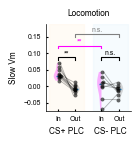


SLOW VM LOCOMOTION: In PF vs Out PF (CS+ vs CS- PLCs)

CS+ PLCs: n=10 cells (paired)
  In PF:  0.038 ± 0.015
  Out PF: -0.007 ± 0.011

CS- PLCs: n=8 cells (paired)
  In PF:  -0.002 ± 0.034
  Out PF: -0.011 ± 0.015

Statistical Tests:
  CS+ In vs Out (paired): Wilcoxon, n=10, p=1.95e-03
  CS- In vs Out (paired): Paired t-test, n=8, p=4.12e-01
  CS+ In vs CS- In (unpaired): Unpaired t-test, n_CS+=10, n_CS-=8, p=6.30e-03
  CS+ Out vs CS- Out (unpaired): Unpaired t-test, n_CS+=10, n_CS-=8, p=5.36e-01
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/slow_vm_inout_quiet_csplus_vs_csminus.svg


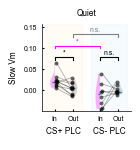


SLOW VM QUIET: In PF vs Out PF (CS+ vs CS- PLCs)

CS+ PLCs: n=10 cells (paired)
  In PF:  0.023 ± 0.016
  Out PF: 0.005 ± 0.013

CS- PLCs: n=8 cells (paired)
  In PF:  -0.010 ± 0.027
  Out PF: 0.001 ± 0.010

Statistical Tests:
  CS+ In vs Out (paired): Paired t-test, n=10, p=1.22e-02
  CS- In vs Out (paired): Paired t-test, n=8, p=3.68e-01
  CS+ In vs CS- In (unpaired): Mann-Whitney U, n_CS+=10, n_CS-=8, p=1.17e-02
  CS+ Out vs CS- Out (unpaired): Unpaired t-test, n_CS+=10, n_CS-=8, p=5.04e-01


In [346]:
# Slow Vm In vs Out - CS+ PLC vs CS- PLC (Separate Figures)
# 4 violins per figure: CS+ In, CS+ Out, CS- In, CS- Out
# Background colors to distinguish groups
# Within-group (paired) and across-group (unpaired) statistical tests

from scipy import stats as scipy_stats

# Colors (matching theta in/out panel above)
cs_plc_bg = '#FFF3E0'      # Light orange background for CS+ PLCs
non_cs_plc_bg = '#E3F2FD'  # Light blue background for CS- PLCs
in_color = 'magenta'
out_color = 'gray'
VIOLIN_MEDIAN_COLOR = '#1F77B4'

def _paired_test(data1, data2):
    """Perform paired test with normality check."""
    d1 = np.asarray(data1, dtype=float)
    d2 = np.asarray(data2, dtype=float)
    mask = np.isfinite(d1) & np.isfinite(d2)
    d1, d2 = d1[mask], d2[mask]
    n = len(d1)
    if n < 3:
        return np.nan, np.nan, 'N/A', n, np.nan
    diff = d1 - d2
    try:
        shapiro_p = scipy_stats.shapiro(diff).pvalue
    except ValueError:
        shapiro_p = np.nan
    if n < 5:
        stat, p = scipy_stats.wilcoxon(d1, d2)
        test_name = 'Wilcoxon'
    elif np.isfinite(shapiro_p) and shapiro_p > 0.05:
        stat, p = scipy_stats.ttest_rel(d1, d2)
        test_name = 'Paired t-test'
    else:
        stat, p = scipy_stats.wilcoxon(d1, d2)
        test_name = 'Wilcoxon'
    return p, stat, test_name, n, shapiro_p

def _unpaired_test(data1, data2):
    """Perform unpaired test with normality check."""
    d1 = np.asarray(data1, dtype=float)
    d2 = np.asarray(data2, dtype=float)
    d1 = d1[np.isfinite(d1)]
    d2 = d2[np.isfinite(d2)]
    if len(d1) < 3 or len(d2) < 3:
        return np.nan, 'N/A', np.nan, np.nan
    try:
        shapiro_p1 = scipy_stats.shapiro(d1).pvalue
    except ValueError:
        shapiro_p1 = np.nan
    try:
        shapiro_p2 = scipy_stats.shapiro(d2).pvalue
    except ValueError:
        shapiro_p2 = np.nan
    if min(len(d1), len(d2)) < 5:
        _, p = scipy_stats.mannwhitneyu(d1, d2, alternative='two-sided')
        test_name = 'Mann-Whitney U'
    elif (np.isfinite(shapiro_p1) and shapiro_p1 > 0.05) and (np.isfinite(shapiro_p2) and shapiro_p2 > 0.05):
        _, p = scipy_stats.ttest_ind(d1, d2)
        test_name = 'Unpaired t-test'
    else:
        _, p = scipy_stats.mannwhitneyu(d1, d2, alternative='two-sided')
        test_name = 'Mann-Whitney U'
    return p, test_name, shapiro_p1, shapiro_p2

def _sig_label(p):
    if np.isnan(p): return 'n.s.'
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'n.s.'

def add_bracket(ax, x1, x2, y, h, text, color='black'):
    """Add statistical bracket with text closer to line."""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.8, c=color, clip_on=False)
    ax.text((x1+x2)/2, y+h+0.003, text, ha='center', va='bottom', fontsize=5, color=color)

state_specs = [('loco', 'Locomotion'), ('quiet', 'Quiet')]

for state, state_label in state_specs:
    df_csplus_paired = df_cs_plc[[f'slow_{state}_in', f'slow_{state}_out']].dropna()
    csplus_in_paired = df_csplus_paired[f'slow_{state}_in'].values
    csplus_out_paired = df_csplus_paired[f'slow_{state}_out'].values

    df_csminus_paired = df_non_cs_plc[[f'slow_{state}_in', f'slow_{state}_out']].dropna()
    csminus_in_paired = df_csminus_paired[f'slow_{state}_in'].values
    csminus_out_paired = df_csminus_paired[f'slow_{state}_out'].values

    panel_w, panel_h = 1.4, 1.5
    fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))

    ax.axvspan(0.5, 2.5, alpha=0.3, color=cs_plc_bg, zorder=0)
    ax.axvspan(3.0, 5.0, alpha=0.3, color=non_cs_plc_bg, zorder=0)

    # Plot half-violins with dots+lines on the inner side
    positions = [1, 2, 3.5, 4.5]
    data = [csplus_in_paired, csplus_out_paired, csminus_in_paired, csminus_out_paired]
    violin_colors = [in_color, out_color, in_color, out_color]
    half_sides = ['left', 'right', 'left', 'right']

    rng = np.random.default_rng(0)
    for idx, (pos, d, vc, side) in enumerate(zip(positions, data, violin_colors, half_sides)):
        if len(d) == 0:
            continue
        vp = ax.violinplot([d], positions=[pos], showmedians=True, showextrema=False)
        body = vp['bodies'][0]
        verts = body.get_paths()[0].vertices
        if side == 'left':
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
        else:
            verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
        body.set_facecolor(vc)
        body.set_edgecolor('none')
        body.set_alpha(0.3)
        if 'cmedians' in vp:
            segs = vp['cmedians'].get_segments()
            if len(segs) > 0:
                seg = segs[0].copy()
                if side == 'left':
                    seg[:, 0] = np.clip(seg[:, 0], -np.inf, pos)
                else:
                    seg[:, 0] = np.clip(seg[:, 0], pos, np.inf)
                vp['cmedians'].set_segments([seg])
            vp['cmedians'].set_color(VIOLIN_MEDIAN_COLOR)
            vp['cmedians'].set_linewidth(1.0)
        finite_mask = np.isfinite(d)
        if np.any(finite_mask):
            d_finite = d[finite_mask]
            # Beeswarm layout
            y_range = np.ptp(d_finite) if len(d_finite) > 1 else 1.0
            y_spacing = y_range * 0.04
            x_step = 0.06
            sorted_idx = np.argsort(d_finite)
            xs_bee = np.zeros(len(d_finite))
            for si, oi in enumerate(sorted_idx):
                layer = 0
                while True:
                    candidate = x_step * layer
                    conflict = False
                    for sj in range(si):
                        oj = sorted_idx[sj]
                        if abs(d_finite[oi] - d_finite[oj]) < y_spacing:
                            if abs(candidate - xs_bee[oj]) < x_step * 0.9:
                                conflict = True
                                break
                    if not conflict:
                        xs_bee[oi] = candidate
                        break
                    layer += 1
            if side == 'left':
                xs = pos + 0.05 + xs_bee
            else:
                xs = pos - 0.05 - xs_bee
            ax.scatter(xs, d_finite, s=8, color='black', alpha=0.6, linewidths=0, zorder=3)

    for i in range(len(csplus_in_paired)):
        if np.isfinite(csplus_in_paired[i]) and np.isfinite(csplus_out_paired[i]):
            ax.plot([1.12, 1.88], [csplus_in_paired[i], csplus_out_paired[i]],
                   color='black', alpha=0.3, linewidth=0.6, zorder=2)
    for i in range(len(csminus_in_paired)):
        if np.isfinite(csminus_in_paired[i]) and np.isfinite(csminus_out_paired[i]):
            ax.plot([3.62, 4.38], [csminus_in_paired[i], csminus_out_paired[i]],
                   color='black', alpha=0.3, linewidth=0.6, zorder=2)

    all_vals = np.concatenate([v for v in data if len(v) > 0])
    if len(all_vals) > 0:
        ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)
        yrange = ymax - ymin
        ylim = (ymin - 0.05 * yrange, ymax + 0.85 * yrange)
    else:
        ymin, ymax, yrange = 0, 1, 1
        ylim = (0, 1)

    ax.set_ylim(ylim)
    ax.set_xlim(0.3, 5.2)

    ax.set_xticks([1, 2, 3.5, 4.5])
    ax.set_xticklabels(['In', 'Out', 'In', 'Out'], fontsize=5, fontname='Arial')
    ax.text(1.5, -0.18, 'CS+ PLC', ha='center', va='top', fontsize=6,
            fontname='Arial', transform=ax.get_xaxis_transform())
    ax.text(4.0, -0.18, 'CS- PLC', ha='center', va='top', fontsize=6,
            fontname='Arial', transform=ax.get_xaxis_transform())

    ax.set_ylabel('Slow Vm', fontsize=6, fontname='Arial')
    ax.tick_params(axis='y', labelsize=5)
    ax.set_title(state_label, fontsize=6, fontname='Arial')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    data_ymax = ymax
    bracket_h = 0.05 * yrange
    level_gap = 0.25 * yrange
    y1 = data_ymax + 0.08 * yrange

    stats_results = []
    if len(csplus_in_paired) >= 3:
        p_csplus, stat, test, n, shapiro_p = _paired_test(csplus_in_paired, csplus_out_paired)
        add_bracket(ax, 1, 2, y1, bracket_h, _sig_label(p_csplus))
        stats_results.append({'comparison': 'CS+ In vs Out (paired)', 'n': n, 'test': test, 'p': p_csplus})
    if len(csminus_in_paired) >= 3:
        p_csminus, stat, test, n, shapiro_p = _paired_test(csminus_in_paired, csminus_out_paired)
        add_bracket(ax, 3.5, 4.5, y1, bracket_h, _sig_label(p_csminus))
        stats_results.append({'comparison': 'CS- In vs Out (paired)', 'n': n, 'test': test, 'p': p_csminus})

    y2 = y1 + level_gap
    if len(csplus_in_paired) >= 3 and len(csminus_in_paired) >= 3:
        p_in, test, _, _ = _unpaired_test(csplus_in_paired, csminus_in_paired)
        add_bracket(ax, 1, 3.5, y2, bracket_h, _sig_label(p_in), color=in_color)
        stats_results.append({'comparison': 'CS+ In vs CS- In (unpaired)', 'n_csplus': len(csplus_in_paired), 'n_csminus': len(csminus_in_paired), 'test': test, 'p': p_in})

    y3 = y2 + level_gap
    if len(csplus_out_paired) >= 3 and len(csminus_out_paired) >= 3:
        p_out, test, _, _ = _unpaired_test(csplus_out_paired, csminus_out_paired)
        add_bracket(ax, 2, 4.5, y3, bracket_h, _sig_label(p_out), color=out_color)
        stats_results.append({'comparison': 'CS+ Out vs CS- Out (unpaired)', 'n_csplus': len(csplus_out_paired), 'n_csminus': len(csminus_out_paired), 'test': test, 'p': p_out})

    plt.tight_layout()
    save_path = os.path.join(figure_save_folder, f'slow_vm_inout_{state}_csplus_vs_csminus.svg')
    plt.savefig(save_path, dpi=300)
    print(f'Saved: {save_path}')
    plt.show()

    print(f"\n{'='*70}")
    print(f"SLOW VM {state_label.upper()}: In PF vs Out PF (CS+ vs CS- PLCs)")
    print("="*70)
    print(f"\nCS+ PLCs: n={len(csplus_in_paired)} cells (paired)")
    print(f"  In PF:  {np.nanmean(csplus_in_paired):.3f} ± {np.nanstd(csplus_in_paired):.3f}")
    print(f"  Out PF: {np.nanmean(csplus_out_paired):.3f} ± {np.nanstd(csplus_out_paired):.3f}")
    print(f"\nCS- PLCs: n={len(csminus_in_paired)} cells (paired)")
    print(f"  In PF:  {np.nanmean(csminus_in_paired):.3f} ± {np.nanstd(csminus_in_paired):.3f}")
    print(f"  Out PF: {np.nanmean(csminus_out_paired):.3f} ± {np.nanstd(csminus_out_paired):.3f}")
    print("\nStatistical Tests:")
    for res in stats_results:
        if 'n' in res:
            print(f"  {res['comparison']}: {res['test']}, n={res['n']}, p={res['p']:.2e}")
        else:
            print(f"  {res['comparison']}: {res['test']}, n_CS+={res['n_csplus']}, n_CS-={res['n_csminus']}, p={res['p']:.2e}")


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/slow_vm_selectivity_loco_csplus_vs_csminus.svg


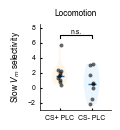


SLOW VM SELECTIVITY LOCOMOTION: CS+ vs CS- PLCs

CS+ PLCs: n=10
  mean=1.898 ± 1.392
CS- PLCs: n=8
  mean=0.655 ± 1.828

CS+ vs CS-: Mann-Whitney U, p = 2.03e-01 n.s.
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/slow_vm_selectivity_quiet_csplus_vs_csminus.svg


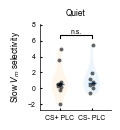


SLOW VM SELECTIVITY QUIET: CS+ vs CS- PLCs

CS+ PLCs: n=10
  mean=0.917 ± 1.852
CS- PLCs: n=8
  mean=1.200 ± 1.762

CS+ vs CS-: Mann-Whitney U, p = 5.73e-01 n.s.


In [347]:
# Slow Vm selectivity - CS+ PLC vs CS- PLC (Separate Figures)
# Slow Vm selectivity = (In - Out) / (In + Out)
# Same style/colors as theta selectivity (no background shading).

VIOLIN_MEDIAN_COLOR = '#1F77B4'
state_specs = [('loco', 'Locomotion'), ('quiet', 'Quiet')]

for state, state_label in state_specs:
    # CS+ PLCs
    df_csplus_paired = df_cs_plc[[f'slow_{state}_in', f'slow_{state}_out']].dropna()
    csplus_in = df_csplus_paired[f'slow_{state}_in'].values
    csplus_out = df_csplus_paired[f'slow_{state}_out'].values
    with np.errstate(divide='ignore', invalid='ignore'):
        csplus_sel = (csplus_in - csplus_out) / (csplus_in + csplus_out)
    csplus_sel = csplus_sel[np.isfinite(csplus_sel)]

    # CS- PLCs
    df_csminus_paired = df_non_cs_plc[[f'slow_{state}_in', f'slow_{state}_out']].dropna()
    csminus_in = df_csminus_paired[f'slow_{state}_in'].values
    csminus_out = df_csminus_paired[f'slow_{state}_out'].values
    with np.errstate(divide='ignore', invalid='ignore'):
        csminus_sel = (csminus_in - csminus_out) / (csminus_in + csminus_out)
    csminus_sel = csminus_sel[np.isfinite(csminus_sel)]

    # Plot
    panel_w, panel_h = 1.2, 1.3
    fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))
    positions = [1, 2]
    data = [csplus_sel, csminus_sel]

    parts = ax.violinplot(data, positions=positions, showmedians=True, showextrema=False)
    for body, c in zip(parts['bodies'], [cs_plc_bg, non_cs_plc_bg]):
        body.set_facecolor(c)
        body.set_edgecolor('none')
        body.set_alpha(0.7)

    if 'cmedians' in parts:
        parts['cmedians'].set_color(VIOLIN_MEDIAN_COLOR)
        parts['cmedians'].set_linewidth(1.0)

    rng = np.random.default_rng(0)
    for pos, d in zip(positions, data):
        if len(d) == 0:
            continue
        jitter = (rng.random(len(d)) - 0.5) * 0.12
        ax.scatter(pos + jitter, d, s=8, color='black', alpha=0.6, linewidths=0, zorder=3)

    all_vals = np.concatenate([v for v in data if len(v) > 0]) if (len(csplus_sel) + len(csminus_sel)) else np.array([])
    if len(all_vals) > 0:
        ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)
        yrange = ymax - ymin
        if not np.isfinite(yrange) or yrange == 0:
            yrange = 1.0
        ax.set_ylim(ymin - 0.1 * yrange, ymax + 0.35 * yrange)

    ax.set_xlim(0.4, 2.6)
    ax.set_xticks(positions)
    ax.set_xticklabels(['CS+ PLC', 'CS- PLC'], fontsize=5, fontname='Arial')
    ax.set_ylabel(r'Slow $V_m$ selectivity', fontsize=6, fontname='Arial')
    ax.set_title(state_label, fontsize=6, fontname='Arial')
    ax.tick_params(axis='y', labelsize=5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Between-group test: CS+ vs CS- (unpaired)
    if len(csplus_sel) >= 3 and len(csminus_sel) >= 3:
        p, test, _, _ = _unpaired_test(csplus_sel, csminus_sel)
        y = np.nanmax(all_vals) + 0.12 * yrange
        h = 0.05 * yrange
        add_bracket(ax, 1, 2, y, h, _sig_label(p), color='black')

    plt.tight_layout()
    save_path = os.path.join(figure_save_folder, f'slow_vm_selectivity_{state}_csplus_vs_csminus.svg')
    plt.savefig(save_path, dpi=300)
    print(f'Saved: {save_path}')
    plt.show()

    # Print summary
    print(f"\n{'='*70}")
    print(f"SLOW VM SELECTIVITY {state_label.upper()}: CS+ vs CS- PLCs")
    print("="*70)
    print(f"\nCS+ PLCs: n={len(csplus_sel)}")
    if len(csplus_sel) > 0:
        print(f"  mean={np.nanmean(csplus_sel):.3f} ± {np.nanstd(csplus_sel):.3f}")
    print(f"CS- PLCs: n={len(csminus_sel)}")
    if len(csminus_sel) > 0:
        print(f"  mean={np.nanmean(csminus_sel):.3f} ± {np.nanstd(csminus_sel):.3f}")
    if len(csplus_sel) >= 3 and len(csminus_sel) >= 3:
        print(f"\nCS+ vs CS-: {test}, p = {p:.2e} {_sig_label(p)}")


# 8. Theta/Slow Vm Correlations with Rate Maps (Place Cells)

Theta correlations: n = 15 cells with valid All/SS/CS
Slow Vm correlations: n = 15 cells with valid All/SS/CS
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/theta_slow_corr_violin.svg


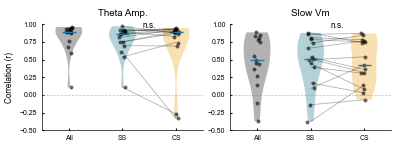


THETA/SLOW VM CORRELATIONS WITH RATE MAPS (Place Cells)

Theta Amp:
r = 0.818 ± 0.217 (n=15)
r = 0.767 ± 0.213 (n=15)
r = 0.717 ± 0.406 (n=15)

Slow Vm:
r = 0.474 ± 0.362 (n=15)
r = 0.457 ± 0.363 (n=15)
r = 0.458 ± 0.312 (n=15)

STATISTICAL COMPARISONS

Theta Amp:
  All vs SS: Wilcoxon, p = 4.51e-03 ** (n=18, shapiro_p=0.00777)
  All vs CS: Wilcoxon, p = 2.29e-01 n.s. (n=15, shapiro_p=8.55e-06)
  SS vs CS: Wilcoxon, p = 5.99e-01 n.s. (n=15, shapiro_p=0.000176)

  One-sample tests (vs 0):
    All: Wilcoxon signed-rank, stat = 1.00, p = 1.53e-05 *** (n=18, shapiro_p=0.000115)
    SS: Wilcoxon signed-rank, stat = 1.00, p = 1.53e-05 *** (n=18, shapiro_p=0.000898)
    CS: Wilcoxon signed-rank, stat = 3.00, p = 3.05e-04 *** (n=15, shapiro_p=9.81e-06)

Slow Vm:
  All vs SS: Wilcoxon, p = 3.94e-01 n.s. (n=18, shapiro_p=0.046)
  All vs CS: Wilcoxon, p = 3.30e-01 n.s. (n=15, shapiro_p=0.0165)
  SS vs CS: Paired t-test, p = 9.87e-01 n.s. (n=15, shapiro_p=0.453)

  One-sample tests (vs 0):
    Al

In [348]:
# Theta and Slow Vm Correlations with Firing Rate Maps - Violin plots
# Shows correlations for All, SS, CS rate maps

panel_w, panel_h = 2., 1.5
fig, axes = plt.subplots(1, 2, figsize=(panel_w * 2, panel_h))

all_color = 'black'
ss_color = '#026C80'
cs_color = '#EE9B00'

# Check if correlation columns exist in the dataframe
corr_cols = ['theta_corr_all', 'theta_corr_ss', 'theta_corr_cs', 
             'slow_corr_all', 'slow_corr_ss', 'slow_corr_cs']
missing_cols = [c for c in corr_cols if c not in df_pc.columns]
if missing_cols:
    print(f"Missing columns: {missing_cols}")
    print("Please re-run the statistics collection with updated analyze_place_cell_single_moving function.")
else:
    # Filter for cells with valid values for ALL three correlations (paired analysis)
    # Theta correlations - use only cells with valid All, SS, and CS
    theta_valid_mask = (np.isfinite(df_pc['theta_corr_all'].values)
                        &np.isfinite(df_pc['theta_corr_ss'].values)
                        & np.isfinite(df_pc['theta_corr_cs'].values))
    theta_all = df_pc.loc[theta_valid_mask, 'theta_corr_all'].values
    theta_ss = df_pc.loc[theta_valid_mask, 'theta_corr_ss'].values
    theta_cs = df_pc.loc[theta_valid_mask, 'theta_corr_cs'].values
    
    # Slow Vm correlations - use only cells with valid All, SS, and CS
    slow_valid_mask = (np.isfinite(df_pc['slow_corr_all'].values)
                       &np.isfinite(df_pc['slow_corr_ss'].values)
                       &np.isfinite(df_pc['slow_corr_cs'].values))
    slow_all = df_pc.loc[slow_valid_mask, 'slow_corr_all'].values
    slow_ss = df_pc.loc[slow_valid_mask, 'slow_corr_ss'].values
    slow_cs = df_pc.loc[slow_valid_mask, 'slow_corr_cs'].values
    
    print(f"Theta correlations: n = {len(theta_all)} cells with valid All/SS/CS")
    print(f"Slow Vm correlations: n = {len(slow_all)} cells with valid All/SS/CS")
    
    ax_theta = axes[0]
    ax_slow = axes[1]
    
    # Get global y-limits
    ylim = [-0.5,1]
    
    # Plot theta correlations - match style of paired plots above
    positions = [1, 2, 3]
    data_theta = [theta_all, theta_ss, theta_cs]
    colors = [all_color, ss_color, cs_color]
    labels = ['All', 'SS', 'CS']
    
    # Violin for All spikes (position 1)
    parts_all = ax_theta.violinplot([theta_all], positions=[1], showmedians=True, showextrema=False)
    _style_violin_medians(parts_all)  # Fixed median color
    for body in parts_all['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(all_color)
        body.set_edgecolor('none')
    
    # Violin for SS and CS (positions 2, 3)
    parts_ss_cs = ax_theta.violinplot([theta_ss, theta_cs], positions=[2, 3], showmedians=True, showextrema=False)
    _style_violin_medians(parts_ss_cs)  # Fixed median color
    for body in parts_ss_cs['bodies']:
        body.set_alpha(0.3)
    if len(parts_ss_cs['bodies']) >= 2:
        parts_ss_cs['bodies'][0].set_facecolor(ss_color)
        parts_ss_cs['bodies'][1].set_facecolor(cs_color)
        parts_ss_cs['bodies'][0].set_edgecolor('none')
        parts_ss_cs['bodies'][1].set_edgecolor('none')
    
    # Paired lines (SS to CS)
    for i in range(len(theta_ss)):
        ax_theta.plot([2, 3], [theta_ss[i], theta_cs[i]], color='black', alpha=0.3, linewidth=0.6)
    
    # Scatter points (black, same style as above)
    rng = np.random.default_rng(42)
    jitter_all = (rng.random(len(theta_all)) - 0.5) * 0.12
    ax_theta.scatter(1 + jitter_all, theta_all, s=8, color='black', alpha=0.6, linewidths=0)
    for pos, vals in [(2, theta_ss), (3, theta_cs)]:
        jitter = (rng.random(len(vals)) - 0.5) * 0.12
        ax_theta.scatter(pos + jitter, vals, s=8, color='black', alpha=0.6, linewidths=0)
    
    # Stats (SS vs CS)
    p_val_theta, test_stat, test_name, n_valid, shapiro_p = _paired_test(theta_ss, theta_cs)
    sig_theta = _sig_label(p_val_theta)
    if ylim:
        ax_theta.text(2.5, ylim[1] - 0.05 * (ylim[1] - ylim[0]), sig_theta, ha='center', va='bottom', fontsize=6)
        ax_theta.set_ylim(*ylim)
    
    ax_theta.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax_theta.set_title('Theta Amp.', fontsize=7, fontname='Arial')
    ax_theta.set_ylabel('Correlation (r)', fontsize=6, fontname='Arial')
    ax_theta.set_xticks(positions)
    ax_theta.set_xticklabels(labels, fontsize=5, fontname='Arial')
    ax_theta.set_xlim(0.5, 3.5)
    ax_theta.spines['top'].set_visible(False)
    ax_theta.spines['right'].set_visible(False)
    ax_theta.tick_params(axis='both', labelsize=5)
    
    # Plot slow Vm correlations - same style
    data_slow = [slow_all, slow_ss, slow_cs]
    
    # Violin for All spikes (position 1)
    parts_all = ax_slow.violinplot([slow_all], positions=[1], showmedians=True, showextrema=False)
    _style_violin_medians(parts_all)  # Fixed median color
    for body in parts_all['bodies']:
        body.set_alpha(0.3)
        body.set_facecolor(all_color)
        body.set_edgecolor('none')
    
    # Violin for SS and CS (positions 2, 3)
    parts_ss_cs = ax_slow.violinplot([slow_ss, slow_cs], positions=[2, 3], showmedians=True, showextrema=False)
    _style_violin_medians(parts_ss_cs)  # Fixed median color
    for body in parts_ss_cs['bodies']:
        body.set_alpha(0.3)
    if len(parts_ss_cs['bodies']) >= 2:
        parts_ss_cs['bodies'][0].set_facecolor(ss_color)
        parts_ss_cs['bodies'][1].set_facecolor(cs_color)
        parts_ss_cs['bodies'][0].set_edgecolor('none')
        parts_ss_cs['bodies'][1].set_edgecolor('none')
    
    # Paired lines (SS to CS)
    for i in range(len(slow_ss)):
        ax_slow.plot([2, 3], [slow_ss[i], slow_cs[i]], color='black', alpha=0.3, linewidth=0.6)
    
    # Scatter points (black, same style as above)
    rng = np.random.default_rng(43)
    jitter_all = (rng.random(len(slow_all)) - 0.5) * 0.12
    ax_slow.scatter(1 + jitter_all, slow_all, s=8, color='black', alpha=0.6, linewidths=0)
    for pos, vals in [(2, slow_ss), (3, slow_cs)]:
        jitter = (rng.random(len(vals)) - 0.5) * 0.12
        ax_slow.scatter(pos + jitter, vals, s=8, color='black', alpha=0.6, linewidths=0)
    
    # Stats (SS vs CS)
    p_val_slow, test_stat, test_name, n_valid, shapiro_p = _paired_test(slow_ss, slow_cs)
    sig_slow = _sig_label(p_val_slow)
    if ylim:
        ax_slow.text(2.5, ylim[1] - 0.05 * (ylim[1] - ylim[0]), sig_slow, ha='center', va='bottom', fontsize=6)
        ax_slow.set_ylim(*ylim)
    
    ax_slow.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax_slow.set_title('Slow Vm', fontsize=7, fontname='Arial')
    ax_slow.set_ylabel('', fontsize=6)
    ax_slow.set_xticks(positions)
    ax_slow.set_xticklabels(labels, fontsize=5, fontname='Arial')
    ax_slow.set_xlim(0.5, 3.5)
    ax_slow.spines['top'].set_visible(False)
    ax_slow.spines['right'].set_visible(False)
    ax_slow.tick_params(axis='both', labelsize=5)
    
    plt.tight_layout()
    save_path = os.path.join(figure_save_folder, 'theta_slow_corr_violin.svg')
    plt.savefig(save_path, dpi=300)
    print(f'Saved: {save_path}')
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*70)
    print("THETA/SLOW VM CORRELATIONS WITH RATE MAPS (Place Cells)")
    print("="*70)
    for name, data_list in [('Theta Amp', data_theta), ('Slow Vm', data_slow)]:
        print(f"\n{name}:")
        for label, data in zip(labels, data_list):
            if len(data) > 0:
                print(f"r = {np.nanmean(data):.3f} ± {np.nanstd(data):.3f} (n={len(data)})")
            else:
                print(f"No data")
    
    # Statistical comparisons between All, SS, CS (paired tests where possible)
    print("\n" + "="*70)
    print("STATISTICAL COMPARISONS")
    print("="*70)
    
    from scipy import stats as scipy_stats
    
    def paired_comparison(data1, data2, label1, label2, metric_name):
        """Perform paired comparison between two groups."""
        # Get paired data (cells with both values)
        d1 = np.asarray(data1)
        d2 = np.asarray(data2)
        # For paired test we need to use the original dataframe
        return None  # Will handle below
    
    for metric_name, col_prefix in [('Theta Amp', 'theta_corr'), ('Slow Vm', 'slow_corr')]:
        print(f"\n{metric_name}:")
        
        # Get paired data from dataframe
        all_col = f'{col_prefix}_all'
        ss_col = f'{col_prefix}_ss'
        cs_col = f'{col_prefix}_cs'
        
        # All vs SS (paired)
        mask_all_ss = np.isfinite(df_pc[all_col].values) & np.isfinite(df_pc[ss_col].values)
        if np.sum(mask_all_ss) > 2:
            d_all = df_pc.loc[mask_all_ss, all_col].values
            d_ss = df_pc.loc[mask_all_ss, ss_col].values
            p_val, stat, test_name, n_valid, shapiro_p = _paired_test(d_all, d_ss)
            sig = _sig_label(p_val)
            print(f"  All vs SS: {test_name}, p = {p_val:.2e} {sig} (n={n_valid}, shapiro_p={shapiro_p:.3g})")
        
        # All vs CS (paired)
        mask_all_cs = np.isfinite(df_pc[all_col].values) & np.isfinite(df_pc[cs_col].values)
        if np.sum(mask_all_cs) > 2:
            d_all = df_pc.loc[mask_all_cs, all_col].values
            d_cs = df_pc.loc[mask_all_cs, cs_col].values
            p_val, stat, test_name, n_valid, shapiro_p = _paired_test(d_all, d_cs)
            sig = _sig_label(p_val)
            print(f"  All vs CS: {test_name}, p = {p_val:.2e} {sig} (n={n_valid}, shapiro_p={shapiro_p:.3g})")
        
        # SS vs CS (paired)
        mask_ss_cs = np.isfinite(df_pc[ss_col].values) & np.isfinite(df_pc[cs_col].values)
        if np.sum(mask_ss_cs) > 2:
            d_ss = df_pc.loc[mask_ss_cs, ss_col].values
            d_cs = df_pc.loc[mask_ss_cs, cs_col].values
            p_val, stat, test_name, n_valid, shapiro_p = _paired_test(d_ss, d_cs)
            sig = _sig_label(p_val)
            print(f"  SS vs CS: {test_name}, p = {p_val:.2e} {sig} (n={n_valid}, shapiro_p={shapiro_p:.3g})")
        
        # One-sample t-test: is each correlation significantly different from 0?
        print(f"\n  One-sample tests (vs 0):")
        for label, col in [('All', all_col), ('SS', ss_col), ('CS', cs_col)]:
            data = df_pc[col].dropna().values
            if len(data) > 2:
                p_val, stat, test_name, n_valid, shapiro_p = one_sample_test_auto(data, 0)
                sig = _sig_label(p_val)
                print(f"    {label}: {test_name}, stat = {stat:.2f}, p = {p_val:.2e} {sig} (n={n_valid}, shapiro_p={shapiro_p:.3g})")


THETA AMPLITUDE CORRELATION: CS+ PLC vs CS- PLC

CS+ PLC (n=10):
  All: 0.926 ± 0.024 (n=10)
  SS:  0.881 ± 0.058 (n=10)
  CS:  0.905 ± 0.034 (n=10)

CS- PLC (n=8):
  All: 0.532 ± 0.306 (n=8)
  SS:  0.494 ± 0.279 (n=8)

Statistical tests (normality → test):
  Paired (CS+ PLC) SS vs CS: Paired t-test, n=10, stat=-1.04, p=3.27e-01, shapiro_p=0.988
  Unpaired (All) CS+ vs CS-: t-test, p=1.50e-03, shapiro_p1=0.395, shapiro_p2=0.113 (n1=10, n2=8)
  Unpaired (SS) CS+ vs CS-: t-test, p=9.80e-04, shapiro_p1=0.585, shapiro_p2=0.0533 (n1=10, n2=8)

SLOW VM CORRELATION: CS+ PLC vs CS- PLC

CS+ PLC (n=10):
  All: 0.652 ± 0.229 (n=10)
  SS:  0.644 ± 0.209 (n=10)
  CS:  0.600 ± 0.265 (n=10)

CS- PLC (n=8):
  All: 0.190 ± 0.334 (n=8)
  SS:  0.167 ± 0.339 (n=8)

Statistical tests (normality → test):
  Paired (CS+ PLC) SS vs CS: Paired t-test, n=10, stat=1.23, p=2.51e-01, shapiro_p=0.376
  Unpaired (All) CS+ vs CS-: t-test, p=4.76e-03, shapiro_p1=0.077, shapiro_p2=0.992 (n1=10, n2=8)
  Unpaired (SS) C

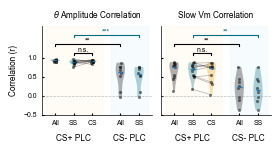

In [349]:
# Theta Amplitude Correlations - CS+ PLC vs CS- PLC (5-group figure)
# Groups: CS+ PLC (All, SS, CS) | CS- PLC (All, SS) - no CS for CS- PLC
# Paired tests within CS+ group only, unpaired tests between groups

panel_w, panel_h = 1.4, 1.6
import os
fig, (ax_theta, ax_slow) = plt.subplots(1, 2, figsize=(panel_w * 2, panel_h), sharex=True, sharey=True)
ax = ax_theta

all_color = 'black'
ss_color = '#026C80'
cs_color = '#EE9B00'

# Check if columns exist
if 'theta_corr_all' not in df_pc.columns:
    print("Missing theta correlation columns. Please re-run statistics collection.")
else:
    # Get data for CS+ PLC
    peak_cs_csplc = df_cs_plc['peak_rate_cs'].values
    theta_cs_all = df_cs_plc['theta_corr_all'].values[np.isfinite(df_cs_plc['theta_corr_all'].values)]
    theta_cs_ss = df_cs_plc['theta_corr_ss'].values[np.isfinite(df_cs_plc['theta_corr_ss'].values)]
    theta_cs_cs_mask = np.isfinite(df_cs_plc['theta_corr_cs'].values) & (peak_cs_csplc > 0)
    theta_cs_cs = df_cs_plc['theta_corr_cs'].values[theta_cs_cs_mask]
    
    # Paired data for CS+ PLC
    paired_mask_csplc = (np.isfinite(df_cs_plc['theta_corr_ss'].values) &
                         np.isfinite(df_cs_plc['theta_corr_cs'].values) &
                         (peak_cs_csplc > 0))
    theta_cs_ss_paired = df_cs_plc['theta_corr_ss'].values[paired_mask_csplc]
    theta_cs_cs_paired = df_cs_plc['theta_corr_cs'].values[paired_mask_csplc]
    
    # Get data for CS- PLC (All and SS only, no CS)
    theta_non_all = df_non_cs_plc['theta_corr_all'].values[np.isfinite(df_non_cs_plc['theta_corr_all'].values)]
    theta_non_ss = df_non_cs_plc['theta_corr_ss'].values[np.isfinite(df_non_cs_plc['theta_corr_ss'].values)]
    
    positions = [1, 2, 3, 4.5, 5.5]  # 5 positions (no CS for CS- PLC)
    
    # Add background shading
    ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg, zorder=0)
    ax.axvspan(4.0, 6.0, alpha=0.3, color=non_cs_plc_bg, zorder=0)
    
    # Add group labels at bottom
    ax.text(2, -0.22, 'CS+ PLC', ha='center', va='top', 
            fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())
    ax.text(5, -0.22, 'CS- PLC', ha='center', va='top', 
            fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())
    
    data_list = [theta_cs_all, theta_cs_ss, theta_cs_cs, theta_non_all, theta_non_ss]
    colors_list = [all_color, ss_color, cs_color, all_color, ss_color]
    
    # Shared y-axis across theta + slow panels
    ylim = (-0.5, 1.0)
    
    # Plot violins
    for pos, data, c in zip(positions, data_list, colors_list):
        if len(data) >= 3:
            parts = ax.violinplot([data], positions=[pos], showmedians=True, showextrema=False)
            _style_violin_medians(parts)
            for body in parts['bodies']:
                body.set_alpha(0.3)
                body.set_facecolor(c)
                body.set_edgecolor('none')
    
    # Paired lines within CS+ group only
    for i in range(len(theta_cs_ss_paired)):
        ax.plot([2, 3], [theta_cs_ss_paired[i], theta_cs_cs_paired[i]], color='black', alpha=0.3, linewidth=0.5)
    
    # Scatter points
    rng = np.random.default_rng(42)
    for pos, data in zip(positions, data_list):
        if len(data) >= 1:
            jitter = (rng.random(len(data)) - 0.5) * 0.12
            ax.scatter(pos + jitter, data, s=5, color='black', alpha=0.5, linewidths=0)
    
    # Reference line at 0
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Formatting
    ax.set_title(r'$\theta$ Amplitude Correlation', fontsize=6, fontname='Arial')
    ax.set_ylabel('Correlation (r)', fontsize=6, fontname='Arial')
    ax.set_xticks(positions)
    ax.set_xticklabels(['All', 'SS', 'CS', 'All', 'SS'], fontsize=4, fontname='Arial')
    ax.set_xlim(0.3, 6.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=5)
    ax.set_yticks([-0.5, 0, 0.5, 1.0])
    
    # Pre-define test outputs (so we can always print them)
    p_cs_paired = np.nan
    stat_cs_paired = np.nan
    test_cs_paired = 'n/a'
    n_cs_paired = 0
    shapiro_cs_paired = np.nan
    
    p_all_unpaired = p_ss_unpaired = np.nan
    test_all = test_ss = 'n/a'
    shapiro_all_1 = shapiro_all_2 = np.nan
    shapiro_ss_1 = shapiro_ss_2 = np.nan
    
    # Significance tests and brackets
    if ylim:
        y_range = ylim[1] - ylim[0]
        ax.set_ylim(ylim[0], ylim[1] + y_range * 0.55)
        
        h = y_range * 0.03
        text_h = y_range * 0.08
        gap = y_range * 0.05
        y1 = ylim[1] + y_range * 0.05
        
        # Level 1: Paired test (SS vs CS within CS+ group only)
        if len(theta_cs_ss_paired) >= 3:
            p_cs_paired, stat_cs_paired, test_cs_paired, n_cs_paired, shapiro_cs_paired = _paired_test(theta_cs_ss_paired, theta_cs_cs_paired)
            sig_cs_paired = _sig_label(p_cs_paired)
            add_bracket(ax, 2, 3, y1, h, sig_cs_paired)
        else:
            p_cs_paired = np.nan
        
        # Level 2: All comparison (unpaired)
        y2 = y1 + h + text_h + gap
        if len(theta_cs_all) >= 3 and len(theta_non_all) >= 3:
            p_all_unpaired, test_all, shapiro_all_1, shapiro_all_2 = unpaired_test_auto(theta_cs_all, theta_non_all)
            sig_all_unpaired = _sig_label(p_all_unpaired)
            add_bracket(ax, 1, 4.5, y2, h, sig_all_unpaired, color=all_color)
        
        # Level 3: SS comparison (unpaired)
        y3 = y2 + h + text_h + gap
        if len(theta_cs_ss) >= 3 and len(theta_non_ss) >= 3:
            p_ss_unpaired, test_ss, shapiro_ss_1, shapiro_ss_2 = unpaired_test_auto(theta_cs_ss, theta_non_ss)
            sig_ss_unpaired = _sig_label(p_ss_unpaired)
            add_bracket(ax, 2, 5.5, y3, h, sig_ss_unpaired, color=ss_color)
    
    # Print summary stats
    print("\n" + "="*70)
    print("THETA AMPLITUDE CORRELATION: CS+ PLC vs CS- PLC")
    print("="*70)
    print(f"\nCS+ PLC (n={len(df_cs_plc)}):")
    print(f"  All: {np.mean(theta_cs_all):.3f} ± {np.std(theta_cs_all):.3f} (n={len(theta_cs_all)})")
    print(f"  SS:  {np.mean(theta_cs_ss):.3f} ± {np.std(theta_cs_ss):.3f} (n={len(theta_cs_ss)})")
    print(f"  CS:  {np.mean(theta_cs_cs):.3f} ± {np.std(theta_cs_cs):.3f} (n={len(theta_cs_cs)})")
    print(f"\nCS- PLC (n={len(df_non_cs_plc)}):")
    print(f"  All: {np.mean(theta_non_all):.3f} ± {np.std(theta_non_all):.3f} (n={len(theta_non_all)})")
    print(f"  SS:  {np.mean(theta_non_ss):.3f} ± {np.std(theta_non_ss):.3f} (n={len(theta_non_ss)})")
    
    print("\nStatistical tests (normality → test):")
    if np.isfinite(p_cs_paired):
        print(
            f"  Paired (CS+ PLC) SS vs CS: {test_cs_paired}, n={n_cs_paired}, stat={stat_cs_paired:.3g}, p={p_cs_paired:.2e}, shapiro_p={shapiro_cs_paired:.3g}"
        )
    else:
        print("  Paired (CS+ PLC) SS vs CS: n/a")
    
    if np.isfinite(p_all_unpaired):
        print(
            f"  Unpaired (All) CS+ vs CS-: {test_all}, p={p_all_unpaired:.2e}, shapiro_p1={shapiro_all_1:.3g}, shapiro_p2={shapiro_all_2:.3g} (n1={len(theta_cs_all)}, n2={len(theta_non_all)})"
        )
    else:
        print("  Unpaired (All) CS+ vs CS-: n/a")
    
    if np.isfinite(p_ss_unpaired):
        print(
            f"  Unpaired (SS) CS+ vs CS-: {test_ss}, p={p_ss_unpaired:.2e}, shapiro_p1={shapiro_ss_1:.3g}, shapiro_p2={shapiro_ss_2:.3g} (n1={len(theta_cs_ss)}, n2={len(theta_non_ss)})"
        )
    else:
        print("  Unpaired (SS) CS+ vs CS-: n/a")

    # ============================================================================
    # Slow Vm Correlations panel (shared x/y with theta)
    # ============================================================================
    ax = ax_slow
    ax.set_title('Slow Vm Correlation', fontsize=6, fontname='Arial')
    ax.tick_params(labelleft=False)
    # Background shading + group labels
    ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg, zorder=0)
    ax.axvspan(4.0, 6.0, alpha=0.3, color=non_cs_plc_bg, zorder=0)
    ax.text(2, -0.22, 'CS+ PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())
    ax.text(5, -0.22, 'CS- PLC', ha='center', va='top', fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())
    
    if 'slow_corr_all' not in df_pc.columns:
        print("Missing slow correlation columns. Please re-run statistics collection.")
        ax.axis('off')
    else:
        peak_cs_csplc = df_cs_plc['peak_rate_cs'].values
        slow_cs_all = df_cs_plc['slow_corr_all'].values[np.isfinite(df_cs_plc['slow_corr_all'].values)]
        slow_cs_ss = df_cs_plc['slow_corr_ss'].values[np.isfinite(df_cs_plc['slow_corr_ss'].values)]
        slow_cs_cs_mask = np.isfinite(df_cs_plc['slow_corr_cs'].values) & (peak_cs_csplc > 0)
        slow_cs_cs = df_cs_plc['slow_corr_cs'].values[slow_cs_cs_mask]
        
        paired_mask_csplc = (np.isfinite(df_cs_plc['slow_corr_ss'].values) &
                             np.isfinite(df_cs_plc['slow_corr_cs'].values) &
                             (peak_cs_csplc > 0))
        slow_cs_ss_paired = df_cs_plc['slow_corr_ss'].values[paired_mask_csplc]
        slow_cs_cs_paired = df_cs_plc['slow_corr_cs'].values[paired_mask_csplc]
        
        # CS- PLC: All and SS only, no CS
        slow_non_all = df_non_cs_plc['slow_corr_all'].values[np.isfinite(df_non_cs_plc['slow_corr_all'].values)]
        slow_non_ss = df_non_cs_plc['slow_corr_ss'].values[np.isfinite(df_non_cs_plc['slow_corr_ss'].values)]
        
        data_list = [slow_cs_all, slow_cs_ss, slow_cs_cs, slow_non_all, slow_non_ss]
        colors_list = [all_color, ss_color, cs_color, all_color, ss_color]
        
        for pos, data, c in zip(positions, data_list, colors_list):
            if len(data) >= 3:
                parts = ax.violinplot([data], positions=[pos], showmedians=True, showextrema=False)
                _style_violin_medians(parts)
                for body in parts['bodies']:
                    body.set_alpha(0.3)
                    body.set_facecolor(c)
                    body.set_edgecolor('none')
        
        # Paired lines within CS+ group only
        for i in range(len(slow_cs_ss_paired)):
            ax.plot([2, 3], [slow_cs_ss_paired[i], slow_cs_cs_paired[i]], color='black', alpha=0.3, linewidth=0.5)
        
        rng = np.random.default_rng(43)
        for pos, data in zip(positions, data_list):
            if len(data) >= 1:
                jitter = (rng.random(len(data)) - 0.5) * 0.12
                ax.scatter(pos + jitter, data, s=5, color='black', alpha=0.5, linewidths=0)
        
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.set_ylabel('')
        ax.set_xticks(positions)
        ax.set_xticklabels(['All', 'SS', 'CS', 'All', 'SS'], fontsize=4, fontname='Arial')
        ax.set_xlim(0.3, 6.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', labelsize=5)
        ax.set_yticks([-0.5, 0, 0.5, 1.0])
        
        p_cs_paired_s = np.nan
        stat_cs_paired_s = np.nan
        test_cs_paired_s = 'n/a'
        n_cs_paired_s = 0
        shapiro_cs_paired_s = np.nan
        p_all_unpaired_s = p_ss_unpaired_s = np.nan
        test_all_s = test_ss_s = 'n/a'
        shapiro_all_1_s = shapiro_all_2_s = np.nan
        shapiro_ss_1_s = shapiro_ss_2_s = np.nan
        
        if ylim:
            y_range = ylim[1] - ylim[0]
            h = y_range * 0.03
            text_h = y_range * 0.08
            gap = y_range * 0.05
            y1 = ylim[1] + y_range * 0.05
            
            # Level 1: Paired test within CS+ group only
            if len(slow_cs_ss_paired) >= 3:
                p_cs_paired_s, stat_cs_paired_s, test_cs_paired_s, n_cs_paired_s, shapiro_cs_paired_s = _paired_test(slow_cs_ss_paired, slow_cs_cs_paired)
                add_bracket(ax, 2, 3, y1, h, _sig_label(p_cs_paired_s))
            
            # Level 2: All comparison
            y2 = y1 + h + text_h + gap
            if len(slow_cs_all) >= 3 and len(slow_non_all) >= 3:
                p_all_unpaired_s, test_all_s, shapiro_all_1_s, shapiro_all_2_s = unpaired_test_auto(slow_cs_all, slow_non_all)
                add_bracket(ax, 1, 4.5, y2, h, _sig_label(p_all_unpaired_s), color=all_color)
            
            # Level 3: SS comparison
            y3 = y2 + h + text_h + gap
            if len(slow_cs_ss) >= 3 and len(slow_non_ss) >= 3:
                p_ss_unpaired_s, test_ss_s, shapiro_ss_1_s, shapiro_ss_2_s = unpaired_test_auto(slow_cs_ss, slow_non_ss)
                add_bracket(ax, 2, 5.5, y3, h, _sig_label(p_ss_unpaired_s), color=ss_color)
        
        print("\n" + "="*70)
        print("SLOW VM CORRELATION: CS+ PLC vs CS- PLC")
        print("="*70)
        print(f"\nCS+ PLC (n={len(df_cs_plc)}):")
        print(f"  All: {np.mean(slow_cs_all):.3f} ± {np.std(slow_cs_all):.3f} (n={len(slow_cs_all)})")
        print(f"  SS:  {np.mean(slow_cs_ss):.3f} ± {np.std(slow_cs_ss):.3f} (n={len(slow_cs_ss)})")
        print(f"  CS:  {np.mean(slow_cs_cs):.3f} ± {np.std(slow_cs_cs):.3f} (n={len(slow_cs_cs)})")
        print(f"\nCS- PLC (n={len(df_non_cs_plc)}):")
        print(f"  All: {np.mean(slow_non_all):.3f} ± {np.std(slow_non_all):.3f} (n={len(slow_non_all)})")
        print(f"  SS:  {np.mean(slow_non_ss):.3f} ± {np.std(slow_non_ss):.3f} (n={len(slow_non_ss)})")
        print("\nStatistical tests (normality → test):")
        if np.isfinite(p_cs_paired_s):
            print(f"  Paired (CS+ PLC) SS vs CS: {test_cs_paired_s}, n={n_cs_paired_s}, stat={stat_cs_paired_s:.3g}, p={p_cs_paired_s:.2e}, shapiro_p={shapiro_cs_paired_s:.3g}")
        else:
            print("  Paired (CS+ PLC) SS vs CS: n/a")
        if np.isfinite(p_all_unpaired_s):
            print(f"  Unpaired (All) CS+ vs CS-: {test_all_s}, p={p_all_unpaired_s:.2e}, shapiro_p1={shapiro_all_1_s:.3g}, shapiro_p2={shapiro_all_2_s:.3g} (n1={len(slow_cs_all)}, n2={len(slow_non_all)})")
        else:
            print("  Unpaired (All) CS+ vs CS-: n/a")
        if np.isfinite(p_ss_unpaired_s):
            print(f"  Unpaired (SS) CS+ vs CS-: {test_ss_s}, p={p_ss_unpaired_s:.2e}, shapiro_p1={shapiro_ss_1_s:.3g}, shapiro_p2={shapiro_ss_2_s:.3g} (n1={len(slow_cs_ss)}, n2={len(slow_non_ss)})")
        else:
            print("  Unpaired (SS) CS+ vs CS-: n/a")
    
    # Final formatting + save combined figure
    for _ax in (ax_theta, ax_slow):
        _ax.set_xlim(0.3, 6.2)
        _ax.set_yticks([-0.5, 0, 0.5, 1.0])
    # Shared y-limits with headroom for brackets
    _y_range = float(ylim[1] - ylim[0])
    ax_theta.set_ylim(float(ylim[0]), float(ylim[1] + _y_range * 0.55))
    
    plt.tight_layout()
    save_path = os.path.join(figure_save_folder, 'theta_slow_corr_cs_plus_minus_plc.svg')
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {save_path}')
    plt.show()

In [350]:
# # Slow Vm Correlations - CS+ PLC vs CS- PLC (6-group figure)
# # Groups: CS+ PLC (All, SS, CS) | CS- PLC (All, SS, CS)
# # Paired tests within groups, unpaired tests between groups

# panel_w, panel_h = 1.8, 1.6
# fig, ax = plt.subplots(1, 1, figsize=(panel_w, panel_h))

# all_color = 'black'
# ss_color = '#026C80'
# cs_color = '#EE9B00'

# # Check if columns exist
# if 'slow_corr_all' not in df_pc.columns:
#     print("Missing slow correlation columns. Please re-run statistics collection.")
# else:
#     # Get data for CS+ PLC
#     peak_cs_csplc = df_cs_plc['peak_rate_cs'].values
#     slow_cs_all = df_cs_plc['slow_corr_all'].values[np.isfinite(df_cs_plc['slow_corr_all'].values)]
#     slow_cs_ss = df_cs_plc['slow_corr_ss'].values[np.isfinite(df_cs_plc['slow_corr_ss'].values)]
#     slow_cs_cs_mask = np.isfinite(df_cs_plc['slow_corr_cs'].values) & (peak_cs_csplc > 0)
#     slow_cs_cs = df_cs_plc['slow_corr_cs'].values[slow_cs_cs_mask]
    
#     # Paired data for CS+ PLC
#     paired_mask_csplc = (np.isfinite(df_cs_plc['slow_corr_ss'].values) &
#                          np.isfinite(df_cs_plc['slow_corr_cs'].values) &
#                          (peak_cs_csplc > 0))
#     slow_cs_ss_paired = df_cs_plc['slow_corr_ss'].values[paired_mask_csplc]
#     slow_cs_cs_paired = df_cs_plc['slow_corr_cs'].values[paired_mask_csplc]
    
#     # Get data for CS- PLC
#     peak_cs_noncsplc = df_non_cs_plc['peak_rate_cs'].values
#     slow_non_all = df_non_cs_plc['slow_corr_all'].values[np.isfinite(df_non_cs_plc['slow_corr_all'].values)]
#     slow_non_ss = df_non_cs_plc['slow_corr_ss'].values[np.isfinite(df_non_cs_plc['slow_corr_ss'].values)]
#     slow_non_cs_mask = np.isfinite(df_non_cs_plc['slow_corr_cs'].values) & (peak_cs_noncsplc > 0)
#     slow_non_cs = df_non_cs_plc['slow_corr_cs'].values[slow_non_cs_mask]
    
#     # Paired data for CS- PLC
#     paired_mask_noncsplc = (np.isfinite(df_non_cs_plc['slow_corr_ss'].values) &
#                             np.isfinite(df_non_cs_plc['slow_corr_cs'].values) &
#                             (peak_cs_noncsplc > 0))
#     slow_non_ss_paired = df_non_cs_plc['slow_corr_ss'].values[paired_mask_noncsplc]
#     slow_non_cs_paired = df_non_cs_plc['slow_corr_cs'].values[paired_mask_noncsplc]
    
#     positions = [1, 2, 3, 4.5, 5.5, 6.5]
    
#     # Add background shading
#     ax.axvspan(0.5, 3.5, alpha=0.3, color=cs_plc_bg, zorder=0)
#     ax.axvspan(4.0, 7.0, alpha=0.3, color=non_cs_plc_bg, zorder=0)
    
#     # Add group labels at bottom
#     ax.text(2, -0.22, 'CS+ PLC', ha='center', va='top', 
#             fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())
#     ax.text(5.5, -0.22, 'CS- PLC', ha='center', va='top', 
#             fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())
    
#     data_list = [slow_cs_all, slow_cs_ss, slow_cs_cs, slow_non_all, slow_non_ss, slow_non_cs]
#     colors_list = [all_color, ss_color, cs_color, all_color, ss_color, cs_color]
    
#     # Get global ylim
#     all_data_flat = np.concatenate([d for d in data_list if len(d) > 0]) if any(len(d) > 0 for d in data_list) else np.array([])
#     ylim = (-1.0, 1.0) if len(all_data_flat) > 0 else None
    
#     # Plot violins
#     for pos, data, c in zip(positions, data_list, colors_list):
#         if len(data) >= 3:
#             parts = ax.violinplot([data], positions=[pos], showmedians=True, showextrema=False)
#             _style_violin_medians(parts)
#             for body in parts['bodies']:
#                 body.set_alpha(0.3)
#                 body.set_facecolor(c)
#                 body.set_edgecolor('none')
    
#     # Paired lines within each group
#     for i in range(len(slow_cs_ss_paired)):
#         ax.plot([2, 3], [slow_cs_ss_paired[i], slow_cs_cs_paired[i]], color='black', alpha=0.3, linewidth=0.5)
#     for i in range(len(slow_non_ss_paired)):
#         ax.plot([5.5, 6.5], [slow_non_ss_paired[i], slow_non_cs_paired[i]], color='black', alpha=0.3, linewidth=0.5)
    
#     # Scatter points
#     rng = np.random.default_rng(43)
#     for pos, data in zip(positions, data_list):
#         if len(data) >= 1:
#             jitter = (rng.random(len(data)) - 0.5) * 0.12
#             ax.scatter(pos + jitter, data, s=5, color='black', alpha=0.5, linewidths=0)
    
#     # Reference line at 0
#     ax.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    
#     # Formatting
#     ax.set_title('Slow Vm Correlation', fontsize=6, fontname='Arial')
#     ax.set_ylabel('Correlation (r)', fontsize=6, fontname='Arial')
#     ax.set_xticks(positions)
#     ax.set_xticklabels(['All', 'SS', 'CS', 'All', 'SS', 'CS'], fontsize=4, fontname='Arial')
#     ax.set_xlim(0.3, 7.2)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.tick_params(axis='both', labelsize=5)
#     if ylim is not None:
#         ax.set_yticks(np.linspace(ylim[0], ylim[1], 3))
#     else:
#         ax.set_yticks([-1, 0, 1])
    
#     # Pre-define test outputs (so we can always print them)
#     p_cs_paired = p_non_paired = np.nan
#     stat_cs_paired = stat_non_paired = np.nan
#     test_cs_paired = test_non_paired = 'n/a'
#     n_cs_paired = n_non_paired = 0
#     shapiro_cs_paired = shapiro_non_paired = np.nan
    
#     p_all_unpaired = p_ss_unpaired = p_cs_unpaired = np.nan
#     test_all = test_ss = test_cs = 'n/a'
#     shapiro_all_1 = shapiro_all_2 = np.nan
#     shapiro_ss_1 = shapiro_ss_2 = np.nan
#     shapiro_cs_1 = shapiro_cs_2 = np.nan
    
#     # Significance tests and brackets
#     if ylim:
#         y_range = ylim[1] - ylim[0]
#         ax.set_ylim(ylim[0], ylim[1] + y_range * 0.65)
        
#         h = y_range * 0.03
#         text_h = y_range * 0.08
#         gap = y_range * 0.05
#         y1 = ylim[1] + y_range * 0.05
        
#         # Level 1: Paired tests (SS vs CS within each group)
#         if len(slow_cs_ss_paired) >= 3:
#             p_cs_paired, stat_cs_paired, test_cs_paired, n_cs_paired, shapiro_cs_paired = _paired_test(slow_cs_ss_paired, slow_cs_cs_paired)
#             sig_cs_paired = _sig_label(p_cs_paired)
#             add_bracket(ax, 2, 3, y1, h, sig_cs_paired)
#         else:
#             p_cs_paired = np.nan
        
#         if len(slow_non_ss_paired) >= 3:
#             p_non_paired, stat_non_paired, test_non_paired, n_non_paired, shapiro_non_paired = _paired_test(slow_non_ss_paired, slow_non_cs_paired)
#             sig_non_paired = _sig_label(p_non_paired)
#             add_bracket(ax, 5.5, 6.5, y1, h, sig_non_paired)
#         else:
#             p_non_paired = np.nan
        
#         # Level 2: All comparison (unpaired)
#         y2 = y1 + h + text_h + gap
#         if len(slow_cs_all) >= 3 and len(slow_non_all) >= 3:
#             p_all_unpaired, test_all, shapiro_all_1, shapiro_all_2 = unpaired_test_auto(slow_cs_all, slow_non_all)
#             sig_all_unpaired = _sig_label(p_all_unpaired)
#             add_bracket(ax, 1, 4.5, y2, h, sig_all_unpaired, color=all_color)
        
#         # Level 3: SS comparison (unpaired)
#         y3 = y2 + h + text_h + gap
#         if len(slow_cs_ss) >= 3 and len(slow_non_ss) >= 3:
#             p_ss_unpaired, test_ss, shapiro_ss_1, shapiro_ss_2 = unpaired_test_auto(slow_cs_ss, slow_non_ss)
#             sig_ss_unpaired = _sig_label(p_ss_unpaired)
#             add_bracket(ax, 2, 5.5, y3, h, sig_ss_unpaired, color=ss_color)
        
#         # Level 4: CS comparison (unpaired)
#         y4 = y3 + h + text_h + gap
#         if len(slow_cs_cs) >= 3 and len(slow_non_cs) >= 3:
#             p_cs_unpaired, test_cs, shapiro_cs_1, shapiro_cs_2 = unpaired_test_auto(slow_cs_cs, slow_non_cs)
#             sig_cs_unpaired = _sig_label(p_cs_unpaired)
#             add_bracket(ax, 3, 6.5, y4, h, sig_cs_unpaired, color=cs_color)
    
#     plt.tight_layout()
#     save_path = os.path.join(figure_save_folder, 'slow_corr_cs_plus_minus_plc.svg')
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     print(f'Saved: {save_path}')
#     plt.show()
    
#     # Print summary stats
#     print("\n" + "="*70)
#     print("SLOW VM CORRELATION: CS+ PLC vs CS- PLC")
#     print("="*70)
#     print(f"\nCS+ PLC (n={len(df_cs_plc)}):")
#     print(f"  All: {np.mean(slow_cs_all):.3f} ± {np.std(slow_cs_all):.3f} (n={len(slow_cs_all)})")
#     print(f"  SS:  {np.mean(slow_cs_ss):.3f} ± {np.std(slow_cs_ss):.3f} (n={len(slow_cs_ss)})")
#     print(f"  CS:  {np.mean(slow_cs_cs):.3f} ± {np.std(slow_cs_cs):.3f} (n={len(slow_cs_cs)})")
#     print(f"\nCS- PLC (n={len(df_non_cs_plc)}):")
#     print(f"  All: {np.mean(slow_non_all):.3f} ± {np.std(slow_non_all):.3f} (n={len(slow_non_all)})")
#     print(f"  SS:  {np.mean(slow_non_ss):.3f} ± {np.std(slow_non_ss):.3f} (n={len(slow_non_ss)})")
#     print(f"  CS:  {np.mean(slow_non_cs):.3f} ± {np.std(slow_non_cs):.3f} (n={len(slow_non_cs)})")
    
#     print("\nStatistical tests (normality \u2192 test):")
#     if np.isfinite(p_cs_paired):
#         print(
#             f"  Paired (CS+ PLC) SS vs CS: {test_cs_paired}, n={n_cs_paired}, stat={stat_cs_paired:.3g}, p={p_cs_paired:.2e}, shapiro_p={shapiro_cs_paired:.3g}"
#         )
#     else:
#         print("  Paired (CS+ PLC) SS vs CS: n/a")
    
#     if np.isfinite(p_non_paired):
#         print(
#             f"  Paired (CS- PLC) SS vs CS: {test_non_paired}, n={n_non_paired}, stat={stat_non_paired:.3g}, p={p_non_paired:.2e}, shapiro_p={shapiro_non_paired:.3g}"
#         )
#     else:
#         print("  Paired (CS- PLC) SS vs CS: n/a")
    
#     if np.isfinite(p_all_unpaired):
#         print(
#             f"  Unpaired (All) CS+ vs CS-: {test_all}, p={p_all_unpaired:.2e}, shapiro_p1={shapiro_all_1:.3g}, shapiro_p2={shapiro_all_2:.3g} (n1={len(slow_cs_all)}, n2={len(slow_non_all)})"
#         )
#     else:
#         print("  Unpaired (All) CS+ vs CS-: n/a")
    
#     if np.isfinite(p_ss_unpaired):
#         print(
#             f"  Unpaired (SS) CS+ vs CS-: {test_ss}, p={p_ss_unpaired:.2e}, shapiro_p1={shapiro_ss_1:.3g}, shapiro_p2={shapiro_ss_2:.3g} (n1={len(slow_cs_ss)}, n2={len(slow_non_ss)})"
#         )
#     else:
#         print("  Unpaired (SS) CS+ vs CS-: n/a")
    
#     if np.isfinite(p_cs_unpaired):
#         print(
#             f"  Unpaired (CS) CS+ vs CS-: {test_cs}, p={p_cs_unpaired:.2e}, shapiro_p1={shapiro_cs_1:.3g}, shapiro_p2={shapiro_cs_2:.3g} (n1={len(slow_cs_cs)}, n2={len(slow_non_cs)})"
#         )
#     else:
#         print("  Unpaired (CS) CS+ vs CS-: n/a")


# SS and CB shape

Grand SS (all PLCs, run): In PF n_cells=18, Out PF n_cells=17, info={'skipped_missing': 0, 'skipped_mismatch': 0, 'skipped_low_n': 1, 'skipped_norm': 0}
Grand CB (CS+ PLCs, run): In PF n_cells=10, Out PF n_cells=10, info={'skipped_missing': 0, 'skipped_mismatch': 0, 'skipped_low_n': 0, 'skipped_norm': 0}


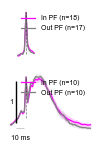

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/grand_average_spike_shapes_ss_cb.svg


In [351]:
# Grand average SS (all PLCs) and CB (CS+ PLCs) shapes
# Overlays In-PF (magenta) vs Out-PF (gray), with mean±SEM and mean-waveform normalization.

import numpy as np
import matplotlib.pyplot as plt

spike_shape_state = 'run'
in_color = 'magenta'
out_color = 'gray'

# Minimum waveforms per cell to include that cell in the grand-average
min_waves_per_cell_ss = 5
min_waves_per_cell_cb = 3

plcs_all = list(plcs_csplus) + list(plcs_csminus)

def _cell_mean(waves):
    if len(waves) == 0:
        return None
    arr = np.vstack(waves)
    return np.nanmean(arr, axis=0)

def _normalize_mean(time_ms, mean):
    time_ms = np.asarray(time_ms, dtype=float)
    mean = np.asarray(mean, dtype=float)
    pre_mask = time_ms < 0
    if not np.any(pre_mask):
        return None
    baseline = np.nanmean(mean[pre_mask])
    if not np.isfinite(baseline):
        return None
    idx0 = int(np.nanargmin(np.abs(time_ms)))
    if not np.isfinite(mean[idx0]):
        return None
    height = mean[idx0] - baseline
    if not np.isfinite(height) or abs(height) < 1e-12:
        return None
    return (mean - baseline) / height

def _gather_cell_mean_curves(cells, spike_type, state='run', min_waves_per_cell=5):
    time_ms = None
    in_means = []
    out_means = []
    skipped_missing = 0
    skipped_mismatch = 0
    skipped_low_n = 0
    skipped_norm = 0
    for cell in cells:
        spike_shapes = cell.get('spike_shapes')
        if not isinstance(spike_shapes, dict):
            skipped_missing += 1
            continue
        info = spike_shapes.get(spike_type)
        if not isinstance(info, dict):
            skipped_missing += 1
            continue
        t = np.asarray(info.get('time_ms', []), dtype=float)
        if t.size == 0:
            skipped_missing += 1
            continue
        if time_ms is None:
            time_ms = t
        else:
            if t.shape != time_ms.shape or np.nanmax(np.abs(t - time_ms)) > 1e-6:
                skipped_mismatch += 1
                continue
        shapes = info.get('shapes', {})

        waves_in = list(shapes.get(f"{state}_in", []))
        if len(waves_in) >= int(min_waves_per_cell):
            mean_in = _cell_mean(waves_in)
            mean_in = _normalize_mean(time_ms, mean_in) if mean_in is not None else None
            if mean_in is not None:
                in_means.append(mean_in)
            else:
                skipped_norm += 1
        else:
            skipped_low_n += 1

        waves_out = list(shapes.get(f"{state}_out", []))
        if len(waves_out) >= int(min_waves_per_cell):
            mean_out = _cell_mean(waves_out)
            mean_out = _normalize_mean(time_ms, mean_out) if mean_out is not None else None
            if mean_out is not None:
                out_means.append(mean_out)
            else:
                skipped_norm += 1
        else:
            skipped_low_n += 1

    info = {
        'skipped_missing': skipped_missing,
        'skipped_mismatch': skipped_mismatch,
        'skipped_low_n': skipped_low_n,
        'skipped_norm': skipped_norm,
    }
    return time_ms, in_means, out_means, info

def _grand_mean_sem(cell_means):
    if len(cell_means) == 0:
        return None
    arr = np.vstack(cell_means)
    mean = np.nanmean(arr, axis=0)
    n_eff = np.sum(np.isfinite(arr), axis=0)
    std = np.nanstd(arr, axis=0, ddof=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        sem = np.where(n_eff > 0, std / np.sqrt(n_eff), np.nan)
    return mean, sem

# Gather per-cell mean curves ("grand average of the average")
t_ss, ss_in_means, ss_out_means, ss_info = _gather_cell_mean_curves(
    plcs_all,
    'simple',
    state=spike_shape_state,
    min_waves_per_cell=min_waves_per_cell_ss,
)
t_cb, cb_in_means, cb_out_means, cb_info = _gather_cell_mean_curves(
    plcs_csplus,
    'complex',
    state=spike_shape_state,
    min_waves_per_cell=min_waves_per_cell_cb,
)

print(f"Grand SS (all PLCs, {spike_shape_state}): In PF n_cells={len(ss_in_means)}, Out PF n_cells={len(ss_out_means)}, info={ss_info}")
print(f"Grand CB (CS+ PLCs, {spike_shape_state}): In PF n_cells={len(cb_in_means)}, Out PF n_cells={len(cb_out_means)}, info={cb_info}")

if t_ss is None or t_cb is None:
    print("Missing time_ms arrays (spike_shapes not present).")
else:
    ss_in_curve = _grand_mean_sem(ss_in_means)
    ss_out_curve = _grand_mean_sem(ss_out_means)
    cb_in_curve = _grand_mean_sem(cb_in_means)
    cb_out_curve = _grand_mean_sem(cb_out_means)

    # Global y-limits across both panels (compact)
    y_lows = []
    y_highs = []
    for curve in (ss_in_curve, ss_out_curve, cb_in_curve, cb_out_curve):
        if curve is None:
            continue
        mean_n, sem_n = curve
        y_lows.append(mean_n - sem_n)
        y_highs.append(mean_n + sem_n)
    if y_lows and y_highs:
        y_min = float(np.nanmin(np.concatenate(y_lows)))
        y_max = float(np.nanmax(np.concatenate(y_highs)))
        if np.isfinite(y_min) and np.isfinite(y_max):
            if y_min == y_max:
                eps = 1e-3
                y_lim = (y_min - eps, y_max + eps)
            else:
                y_lim = (y_min, y_max)
        else:
            y_lim = (-0.2, 1.2)
    else:
        y_lim = (-0.2, 1.2)

    # Two-row figure (SS top, CB bottom) with shared axes
    fig, axes = plt.subplots(2, 1, figsize=(1., 1.5), sharey=True, sharex=True)

    x_min = float(np.nanmin(np.concatenate([t_ss, t_cb])))
    x_max = float(np.nanmax(np.concatenate([t_ss, t_cb])))

    # Panel 1: SS (all PLCs)
    ax = axes[0]
    #ax.text(0.02, 0.88, "SS (all PLCs)", transform=ax.transAxes, fontsize=6, fontname='Arial')
    plotted = False
    if ss_in_curve is not None:
        mean_n, sem_n = ss_in_curve
        ax.plot(t_ss, mean_n, color=in_color, linewidth=0.9, label=f"In PF (n={len(ss_in_means)})")
        ax.fill_between(t_ss, mean_n - sem_n, mean_n + sem_n, color=in_color, alpha=0.2, linewidth=0)
        plotted = True
    if ss_out_curve is not None:
        mean_n, sem_n = ss_out_curve
        ax.plot(t_ss, mean_n, color=out_color, linewidth=0.9, label=f"Out PF (n={len(ss_out_means)})")
        ax.fill_between(t_ss, mean_n - sem_n, mean_n + sem_n, color=out_color, alpha=0.2, linewidth=0)
        plotted = True
    if not plotted:
        ax.text(0.5, 0.5, "Not enough data", transform=ax.transAxes,
                ha='center', va='center', fontsize=6, fontname='Arial')
    #ax.set_xlim(float(np.nanmin(t_ss)), float(np.nanmax(t_ss)))
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(*y_lim)

    # Panel 2: CB (CS+ PLCs)
    ax = axes[1]
    #ax.text(0.02, 0.88, "CB (CS+ PLCs)", transform=ax.transAxes, fontsize=6, fontname='Arial')
    plotted = False
    if cb_in_curve is not None:
        mean_n, sem_n = cb_in_curve
        ax.plot(t_cb, mean_n, color=in_color, linewidth=0.9, label=f"In PF (n={len(cb_in_means)})")
        ax.fill_between(t_cb, mean_n - sem_n, mean_n + sem_n, color=in_color, alpha=0.2, linewidth=0)
        plotted = True
    if cb_out_curve is not None:
        mean_n, sem_n = cb_out_curve
        ax.plot(t_cb, mean_n, color=out_color, linewidth=0.9, label=f"Out PF (n={len(cb_out_means)})")
        ax.fill_between(t_cb, mean_n - sem_n, mean_n + sem_n, color=out_color, alpha=0.2, linewidth=0)
        plotted = True
    if not plotted:
        ax.text(0.5, 0.5, "Not enough data", transform=ax.transAxes,
                ha='center', va='center', fontsize=6, fontname='Arial')
    #ax.set_xlim(float(np.nanmin(t_cb)), float(np.nanmax(t_cb)))
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(*y_lim)

    # Style: no axes, shared scale bars only
    for ax in axes:
        y0, y1 = ax.get_ylim()
        y_line_low = max(y0, min(0.0, y1))
        y_line_high = max(y0, min(1.0, y1))
        y_line_low, y_line_high = sorted((y_line_low, y_line_high))
        if np.isfinite(y_line_low) and np.isfinite(y_line_high) and y_line_high > y_line_low:
            ax.plot([0, 0], [y_line_low, y_line_high], color='black', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.legend(frameon=False, fontsize=5, loc='upper right')

    # Shared scale bars on bottom axis
    ax_sb = axes[1]
    x0, x1 = ax_sb.get_xlim()
    y0, y1 = ax_sb.get_ylim()
    x_span = float(x1 - x0) if x1 != x0 else 1.0
    y_span = float(y1 - y0) if y1 != y0 else 1.0

    bar_ms = 10.0
    bar_y = y0 + 0.12 * y_span
    bar_x = x0 + 0.08 * x_span
    if bar_x + bar_ms > x1 - 0.05 * x_span:
        bar_x = (x1 - 0.08 * x_span) - bar_ms
    if bar_y + 1.0 > y1 - 0.05 * y_span:
        bar_y = (y1 - 0.08 * y_span) - 1.0

    # Horizontal: 10 ms
    ax_sb.plot([bar_x, bar_x + bar_ms], [bar_y-0.15, bar_y-0.15], color='black', linewidth=1, solid_capstyle='butt')
    ax_sb.text(bar_x + bar_ms / 2, bar_y - 0.2 - 0.08 * y_span, '10 ms', ha='center', va='top', fontsize=5, fontname='Arial')

    # Vertical: 1 spike height (normalized units)
    ax_sb.plot([bar_x, bar_x], [bar_y, bar_y + 1.0], color='black', linewidth=1, solid_capstyle='butt')
    ax_sb.text(bar_x - 0.04 * x_span, bar_y + 0.5, '1', ha='right', va='center', fontsize=5, fontname='Arial')

    plt.tight_layout()
    plt.show()

    # Save figure
    save_path = os.path.join(figure_save_folder, 'grand_average_spike_shapes_ss_cb.svg')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {save_path}')

CS+ PLCs included: n=10
  run_in: cells with >= 3 bursts = 10
  run_out: cells with >= 3 bursts = 10
  rest_in: cells with >= 3 bursts = 10
  rest_out: cells with >= 3 bursts = 10
Locomotion Spks./burst (CS+ PLCs, wilcoxon): n=10, stat=20, p=0.492, shapiro_p=0.0199
Locomotion Peak amp (CS+ PLCs, paired t-test): n=10, stat=-0.271, p=0.792, shapiro_p=0.179
Locomotion Duration (ms) (CS+ PLCs, paired t-test): n=10, stat=-0.245, p=0.812, shapiro_p=0.929
Locomotion AUC (CS+ PLCs, paired t-test): n=10, stat=0.0392, p=0.97, shapiro_p=0.885
Locomotion CB rate (Hz) (CS+ PLCs, paired t-test): n=10, stat=6.25, p=0.00015, shapiro_p=0.13
Locomotion CB prob. (CS+ PLCs, paired t-test): n=10, stat=1.17, p=0.27, shapiro_p=0.318
Locomotion %CB > 100 ms (CS+ PLCs, paired t-test): n=10, stat=0.351, p=0.734, shapiro_p=0.624
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/ComplexBurstMetrics_CSplus_run.svg


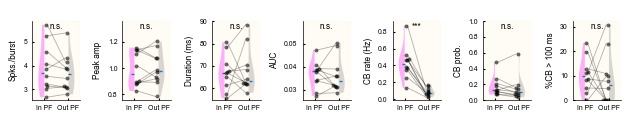

Quiet Spks./burst (CS+ PLCs, paired t-test): n=10, stat=0.353, p=0.732, shapiro_p=0.736
Quiet Peak amp (CS+ PLCs, paired t-test): n=10, stat=-0.932, p=0.376, shapiro_p=0.616
Quiet Duration (ms) (CS+ PLCs, paired t-test): n=10, stat=-0.849, p=0.418, shapiro_p=0.169
Quiet AUC (CS+ PLCs, paired t-test): n=10, stat=-1.44, p=0.184, shapiro_p=0.519
Quiet CB rate (Hz) (CS+ PLCs, wilcoxon): n=10, stat=0, p=0.00195, shapiro_p=0.00809
Quiet CB prob. (CS+ PLCs, paired t-test): n=10, stat=-0.265, p=0.797, shapiro_p=0.843
Quiet %CB > 100 ms (CS+ PLCs, paired t-test): n=10, stat=0.0873, p=0.932, shapiro_p=0.129
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/ComplexBurstMetrics_CSplus_rest.svg


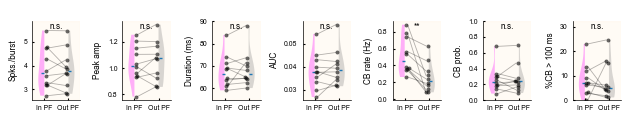

In [352]:
# Complex burst (CB) metrics violin plots - CS+ PLCs only

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
import os

min_bursts_per_condition = 3
# Background shading color for CS+ PLC panels (use notebook-defined value if available)
cs_plc_bg_color = globals().get('cs_plc_bg', '#f3c6df')

def _global_ylim(arrays, pad_frac=0.05, pct_low=1, pct_high=100):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        if arr.size == 0:
            continue
        finite = arr[np.isfinite(arr)]
        if finite.size > 0:
            vals.append(finite)
    if not vals:
        return None
    merged = np.concatenate(vals)
    y_min = float(np.nanpercentile(merged, pct_low))
    y_max = float(np.nanpercentile(merged, pct_high))
    span = y_max - y_min if y_max != y_min else 1.0
    pad = pad_frac * span
    return (y_min - pad, y_max + pad)

def _paired_test(vals_in, vals_out, alpha=0.05):
    """Paired test with normality check on within-pair differences."""
    vals_in = np.asarray(vals_in, dtype=float)
    vals_out = np.asarray(vals_out, dtype=float)
    n_pairs = min(len(vals_in), len(vals_out))
    if n_pairs == 0:
        return np.nan, np.nan, 'n/a', 0, np.nan
    paired_in = vals_in[:n_pairs]
    paired_out = vals_out[:n_pairs]
    valid = np.isfinite(paired_in) & np.isfinite(paired_out)
    n_valid = int(np.sum(valid))
    if n_valid < 3:
        return np.nan, np.nan, 'n/a', n_valid, np.nan
    diffs = paired_in[valid] - paired_out[valid]
    try:
        shapiro_p = scipy_stats.shapiro(diffs).pvalue
    except ValueError:
        shapiro_p = np.nan
    # With very small n, prefer nonparametric tests regardless of normality.
    if n_valid < 5:
        try:
            res = scipy_stats.wilcoxon(paired_in[valid], paired_out[valid])
            return res.pvalue, res.statistic, 'wilcoxon', n_valid, shapiro_p
        except ValueError:
            return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p
    if np.isfinite(shapiro_p) and shapiro_p >= alpha:
        res = scipy_stats.ttest_rel(paired_in[valid], paired_out[valid], nan_policy='omit')
        return res.pvalue, res.statistic, 'paired t-test', n_valid, shapiro_p
    try:
        res = scipy_stats.wilcoxon(paired_in[valid], paired_out[valid])
        return res.pvalue, res.statistic, 'wilcoxon', n_valid, shapiro_p
    except ValueError:
        return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p

def _sig_label(p_val):
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001:
        return '***'
    if p_val < 0.01:
        return '**'
    if p_val < 0.05:
        return '*'
    return 'n.s.'

include_simple_bursts = False
conditions = ['run_in', 'run_out', 'rest_in', 'rest_out']
condition_labels = ['In PF', 'Out PF']
plateau_threshold_ms = 100.0

def _infer_frame_rate(cell):
    if not isinstance(cell, dict):
        return None
    params = cell.get('params', {})
    fr = params.get('frame_rate', cell.get('frame_rate', None)) if isinstance(params, dict) else cell.get('frame_rate', None)
    if fr is not None:
        try:
            fr = float(fr)
        except (TypeError, ValueError):
            fr = None
        if fr is not None and np.isfinite(fr) and fr > 0:
            return fr
    ss = cell.get('spike_shapes')
    if not isinstance(ss, dict):
        return None
    for key in ('complex', 'simple'):
        info = ss.get(key)
        if not isinstance(info, dict):
            continue
        time_ms = np.asarray(info.get('time_ms', []), dtype=float)
        if time_ms.size < 2:
            continue
        dts = np.diff(time_ms)
        dts = dts[np.isfinite(dts) & (dts > 0)]
        if dts.size == 0:
            continue
        dt_ms = float(np.median(dts))
        return 1000.0 / dt_ms
    return None

def _inside_pf_xy(x, y, place_field_mask, width_real, height_real, bin_size):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    pf = np.asarray(place_field_mask).astype(bool)
    if x.size == 0 or y.size == 0 or pf.size == 0:
        return np.zeros_like(x, dtype=bool)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    bins = [
        np.arange(0, width_real + bin_size, bin_size),
        np.arange(0, height_real + bin_size, bin_size),
    ]
    xbin = np.digitize(x, bins[0]) - 1
    ybin = np.digitize(y, bins[1]) - 1
    in_bounds = (xbin >= 0) & (xbin < pf.shape[0]) & (ybin >= 0) & (ybin < pf.shape[1])
    inside = np.zeros(x.shape[0], dtype=bool)
    inside[in_bounds] = pf[xbin[in_bounds], ybin[in_bounds]]
    return inside

def _time_by_condition_s(cell, frame_rate):
    if frame_rate is None or not np.isfinite(frame_rate) or frame_rate <= 0:
        return None
    params = cell.get('params', {})
    width_real = float(params.get('width_real', np.nan))
    height_real = float(params.get('height_real', np.nan))
    bin_size = float(params.get('bin_size', np.nan))
    if not (np.isfinite(width_real) and np.isfinite(height_real) and np.isfinite(bin_size) and bin_size > 0):
        return None
    pf_mask = cell.get('place_field_mask')
    if pf_mask is None or not np.any(np.asarray(pf_mask)):
        return None
    x_run = cell.get('x_traj')
    y_run = cell.get('y_traj')
    if x_run is None or y_run is None:
        return None

    inside_run = _inside_pf_xy(x_run, y_run, pf_mask, width_real, height_real, bin_size)
    n_run = int(inside_run.size)
    in_run = int(np.sum(inside_run))
    out_run = n_run - in_run

    time_run_in = in_run / frame_rate
    time_run_out = out_run / frame_rate
    time_rest_in = np.nan
    time_rest_out = np.nan
    plot_data = cell.get('plot_data', {})
    x_all = None
    y_all = None
    if isinstance(plot_data, dict):
        x_all = plot_data.get('x_all_valid', None)
        y_all = plot_data.get('y_all_valid', None)
    if x_all is None:
        x_all = cell.get('x_all_valid', None)
    if y_all is None:
        y_all = cell.get('y_all_valid', None)
    if x_all is not None and y_all is not None:
        inside_all = _inside_pf_xy(x_all, y_all, pf_mask, width_real, height_real, bin_size)
        n_all = int(inside_all.size)
        in_all = int(np.sum(inside_all))
        out_all = n_all - in_all
        time_rest_in = max(0.0, (in_all - in_run) / frame_rate)
        time_rest_out = max(0.0, (out_all - out_run) / frame_rate)
    return {
        'run_in': float(time_run_in),
        'run_out': float(time_run_out),
        'rest_in': float(time_rest_in) if np.isfinite(time_rest_in) else np.nan,
        'rest_out': float(time_rest_out) if np.isfinite(time_rest_out) else np.nan,
    }

metric_specs = [
    ('n_spikes', 'Spks./burst'),
    ('peak_amp', 'Peak amp'),
    ('duration_ms', 'Duration (ms)'),
    ('auc', 'AUC'),
    ('burst_rate_hz', 'CB rate (Hz)'),
    ('burst_prob', 'CB prob.'),
    ('plateau_pct', f"%CB > {int(plateau_threshold_ms)} ms"),
]

# Build per-cell averages from the saved per-burst metrics (grand average of the average)
metric_data = {
    'complex': {metric: {cond: [] for cond in conditions} for metric, _ in metric_specs},
}
cond_counts = {
    'complex': {cond: [] for cond in conditions},
}

base_metric_keys = {'n_spikes', 'peak_amp', 'duration_ms', 'auc'}

for cell in plcs_csplus:
    bm = cell.get('burst_metrics')
    complex_by_cond = bm.get('complex') if isinstance(bm, dict) else None
    sbrm = cell.get('spike_burst_rate_metrics') if isinstance(cell, dict) else None
    for cond in conditions:
        bursts = []
        if isinstance(complex_by_cond, dict):
            bursts = complex_by_cond.get(cond, [])
        if not isinstance(bursts, (list, tuple)):
            bursts = []

        # Count bursts per cell per condition
        cond_counts['complex'][cond].append(int(len(bursts)))

        # Per-cell mean for each per-burst metric (only if enough bursts in that condition)
        for metric_key, _ in metric_specs:
            if metric_key in base_metric_keys:
                vals = []
                for b in bursts:
                    if not isinstance(b, dict):
                        continue
                    vals.append(float(b.get(metric_key, np.nan)))
                vals = np.asarray(vals, dtype=float)
                vals = vals[np.isfinite(vals)]
                if vals.size >= int(min_bursts_per_condition):
                    metric_data['complex'][metric_key][cond].append(float(np.nanmean(vals)))
                else:
                    metric_data['complex'][metric_key][cond].append(np.nan)
            elif metric_key == 'burst_rate_hz':
                # Load precomputed CB rate from analyze_place_cell_single_moving() output.
                val = np.nan
                if isinstance(sbrm, dict):
                    br = sbrm.get('burst_rate')
                    if isinstance(br, dict):
                        val = br.get(cond, np.nan)
                try:
                    val = float(val)
                except (TypeError, ValueError):
                    val = np.nan
                metric_data['complex'][metric_key][cond].append(val if np.isfinite(val) else np.nan)
            elif metric_key == 'burst_prob':
                # Load precomputed CB probability from analyze_place_cell_single_moving() output.
                val = np.nan
                if isinstance(sbrm, dict):
                    bp = sbrm.get('burst_prob')
                    if isinstance(bp, dict):
                        val = bp.get(cond, np.nan)
                try:
                    val = float(val)
                except (TypeError, ValueError):
                    val = np.nan
                metric_data['complex'][metric_key][cond].append(val if np.isfinite(val) else np.nan)
            elif metric_key == 'plateau_pct':
                if len(bursts) < int(min_bursts_per_condition):
                    metric_data['complex'][metric_key][cond].append(np.nan)
                    continue
                durations = []
                for b in bursts:
                    if not isinstance(b, dict):
                        continue
                    durations.append(float(b.get('duration_ms', np.nan)))
                durations = np.asarray(durations, dtype=float)
                durations = durations[np.isfinite(durations)]
                if durations.size == 0:
                    metric_data['complex'][metric_key][cond].append(np.nan)
                    continue
                pct = 100.0 * float(np.sum(durations > float(plateau_threshold_ms))) / float(durations.size)
                metric_data['complex'][metric_key][cond].append(pct)
            else:
                metric_data['complex'][metric_key][cond].append(np.nan)

print(f"CS+ PLCs included: n={len(plcs_csplus)}")
for cond in conditions:
    counts = np.asarray(cond_counts['complex'][cond], dtype=float)
    print(f"  {cond}: cells with >= {min_bursts_per_condition} bursts = {int(np.sum(counts >= min_bursts_per_condition))}")

# Compute global y limits
metric_ylim = {}
for metric, _ in metric_specs:
    all_vals = []
    for cond in conditions:
        all_vals.append(np.asarray(metric_data['complex'][metric][cond], dtype=float))
    metric_ylim[metric] = _global_ylim(all_vals)
metric_ylim['burst_prob'] = (0.0, 1.0)
# Clamp plateau percent y-limits without forcing max=100
if metric_ylim.get('plateau_pct') is not None:
    y0, y1 = metric_ylim['plateau_pct']
    y0 = max(0.0, float(y0)) if np.isfinite(y0) else 0.0
    y1 = min(100.0, float(y1)) if np.isfinite(y1) else np.nan
    metric_ylim['plateau_pct'] = (y0, y1) if np.isfinite(y1) and y1 > y0 else (0.0, 100.0)
else:
    metric_ylim['plateau_pct'] = (0.0, 100.0)

panel_w = 0.9
panel_h = 1.2

state_specs = [
    ('run', 'Locomotion'),
    ('rest', 'Quiet'),
]

for state_key, state_label in state_specs:
    n_panels = len(metric_specs)
    fig, axes = plt.subplots(1, n_panels, figsize=(panel_w * n_panels, panel_h), sharex=True, sharey=False)
    conds = [f"{state_key}_in", f"{state_key}_out"]

    counts_in_complex = np.asarray(cond_counts['complex'][conds[0]], dtype=float)
    counts_out_complex = np.asarray(cond_counts['complex'][conds[1]], dtype=float)
    pair_mask_complex = (
        (counts_in_complex >= min_bursts_per_condition)
        & (counts_out_complex >= min_bursts_per_condition)
    )

    for ax, (metric_key, ylabel) in zip(axes, metric_specs):
        ax.axvspan(0.5, 2.5, alpha=0.3, color=cs_plc_bg_color, zorder=0)
        vals_in_complex = np.asarray(metric_data['complex'][metric_key][conds[0]], dtype=float)
        vals_out_complex = np.asarray(metric_data['complex'][metric_key][conds[1]], dtype=float)
        if pair_mask_complex.size > 0:
            vals_in_complex = vals_in_complex[pair_mask_complex]
            vals_out_complex = vals_out_complex[pair_mask_complex]
        else:
            vals_in_complex = np.array([], dtype=float)
            vals_out_complex = np.array([], dtype=float)

        plot_data = []
        positions = [1, 2]
        colors = ['magenta', 'gray']
        alphas = [0.3, 0.3]

        for vals in [vals_in_complex, vals_out_complex]:
            finite = vals[np.isfinite(vals)]
            if finite.size == 0:
                finite = np.array([np.nan])
            plot_data.append(finite)

        if any(len(arr) < 2 for arr in plot_data):
            print(f"{state_label} {ylabel}: not enough data for violinplot")
            ax.axis('off')
            continue

        # Half-violin: In on left half, Out on right half, dots+lines in between
        half_sides = ['left', 'right']
        rng = np.random.default_rng(0)
        for idx, (pos, d, color, alpha, side) in enumerate(zip(positions, plot_data, colors, alphas, half_sides)):
            vp = ax.violinplot([d], positions=[pos], showmedians=True, showextrema=False)
            body = vp['bodies'][0]
            verts = body.get_paths()[0].vertices
            if side == 'left':
                verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
            else:
                verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
            body.set_facecolor(color)
            body.set_edgecolor('none')
            body.set_alpha(alpha)
            if 'cmedians' in vp:
                segs = vp['cmedians'].get_segments()
                if len(segs) > 0:
                    seg = segs[0].copy()
                    if side == 'left':
                        seg[:, 0] = np.clip(seg[:, 0], -np.inf, pos)
                    else:
                        seg[:, 0] = np.clip(seg[:, 0], pos, np.inf)
                    vp['cmedians'].set_segments([seg])
                vp['cmedians'].set_color('#1F77B4')
                vp['cmedians'].set_linewidth(1.0)
            finite_mask = np.isfinite(d)
            if np.any(finite_mask):
                d_finite = d[finite_mask]
                # Beeswarm layout
                y_range = np.ptp(d_finite) if len(d_finite) > 1 else 1.0
                y_spacing = y_range * 0.04
                x_step = 0.06
                sorted_idx = np.argsort(d_finite)
                xs_bee = np.zeros(len(d_finite))
                for si, oi in enumerate(sorted_idx):
                    layer = 0
                    while True:
                        candidate = x_step * layer
                        conflict = False
                        for sj in range(si):
                            oj = sorted_idx[sj]
                            if abs(d_finite[oi] - d_finite[oj]) < y_spacing:
                                if abs(candidate - xs_bee[oj]) < x_step * 0.9:
                                    conflict = True
                                    break
                        if not conflict:
                            xs_bee[oi] = candidate
                            break
                        layer += 1
                if side == 'left':
                    xs = pos + 0.05 + xs_bee
                else:
                    xs = pos - 0.05 - xs_bee
                ax.scatter(xs, d_finite, s=8, color='black', alpha=0.6, linewidths=0, zorder=3)

        n_pairs = min(len(vals_in_complex), len(vals_out_complex))
        for i in range(n_pairs):
            if np.isfinite(vals_in_complex[i]) and np.isfinite(vals_out_complex[i]):
                ax.plot([1.12, 1.88], [vals_in_complex[i], vals_out_complex[i]], color='black', alpha=0.3, linewidth=0.6, zorder=2)

        p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test(vals_in_complex, vals_out_complex)
        sig_label = _sig_label(p_val)
        if np.isfinite(p_val):
            print(
                f"{state_label} {ylabel} (CS+ PLCs, {test_name}): n={n_valid}, "
                f"stat={test_stat:.3g}, p={p_val:.3g}, shapiro_p={shapiro_p:.3g}"
            )
        else:
            print(f"{state_label} {ylabel} (CS+ PLCs): n={n_valid} (insufficient valid pairs)")

        if sig_label:
            # Place significance text at a consistent (high) axes-relative height
            ax.text(
                1.5,
                0.99,
                sig_label,
                ha='center',
                va='top',
                fontsize=6,
                fontname='Arial',
                transform=ax.get_xaxis_transform(),
            )

        ax.set_xticks([1, 2])
        ax.set_xticklabels(condition_labels, fontsize=5, fontname='Arial')
        ax.set_xlim(0.5, 2.5)
        ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
        ax.tick_params(labelsize=5)
        ylim = metric_ylim.get(metric_key)
        if ylim is not None:
            ax.set_ylim(*ylim)
        for label in list(ax.get_yticklabels()):
            label.set_fontname('Arial')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    #fig.suptitle(f"Complex burst metrics - {state_label} (CS+ PLCs)", fontsize=7, fontname='Arial')
    plt.tight_layout(rect=[0, 0, 1, 0.92])

    out_path = os.path.join(
        figure_save_folder,
        f"ComplexBurstMetrics_CSplus_{state_key}.svg",
    )
    fig.savefig(out_path, dpi=300)
    print(f"Saved to {out_path}")
    plt.show()


  Spks./burst run_in: 650 bursts
  Spks./burst run_out: 240 bursts
  Spks./burst rest_in: 1088 bursts
  Spks./burst rest_out: 1062 bursts
  Peak amp run_in: 650 bursts
  Peak amp run_out: 240 bursts
  Peak amp rest_in: 1088 bursts
  Peak amp rest_out: 1062 bursts
  Duration (ms) run_in: 650 bursts
  Duration (ms) run_out: 240 bursts
  Duration (ms) rest_in: 1088 bursts
  Duration (ms) rest_out: 1062 bursts
  AUC run_in: 650 bursts
  AUC run_out: 240 bursts
  AUC rest_in: 1088 bursts
  AUC rest_out: 1062 bursts
Locomotion Spks./burst (all bursts, Mann-Whitney U): n_in=650, n_out=240, p=0.5
Locomotion Peak amp (all bursts, Mann-Whitney U): n_in=650, n_out=240, p=0.532
Locomotion Duration (ms) (all bursts, Mann-Whitney U): n_in=650, n_out=240, p=0.399
Locomotion AUC (all bursts, Mann-Whitney U): n_in=650, n_out=240, p=0.689
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/ComplexBurstMetrics_AllBursts_CSplus_run.

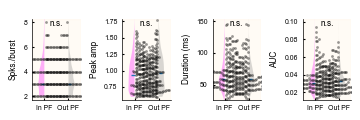

Quiet Spks./burst (all bursts, Mann-Whitney U): n_in=1088, n_out=1062, p=0.000994
Quiet Peak amp (all bursts, Mann-Whitney U): n_in=1088, n_out=1062, p=8.16e-06
Quiet Duration (ms) (all bursts, Mann-Whitney U): n_in=1088, n_out=1062, p=0.575
Quiet AUC (all bursts, Mann-Whitney U): n_in=1088, n_out=1062, p=0.000138
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/ComplexBurstMetrics_AllBursts_CSplus_rest.svg


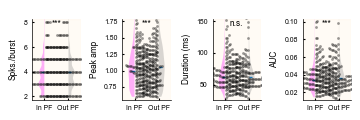

In [353]:
# Complex burst (CB) metrics violin plots - ALL individual bursts pooled (CS+ PLCs)
# Each dot = one burst (not cell average)

from scipy import stats as scipy_stats

min_bursts_per_condition = 3
cs_plc_bg_color = globals().get('cs_plc_bg', '#f3c6df')

burst_metric_specs = [
    ('n_spikes', 'Spks./burst'),
    ('peak_amp', 'Peak amp'),
    ('duration_ms', 'Duration (ms)'),
    ('auc', 'AUC'),
]

# Collect all individual burst values (not averaged)
burst_data_all = {metric: {cond: [] for cond in conditions} for metric, _ in burst_metric_specs}

for cell in plcs_csplus:
    bm = cell.get('burst_metrics')
    complex_by_cond = bm.get('complex') if isinstance(bm, dict) else None
    for cond in conditions:
        bursts = []
        if isinstance(complex_by_cond, dict):
            bursts = complex_by_cond.get(cond, [])
        if not isinstance(bursts, (list, tuple)):
            bursts = []
        for b in bursts:
            if not isinstance(b, dict):
                continue
            for metric_key, _ in burst_metric_specs:
                val = b.get(metric_key, np.nan)
                try:
                    val = float(val)
                except (TypeError, ValueError):
                    val = np.nan
                if np.isfinite(val):
                    burst_data_all[metric_key][cond].append(val)

# Print counts
for metric_key, label in burst_metric_specs:
    for cond in conditions:
        print(f"  {label} {cond}: {len(burst_data_all[metric_key][cond])} bursts")

# Compute global y limits across all conditions
burst_ylim = {}
for metric, _ in burst_metric_specs:
    all_vals = [np.asarray(burst_data_all[metric][cond], dtype=float) for cond in conditions]
    burst_ylim[metric] = _global_ylim(all_vals, pct_low=1, pct_high=99)

def _unpaired_test_bursts(d1, d2):
    """Unpaired test for individual burst data."""
    d1 = np.asarray(d1, dtype=float)
    d2 = np.asarray(d2, dtype=float)
    d1 = d1[np.isfinite(d1)]
    d2 = d2[np.isfinite(d2)]
    if len(d1) < 3 or len(d2) < 3:
        return np.nan, 'N/A'
    if min(len(d1), len(d2)) < 5:
        _, p = scipy_stats.mannwhitneyu(d1, d2, alternative='two-sided')
        return p, 'Mann-Whitney U'
    try:
        sp1 = scipy_stats.shapiro(d1[:min(len(d1), 5000)]).pvalue
    except ValueError:
        sp1 = np.nan
    try:
        sp2 = scipy_stats.shapiro(d2[:min(len(d2), 5000)]).pvalue
    except ValueError:
        sp2 = np.nan
    if (np.isfinite(sp1) and sp1 > 0.05) and (np.isfinite(sp2) and sp2 > 0.05):
        _, p = scipy_stats.ttest_ind(d1, d2)
        return p, 'Unpaired t-test'
    else:
        _, p = scipy_stats.mannwhitneyu(d1, d2, alternative='two-sided')
        return p, 'Mann-Whitney U'

panel_w = 0.9
panel_h = 1.2

state_specs = [
    ('run', 'Locomotion'),
    ('rest', 'Quiet'),
]

for state_key, state_label in state_specs:
    n_panels = len(burst_metric_specs)
    fig, axes = plt.subplots(1, n_panels, figsize=(panel_w * n_panels, panel_h), sharex=True, sharey=False)
    conds = [f"{state_key}_in", f"{state_key}_out"]
    condition_labels = ['In PF', 'Out PF']

    for ax, (metric_key, ylabel) in zip(axes, burst_metric_specs):
        ax.axvspan(0.5, 2.5, alpha=0.3, color=cs_plc_bg_color, zorder=0)

        vals_in = np.asarray(burst_data_all[metric_key][conds[0]], dtype=float)
        vals_out = np.asarray(burst_data_all[metric_key][conds[1]], dtype=float)

        plot_data = []
        for vals in [vals_in, vals_out]:
            finite = vals[np.isfinite(vals)]
            if finite.size == 0:
                finite = np.array([np.nan])
            plot_data.append(finite)

        positions = [1, 2]
        colors = ['magenta', 'gray']
        alphas = [0.3, 0.3]

        if any(len(arr) < 2 for arr in plot_data):
            print(f"{state_label} {ylabel}: not enough data")
            ax.axis('off')
            continue

        # Half-violin style
        half_sides = ['left', 'right']
        rng = np.random.default_rng(0)
        for idx, (pos, d, color, alpha, side) in enumerate(zip(positions, plot_data, colors, alphas, half_sides)):
            vp = ax.violinplot([d], positions=[pos], showmedians=True, showextrema=False)
            body = vp['bodies'][0]
            verts = body.get_paths()[0].vertices
            if side == 'left':
                verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
            else:
                verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
            body.set_facecolor(color)
            body.set_edgecolor('none')
            body.set_alpha(alpha)
            if 'cmedians' in vp:
                segs = vp['cmedians'].get_segments()
                if len(segs) > 0:
                    seg = segs[0].copy()
                    if side == 'left':
                        seg[:, 0] = np.clip(seg[:, 0], -np.inf, pos)
                    else:
                        seg[:, 0] = np.clip(seg[:, 0], pos, np.inf)
                    vp['cmedians'].set_segments([seg])
                vp['cmedians'].set_color('#1F77B4')
                vp['cmedians'].set_linewidth(1.0)
            # Scatter individual bursts on inner side (subsample if too many)
            finite_mask = np.isfinite(d)
            n_finite = np.sum(finite_mask)
            if n_finite > 0:
                d_finite = d[finite_mask]
                max_dots = 200
                if n_finite > max_dots:
                    idx_sub = rng.choice(n_finite, max_dots, replace=False)
                    d_plot = d_finite[idx_sub]
                else:
                    d_plot = d_finite
                # Beeswarm layout
                y_range = np.ptp(d_plot) if len(d_plot) > 1 else 1.0
                y_spacing = y_range * 0.04
                x_step = 0.06
                sorted_idx = np.argsort(d_plot)
                xs_bee = np.zeros(len(d_plot))
                for si, oi in enumerate(sorted_idx):
                    layer = 0
                    while True:
                        candidate = x_step * layer
                        conflict = False
                        for sj in range(si):
                            oj = sorted_idx[sj]
                            if abs(d_plot[oi] - d_plot[oj]) < y_spacing:
                                if abs(candidate - xs_bee[oj]) < x_step * 0.9:
                                    conflict = True
                                    break
                        if not conflict:
                            xs_bee[oi] = candidate
                            break
                        layer += 1
                if side == 'left':
                    xs = pos + 0.05 + xs_bee
                else:
                    xs = pos - 0.05 - xs_bee
                ax.scatter(xs, d_plot, s=4, color='black', alpha=0.4, linewidths=0, zorder=3)

        # Unpaired test (individual bursts are not paired)
        p_val, test_name = _unpaired_test_bursts(vals_in, vals_out)
        sig_label = _sig_label(p_val)
        print(f"{state_label} {ylabel} (all bursts, {test_name}): n_in={len(vals_in)}, n_out={len(vals_out)}, p={p_val:.3g}")

        if sig_label:
            ax.text(1.5, 0.99, sig_label, ha='center', va='top',
                    fontsize=6, fontname='Arial', transform=ax.get_xaxis_transform())

        ax.set_xticks([1, 2])
        ax.set_xticklabels(condition_labels, fontsize=5, fontname='Arial')
        ax.set_xlim(0.5, 2.5)
        ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
        ax.tick_params(labelsize=5)
        ylim = burst_ylim.get(metric_key)
        if ylim is not None:
            ax.set_ylim(*ylim)
        for label in list(ax.get_yticklabels()):
            label.set_fontname('Arial')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    out_path = os.path.join(figure_save_folder, f"ComplexBurstMetrics_AllBursts_CSplus_{state_key}.svg")
    fig.savefig(out_path, dpi=300)
    print(f"Saved to {out_path}")
    plt.show()


Spks/burst0.0252, p=0.9449, n=10
Spks/burst-0.3201, p=0.3673, n=10
Peak amp0.2263, p=0.5295, n=10
Peak amp-0.3465, p=0.3267, n=10
Duration (ms)-0.3359, p=0.3427, n=10
Duration (ms)-0.1048, p=0.7733, n=10
AUC0.0717, p=0.8439, n=10
AUC-0.2683, p=0.4536, n=10
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/CBrate_correlations_CSplus_InOut.svg


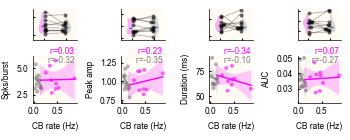

In [354]:
# Correlation between CB rate and burst metrics (spikes/burst, peak amp, duration, AUC)
# Separated by In PF vs Out PF
# With violin plots in the top row

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

# Use the CS+ color scheme from notebook
cs_bg_corr = globals().get('cs_plc_bg', '#f3c6df')

# Colors for In PF and Out PF
in_pf_color = 'magenta'
out_pf_color = 'gray'

def _sig_stars(p_val):
    """Convert p-value to significance stars."""
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001:
        return '***'
    if p_val < 0.01:
        return '**'
    if p_val < 0.05:
        return '*'
    return ''

def _paired_test_local(vals_in, vals_out, alpha=0.05):
    """Paired test with normality check on within-pair differences."""
    vals_in = np.asarray(vals_in, dtype=float)
    vals_out = np.asarray(vals_out, dtype=float)
    n_pairs = min(len(vals_in), len(vals_out))
    if n_pairs == 0:
        return np.nan, np.nan, 'n/a', 0, np.nan
    paired_in = vals_in[:n_pairs]
    paired_out = vals_out[:n_pairs]
    valid = np.isfinite(paired_in) & np.isfinite(paired_out)
    n_valid = int(np.sum(valid))
    if n_valid < 3:
        return np.nan, np.nan, 'n/a', n_valid, np.nan
    diffs = paired_in[valid] - paired_out[valid]
    try:
        shapiro_p = scipy_stats.shapiro(diffs).pvalue
    except ValueError:
        shapiro_p = np.nan
    if n_valid < 5:
        try:
            res = scipy_stats.wilcoxon(paired_in[valid], paired_out[valid])
            return res.pvalue, res.statistic, 'wilcoxon', n_valid, shapiro_p
        except ValueError:
            return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p
    if np.isfinite(shapiro_p) and shapiro_p >= alpha:
        res = scipy_stats.ttest_rel(paired_in[valid], paired_out[valid], nan_policy='omit')
        return res.pvalue, res.statistic, 'paired t-test', n_valid, shapiro_p
    try:
        res = scipy_stats.wilcoxon(paired_in[valid], paired_out[valid])
        return res.pvalue, res.statistic, 'wilcoxon', n_valid, shapiro_p
    except ValueError:
        return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p

def _confidence_interval(x, y, x_pred, confidence=0.95):
    """Calculate 95% confidence interval for regression line."""
    n = len(x)
    if n < 3:
        return np.full_like(x_pred, np.nan), np.full_like(x_pred, np.nan)
    
    # Regression
    slope, intercept, r, p, se = scipy_stats.linregress(x, y)
    y_pred = slope * x_pred + intercept
    
    # Residuals and standard error
    y_fit = slope * x + intercept
    residuals = y - y_fit
    s_err = np.sqrt(np.sum(residuals**2) / (n - 2))  # Standard error of estimate
    
    # Mean of x and sum of squared deviations
    x_mean = np.mean(x)
    ss_x = np.sum((x - x_mean)**2)
    
    # t-value for confidence interval
    t_val = scipy_stats.t.ppf((1 + confidence) / 2, n - 2)
    
    # Confidence interval for each predicted point
    ci = t_val * s_err * np.sqrt(1/n + (x_pred - x_mean)**2 / ss_x)
    
    return y_pred - ci, y_pred + ci

# Metrics to correlate with CB rate
corr_metrics = [
    ('n_spikes', 'Spks/burst'),
    ('peak_amp', 'Peak amp'),
    ('duration_ms', 'Duration (ms)'),
    ('auc', 'AUC'),
]

# Get data for In PF (run_in) and Out PF (run_out) separately
cb_rate_in = np.asarray(metric_data['complex']['burst_rate_hz']['run_in'], dtype=float)
cb_rate_out = np.asarray(metric_data['complex']['burst_rate_hz']['run_out'], dtype=float)

# Create 2x4 figure: top row = violin plots, bottom row = correlation plots
fig, axes = plt.subplots(2, 4, figsize=(3.5, 1.4), gridspec_kw={'height_ratios': [2, 3]})

# Share y-axis within each column
for col_idx in range(4):
    axes[0, col_idx].sharey(axes[1, col_idx])

# Get pair mask for violin plots (cells with enough bursts in both conditions)
conds_run = ['run_in', 'run_out']
counts_in = np.asarray(cond_counts['complex'][conds_run[0]], dtype=float)
counts_out = np.asarray(cond_counts['complex'][conds_run[1]], dtype=float)
pair_mask = (counts_in >= min_bursts_per_condition) & (counts_out >= min_bursts_per_condition)

# Top row: Violin plots
for col_idx, (metric_key, ylabel) in enumerate(corr_metrics):
    ax = axes[0, col_idx]
    ax.axvspan(0.5, 2.5, alpha=0.3, color=cs_bg_corr, zorder=0)
    
    vals_in = np.asarray(metric_data['complex'][metric_key]['run_in'], dtype=float)
    vals_out = np.asarray(metric_data['complex'][metric_key]['run_out'], dtype=float)
    
    if pair_mask.size > 0:
        vals_in = vals_in[pair_mask]
        vals_out = vals_out[pair_mask]
    else:
        vals_in = np.array([], dtype=float)
        vals_out = np.array([], dtype=float)
    
    plot_data = []
    for vals in [vals_in, vals_out]:
        finite = vals[np.isfinite(vals)]
        if finite.size == 0:
            finite = np.array([np.nan])
        plot_data.append(finite)
    
    if any(len(arr) < 2 for arr in plot_data):
        ax.axis('off')
        continue
    
    # Half-violin style
    half_sides = ['left', 'right']
    rng = np.random.default_rng(0)
    for idx, (pos, d, color, side) in enumerate(zip([1, 2], plot_data, [in_pf_color, out_pf_color], half_sides)):
        vp = ax.violinplot([d], positions=[pos], showmedians=True, showextrema=False)
        body = vp['bodies'][0]
        verts = body.get_paths()[0].vertices
        if side == 'left':
            verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
        else:
            verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
        body.set_facecolor(color)
        body.set_edgecolor('none')
        body.set_alpha(0.3)
        if 'cmedians' in vp:
            segs = vp['cmedians'].get_segments()
            if len(segs) > 0:
                seg = segs[0].copy()
                if side == 'left':
                    seg[:, 0] = np.clip(seg[:, 0], -np.inf, pos)
                else:
                    seg[:, 0] = np.clip(seg[:, 0], pos, np.inf)
                vp['cmedians'].set_segments([seg])
            vp['cmedians'].set_color('#1F77B4')
            vp['cmedians'].set_linewidth(1.0)
        finite_mask = np.isfinite(d)
        if np.any(finite_mask):
            d_finite = d[finite_mask]
            # Beeswarm layout: stack dots to avoid overlap
            y_range = np.ptp(d_finite) if len(d_finite) > 1 else 1.0
            y_spacing = y_range * 0.04  # vertical proximity threshold
            x_step = 0.06                # horizontal step per layer
            sorted_idx = np.argsort(d_finite)
            xs_bee = np.zeros(len(d_finite))
            for si, oi in enumerate(sorted_idx):
                layer = 0
                while True:
                    candidate = x_step * layer
                    conflict = False
                    for sj in range(si):
                        oj = sorted_idx[sj]
                        if abs(d_finite[oi] - d_finite[oj]) < y_spacing:
                            if abs(candidate - xs_bee[oj]) < x_step * 0.9:
                                conflict = True
                                break
                    if not conflict:
                        xs_bee[oi] = candidate
                        break
                    layer += 1
            if side == 'left':
                xs = pos + 0.05 + xs_bee
            else:
                xs = pos - 0.05 - xs_bee
            ax.scatter(xs, d_finite, s=8, color='black', alpha=0.6, linewidths=0, zorder=3)
    
    # Paired lines on inner side
    n_pairs = min(len(vals_in), len(vals_out))
    for i in range(n_pairs):
        if np.isfinite(vals_in[i]) and np.isfinite(vals_out[i]):
            ax.plot([1.12, 1.88], [vals_in[i], vals_out[i]], color='black', alpha=0.3, linewidth=0.6, zorder=2)
    
    # Paired test and significance
    p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test_local(vals_in, vals_out)
    sig_label = _sig_stars(p_val)
    if sig_label:
        ax.text(1.5, 1.05, sig_label, ha='center', va='top', fontsize=6, fontname='Arial',
                transform=ax.get_xaxis_transform())
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['', ''])  # Remove xticklabels
    ax.set_xlim(0.5, 2.5)
    ax.tick_params(labelsize=5, labelleft=False)  # Hide y-tick labels for top row
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Bottom row: Correlation plots
for col_idx, (metric_key, ylabel) in enumerate(corr_metrics):
    ax = axes[1, col_idx]
    
    # Get metric data for In PF and Out PF
    metric_in = np.asarray(metric_data['complex'][metric_key]['run_in'], dtype=float)
    metric_out = np.asarray(metric_data['complex'][metric_key]['run_out'], dtype=float)
    
    # Valid pairs for In PF
    valid_in = np.isfinite(cb_rate_in) & np.isfinite(metric_in)
    x_in = cb_rate_in[valid_in]
    y_in = metric_in[valid_in]
    
    # Valid pairs for Out PF
    valid_out = np.isfinite(cb_rate_out) & np.isfinite(metric_out)
    x_out = cb_rate_out[valid_out]
    y_out = metric_out[valid_out]
    
    # Set x-limits based on data range with small padding
    all_x = np.concatenate([x_in, x_out]) if len(x_in) > 0 and len(x_out) > 0 else (x_in if len(x_in) > 0 else x_out)
    if len(all_x) > 0:
        x_min, x_max = all_x.min(), all_x.max()
        x_pad = (x_max - x_min) * 0.05
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
    
    # Add background after setting xlim
    ax.axvspan(ax.get_xlim()[0], ax.get_xlim()[1], alpha=0.3, color=cs_bg_corr, zorder=0)
    
    # Scatter plots
    ax.scatter(x_in, y_in, c=in_pf_color, s=8, alpha=0.6, edgecolors='none', label='In PF')
    ax.scatter(x_out, y_out, c=out_pf_color, s=8, alpha=0.6, edgecolors='none', label='Out PF')
    
    # In PF correlation, fitted line, and confidence interval (independent x range)
    if len(x_in) >= 3:
        x_line_in = np.linspace(x_in.min(), x_in.max(), 100)
        slope_in, intercept_in, r_in, p_in, _ = scipy_stats.linregress(x_in, y_in)
        y_line_in = slope_in * x_line_in + intercept_in
        ci_low_in, ci_high_in = _confidence_interval(x_in, y_in, x_line_in)
        ax.plot(x_line_in, y_line_in, color=in_pf_color, linewidth=1, linestyle='-')
        ax.fill_between(x_line_in, ci_low_in, ci_high_in, color=in_pf_color, alpha=0.2, edgecolor='none')
        sig_in = _sig_stars(p_in)
        print(f"{ylabel}{r_in:.4f}, p={p_in:.4g}, n={len(x_in)}")
    else:
        r_in, sig_in = np.nan, ''
    
    # Out PF correlation, fitted line, and confidence interval (independent x range)
    if len(x_out) >= 3:
        x_line_out = np.linspace(x_out.min(), x_out.max(), 100)
        slope_out, intercept_out, r_out, p_out, _ = scipy_stats.linregress(x_out, y_out)
        y_line_out = slope_out * x_line_out + intercept_out
        ci_low_out, ci_high_out = _confidence_interval(x_out, y_out, x_line_out)
        ax.plot(x_line_out, y_line_out, color=out_pf_color, linewidth=1, linestyle='-')
        ax.fill_between(x_line_out, ci_low_out, ci_high_out, color=out_pf_color, alpha=0.2, edgecolor='none')
        sig_out = _sig_stars(p_out)
        print(f"{ylabel}{r_out:.4f}, p={p_out:.4g}, n={len(x_out)}")
    else:
        r_out, sig_out = np.nan, ''
    
    # Correlation text at bottom right - In PF on top, Out PF below
    text_in = f'r={r_in:.2f} {sig_in}' if np.isfinite(r_in) else ''
    text_out = f'r={r_out:.2f} {sig_out}' if np.isfinite(r_out) else ''
    
    # Position text in bottom right
    y_text_pos = 0.8
    x_text_pos = 1
    if text_out:
        ax.text(x_text_pos, y_text_pos, text_out, ha='right', va='bottom', transform=ax.transAxes,
                fontsize=6, fontname='Arial', color=out_pf_color)
        y_text_pos += 0.2
    if text_in:
        ax.text(x_text_pos, y_text_pos, text_in, ha='right', va='bottom', transform=ax.transAxes,
                fontsize=6, fontname='Arial', color=in_pf_color)
    
    # Labels - only ylabel at bottom row
    ax.set_xlabel('CB rate (Hz)', fontsize=6, fontname='Arial')
    ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
    ax.tick_params(labelsize=6)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Arial')
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)  # Reduce vertical gap between rows

# Save figure
out_path = os.path.join(figure_save_folder, "CBrate_correlations_CSplus_InOut.svg")
fig.savefig(out_path, dpi=300)
print(f"Saved to {out_path}")
plt.show()

Spks/burst In PF: r=0.0252, p=0.9449, n=10
Spks/burst Out PF: r=-0.3201, p=0.3673, n=10
Peak amp In PF: r=0.2263, p=0.5295, n=10
Peak amp Out PF: r=-0.3465, p=0.3267, n=10
Duration (ms) In PF: r=-0.3359, p=0.3427, n=10
Duration (ms) Out PF: r=-0.1048, p=0.7733, n=10
AUC In PF: r=0.0717, p=0.8439, n=10
AUC Out PF: r=-0.2683, p=0.4536, n=10
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/CBrate_correlations_CSplus_InOut_alt.svg


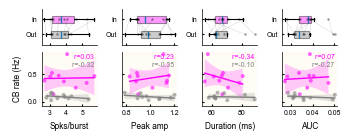

In [355]:
# Alternative: CB metrics (x) vs CB rate (y), with horizontal half-violins on top
# Top and bottom share x-axis per column

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

cs_bg_corr = globals().get('cs_plc_bg', '#f3c6df')
in_pf_color = 'magenta'
out_pf_color = 'gray'

def _sig_stars(p_val):
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001: return '***'
    if p_val < 0.01: return '**'
    if p_val < 0.05: return '*'
    return ''

def _paired_test_local(vals_in, vals_out, alpha=0.05):
    vals_in = np.asarray(vals_in, dtype=float)
    vals_out = np.asarray(vals_out, dtype=float)
    n_pairs = min(len(vals_in), len(vals_out))
    if n_pairs == 0:
        return np.nan, np.nan, 'n/a', 0, np.nan
    paired_in = vals_in[:n_pairs]
    paired_out = vals_out[:n_pairs]
    valid = np.isfinite(paired_in) & np.isfinite(paired_out)
    n_valid = int(np.sum(valid))
    if n_valid < 3:
        return np.nan, np.nan, 'n/a', n_valid, np.nan
    diffs = paired_in[valid] - paired_out[valid]
    try:
        shapiro_p = scipy_stats.shapiro(diffs).pvalue
    except ValueError:
        shapiro_p = np.nan
    if n_valid < 5:
        try:
            res = scipy_stats.wilcoxon(paired_in[valid], paired_out[valid])
            return res.pvalue, res.statistic, 'wilcoxon', n_valid, shapiro_p
        except ValueError:
            return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p
    if np.isfinite(shapiro_p) and shapiro_p >= alpha:
        res = scipy_stats.ttest_rel(paired_in[valid], paired_out[valid], nan_policy='omit')
        return res.pvalue, res.statistic, 'paired t-test', n_valid, shapiro_p
    try:
        res = scipy_stats.wilcoxon(paired_in[valid], paired_out[valid])
        return res.pvalue, res.statistic, 'wilcoxon', n_valid, shapiro_p
    except ValueError:
        return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p

def _confidence_interval(x, y, x_pred, confidence=0.95):
    n = len(x)
    if n < 3:
        return np.full_like(x_pred, np.nan), np.full_like(x_pred, np.nan)
    slope, intercept, r, p, se = scipy_stats.linregress(x, y)
    y_pred = slope * x_pred + intercept
    y_fit = slope * x + intercept
    residuals = y - y_fit
    s_err = np.sqrt(np.sum(residuals**2) / (n - 2))
    x_mean = np.mean(x)
    ss_x = np.sum((x - x_mean)**2)
    t_val = scipy_stats.t.ppf((1 + confidence) / 2, n - 2)
    ci = t_val * s_err * np.sqrt(1/n + (x_pred - x_mean)**2 / ss_x)
    return y_pred - ci, y_pred + ci

corr_metrics = [
    ('n_spikes', 'Spks/burst'),
    ('peak_amp', 'Peak amp'),
    ('duration_ms', 'Duration (ms)'),
    ('auc', 'AUC'),
]

cb_rate_in = np.asarray(metric_data['complex']['burst_rate_hz']['run_in'], dtype=float)
cb_rate_out = np.asarray(metric_data['complex']['burst_rate_hz']['run_out'], dtype=float)

fig, axes = plt.subplots(2, 4, figsize=(3.5, 1.4), gridspec_kw={'height_ratios': [2, 3]},
                         sharex=False)

# Share x-axis within each column (metric values)
for col_idx in range(4):
    axes[0, col_idx].sharex(axes[1, col_idx])

# Share y-axis across bottom row (CB rate)
for col_idx in range(1, 4):
    axes[1, col_idx].sharey(axes[1, 0])

conds_run = ['run_in', 'run_out']
counts_in = np.asarray(cond_counts['complex'][conds_run[0]], dtype=float)
counts_out = np.asarray(cond_counts['complex'][conds_run[1]], dtype=float)
pair_mask = (counts_in >= min_bursts_per_condition) & (counts_out >= min_bursts_per_condition)

# Top row: Horizontal box plots (metric on x-axis shared with scatter below)
for col_idx, (metric_key, xlabel) in enumerate(corr_metrics):
    ax = axes[0, col_idx]

    vals_in = np.asarray(metric_data['complex'][metric_key]['run_in'], dtype=float)
    vals_out = np.asarray(metric_data['complex'][metric_key]['run_out'], dtype=float)

    if pair_mask.size > 0:
        vals_in = vals_in[pair_mask]
        vals_out = vals_out[pair_mask]
    else:
        vals_in = np.array([], dtype=float)
        vals_out = np.array([], dtype=float)

    fin_in = vals_in[np.isfinite(vals_in)]
    fin_out = vals_out[np.isfinite(vals_out)]

    if len(fin_in) < 2 and len(fin_out) < 2:
        ax.axis('off')
        continue

    bp = ax.boxplot([fin_out, fin_in], positions=[1, 2], vert=False, widths=0.5,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='#1F77B4', linewidth=1.0),
                    whiskerprops=dict(linewidth=0.8),
                    capprops=dict(linewidth=0.8),
                    boxprops=dict(linewidth=0.8))
    bp['boxes'][0].set_facecolor(out_pf_color)
    bp['boxes'][0].set_alpha(0.4)
    bp['boxes'][1].set_facecolor(in_pf_color)
    bp['boxes'][1].set_alpha(0.4)

    # Paired dots and connecting lines
    n_pairs = min(len(fin_in), len(fin_out))
    for i in range(n_pairs):
        if np.isfinite(fin_in[i]) and np.isfinite(fin_out[i]):
            ax.plot([fin_in[i], fin_out[i]], [2, 1],
                    color='black', alpha=0.2, linewidth=0.3, zorder=2)
    ax.scatter(fin_in, np.full(len(fin_in), 2), s=3, color='black', alpha=0.4, linewidths=0, zorder=3)
    ax.scatter(fin_out, np.full(len(fin_out), 1), s=3, color='black', alpha=0.4, linewidths=0, zorder=3)

    # Paired test
    p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test_local(vals_in, vals_out)
    sig_label = _sig_stars(p_val)
    if sig_label:
        ax.text(0.98, 0.5, sig_label, ha='right', va='center', fontsize=6, fontname='Arial',
                transform=ax.transAxes, rotation=90)

    ax.set_yticks([1, 2])
    ax.set_yticklabels(['Out', 'In'], fontsize=5, fontname='Arial')
    ax.set_ylim(0.3, 2.7)
    ax.tick_params(labelsize=5, labelbottom=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Bottom row: Scatter - metric (x) vs CB rate (y)
for col_idx, (metric_key, xlabel) in enumerate(corr_metrics):
    ax = axes[1, col_idx]

    metric_in = np.asarray(metric_data['complex'][metric_key]['run_in'], dtype=float)
    metric_out = np.asarray(metric_data['complex'][metric_key]['run_out'], dtype=float)

    valid_in = np.isfinite(cb_rate_in) & np.isfinite(metric_in)
    x_in = metric_in[valid_in]
    y_in = cb_rate_in[valid_in]

    valid_out = np.isfinite(cb_rate_out) & np.isfinite(metric_out)
    x_out = metric_out[valid_out]
    y_out = cb_rate_out[valid_out]

    all_x = np.concatenate([x_in, x_out]) if len(x_in) > 0 and len(x_out) > 0 else (x_in if len(x_in) > 0 else x_out)
    if len(all_x) > 0:
        x_min, x_max = all_x.min(), all_x.max()
        x_pad = (x_max - x_min) * 0.05
        ax.set_xlim(x_min - x_pad, x_max + x_pad)

    ax.axvspan(ax.get_xlim()[0], ax.get_xlim()[1], alpha=0.3, color=cs_bg_corr, zorder=0)

    ax.scatter(x_in, y_in, c=in_pf_color, s=8, alpha=0.6, edgecolors='none', label='In PF')
    ax.scatter(x_out, y_out, c=out_pf_color, s=8, alpha=0.6, edgecolors='none', label='Out PF')

    if len(x_in) >= 3:
        x_line_in = np.linspace(x_in.min(), x_in.max(), 100)
        slope_in, intercept_in, r_in, p_in, _ = scipy_stats.linregress(x_in, y_in)
        y_line_in = slope_in * x_line_in + intercept_in
        ci_low_in, ci_high_in = _confidence_interval(x_in, y_in, x_line_in)
        ax.plot(x_line_in, y_line_in, color=in_pf_color, linewidth=1, linestyle='-')
        ax.fill_between(x_line_in, ci_low_in, ci_high_in, color=in_pf_color, alpha=0.2, edgecolor='none')
        sig_in = _sig_stars(p_in)
        print(f"{xlabel} In PF: r={r_in:.4f}, p={p_in:.4g}, n={len(x_in)}")
    else:
        r_in, sig_in = np.nan, ''

    if len(x_out) >= 3:
        x_line_out = np.linspace(x_out.min(), x_out.max(), 100)
        slope_out, intercept_out, r_out, p_out, _ = scipy_stats.linregress(x_out, y_out)
        y_line_out = slope_out * x_line_out + intercept_out
        ci_low_out, ci_high_out = _confidence_interval(x_out, y_out, x_line_out)
        ax.plot(x_line_out, y_line_out, color=out_pf_color, linewidth=1, linestyle='-')
        ax.fill_between(x_line_out, ci_low_out, ci_high_out, color=out_pf_color, alpha=0.2, edgecolor='none')
        sig_out = _sig_stars(p_out)
        print(f"{xlabel} Out PF: r={r_out:.4f}, p={p_out:.4g}, n={len(x_out)}")
    else:
        r_out, sig_out = np.nan, ''

    text_in = f'r={r_in:.2f} {sig_in}' if np.isfinite(r_in) else ''
    text_out = f'r={r_out:.2f} {sig_out}' if np.isfinite(r_out) else ''
    y_text_pos = 0.95
    if text_in:
        ax.text(0.98, y_text_pos, text_in, ha='right', va='top', transform=ax.transAxes,
                fontsize=5, fontname='Arial', color=in_pf_color)
        y_text_pos -= 0.15
    if text_out:
        ax.text(0.98, y_text_pos, text_out, ha='right', va='top', transform=ax.transAxes,
                fontsize=5, fontname='Arial', color=out_pf_color)

    ax.set_xlabel(xlabel, fontsize=6, fontname='Arial')
    if col_idx == 0:
        ax.set_ylabel('CB rate (Hz)', fontsize=6, fontname='Arial')
    else:
        ax.tick_params(labelleft=False)
        ax.set_ylabel('')
    ax.tick_params(labelsize=5)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Arial')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.15)

out_path = os.path.join(figure_save_folder, "CBrate_correlations_CSplus_InOut_alt.svg")
fig.savefig(out_path, dpi=300)
print(f"Saved to {out_path}")
plt.show()


Spks/burst In PF: r=0.3569, p=0.3113, n=10
Spks/burst Out PF: r=0.1172, p=0.7472, n=10
Peak amp In PF: r=0.1605, p=0.6579, n=10
Peak amp Out PF: r=0.0632, p=0.8622, n=10
Duration (ms) In PF: r=0.1637, p=0.6514, n=10
Duration (ms) Out PF: r=-0.4661, p=0.1746, n=10
AUC In PF: r=0.3656, p=0.2988, n=10
AUC Out PF: r=-0.1874, p=0.6041, n=10
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/CBrate_correlations_CSplus_InOut_alt_rest.svg


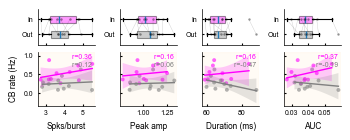

In [356]:
# Alternative: CB metrics (x) vs CB rate (y), with horizontal half-violins on top
# Top and bottom share x-axis per column

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

cs_bg_corr = globals().get('cs_plc_bg', '#f3c6df')
in_pf_color = 'magenta'
out_pf_color = 'gray'

def _sig_stars(p_val):
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001: return '***'
    if p_val < 0.01: return '**'
    if p_val < 0.05: return '*'
    return ''

def _paired_test_local(vals_in, vals_out, alpha=0.05):
    vals_in = np.asarray(vals_in, dtype=float)
    vals_out = np.asarray(vals_out, dtype=float)
    n_pairs = min(len(vals_in), len(vals_out))
    if n_pairs == 0:
        return np.nan, np.nan, 'n/a', 0, np.nan
    paired_in = vals_in[:n_pairs]
    paired_out = vals_out[:n_pairs]
    valid = np.isfinite(paired_in) & np.isfinite(paired_out)
    n_valid = int(np.sum(valid))
    if n_valid < 3:
        return np.nan, np.nan, 'n/a', n_valid, np.nan
    diffs = paired_in[valid] - paired_out[valid]
    try:
        shapiro_p = scipy_stats.shapiro(diffs).pvalue
    except ValueError:
        shapiro_p = np.nan
    if n_valid < 5:
        try:
            res = scipy_stats.wilcoxon(paired_in[valid], paired_out[valid])
            return res.pvalue, res.statistic, 'wilcoxon', n_valid, shapiro_p
        except ValueError:
            return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p
    if np.isfinite(shapiro_p) and shapiro_p >= alpha:
        res = scipy_stats.ttest_rel(paired_in[valid], paired_out[valid], nan_policy='omit')
        return res.pvalue, res.statistic, 'paired t-test', n_valid, shapiro_p
    try:
        res = scipy_stats.wilcoxon(paired_in[valid], paired_out[valid])
        return res.pvalue, res.statistic, 'wilcoxon', n_valid, shapiro_p
    except ValueError:
        return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p

def _confidence_interval(x, y, x_pred, confidence=0.95):
    n = len(x)
    if n < 3:
        return np.full_like(x_pred, np.nan), np.full_like(x_pred, np.nan)
    slope, intercept, r, p, se = scipy_stats.linregress(x, y)
    y_pred = slope * x_pred + intercept
    y_fit = slope * x + intercept
    residuals = y - y_fit
    s_err = np.sqrt(np.sum(residuals**2) / (n - 2))
    x_mean = np.mean(x)
    ss_x = np.sum((x - x_mean)**2)
    t_val = scipy_stats.t.ppf((1 + confidence) / 2, n - 2)
    ci = t_val * s_err * np.sqrt(1/n + (x_pred - x_mean)**2 / ss_x)
    return y_pred - ci, y_pred + ci

corr_metrics = [
    ('n_spikes', 'Spks/burst'),
    ('peak_amp', 'Peak amp'),
    ('duration_ms', 'Duration (ms)'),
    ('auc', 'AUC'),
]

cb_rate_in = np.asarray(metric_data['complex']['burst_rate_hz']['rest_in'], dtype=float)
cb_rate_out = np.asarray(metric_data['complex']['burst_rate_hz']['rest_out'], dtype=float)

fig, axes = plt.subplots(2, 4, figsize=(3.5, 1.4), gridspec_kw={'height_ratios': [2, 3]},
                         sharex=False)

# Share x-axis within each column (metric values)
for col_idx in range(4):
    axes[0, col_idx].sharex(axes[1, col_idx])

# Share y-axis across bottom row (CB rate)
for col_idx in range(1, 4):
    axes[1, col_idx].sharey(axes[1, 0])

conds_run = ['rest_in', 'rest_out']
counts_in = np.asarray(cond_counts['complex'][conds_run[0]], dtype=float)
counts_out = np.asarray(cond_counts['complex'][conds_run[1]], dtype=float)
pair_mask = (counts_in >= min_bursts_per_condition) & (counts_out >= min_bursts_per_condition)

# Top row: Horizontal box plots (metric on x-axis shared with scatter below)
for col_idx, (metric_key, xlabel) in enumerate(corr_metrics):
    ax = axes[0, col_idx]

    vals_in = np.asarray(metric_data['complex'][metric_key]['rest_in'], dtype=float)
    vals_out = np.asarray(metric_data['complex'][metric_key]['rest_out'], dtype=float)

    if pair_mask.size > 0:
        vals_in = vals_in[pair_mask]
        vals_out = vals_out[pair_mask]
    else:
        vals_in = np.array([], dtype=float)
        vals_out = np.array([], dtype=float)

    fin_in = vals_in[np.isfinite(vals_in)]
    fin_out = vals_out[np.isfinite(vals_out)]

    if len(fin_in) < 2 and len(fin_out) < 2:
        ax.axis('off')
        continue

    bp = ax.boxplot([fin_out, fin_in], positions=[1, 2], vert=False, widths=0.5,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='#1F77B4', linewidth=1.0),
                    whiskerprops=dict(linewidth=0.8),
                    capprops=dict(linewidth=0.8),
                    boxprops=dict(linewidth=0.8))
    bp['boxes'][0].set_facecolor(out_pf_color)
    bp['boxes'][0].set_alpha(0.4)
    bp['boxes'][1].set_facecolor(in_pf_color)
    bp['boxes'][1].set_alpha(0.4)

    # Paired dots and connecting lines
    n_pairs = min(len(fin_in), len(fin_out))
    for i in range(n_pairs):
        if np.isfinite(fin_in[i]) and np.isfinite(fin_out[i]):
            ax.plot([fin_in[i], fin_out[i]], [2, 1],
                    color='black', alpha=0.2, linewidth=0.3, zorder=2)
    ax.scatter(fin_in, np.full(len(fin_in), 2), s=3, color='black', alpha=0.4, linewidths=0, zorder=3)
    ax.scatter(fin_out, np.full(len(fin_out), 1), s=3, color='black', alpha=0.4, linewidths=0, zorder=3)

    # Paired test
    p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test_local(vals_in, vals_out)
    sig_label = _sig_stars(p_val)
    if sig_label:
        ax.text(0.98, 0.5, sig_label, ha='right', va='center', fontsize=6, fontname='Arial',
                transform=ax.transAxes, rotation=90)

    ax.set_yticks([1, 2])
    ax.set_yticklabels(['Out', 'In'], fontsize=5, fontname='Arial')
    ax.set_ylim(0.3, 2.7)
    ax.tick_params(labelsize=5, labelbottom=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Bottom row: Scatter - metric (x) vs CB rate (y)
for col_idx, (metric_key, xlabel) in enumerate(corr_metrics):
    ax = axes[1, col_idx]

    metric_in = np.asarray(metric_data['complex'][metric_key]['rest_in'], dtype=float)
    metric_out = np.asarray(metric_data['complex'][metric_key]['rest_out'], dtype=float)

    valid_in = np.isfinite(cb_rate_in) & np.isfinite(metric_in)
    x_in = metric_in[valid_in]
    y_in = cb_rate_in[valid_in]

    valid_out = np.isfinite(cb_rate_out) & np.isfinite(metric_out)
    x_out = metric_out[valid_out]
    y_out = cb_rate_out[valid_out]

    all_x = np.concatenate([x_in, x_out]) if len(x_in) > 0 and len(x_out) > 0 else (x_in if len(x_in) > 0 else x_out)
    if len(all_x) > 0:
        x_min, x_max = all_x.min(), all_x.max()
        x_pad = (x_max - x_min) * 0.05
        ax.set_xlim(x_min - x_pad, x_max + x_pad)

    ax.axvspan(ax.get_xlim()[0], ax.get_xlim()[1], alpha=0.3, color=cs_bg_corr, zorder=0)

    ax.scatter(x_in, y_in, c=in_pf_color, s=8, alpha=0.6, edgecolors='none', label='In PF')
    ax.scatter(x_out, y_out, c=out_pf_color, s=8, alpha=0.6, edgecolors='none', label='Out PF')

    if len(x_in) >= 3:
        x_line_in = np.linspace(x_in.min(), x_in.max(), 100)
        slope_in, intercept_in, r_in, p_in, _ = scipy_stats.linregress(x_in, y_in)
        y_line_in = slope_in * x_line_in + intercept_in
        ci_low_in, ci_high_in = _confidence_interval(x_in, y_in, x_line_in)
        ax.plot(x_line_in, y_line_in, color=in_pf_color, linewidth=1, linestyle='-')
        ax.fill_between(x_line_in, ci_low_in, ci_high_in, color=in_pf_color, alpha=0.2, edgecolor='none')
        sig_in = _sig_stars(p_in)
        print(f"{xlabel} In PF: r={r_in:.4f}, p={p_in:.4g}, n={len(x_in)}")
    else:
        r_in, sig_in = np.nan, ''

    if len(x_out) >= 3:
        x_line_out = np.linspace(x_out.min(), x_out.max(), 100)
        slope_out, intercept_out, r_out, p_out, _ = scipy_stats.linregress(x_out, y_out)
        y_line_out = slope_out * x_line_out + intercept_out
        ci_low_out, ci_high_out = _confidence_interval(x_out, y_out, x_line_out)
        ax.plot(x_line_out, y_line_out, color=out_pf_color, linewidth=1, linestyle='-')
        ax.fill_between(x_line_out, ci_low_out, ci_high_out, color=out_pf_color, alpha=0.2, edgecolor='none')
        sig_out = _sig_stars(p_out)
        print(f"{xlabel} Out PF: r={r_out:.4f}, p={p_out:.4g}, n={len(x_out)}")
    else:
        r_out, sig_out = np.nan, ''

    text_in = f'r={r_in:.2f} {sig_in}' if np.isfinite(r_in) else ''
    text_out = f'r={r_out:.2f} {sig_out}' if np.isfinite(r_out) else ''
    y_text_pos = 0.95
    if text_in:
        ax.text(0.98, y_text_pos, text_in, ha='right', va='top', transform=ax.transAxes,
                fontsize=5, fontname='Arial', color=in_pf_color)
        y_text_pos -= 0.15
    if text_out:
        ax.text(0.98, y_text_pos, text_out, ha='right', va='top', transform=ax.transAxes,
                fontsize=5, fontname='Arial', color=out_pf_color)

    ax.set_xlabel(xlabel, fontsize=6, fontname='Arial')
    if col_idx == 0:
        ax.set_ylabel('CB rate (Hz)', fontsize=6, fontname='Arial')
    else:
        ax.tick_params(labelleft=False)
        ax.set_ylabel('')
    ax.tick_params(labelsize=5)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Arial')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.15)

out_path = os.path.join(figure_save_folder, "CBrate_correlations_CSplus_InOut_alt_rest.svg")
fig.savefig(out_path, dpi=300)
print(f"Saved to {out_path}")
plt.show()


Spks/burst (Quiet) In PF: r=0.3569, p=0.3113, n=10
Spks/burst (Quiet) Out PF: r=0.1172, p=0.7472, n=10
Peak amp (Quiet) In PF: r=0.1605, p=0.6579, n=10
Peak amp (Quiet) Out PF: r=0.0632, p=0.8622, n=10
Duration (ms) (Quiet) In PF: r=0.1637, p=0.6514, n=10
Duration (ms) (Quiet) Out PF: r=-0.4661, p=0.1746, n=10
AUC (Quiet) In PF: r=0.3656, p=0.2988, n=10
AUC (Quiet) Out PF: r=-0.1874, p=0.6041, n=10
Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/CBrate_correlations_CSplus_InOut_Quiet.svg


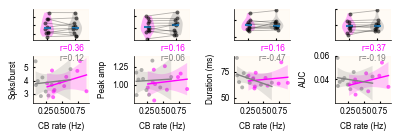

In [357]:
# Correlation between CB rate and burst metrics (spikes/burst, peak amp, duration, AUC)
# Separated by In PF vs Out PF - QUIET CONDITION
# With violin plots in the top row

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

# Use the CS+ color scheme from notebook
cs_bg_corr = globals().get('cs_plc_bg', '#f3c6df')

# Colors for In PF and Out PF
in_pf_color = 'magenta'
out_pf_color = 'gray'

def _sig_stars(p_val):
    """Convert p-value to significance stars."""
    if not np.isfinite(p_val):
        return ''
    if p_val < 0.001:
        return '***'
    if p_val < 0.01:
        return '**'
    if p_val < 0.05:
        return '*'
    return ''

def _paired_test_local(vals_in, vals_out, alpha=0.05):
    """Paired test with normality check on within-pair differences."""
    vals_in = np.asarray(vals_in, dtype=float)
    vals_out = np.asarray(vals_out, dtype=float)
    n_pairs = min(len(vals_in), len(vals_out))
    if n_pairs == 0:
        return np.nan, np.nan, 'n/a', 0, np.nan
    paired_in = vals_in[:n_pairs]
    paired_out = vals_out[:n_pairs]
    valid = np.isfinite(paired_in) & np.isfinite(paired_out)
    n_valid = int(np.sum(valid))
    if n_valid < 3:
        return np.nan, np.nan, 'n/a', n_valid, np.nan
    diffs = paired_in[valid] - paired_out[valid]
    try:
        shapiro_p = scipy_stats.shapiro(diffs).pvalue
    except ValueError:
        shapiro_p = np.nan
    if n_valid < 5:
        try:
            res = scipy_stats.wilcoxon(paired_in[valid], paired_out[valid])
            return res.pvalue, res.statistic, 'wilcoxon', n_valid, shapiro_p
        except ValueError:
            return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p
    if np.isfinite(shapiro_p) and shapiro_p >= alpha:
        res = scipy_stats.ttest_rel(paired_in[valid], paired_out[valid], nan_policy='omit')
        return res.pvalue, res.statistic, 'paired t-test', n_valid, shapiro_p
    try:
        res = scipy_stats.wilcoxon(paired_in[valid], paired_out[valid])
        return res.pvalue, res.statistic, 'wilcoxon', n_valid, shapiro_p
    except ValueError:
        return np.nan, np.nan, 'wilcoxon', n_valid, shapiro_p

def _confidence_interval(x, y, x_pred, confidence=0.95):
    """Calculate 95% confidence interval for regression line."""
    n = len(x)
    if n < 3:
        return np.full_like(x_pred, np.nan), np.full_like(x_pred, np.nan)
    
    # Regression
    slope, intercept, r, p, se = scipy_stats.linregress(x, y)
    y_pred = slope * x_pred + intercept
    
    # Residuals and standard error
    y_fit = slope * x + intercept
    residuals = y - y_fit
    s_err = np.sqrt(np.sum(residuals**2) / (n - 2))  # Standard error of estimate
    
    # Mean of x and sum of squared deviations
    x_mean = np.mean(x)
    ss_x = np.sum((x - x_mean)**2)
    
    # t-value for confidence interval
    t_val = scipy_stats.t.ppf((1 + confidence) / 2, n - 2)
    
    # Confidence interval for each predicted point
    ci = t_val * s_err * np.sqrt(1/n + (x_pred - x_mean)**2 / ss_x)
    
    return y_pred - ci, y_pred + ci

# Metrics to correlate with CB rate
corr_metrics = [
    ('n_spikes', 'Spks/burst'),
    ('peak_amp', 'Peak amp'),
    ('duration_ms', 'Duration (ms)'),
    ('auc', 'AUC'),
]

# Get data for In PF (rest_in) and Out PF (rest_out) separately - QUIET CONDITION
cb_rate_in = np.asarray(metric_data['complex']['burst_rate_hz']['rest_in'], dtype=float)
cb_rate_out = np.asarray(metric_data['complex']['burst_rate_hz']['rest_out'], dtype=float)

# Create 2x4 figure: top row = violin plots, bottom row = correlation plots
fig, axes = plt.subplots(2, 4, figsize=(4, 1.4), gridspec_kw={'height_ratios': [2,3]})

# Share y-axis within each column
for col_idx in range(4):
    axes[0, col_idx].sharey(axes[1, col_idx])

# Get pair mask for violin plots (cells with enough bursts in both conditions)
conds_rest = ['rest_in', 'rest_out']
counts_in = np.asarray(cond_counts['complex'][conds_rest[0]], dtype=float)
counts_out = np.asarray(cond_counts['complex'][conds_rest[1]], dtype=float)
pair_mask = (counts_in >= min_bursts_per_condition) & (counts_out >= min_bursts_per_condition)

# Top row: Violin plots
for col_idx, (metric_key, ylabel) in enumerate(corr_metrics):
    ax = axes[0, col_idx]
    ax.axvspan(0.5, 2.5, alpha=0.3, color=cs_bg_corr, zorder=0)
    
    vals_in = np.asarray(metric_data['complex'][metric_key]['rest_in'], dtype=float)
    vals_out = np.asarray(metric_data['complex'][metric_key]['rest_out'], dtype=float)
    
    if pair_mask.size > 0:
        vals_in = vals_in[pair_mask]
        vals_out = vals_out[pair_mask]
    else:
        vals_in = np.array([], dtype=float)
        vals_out = np.array([], dtype=float)
    
    plot_data = []
    for vals in [vals_in, vals_out]:
        finite = vals[np.isfinite(vals)]
        if finite.size == 0:
            finite = np.array([np.nan])
        plot_data.append(finite)
    
    if any(len(arr) < 2 for arr in plot_data):
        ax.axis('off')
        continue
    
    parts = ax.violinplot(plot_data, positions=[1, 2], showmedians=True, showextrema=False)
    for body, color, alpha in zip(parts['bodies'], [in_pf_color, out_pf_color], [0.3, 0.3]):
        body.set_facecolor(color)
        body.set_edgecolor('none')
        body.set_alpha(alpha)
    
    # Paired lines
    n_pairs = min(len(vals_in), len(vals_out))
    for i in range(n_pairs):
        if np.isfinite(vals_in[i]) and np.isfinite(vals_out[i]):
            ax.plot([1, 2], [vals_in[i], vals_out[i]], color='black', alpha=0.3, linewidth=0.6)
    
    # Scatter points with jitter
    rng = np.random.default_rng(0)
    for pos, vals in zip([1, 2], [vals_in, vals_out]):
        finite_mask = np.isfinite(vals)
        if not np.any(finite_mask):
            continue
        jitter = (rng.random(np.sum(finite_mask)) - 0.5) * 0.12
        xs = pos + jitter
        ax.scatter(xs, vals[finite_mask], s=8, color='black', alpha=0.6, linewidths=0)
    
    # Paired test and significance
    p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test_local(vals_in, vals_out)
    sig_label = _sig_stars(p_val)
    if sig_label:
        ax.text(1.5, 1.05, sig_label, ha='center', va='top', fontsize=6, fontname='Arial',
                transform=ax.get_xaxis_transform())
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['', ''])  # Remove xticklabels
    ax.set_xlim(0.5, 2.5)
    ax.tick_params(labelsize=5, labelleft=False)  # Hide y-tick labels for top row
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Bottom row: Correlation plots
for col_idx, (metric_key, ylabel) in enumerate(corr_metrics):
    ax = axes[1, col_idx]
    
    # Get metric data for In PF and Out PF - QUIET CONDITION
    metric_in = np.asarray(metric_data['complex'][metric_key]['rest_in'], dtype=float)
    metric_out = np.asarray(metric_data['complex'][metric_key]['rest_out'], dtype=float)
    
    # Valid pairs for In PF
    valid_in = np.isfinite(cb_rate_in) & np.isfinite(metric_in)
    x_in = cb_rate_in[valid_in]
    y_in = metric_in[valid_in]
    
    # Valid pairs for Out PF
    valid_out = np.isfinite(cb_rate_out) & np.isfinite(metric_out)
    x_out = cb_rate_out[valid_out]
    y_out = metric_out[valid_out]
    
    # Set x-limits based on data range with small padding
    all_x = np.concatenate([x_in, x_out]) if len(x_in) > 0 and len(x_out) > 0 else (x_in if len(x_in) > 0 else x_out)
    if len(all_x) > 0:
        x_min, x_max = all_x.min(), all_x.max()
        x_pad = (x_max - x_min) * 0.05
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
    
    # Add background after setting xlim
    ax.axvspan(ax.get_xlim()[0], ax.get_xlim()[1], alpha=0.3, color=cs_bg_corr, zorder=0)
    
    # Scatter plots
    ax.scatter(x_in, y_in, c=in_pf_color, s=8, alpha=0.6, edgecolors='none', label='In PF')
    ax.scatter(x_out, y_out, c=out_pf_color, s=8, alpha=0.6, edgecolors='none', label='Out PF')
    
    # In PF correlation, fitted line, and confidence interval (independent x range)
    if len(x_in) >= 3:
        x_line_in = np.linspace(x_in.min(), x_in.max(), 100)
        slope_in, intercept_in, r_in, p_in, _ = scipy_stats.linregress(x_in, y_in)
        y_line_in = slope_in * x_line_in + intercept_in
        ci_low_in, ci_high_in = _confidence_interval(x_in, y_in, x_line_in)
        ax.plot(x_line_in, y_line_in, color=in_pf_color, linewidth=1, linestyle='-')
        ax.fill_between(x_line_in, ci_low_in, ci_high_in, color=in_pf_color, alpha=0.2, edgecolor='none')
        sig_in = _sig_stars(p_in)
        print(f"{ylabel} (Quiet) In PF: r={r_in:.4f}, p={p_in:.4g}, n={len(x_in)}")
    else:
        r_in, sig_in = np.nan, ''
    
    # Out PF correlation, fitted line, and confidence interval (independent x range)
    if len(x_out) >= 3:
        x_line_out = np.linspace(x_out.min(), x_out.max(), 100)
        slope_out, intercept_out, r_out, p_out, _ = scipy_stats.linregress(x_out, y_out)
        y_line_out = slope_out * x_line_out + intercept_out
        ci_low_out, ci_high_out = _confidence_interval(x_out, y_out, x_line_out)
        ax.plot(x_line_out, y_line_out, color=out_pf_color, linewidth=1, linestyle='-')
        ax.fill_between(x_line_out, ci_low_out, ci_high_out, color=out_pf_color, alpha=0.2, edgecolor='none')
        sig_out = _sig_stars(p_out)
        print(f"{ylabel} (Quiet) Out PF: r={r_out:.4f}, p={p_out:.4g}, n={len(x_out)}")
    else:
        r_out, sig_out = np.nan, ''
    
    # Correlation text at bottom right - In PF on top, Out PF below
    text_in = f'r={r_in:.2f} {sig_in}' if np.isfinite(r_in) else ''
    text_out = f'r={r_out:.2f} {sig_out}' if np.isfinite(r_out) else ''
    
    # Position text in bottom right
    y_text_pos = 0.85
    if text_out:
        ax.text(0.95, y_text_pos, text_out, ha='right', va='bottom', transform=ax.transAxes,
                fontsize=6, fontname='Arial', color=out_pf_color)
        y_text_pos += 0.2
    if text_in:
        ax.text(0.95, y_text_pos, text_in, ha='right', va='bottom', transform=ax.transAxes,
                fontsize=6, fontname='Arial', color=in_pf_color)
    
    # Labels - only ylabel at bottom row
    ax.set_xlabel('CB rate (Hz)', fontsize=6, fontname='Arial')
    ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
    ax.tick_params(labelsize=6)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Arial')
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)  # Reduce vertical gap between rows

# Save figure
out_path = os.path.join(figure_save_folder, "CBrate_correlations_CSplus_InOut_Quiet.svg")
fig.savefig(out_path, dpi=300)
print(f"Saved to {out_path}")
plt.show()

In [358]:
# # Complex burst (CB) metrics violin plots - CS- PLCs only
# # Reuses helpers/params defined in the CS+ cell above.

# cells = plcs_csminus
# group_label = "CS- PLCs"
# out_prefix = "ComplexBurstMetrics_CSminus"
# cs_minus_bg_color = globals().get('non_cs_plc_bg', '#E3F2FD')  # light blue (CS-)

# metric_data = {
#     'complex': {metric: {cond: [] for cond in conditions} for metric, _ in metric_specs},
# }
# cond_counts = {
#     'complex': {cond: [] for cond in conditions},
# }

# base_metric_keys = {'n_spikes', 'peak_amp', 'duration_ms', 'auc'}

# for cell in cells:
#     bm = cell.get('burst_metrics')
#     complex_by_cond = bm.get('complex') if isinstance(bm, dict) else None
#     sbrm = cell.get('spike_burst_rate_metrics') if isinstance(cell, dict) else None
#     for cond in conditions:
#         bursts = []
#         if isinstance(complex_by_cond, dict):
#             bursts = complex_by_cond.get(cond, [])
#         if not isinstance(bursts, (list, tuple)):
#             bursts = []

#         cond_counts['complex'][cond].append(int(len(bursts)))

#         for metric_key, _ in metric_specs:
#             if metric_key in base_metric_keys:
#                 vals = []
#                 for b in bursts:
#                     if not isinstance(b, dict):
#                         continue
#                     vals.append(float(b.get(metric_key, np.nan)))
#                 vals = np.asarray(vals, dtype=float)
#                 vals = vals[np.isfinite(vals)]
#                 if vals.size >= int(min_bursts_per_condition):
#                     metric_data['complex'][metric_key][cond].append(float(np.nanmean(vals)))
#                 else:
#                     metric_data['complex'][metric_key][cond].append(np.nan)
#             elif metric_key == 'burst_rate_hz':
#                 val = np.nan
#                 if isinstance(sbrm, dict):
#                     br = sbrm.get('burst_rate')
#                     if isinstance(br, dict):
#                         val = br.get(cond, np.nan)
#                 try:
#                     val = float(val)
#                 except (TypeError, ValueError):
#                     val = np.nan
#                 metric_data['complex'][metric_key][cond].append(val if np.isfinite(val) else np.nan)
#             elif metric_key == 'burst_prob':
#                 val = np.nan
#                 if isinstance(sbrm, dict):
#                     bp = sbrm.get('burst_prob')
#                     if isinstance(bp, dict):
#                         val = bp.get(cond, np.nan)
#                 try:
#                     val = float(val)
#                 except (TypeError, ValueError):
#                     val = np.nan
#                 metric_data['complex'][metric_key][cond].append(val if np.isfinite(val) else np.nan)
#             elif metric_key == 'plateau_pct':
#                 if len(bursts) < int(min_bursts_per_condition):
#                     metric_data['complex'][metric_key][cond].append(np.nan)
#                     continue
#                 durations = []
#                 for b in bursts:
#                     if not isinstance(b, dict):
#                         continue
#                     durations.append(float(b.get('duration_ms', np.nan)))
#                 durations = np.asarray(durations, dtype=float)
#                 durations = durations[np.isfinite(durations)]
#                 if durations.size == 0:
#                     metric_data['complex'][metric_key][cond].append(np.nan)
#                     continue
#                 pct = 100.0 * float(np.sum(durations > float(plateau_threshold_ms))) / float(durations.size)
#                 metric_data['complex'][metric_key][cond].append(pct)
#             else:
#                 metric_data['complex'][metric_key][cond].append(np.nan)

# print(f"{group_label} included: n={len(cells)}")
# for cond in conditions:
#     counts = np.asarray(cond_counts['complex'][cond], dtype=float)
#     print(f"  {cond}: cells with >= {min_bursts_per_condition} bursts = {int(np.sum(counts >= min_bursts_per_condition))}")

# metric_ylim = {}
# for metric, _ in metric_specs:
#     all_vals = []
#     for cond in conditions:
#         all_vals.append(np.asarray(metric_data['complex'][metric][cond], dtype=float))
#     metric_ylim[metric] = _global_ylim(all_vals)
# metric_ylim['burst_prob'] = (0.0, 1.0)
# # Clamp plateau percent y-limits without forcing max=100
# if metric_ylim.get('plateau_pct') is not None:
#     y0, y1 = metric_ylim['plateau_pct']
#     y0 = max(0.0, float(y0)) if np.isfinite(y0) else 0.0
#     y1 = min(100.0, float(y1)) if np.isfinite(y1) else np.nan
#     metric_ylim['plateau_pct'] = (y0, y1) if np.isfinite(y1) and y1 > y0 else (0.0, 100.0)
# else:
#     metric_ylim['plateau_pct'] = (0.0, 100.0)

# for state_key, state_label in state_specs:
#     n_panels = len(metric_specs)
#     fig, axes = plt.subplots(1, n_panels, figsize=(panel_w * n_panels, panel_h), sharex=True, sharey=False)
#     conds = [f"{state_key}_in", f"{state_key}_out"]

#     counts_in_complex = np.asarray(cond_counts['complex'][conds[0]], dtype=float)
#     counts_out_complex = np.asarray(cond_counts['complex'][conds[1]], dtype=float)
#     pair_mask_complex = (
#         (counts_in_complex >= min_bursts_per_condition)
#         & (counts_out_complex >= min_bursts_per_condition)
#     )

#     for ax, (metric_key, ylabel) in zip(axes, metric_specs):
#         ax.axvspan(0.5, 2.5, alpha=0.3, color=cs_minus_bg_color, zorder=0)
#         vals_in = np.asarray(metric_data['complex'][metric_key][conds[0]], dtype=float)
#         vals_out = np.asarray(metric_data['complex'][metric_key][conds[1]], dtype=float)
#         if pair_mask_complex.size > 0:
#             vals_in = vals_in[pair_mask_complex]
#             vals_out = vals_out[pair_mask_complex]
#         else:
#             vals_in = np.array([], dtype=float)
#             vals_out = np.array([], dtype=float)

#         plot_data = []
#         for vals in (vals_in, vals_out):
#             finite = vals[np.isfinite(vals)]
#             if finite.size == 0:
#                 finite = np.array([np.nan])
#             plot_data.append(finite)

#         if any(len(arr) < 2 for arr in plot_data):
#             print(f"{state_label} {ylabel}: not enough data for violinplot")
#             ax.axis('off')
#             continue

#         parts = ax.violinplot(plot_data, positions=[1, 2], showmedians=True, showextrema=False)
#         colors = ['magenta', 'gray']
#         for body, color in zip(parts['bodies'], colors):
#             body.set_facecolor(color)
#             body.set_edgecolor('none')
#             body.set_alpha(0.3)

#         n_pairs = min(len(vals_in), len(vals_out))
#         for i in range(n_pairs):
#             if np.isfinite(vals_in[i]) and np.isfinite(vals_out[i]):
#                 ax.plot([1, 2], [vals_in[i], vals_out[i]], color='black', alpha=0.3, linewidth=0.6)

#         rng = np.random.default_rng(0)
#         for pos, vals in zip([1, 2], [vals_in, vals_out]):
#             finite_mask = np.isfinite(vals)
#             if not np.any(finite_mask):
#                 continue
#             jitter = (rng.random(np.sum(finite_mask)) - 0.5) * 0.12
#             xs = pos + jitter
#             ax.scatter(xs, vals[finite_mask], s=8, color='black', alpha=0.6, linewidths=0)

#         p_val, test_stat, test_name, n_valid, shapiro_p = _paired_test(vals_in, vals_out)
#         sig_label = _sig_label(p_val)
#         if np.isfinite(p_val):
#             print(
#                 f"{state_label} {ylabel} (CS- PLCs, {test_name}): n={n_valid}, "
#                 f"stat={test_stat:.3g}, p={p_val:.3g}, shapiro_p={shapiro_p:.3g}"
#             )
#         else:
#             print(f"{state_label} {ylabel} (CS- PLCs): n={n_valid} (insufficient valid pairs)")

#         if sig_label:
#             ax.text(
#                 1.5,
#                 0.99,
#                 sig_label,
#                 ha='center',
#                 va='top',
#                 fontsize=6,
#                 fontname='Arial',
#                 transform=ax.get_xaxis_transform(),
#             )

#         ax.set_xticks([1, 2])
#         ax.set_xticklabels(condition_labels, fontsize=5, fontname='Arial')
#         ax.set_xlim(0.5, 2.5)
#         ax.set_ylabel(ylabel, fontsize=6, fontname='Arial')
#         ax.tick_params(labelsize=5)
#         ylim = metric_ylim.get(metric_key)
#         if ylim is not None:
#             ax.set_ylim(*ylim)
#         for label in list(ax.get_yticklabels()):
#             label.set_fontname('Arial')
#         ax.spines['top'].set_visible(False)
#         ax.spines['right'].set_visible(False)

#     plt.tight_layout(rect=[0, 0, 1, 0.92])
#     out_path = os.path.join(
#         figure_save_folder,
#         f"{out_prefix}_{state_key}.svg",
#     )
#     fig.savefig(out_path, dpi=300)
#     print(f"Saved to {out_path}")
#     plt.show()


/var/folders/8g/cpkd0cfs4gn915zwbfdfgf9w0000gn/T/ipykernel_67869/1016047901.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


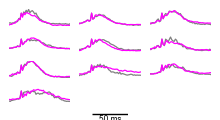

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/cb_shapes_csplus_loco.svg


In [359]:
# ============================================================================
# CB Shapes (loco) for all CS+ place cells
# ============================================================================

import math
import numpy as np
import matplotlib.pyplot as plt

# User toggles
plot_individual = False
normalize = False  # baseline=0 (t<0), peak=1 (t=0)
n_cols = 3
scale_bar_ms = 50.0

def _normalize_wave(time_ms, wave):
    time_ms = np.asarray(time_ms, dtype=float)
    wave = np.asarray(wave, dtype=float)
    if time_ms.size == 0 or wave.size != time_ms.size:
        return None
    pre_mask = time_ms < 0
    if not np.any(pre_mask):
        return None
    baseline = np.nanmean(wave[pre_mask])
    if not np.isfinite(baseline):
        return None
    idx0 = int(np.nanargmin(np.abs(time_ms)))
    if not np.isfinite(wave[idx0]):
        return None
    height = wave[idx0] - baseline
    if not np.isfinite(height) or abs(height) < 1e-12:
        return None
    return (wave - baseline) / height

def _prep_waves(time_ms, waves):
    out = []
    for w in waves:
        w_arr = np.asarray(w, dtype=float)
        if w_arr.size != len(time_ms):
            continue
        if normalize:
            w_n = _normalize_wave(time_ms, w_arr)
            if w_n is None:
                continue
            out.append(w_n)
        else:
            out.append(w_arr)
    return out

def _mean_trace(waves):
    if len(waves) == 0:
        return None
    arr = np.vstack(waves)
    return np.nanmean(arr, axis=0)

# Collect CS+ cells with CB shapes (loco)
csplus_cells = [c for c in plcs_csplus if isinstance(c, dict) and c.get('spike_shapes')]
cells_with_cb = []
for c in csplus_cells:
    info = c.get('spike_shapes', {}).get('complex')
    if not info:
        continue
    shapes = info.get('shapes', {})
    if 'run_in' not in shapes and 'run_out' not in shapes:
        continue
    cells_with_cb.append(c)

n_cells = len(cells_with_cb)
if n_cells == 0:
    print('No CS+ cells with CB loco shapes found')
else:
    n_rows = int(math.ceil(n_cells / n_cols))
    fig_width = 2.2
    fig_height = 1.2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height), squeeze=False)

    # Compute global y-limits from mean traces (keeps plots comparable)
    y_min = np.inf
    y_max = -np.inf
    for c in cells_with_cb:
        info = c['spike_shapes']['complex']
        time_ms = np.asarray(info.get('time_ms', []), dtype=float)
        shapes = info.get('shapes', {})
        in_waves = _prep_waves(time_ms, list(shapes.get('run_in', [])))
        out_waves = _prep_waves(time_ms, list(shapes.get('run_out', [])))
        for waves in (in_waves, out_waves):
            mean = _mean_trace(waves)
            if mean is None:
                continue
            if np.any(np.isfinite(mean)):
                y_min = min(y_min, float(np.nanmin(mean)))
                y_max = max(y_max, float(np.nanmax(mean)))
    if not (np.isfinite(y_min) and np.isfinite(y_max)):
        y_min, y_max = (-0.3, 2) if normalize else (-1.0, 1.0)
    if normalize:
        y_min = max(y_min, -0.3)
        y_max = max(y_max, 1.0)

    for i, c in enumerate(cells_with_cb):
        r, cc = divmod(i, n_cols)
        ax = axes[r][cc]
        ax.axis('off')

        info = c['spike_shapes']['complex']
        time_ms = np.asarray(info.get('time_ms', []), dtype=float)
        shapes = info.get('shapes', {})
        in_waves = _prep_waves(time_ms, list(shapes.get('run_in', [])))
        out_waves = _prep_waves(time_ms, list(shapes.get('run_out', [])))

        if plot_individual:
            for w in in_waves:
                ax.plot(time_ms, w, color='magenta', alpha=0.1, linewidth=0.1)
            for w in out_waves:
                ax.plot(time_ms, w, color='gray', alpha=0.1, linewidth=0.1)

        mean_in = _mean_trace(in_waves)
        mean_out = _mean_trace(out_waves)
        if mean_out is not None:
            ax.plot(time_ms, mean_out, color='gray', linewidth=0.9)
        if mean_in is not None:
            ax.plot(time_ms, mean_in, color='magenta', linewidth=0.9)

        if time_ms.size:
            ax.set_xlim(float(np.nanmin(time_ms)), float(np.nanmax(time_ms)))
        ax.set_ylim(y_min, y_max)

    # Hide unused subplots
    for j in range(n_cells, n_rows * n_cols):
        r, cc = divmod(j, n_cols)
        axes[r][cc].axis('off')

    # One horizontal scale bar at the bottom of the figure
    ax_scale = fig.add_axes([0.42, 0.02, 0.16, 0.06])
    ax_scale.axis('off')
    ax_scale.plot([0, scale_bar_ms], [0, 0], color='black', linewidth=1.0, solid_capstyle='butt')
    ax_scale.set_xlim(0, scale_bar_ms)
    ax_scale.set_ylim(-1, 1)
    ax_scale.text(scale_bar_ms / 2, -0.35, f"{int(scale_bar_ms)} ms", ha='center', va='top', fontsize=6, fontname='Arial')

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()

    # Save figure
    out_path = os.path.join(figure_save_folder, 'cb_shapes_csplus_loco.svg')
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {out_path}')

In [360]:
# ============================================================================
# PSD by Burst Type and State - Configuration
# ============================================================================
# This section plots pooled PSD data by burst type (complex vs non-complex)
# and behavioral state (locomotion vs quiet)

# Configuration flags
cs_plc_only = True  # If True, only include CS+ PLCs; if False, include all cells

# PSD settings
speed_threshold = 3  # Speed threshold used when generating PSD npz files
max_freq = 100  # Maximum frequency to display

# Colors for burst types
complex_color = '#EE9B00'  # orange for complex bursts (same as CS)
simple_color = '#026C80'   # teal for non-complex bursts (same as SS)
non_burst_color = '#888888'  # gray for non-burst periods
plot_non_burst = True  # Whether to plot non-burst PSD

# Normalization option
normalize_psd = True
norm_freq_range = (20, 100)  # Frequency range for normalization

print(f"PSD Configuration:")
print(f"  cs_plc_only: {cs_plc_only}")
print(f"  speed_threshold: {speed_threshold} cm/s")
print(f"  max_freq: {max_freq} Hz")
print(f"  normalize_psd: {normalize_psd}")

PSD Configuration:
  cs_plc_only: True
  speed_threshold: 3 cm/s
  max_freq: 100 Hz
  normalize_psd: True


In [361]:
# Load PSD data from npz files
# Note: When cs_plc_only=True, we filter to only include cells that are CS+ PLCs
# This requires cell_indices to be saved in the npz files (from Figures.ipynb)

pattern = os.path.join(data_folder, 'CKII**', f'psd_burstType_state_speed{speed_threshold}.npz')
npz_files = glob.glob(pattern, recursive=True)
print(f'Found {len(npz_files)} psd_burstType_state files')

# Build set of CS+ PLC (session, cell_idx) for filtering
if cs_plc_only:
    cs_plc_set = set(zip(df_cs_plc['session'], df_cs_plc['cell_idx']))
    print(f"Filtering to {len(cs_plc_set)} CS+ PLCs")
else:
    cs_plc_set = None

# Pool data from all datasets
psd_grand = {
    ('moving', 'complex'): [],
    ('moving', 'simple'): [],
    ('quiet', 'complex'): [],
    ('quiet', 'simple'): [],
    ('moving', 'non_burst'): [],
    ('quiet', 'non_burst'): [],
}
freqs_ref = None
cell_indices_available = False

for npz_path in npz_files:
    data = np.load(npz_path, allow_pickle=True)
    freqs = data['freqs']
    dataset_name = os.path.basename(os.path.dirname(npz_path))
    
    if freqs_ref is None:
        freqs_ref = freqs
    
    # Check if cell_indices are available for filtering
    if 'cell_indices' in data.files:
        cell_indices = data['cell_indices'].item()  # dict of {npz_key: [cell_idx, ...]}
        cell_indices_available = True
    else:
        cell_indices = None
    
    # Load and append per-cell PSDs
    key_map = {
        ('moving', 'complex'): 'psd_moving_complex',
        ('moving', 'simple'): 'psd_moving_simple',
        ('quiet', 'complex'): 'psd_quiet_complex',
        ('quiet', 'simple'): 'psd_quiet_simple',
        ('moving', 'non_burst'): 'psd_moving_nonburst',
        ('quiet', 'non_burst'): 'psd_quiet_nonburst',
    }
    
    cell_counts = {key: 0 for key in key_map.keys()}
    
    for key, npz_key in key_map.items():
        arr = data[npz_key]
        if arr.size > 0 and arr.ndim == 2:
            n_cells = arr.shape[0]
            
            if cs_plc_only and cs_plc_set is not None:
                if cell_indices is not None and npz_key in cell_indices:
                    # Use cell_indices from npz for precise filtering
                    indices_for_key = cell_indices[npz_key]
                    for i, cell_idx in enumerate(indices_for_key):
                        if (dataset_name, cell_idx) in cs_plc_set:
                            psd_grand[key].append(arr[i])
                            cell_counts[key] += 1
                else:
                    # No cell_indices - skip this dataset for filtering
                    pass
            else:
                # Include all cells
                for i in range(n_cells):
                    psd_grand[key].append(arr[i])
                cell_counts[key] = n_cells
    
    if cell_counts[('moving', 'complex')] > 0 or cell_counts[('quiet', 'complex')] > 0 or not cs_plc_only:
        print(f'Loaded {dataset_name}: complex={cell_counts[("moving", "complex")]}/{cell_counts[("quiet", "complex")]}, '
              f'simple={cell_counts[("moving", "simple")]}/{cell_counts[("quiet", "simple")]} (moving/quiet)')

# Warning if filtering requested but cell_indices not available
if cs_plc_only and not cell_indices_available:
    print(f'\n⚠️  WARNING: cs_plc_only=True but no cell_indices found in npz files!')
    print(f'    To enable CS+ PLC filtering, re-run the Figures notebooks to save cell_indices.')
    print(f'    For now, no cells have been loaded.')

# Print summary
print(f'\nTotal pooled cells per condition:')
for key in psd_grand.keys():
    print(f'  {key}: {len(psd_grand[key])} cells')

# Normalize each PSD by sum of power in specified frequency range
if normalize_psd and freqs_ref is not None and any(len(v) > 0 for v in psd_grand.values()):
    norm_mask = (freqs_ref >= norm_freq_range[0]) & (freqs_ref <= norm_freq_range[1])
    print(f'\nNormalizing PSDs by sum of power in {norm_freq_range[0]}-{norm_freq_range[1]} Hz')
    
    for key in psd_grand.keys():
        for i in range(len(psd_grand[key])):
            psd = psd_grand[key][i]
            norm_factor = np.nansum(psd[norm_mask])
            if norm_factor > 0:
                psd_grand[key][i] = psd / norm_factor

Found 5 psd_burstType_state files
Filtering to 10 CS+ PLCs
Loaded CKII_pAce21_PR_20250806: complex=1/1, simple=1/1 (moving/quiet)
Loaded CKII_pAce45_PX_20260118: complex=2/2, simple=2/2 (moving/quiet)
Loaded CKII_pAce47_PX_20260128: complex=3/3, simple=3/3 (moving/quiet)
Loaded CKII_pAce38_PX_20251126: complex=4/4, simple=4/4 (moving/quiet)

Total pooled cells per condition:
  ('moving', 'complex'): 10 cells
  ('moving', 'simple'): 10 cells
  ('quiet', 'complex'): 10 cells
  ('quiet', 'simple'): 10 cells
  ('moving', 'non_burst'): 10 cells
  ('quiet', 'non_burst'): 10 cells

Normalizing PSDs by sum of power in 20-100 Hz


Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/PSD_state_burstType_avg_pooled_normalized_csplc.svg


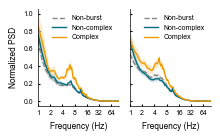


Cell counts by condition:
  Moving:
    complex: n=10
    simple: n=10
    non_burst: n=10
  Quiet:
    complex: n=10
    simple: n=10
    non_burst: n=10


In [362]:
# Plot pooled PSD by State & Burst Type (2 panels: Locomotion | Quiet)

# Check if we have data to plot
has_data = any(len(psd_grand[key]) > 0 for key in psd_grand.keys())

if not has_data:
    print("No PSD data available to plot.")
    print("If cs_plc_only=True, ensure cell_indices are saved in the npz files,")
    print("or set cs_plc_only=False to include all cells.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(2.2, 1.4), sharey=True)
    
    freq_mask = (freqs_ref > 0) & (freqs_ref <= max_freq)
    freqs_plot = freqs_ref[freq_mask]
    
    for ax, state, title in zip(axes, ['moving', 'quiet'], ['Locomotion', 'Quiet']):
        # Plot non-burst first (background)
        if plot_non_burst:
            psd_list = psd_grand[(state, 'non_burst')]
            if len(psd_list) >= 1:
                psd_arr = np.vstack(psd_list)
                psd_mean = np.nanmean(psd_arr, axis=0)[freq_mask]
                psd_sem = np.nanstd(psd_arr, axis=0)[freq_mask] / np.sqrt(psd_arr.shape[0])
                
                ax.plot(freqs_plot, psd_mean, color=non_burst_color, linewidth=1., 
                        linestyle='--', label=f'Non-burst')
                ax.fill_between(
                    freqs_plot,
                    psd_mean - psd_sem,
                    psd_mean + psd_sem,
                    color=non_burst_color,
                    alpha=0.15,
                    linewidth=0,
                )
        
        for burst_type, color, label in [('simple', simple_color, 'Non-complex'), 
                                          ('complex', complex_color, 'Complex')]:
            psd_list = psd_grand[(state, burst_type)]
            if len(psd_list) >= 1:
                psd_arr = np.vstack(psd_list)
                psd_mean = np.nanmean(psd_arr, axis=0)[freq_mask]
                psd_sem = np.nanstd(psd_arr, axis=0)[freq_mask] / np.sqrt(psd_arr.shape[0])
                
                ax.plot(freqs_plot, psd_mean, color=color, linewidth=1., 
                        label=f'{label}')
                ax.fill_between(
                    freqs_plot,
                    psd_mean - psd_sem,
                    psd_mean + psd_sem,
                    color=color,
                    alpha=0.2,
                    linewidth=0,
                )
        
        ax.set_xscale('log', base=2)
        ax.set_xlim(1, max_freq)
        ticks = [1, 2, 4, 8, 16, 32, 64]
        ticks = [t for t in ticks if t <= max_freq]
        ax.set_xticks(ticks)
        ax.set_xticklabels([str(t) for t in ticks])
        ax.set_xlabel('Frequency (Hz)')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(frameon=False, fontsize=5, loc='upper right')
    
    ylabel = 'Normalized PSD' if normalize_psd else 'PSD'
    axes[0].set_ylabel(ylabel)
    plt.tight_layout()
    
    # Save figure
    suffix = '_normalized' if normalize_psd else ''
    cs_suffix = '_csplc' if cs_plc_only else ''
    out_path = os.path.join(figure_save_folder, f'PSD_state_burstType_avg_pooled{suffix}{cs_suffix}.svg')
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'Saved to {out_path}')
    plt.show()
    
    # Print cell counts
    print(f"\nCell counts by condition:")
    for state in ['moving', 'quiet']:
        print(f"  {state.capitalize()}:")
        for burst_type in ['complex', 'simple', 'non_burst']:
            n = len(psd_grand[(state, burst_type)])
            print(f"    {burst_type}: n={n}")

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/theta_power_by_burstType_normalized_csplc.svg


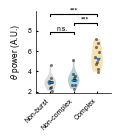


Theta Power Statistics (Locomotion, 4-8 Hz):
  Non-burst: mean=2.9750 ± 0.6521 (n=10)
  Non-complex: mean=3.2935 ± 0.7537 (n=10)
  Complex: mean=5.4869 ± 1.0248 (n=10)


In [363]:
# Violin plot: Theta Power (4-8 Hz) by Burst Type
# Compare Non-burst, Non-complex, and Complex during locomotion

# Define theta band
theta_band = (4, 8)
theta_mask = (freqs_ref >= theta_band[0]) & (freqs_ref <= theta_band[1])

# Calculate theta power for each cell in each group (locomotion only)
theta_powers = {}
for burst_type in ['non_burst', 'simple', 'complex']:
    psd_list = psd_grand[('moving', burst_type)]
    if len(psd_list) >= 1:
        psd_arr = np.vstack(psd_list)
        # Sum of power in theta band for each cell
        theta_power = np.nansum(psd_arr[:, theta_mask], axis=1)
        theta_powers[burst_type] = theta_power
    else:
        theta_powers[burst_type] = np.array([])

# Check if we have data
has_theta_data = any(len(v) > 0 for v in theta_powers.values())

if not has_theta_data:
    print("No theta power data available to plot.")
else:
    fig, ax = plt.subplots(1, 1, figsize=(1.2, 1.4))
    
    positions = [1, 2, 3]
    data_list = [theta_powers['non_burst'], theta_powers['simple'], theta_powers['complex']]
    colors_list = [non_burst_color, simple_color, complex_color]
    labels = ['Non-burst', 'Non-complex', 'Complex']
    
    ylim = _global_ylim(data_list)
    
    # Plot violins
    for pos, data, c in zip(positions, data_list, colors_list):
        if len(data) >= 3:
            parts = ax.violinplot([data], positions=[pos], showmedians=True, showextrema=False)
            _style_violin_medians(parts)
            for body in parts['bodies']:
                body.set_alpha(0.3)
                body.set_facecolor(c)
                body.set_edgecolor('none')
    
    # Scatter points
    rng = np.random.default_rng(42)
    for pos, data in zip(positions, data_list):
        if len(data) >= 1:
            jitter = (rng.random(len(data)) - 0.5) * 0.15
            ax.scatter(pos + jitter, data, s=5, color='black', alpha=0.5, linewidths=0)
    
    # Formatting
    ax.set_ylabel(r'$\theta$ power (A.U.)', fontsize=6, fontname='Arial')
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=5, fontname='Arial', rotation=45, ha='right')
    ax.set_xlim(0.4, 3.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=5)
    
    # Statistical brackets
    if ylim:
        y_range = ylim[1] - ylim[0]
        ax.set_ylim(ylim[0], ylim[1] + y_range * 0.45)
        h = y_range * 0.03
        text_h = y_range * 0.08
        gap = y_range * 0.05
        y1 = ylim[1] + y_range * 0.05
        
        # Non-burst vs Non-complex
        if len(theta_powers['non_burst']) >= 3 and len(theta_powers['simple']) >= 3:
            p, test, _, _ = unpaired_test_auto(theta_powers['non_burst'], theta_powers['simple'])
            add_bracket(ax, 1, 2, y1, h, _sig_label(p))
        
        # Non-complex vs Complex
        y2 = y1 + h + text_h + gap
        if len(theta_powers['simple']) >= 3 and len(theta_powers['complex']) >= 3:
            p, test, _, _ = unpaired_test_auto(theta_powers['simple'], theta_powers['complex'])
            add_bracket(ax, 2, 3, y2, h, _sig_label(p))
        
        # Non-burst vs Complex
        y3 = y2 + h + text_h + gap
        if len(theta_powers['non_burst']) >= 3 and len(theta_powers['complex']) >= 3:
            p, test, _, _ = unpaired_test_auto(theta_powers['non_burst'], theta_powers['complex'])
            add_bracket(ax, 1, 3, y3, h, _sig_label(p))
    
    plt.tight_layout()
    
    # Save figure
    suffix = '_normalized' if normalize_psd else ''
    cs_suffix = '_csplc' if cs_plc_only else ''
    out_path = os.path.join(figure_save_folder, f'theta_power_by_burstType{suffix}{cs_suffix}.svg')
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'Saved to {out_path}')
    plt.show()
    
    # Print statistics
    print(f"\nTheta Power Statistics (Locomotion, 4-8 Hz):")
    for burst_type, label in [('non_burst', 'Non-burst'), ('simple', 'Non-complex'), ('complex', 'Complex')]:
        data = theta_powers[burst_type]
        if len(data) > 0:
            print(f"  {label}: mean={np.mean(data):.4f} ± {np.std(data):.4f} (n={len(data)})")

Saved to /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/theta_power_by_burstType_quiet_normalized_csplc.svg


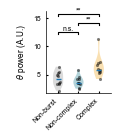


Theta Power Statistics (Quiet, 4-8 Hz):
  Non-burst: mean=4.3169 ± 1.2059 (n=10)
  Non-complex: mean=3.8132 ± 0.9360 (n=10)
  Complex: mean=6.4775 ± 1.8022 (n=10)


In [364]:
# Violin plot: Theta Power (4-8 Hz) by Burst Type - QUIET condition
# Compare Non-burst, Non-complex, and Complex during quiet

# Calculate theta power for each cell in each group (quiet only)
theta_powers_quiet = {}
for burst_type in ['non_burst', 'simple', 'complex']:
    psd_list = psd_grand[('quiet', burst_type)]
    if len(psd_list) >= 1:
        psd_arr = np.vstack(psd_list)
        # Sum of power in theta band for each cell
        theta_power = np.nansum(psd_arr[:, theta_mask], axis=1)
        theta_powers_quiet[burst_type] = theta_power
    else:
        theta_powers_quiet[burst_type] = np.array([])

# Check if we have data
has_theta_data_quiet = any(len(v) > 0 for v in theta_powers_quiet.values())

if not has_theta_data_quiet:
    print("No theta power data available to plot (quiet condition).")
else:
    fig, ax = plt.subplots(1, 1, figsize=(1.2, 1.4))
    
    positions = [1, 2, 3]
    data_list = [theta_powers_quiet['non_burst'], theta_powers_quiet['simple'], theta_powers_quiet['complex']]
    colors_list = [non_burst_color, simple_color, complex_color]
    labels = ['Non-burst', 'Non-complex', 'Complex']
    
    ylim = _global_ylim(data_list)
    
    # Plot violins
    for pos, data, c in zip(positions, data_list, colors_list):
        if len(data) >= 3:
            parts = ax.violinplot([data], positions=[pos], showmedians=True, showextrema=False)
            _style_violin_medians(parts)
            for body in parts['bodies']:
                body.set_alpha(0.3)
                body.set_facecolor(c)
                body.set_edgecolor('none')
    
    # Scatter points
    rng = np.random.default_rng(42)
    for pos, data in zip(positions, data_list):
        if len(data) >= 1:
            jitter = (rng.random(len(data)) - 0.5) * 0.15
            ax.scatter(pos + jitter, data, s=5, color='black', alpha=0.5, linewidths=0)
    
    # Formatting
    ax.set_ylabel(r'$\theta$ power (A.U.)', fontsize=6, fontname='Arial')
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=5, fontname='Arial', rotation=45, ha='right')
    ax.set_xlim(0.4, 3.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=5)
    
    # Statistical brackets
    if ylim:
        y_range = ylim[1] - ylim[0]
        ax.set_ylim(ylim[0], ylim[1] + y_range * 0.45)
        h = y_range * 0.03
        text_h = y_range * 0.08
        gap = y_range * 0.05
        y1 = ylim[1] + y_range * 0.05
        
        # Non-burst vs Non-complex
        if len(theta_powers_quiet['non_burst']) >= 3 and len(theta_powers_quiet['simple']) >= 3:
            p, test, _, _ = unpaired_test_auto(theta_powers_quiet['non_burst'], theta_powers_quiet['simple'])
            add_bracket(ax, 1, 2, y1, h, _sig_label(p))
        
        # Non-complex vs Complex
        y2 = y1 + h + text_h + gap
        if len(theta_powers_quiet['simple']) >= 3 and len(theta_powers_quiet['complex']) >= 3:
            p, test, _, _ = unpaired_test_auto(theta_powers_quiet['simple'], theta_powers_quiet['complex'])
            add_bracket(ax, 2, 3, y2, h, _sig_label(p))
        
        # Non-burst vs Complex
        y3 = y2 + h + text_h + gap
        if len(theta_powers_quiet['non_burst']) >= 3 and len(theta_powers_quiet['complex']) >= 3:
            p, test, _, _ = unpaired_test_auto(theta_powers_quiet['non_burst'], theta_powers_quiet['complex'])
            add_bracket(ax, 1, 3, y3, h, _sig_label(p))
    
    plt.tight_layout()
    
    # Save figure
    suffix = '_normalized' if normalize_psd else ''
    cs_suffix = '_csplc' if cs_plc_only else ''
    out_path = os.path.join(figure_save_folder, f'theta_power_by_burstType_quiet{suffix}{cs_suffix}.svg')
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'Saved to {out_path}')
    plt.show()
    
    # Print statistics
    print(f"\nTheta Power Statistics (Quiet, 4-8 Hz):")
    for burst_type, label in [('non_burst', 'Non-burst'), ('simple', 'Non-complex'), ('complex', 'Complex')]:
        data = theta_powers_quiet[burst_type]
        if len(data) > 0:
            print(f"  {label}: mean={np.mean(data):.4f} ± {np.std(data):.4f} (n={len(data)})")